# 🎲 Intro to Probability: Zero to Hero (for Machine Learning)
## A refresher that assumes you have forgotten all of it

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![Prereqs](https://img.shields.io/badge/prerequisites-none-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #134E5E 0%, #71B280 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A test is 99% accurate. You test positive. Are you 99% likely to be ill?

No. Depending on how rare the disease is, you might be more likely to be **healthy** — and by a wide margin.

Almost everyone gets that wrong, including doctors, in studies, repeatedly. Not because the arithmetic is hard — it is one line — but because human intuition about probability is genuinely, systematically broken, and no amount of being clever fixes it. What fixes it is having the rules written down and *checking your answers*.

So that is what this notebook does. Every rule gets stated, then **verified by simulation**: we generate twenty thousand cases and count. If the rule is right, the count agrees. If your intuition disagrees with both, your intuition is what is wrong.

By Part 4 you will answer the question above yourself, and see exactly where the intuition fails.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 Who this is for, and how it works

**For you if** you have met probability, can compute the chance of two heads in a row, and go blank at conditional probability — and you now want to understand what a model means when it outputs 0.87.

**No prerequisites.** Part 1 starts at what a probability *is*. Every symbol is named in words the first time.

**Every claim is checked by simulation.** This notebook's core discipline: state a rule, then count. You never have to trust a formula, and when a result feels wrong you can watch it happen.

**One example runs throughout**: a spam filter's inbox, 20,000 emails, some spam, some containing certain words. Every rule gets demonstrated on it.

</div>

## 🎯 What you will be able to do

1. **Say what a probability is** — and what it is not.
2. **Combine events** with and / or / not, without double-counting.
3. **Compute a conditional probability**, and say what independence really means.
4. **Derive and use Bayes' theorem**, and solve the test-accuracy problem above.
5. **Work with random variables** and compute an expectation.
6. **Explain variance** and why spread matters as much as average.
7. **Recognise the named distributions** and say when each applies.
8. **Handle several variables at once**: joint, marginal, covariance.
9. **Read cross-entropy loss** as a sentence about likelihood.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why probability, and the game we play all notebook |  &larr; **you are here**
| **1** | Outcomes, events, and what a probability IS |
| **2** | Combining events: and, or, not |
| **3** | Conditional probability and independence |
| **4** | Bayes' theorem, derived and used |
| **5** | Random variables and expectation |
| **6** | Variance, spread, and why it matters |
| **7** | The named distributions, and when each applies |
| **8** | Many variables at once: joint, marginal, covariance |
| **9** | Probability doing ML: likelihood, cross-entropy, naive Bayes |

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


## ⚙️ Setup

Nothing to install.

In [1]:
# ============================================================
#  Setup -- no installs, no downloads, no network.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

C_F, C_SLOPE, C_AREA = "#2563EB", "#DC2626", "#059669"
C_APPROX, C_EXACT, C_GREY, C_SOFT = "#D97706", "#7C3AED", "#6B7280", "#E5E7EB"


print(f"numpy {np.__version__}")


numpy 2.1.3


---

# 0️⃣ The inbox

Twenty thousand emails. Each is spam or not. Each either contains a given word
or does not. We **generate** it, which means we know the true probabilities that
produced it — so every rule we derive can be checked against the truth, which is
a luxury you never get with real data and exactly what makes it useful here.

The generating rules are simple and stated plainly in the code: 30% of mail is
spam, and each of four words appears with one probability in spam and a
different one in legitimate mail.


In [2]:
# ============================================================
#  The running example -- a spam filter's inbox.
#  Every rule in this notebook gets checked by SIMULATION:
#  we state a probability, then generate thousands of emails
#  and count. If the rule is right, the count agrees.
# ============================================================
import numpy as np

RNG = np.random.default_rng(17)

N_EMAILS  = 20_000
P_SPAM    = 0.30                      # 30% of mail is spam
# P(word appears | spam) and P(word appears | not spam)
WORDS = {"free": (0.55, 0.04), "meeting": (0.03, 0.38),
         "winner": (0.42, 0.01), "report": (0.05, 0.31)}

is_spam = RNG.random(N_EMAILS) < P_SPAM
inbox   = {"spam": is_spam}
for w, (p_s, p_h) in WORDS.items():
    p = np.where(is_spam, p_s, p_h)
    inbox[w] = RNG.random(N_EMAILS) < p

print(f"simulated {N_EMAILS:,} emails")
print(f"actually spam        : {is_spam.mean():.4f}   (we set 0.30)")
print(f"contain 'free'       : {inbox['free'].mean():.4f}")
print(f"spam AND 'free'      : {(is_spam & inbox['free']).mean():.4f}")
print()
print("Every probability claimed in this notebook is checked against counts")
print("like these. If the algebra is wrong, the simulation disagrees.")


simulated 20,000 emails
actually spam        : 0.3008   (we set 0.30)
contain 'free'       : 0.1938
spam AND 'free'      : 0.1664

Every probability claimed in this notebook is checked against counts
like these. If the algebra is wrong, the simulation disagrees.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The printed proportions from 20,000 simulated emails. The spam rate comes out near 0.30 because that is what we set — but not exactly 0.30, and that gap is itself worth noticing: 20,000 draws is a lot, and the answer is *still* not the exact value. Randomness does not average away neatly at any finite sample size.

The third line is the one to sit with: the proportion of emails that are spam **and** contain 'free'. It is much smaller than either the spam rate or the 'free' rate on its own, because both conditions have to hold at once.

**The common misread:** treating that simulated proportion as the true probability. It is an estimate from a sample. Run it with a different seed and every number moves a little — which is the entire subject of the statistics companion notebook, and a distinction worth keeping straight from the first cell.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

A **probability** is a number between 0 and 1 saying how often something happens in the long run. 0 means never, 1 means always, 0.3 means roughly three times in ten.

That is the definition this notebook uses throughout — the **frequency** reading, because it is the one you can check by counting. Part 1 mentions the other main reading (probability as a degree of belief) and says where the two part company.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

When a classifier outputs 0.87, that number is a probability, and the whole business of training it is making those numbers **well calibrated** — so that among all the cases it labels 0.87, about 87% really are positive.

Cross-entropy, the loss almost every classifier is trained with, is a direct statement about probability: it rewards the model for putting high probability on what actually happened. By Part 9 you will be able to read its formula as a sentence rather than a spell.

</div>

### The notation, once, up front

| Written | Said aloud | Means |
|---|---|---|
| $P(A)$ | "P of A" | the probability that $A$ happens |
| $P(A^c)$ or $P(\text{not } A)$ | "P of not A" | the probability it does not |
| $P(A \cap B)$ | "P of A and B" | both happen |
| $P(A \cup B)$ | "P of A or B" | at least one happens |
| $P(A \mid B)$ | "P of A **given** B" | $A$ happens, among the cases where $B$ did |
| $E[X]$ | "the expectation of X" | the long-run average value of $X$ |
| $\text{Var}(X)$ | "the variance of X" | how spread out $X$ is |

The one to slow down on is $P(A \mid B)$. That vertical bar is **not** division
and **not** "and" — it means *restrict attention to the cases where $B$ happened,
then ask about $A$ within them*. Nearly every probability mistake in the wild is
that bar being misread, and Part 3 is entirely about it.

---


---

# 1️⃣ Outcomes, events, and what a probability IS

Part 0 used the word *probability* as though we all agreed on what it means. We
nearly do — but "nearly" is exactly where the mistakes live, so this part pins
it down.

Three words first (**outcome**, **event**, **sample space**), then three rules
that everything else in the notebook is built on, then one small piece of code
that will check every claim in the remaining eight parts.

Nothing here is hard. It is the vocabulary. Skipping it is why conditional
probability feels impossible three parts from now.


## 1.1 Outcome, sample space, event

Suppose we pick one email out of the inbox at random.

**Outcome** — one single thing that could happen. Here: *this particular email,
which is spam and contains the word "free"*. One outcome, fully described,
nothing left undecided.

**Sample space** — the collection of every outcome that could possibly happen,
usually written $S$ (some books write $\Omega$). Exactly one of them will
happen. Here $S$ is the whole inbox: pick an email, you get one of these.

**Event** — a *set of outcomes*, written with a capital letter like $A$. Not one
outcome — a whole group of them, collected because we care about the same thing
being true of all of them.

That last one is the idea to hold on to, because it is the one that makes the
rest of the notebook easy:

> **An event is a set. "Spam" is not a thing that happens — it is the set of all
> the emails that happen to be spam.**

Once events are sets, "A and B" means the overlap of two sets, "A or B" means
everything in either set, and "not A" means everything outside A. All the rules
in Part 2 become statements about sets, and sets are things you can *count*.

In code an event is a **boolean array**: one True/False per email, True on
exactly the outcomes that belong to the set.


the sample space holds 20,000 outcomes (emails)
the event 'spam'  is a set of 6,016 of them
the event 'free'  is a set of 3,875 of them
an event is stored as a boolean array: bool, first five = [False  True False False  True]


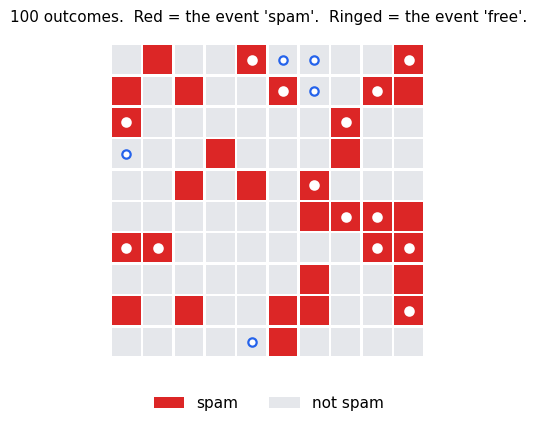


in these 100 squares: spam 31, 'free' 19, both 14


In [3]:
# ============================================================
#  The sample space, drawn. 100 of the 20,000 emails.
#  Each square is one OUTCOME. Each colour/mark is an EVENT.
# ============================================================
A_spam = inbox["spam"]      # the event "this email is spam"
B_free = inbox["free"]      # the event "this email contains the word free"

print(f"the sample space holds {len(A_spam):,} outcomes (emails)")
print(f"the event 'spam'  is a set of {A_spam.sum():,} of them")
print(f"the event 'free'  is a set of {B_free.sum():,} of them")
print(f"an event is stored as a boolean array: {A_spam.dtype}, "
      f"first five = {A_spam[:5]}")

fig, ax = plt.subplots(figsize=(8, 4.4))
SHOW = 100
for i in range(SHOW):
    r, c = divmod(i, 10)
    ax.add_patch(plt.Rectangle((c, -r), 0.92, 0.92, lw=0,
                               facecolor=C_SLOPE if A_spam[i] else C_SOFT))
    if B_free[i]:
        ax.plot(c + 0.46, -r + 0.46, "o", ms=6, mfc="white",
                mec=C_F if not A_spam[i] else "white", mew=1.6)

ax.set_xlim(-0.4, 10.4); ax.set_ylim(-9.6, 1.4)
ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)
ax.set_title("100 outcomes.  Red = the event 'spam'.  Ringed = the event 'free'.",
             fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=C_SLOPE, lw=0),
           plt.Rectangle((0, 0), 1, 1, facecolor=C_SOFT,  lw=0)]
ax.legend(handles, ["spam", "not spam"], loc="upper center",
          bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
plt.tight_layout(); plt.show()

print()
print(f"in these {SHOW} squares: spam {A_spam[:SHOW].sum()}, "
      f"'free' {B_free[:SHOW].sum()}, both {(A_spam & B_free)[:SHOW].sum()}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One hundred outcomes as one hundred squares. The **event** 'spam' is not any single square — it is the red set, taken together. The event 'free' is the ringed set. They overlap, and the overlap is a set too: the squares that are both red and ringed.

Everything the rest of this notebook does is counting squares. `P(spam)` is *how much of the picture is red*. `P(spam and free)` is *how much is red and ringed*. Nothing more mysterious than that is ever going on.

**The common misread:** thinking a probability is a property of one square. It is not — one square is either spam or it is not, no probability about it. A probability is a property of the **whole picture**: what fraction of it the set covers.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

An **outcome** is one thing that happens. The **sample space** is all the things that could have happened. An **event** is a *group* of outcomes you have chosen to care about.

And the probability of an event is the share of the sample space it covers:

$$P(A) = \frac{\text{how many outcomes are in } A}{\text{how many outcomes there are in total}}$$

Said aloud: **count the ones you want, divide by the ones there are.** That is the whole definition, and every rule in the next eight parts is a shortcut for doing that counting without having to list everything out.

</div>

## 1.2 Two readings of the same number, and where they part company

"Count and divide" is called the **frequency** reading: a probability is the
long-run share of the times a thing happens, and you find it by repeating the
situation and counting. This is the reading this notebook uses, for the very
practical reason that it is the one you can *check*.

There is a second reading. **Probability as a degree of belief**: a number
saying how strongly you expect something, whether or not it can be repeated at
all. Both readings obey the identical rules — the whole of Parts 2 to 8 is true
under either — but they answer different questions, and the split shows up the
moment you ask about something that happens only once.

- *"The probability this coin lands heads is 0.5."* Repeatable. Flip it ten
  thousand times and count; the claim is testable, and a claim of 0.9 would be
  visibly refuted.

- *"The probability it rains here tomorrow is 0.7."* **Tomorrow happens once.**
  There is no stack of tomorrows to count through. It will rain or it will not,
  and afterwards the 0.7 is neither confirmed nor refuted by that single day.

The belief reading takes 0.7 to mean *how much I would bet* — a summary of the
forecaster's information, not a count. That is a real and useful meaning, and
Part 4 (Bayes) is exactly the machinery for updating such a number when
evidence arrives. But it is not something a simulation can verify, so when this
notebook says "checked", it always means checked in the frequency sense: we
generated cases and counted.


In [4]:
# ============================================================
#  One of these can be checked by counting. The other cannot.
# ============================================================
rng = np.random.default_rng(1)

flips = rng.random(10_000) < 0.5          # 10,000 repeats of a repeatable thing
print("CLAIM: P(heads) = 0.5")
print(f"  10,000 flips -> heads {flips.sum():,}  "
      f"share {flips.mean():.4f}   claim survives\n")

print("CLAIM: P(rain here tomorrow) = 0.7")
print("  tomorrows available to count : 1")
print("  share of them that were rainy: 0 or 1, whichever happens")
print("  -> no count can confirm or refute 0.7. Different kind of claim.\n")

print("Both are legitimate. Only the first is the kind this notebook verifies.")


CLAIM: P(heads) = 0.5
  10,000 flips -> heads 4,953  share 0.4953   claim survives

CLAIM: P(rain here tomorrow) = 0.7
  tomorrows available to count : 1
  share of them that were rainy: 0 or 1, whichever happens
  -> no count can confirm or refute 0.7. Different kind of claim.

Both are legitimate. Only the first is the kind this notebook verifies.


## 1.3 The three rules everything is built from

Probability has exactly three founding rules. They are usually called *axioms*,
which makes them sound imposing. They are not. If you accept "count the ones you
want, divide by the total", all three are immediate — you cannot count a
negative number of emails, and so on.

Write $S$ for the sample space (everything), and $A$, $B$ for events.

| # | The rule | Why it is obvious |
|---|---|---|
| 1 | $P(A) \ge 0$ | it is a count divided by a count; neither can be negative |
| 2 | $P(S) = 1$ | *something* happens; the set of everything covers everything |
| 3 | if $A$ and $B$ **cannot both happen**, then $P(A \cup B) = P(A) + P(B)$ | non-overlapping sets: counting both is counting one, then the other |

Rule 3 has a condition attached and it matters enormously. Two events that
cannot both happen are called **mutually exclusive** or **disjoint** — their
sets do not overlap. *Only then* may you add. Part 2 is largely about what to do
when they do overlap, and the damage done by forgetting to ask.

Everything else — the complement rule below, inclusion–exclusion, Bayes'
theorem, the entire subject — is a consequence of these three. Nothing further
gets assumed.


In [5]:
# ============================================================
#  The three axioms, checked on the inbox by counting.
# ============================================================
S = np.ones(N_EMAILS, dtype=bool)          # the sample space: every email

# --- Rule 1: probabilities are never negative -------------------------
events = {"spam": inbox["spam"], "free": inbox["free"],
          "meeting": inbox["meeting"], "spam AND free": inbox["spam"] & inbox["free"],
          "impossible (spam and not spam)": inbox["spam"] & ~inbox["spam"]}
print("RULE 1  P(A) >= 0")
for name, ev in events.items():
    print(f"   P({name:<30s}) = {ev.mean():.4f}")
print(f"   all non-negative: {all(ev.mean() >= 0 for ev in events.values())}\n")

# --- Rule 2: the whole sample space has probability 1 -----------------
print("RULE 2  P(S) = 1")
print(f"   P(the email is spam OR not spam) = {(inbox['spam'] | ~inbox['spam']).mean():.4f}")
print(f"   P(S)                             = {S.mean():.4f}\n")

# --- Rule 3: disjoint events add --------------------------------------
#  'spam AND free' and 'spam AND not free' cannot both happen: disjoint.
#  Together they are exactly 'spam'.
left  = inbox["spam"] & inbox["free"]
right = inbox["spam"] & ~inbox["free"]
print("RULE 3  disjoint events add")
print(f"   can they overlap?  shared outcomes = {(left & right).sum()}   (0 = disjoint)")
print(f"   P(spam and free)      = {left.mean():.4f}")
print(f"   P(spam and not free)  = {right.mean():.4f}")
print(f"   sum                   = {left.mean() + right.mean():.4f}")
print(f"   P(spam) counted direct = {inbox['spam'].mean():.4f}")
print(f"   identical: {np.isclose(left.mean() + right.mean(), inbox['spam'].mean())}")


RULE 1  P(A) >= 0
   P(spam                          ) = 0.3008
   P(free                          ) = 0.1938
   P(meeting                       ) = 0.2742
   P(spam AND free                 ) = 0.1664
   P(impossible (spam and not spam)) = 0.0000
   all non-negative: True

RULE 2  P(S) = 1
   P(the email is spam OR not spam) = 1.0000
   P(S)                             = 1.0000

RULE 3  disjoint events add
   can they overlap?  shared outcomes = 0   (0 = disjoint)
   P(spam and free)      = 0.1664
   P(spam and not free)  = 0.1343
   sum                   = 0.3008
   P(spam) counted direct = 0.3008
   identical: True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

All three rules confirmed by counting, not by assertion.

Rule 3 is the one worth staring at. We split 'spam' into two pieces that cannot overlap — spam-with-*free* and spam-without-*free* — and the two probabilities added back to exactly the probability of spam. Not approximately: the same number, because the two sets partition the third outcome by outcome.

That splitting trick reappears constantly. It is how the denominator of Bayes' theorem gets built in Part 4, and it is the whole of the law of total probability. Notice also the impossible event in Rule 1: an email that is both spam and not spam. Its set is empty, and its probability came out 0, which is what an empty set must give.

</div>

## 1.4 The tool this notebook runs on

If a probability is "count the ones you want, divide by the total", then a
probability can always be *estimated* by manufacturing a pile of cases and
counting. That is the promise made in Part 0, and here is the code that keeps
it, for the rest of the notebook.

Three small functions:

- **`estimate_prob(trial, n)`** — you hand it a function describing one round of
  the experiment; it runs `n` of them and returns the share that came out True.
- **`running_estimate(trial, n)`** — the same, but returns the estimate *after
  each* round, so we can watch it settle.
- **`confirm(label, by_rule, by_counting)`** — prints an algebraic answer beside
  a counted one and says whether they agree.

The `trial` you pass in takes a random-number generator and a count `n`, and
returns a boolean array: `True` wherever the event happened. Writing the
experiment out that way is itself a discipline — it forces you to say precisely
what event you mean before you claim a number for it.


In [6]:
# ============================================================
#  The three tools every later part re-uses. Keep them in mind.
# ============================================================
def estimate_prob(trial, n=200_000, seed=0):
    """Estimate P(event) by simulating n rounds and counting the hits.

    trial(rng, n) -> boolean array of length n, True where the event happened.
    """
    hits = np.asarray(trial(np.random.default_rng(seed), n), dtype=bool)
    return hits.mean()


def running_estimate(trial, n=20_000, seed=0):
    """The same estimate, but after 1 round, 2 rounds, ... n rounds."""
    hits = np.asarray(trial(np.random.default_rng(seed), n), dtype=bool)
    return np.cumsum(hits) / np.arange(1, n + 1)


def confirm(label, by_rule, by_counting, tol=0.01):
    """Print an algebraic answer beside a counted one. Complain if they differ."""
    gap = abs(by_rule - by_counting)
    print(f"{label:<34s} rule {by_rule:7.4f}   counted {by_counting:7.4f}   "
          f"gap {gap:6.4f}   {'agree' if gap < tol else '*** DISAGREE ***'}")
    return gap < tol


# --- a first use: two coins, both heads -------------------------------
two_heads = lambda rng, n: (rng.random(n) < 0.5) & (rng.random(n) < 0.5)
confirm("P(two coins both heads)", 1 / 4, estimate_prob(two_heads, 200_000))

# --- and a deliberately WRONG claim, to show the tool bites -----------
confirm("P(two coins both heads) = 1/2?", 1 / 2, estimate_prob(two_heads, 200_000))


P(two coins both heads)            rule  0.2500   counted  0.2515   gap 0.0015   agree
P(two coins both heads) = 1/2?     rule  0.5000   counted  0.2515   gap 0.2485   *** DISAGREE ***


np.False_

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The first line agrees; the second, which claims the wrong answer on purpose, is flagged. That is the point of `confirm` — it is not decoration, it is a test that can fail, and in this notebook it is allowed to fail loudly.

From here on, whenever a rule is stated, you will see it followed by a cell that computes the rule's answer one way and a counted answer the other way, and puts them side by side. If you ever doubt a formula, that is the cell to read — and you can edit the trial function and re-run to interrogate it yourself.

</div>

## 1.5 When every outcome is equally likely, probability is just counting

For a fair die, a fair coin, a shuffled deck, the outcomes are **equally
likely**: no one of them is favoured. Then the definition collapses to pure
arithmetic:

$$P(A) = \frac{\text{number of outcomes in } A}{\text{total number of outcomes}}
= \frac{\text{favourable}}{\text{possible}}$$

The skill this asks for is not probability at all — it is *listing the sample
space carefully*. Roll two dice and the sample space is not the eleven possible
totals (2 through 12), because those are not equally likely; it is the ordered
pairs, and there are six choices for the first die times six for the second.

Sevens are common and twos are rare for one reason only: more of those pairs
add up to seven. Let the computer list all the pairs and count, rather than
trusting the arithmetic — then simulate the same thing and see the two land in
the same place.


In [7]:
# ============================================================
#  Equally likely outcomes: list them, count them, then simulate.
# ============================================================
import itertools

pairs = list(itertools.product(range(1, 7), repeat=2))   # the real sample space
print(f"rolling two dice: {len(pairs)} equally likely ordered pairs")

for target in (7, 2, 11):
    favourable = [p for p in pairs if sum(p) == target]
    by_rule = len(favourable) / len(pairs)
    trial = (lambda t: lambda rng, n:
             rng.integers(1, 7, n) + rng.integers(1, 7, n) == t)(target)
    confirm(f"P(two dice sum to {target:>2d})  {len(favourable):>2d}/{len(pairs)}",
            by_rule, estimate_prob(trial, 200_000, seed=target))

print()
# --- coins: the same logic, a different sample space -------------------
for k in (2, 3):
    seqs = list(itertools.product("HT", repeat=k))
    favourable = [s for s in seqs if all(c == "H" for c in s)]
    by_rule = len(favourable) / len(seqs)
    trial = (lambda kk: lambda rng, n:
             (rng.random((n, kk)) < 0.5).all(axis=1))(k)
    confirm(f"P({k} coins all heads)  {len(favourable)}/{len(seqs)}",
            by_rule, estimate_prob(trial, 200_000, seed=k))


rolling two dice: 36 equally likely ordered pairs
P(two dice sum to  7)   6/36       rule  0.1667   counted  0.1658   gap 0.0009   agree
P(two dice sum to  2)   1/36       rule  0.0278   counted  0.0276   gap 0.0002   agree
P(two dice sum to 11)   2/36       rule  0.0556   counted  0.0558   gap 0.0002   agree

P(2 coins all heads)  1/4          rule  0.2500   counted  0.2505   gap 0.0005   agree
P(3 coins all heads)  1/8          rule  0.1250   counted  0.1242   gap 0.0008   agree


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Every line agrees. The counted sample space and the simulated one tell the same story, which is the reassurance you want before trusting either.

Look at how far apart sevens and twos are — that gap comes from nothing but how many ordered pairs land on each total. And note what would have happened had we listed the *totals* 2 to 12 as our sample space and declared each equally likely: we would have claimed one in eleven for both, and the simulation would have thrown it out on both counts.

**Equally likely is an assumption about the world, not a licence.** When it holds, counting is enough. When it does not — and for real data it almost never does — you need the machinery of the later parts.

</div>

## 1.6 The complement rule: $P(\text{not } A) = 1 - P(A)$

The **complement** of $A$, written $A^c$ and said "not A", is the set of every
outcome *not* in $A$. Every email is either in $A$ or in $A^c$ — never both,
never neither.

Which means the two are disjoint, and together they are the whole sample space.
So Rule 3 lets us add them, and Rule 2 says what the total must be:

$$P(A) + P(A^c) = P(S) = 1 \qquad\Longrightarrow\qquad \boxed{P(A^c) = 1 - P(A)}$$

Two lines, using only the axioms. Nothing new was assumed.

It looks too small to matter. It is the single most useful line of algebra in
elementary probability, because it turns questions that are painful to count
directly into questions that are easy. "At least one of these twenty things
happens" has an enormous number of ways to come true and exactly one way to
fail; you compute the failure and subtract. Part 2 does the birthday problem
this way, and Part 7 uses the same move on distributions.


In [8]:
# ============================================================
#  The complement rule, on the inbox and on dice.
# ============================================================
for name in ("spam", "free", "meeting"):
    ev = inbox[name]
    confirm(f"P(not '{name}')", 1 - ev.mean(), (~ev).mean())

print()
# The rule earns its keep here: "at least one six in four rolls".
# Counting the ways to succeed is fiddly; there is exactly one way to fail.
no_six    = lambda rng, n: (rng.integers(1, 7, (n, 4)) != 6).all(axis=1)
least_one = lambda rng, n: (rng.integers(1, 7, (n, 4)) == 6).any(axis=1)

p_none = (5 / 6) ** 4
confirm("P(no six in four rolls)", p_none, estimate_prob(no_six, 200_000, seed=4))
confirm("P(at least one six)", 1 - p_none, estimate_prob(least_one, 200_000, seed=4))


P(not 'spam')                      rule  0.6992   counted  0.6992   gap 0.0000   agree
P(not 'free')                      rule  0.8063   counted  0.8063   gap 0.0000   agree
P(not 'meeting')                   rule  0.7258   counted  0.7258   gap 0.0000   agree

P(no six in four rolls)            rule  0.4823   counted  0.4819   gap 0.0004   agree
P(at least one six)                rule  0.5177   counted  0.5181   gap 0.0004   agree


np.True_

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The complement rule holds to the fourth decimal on every event we tried, which is all a rule derived from the axioms could be expected to do.

The dice lines are the ones that show why anyone bothers. Counting the ways to get *at least one* six in four rolls means handling exactly-one, exactly-two, exactly-three and exactly-four separately and adding them up. Counting the ways to get *no* six is one multiplication. Subtract from one and you are finished — and the simulation confirms the shortcut landed in the same place as the long way round.

</div>

## 1.7 How many samples is enough? Watch one settle

Every estimate above came from a fixed number of rounds, and every one of them
was slightly wrong — close, but not exact. That is not a flaw in the method; it
is the method. A counted probability is an *estimate*, and estimates wobble.

The useful question is how the wobble behaves as the pile of cases grows. So
take a probability we know exactly — two dice summing to seven, which we counted
above as a fraction of the thirty-six pairs — and plot the running estimate
after every single roll, from the first to the twenty-thousandth. Several
independent runs at once, so the spread is visible rather than inferred.


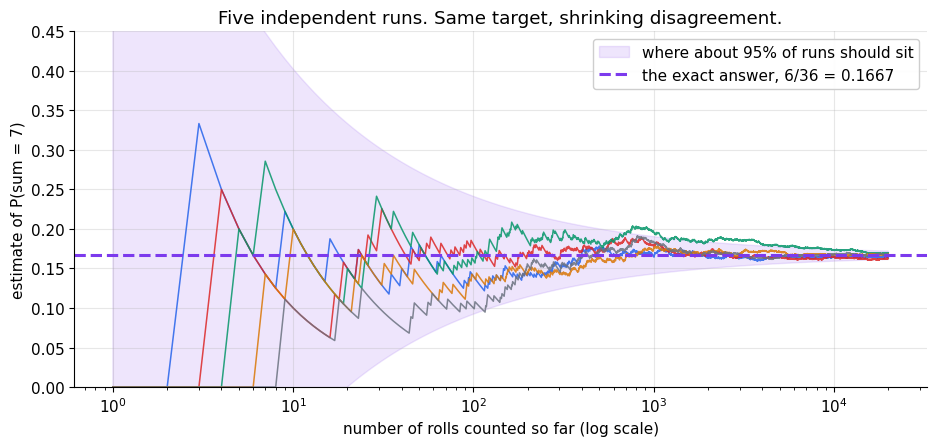

after     10 rolls   estimates ['0.000', '0.200', '0.300', '0.100', '0.200']   worst error 0.1667
after    100 rolls   estimates ['0.250', '0.150', '0.210', '0.160', '0.160']   worst error 0.0833
after  1,000 rolls   estimates ['0.182', '0.164', '0.173', '0.152', '0.158']   worst error 0.0153
after 20,000 rolls   estimates ['0.164', '0.163', '0.169', '0.168', '0.168']   worst error 0.0042


In [9]:
# ============================================================
#  The running estimate, converging on a value we already know.
# ============================================================
sum_seven = lambda rng, n: rng.integers(1, 7, n) + rng.integers(1, 7, n) == 7
TRUE_P = len([p for p in itertools.product(range(1, 7), repeat=2)
              if sum(p) == 7]) / 36
N = 20_000

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for seed, colour in zip(range(5), [C_F, C_SLOPE, C_AREA, C_APPROX, C_GREY]):
    ax.plot(np.arange(1, N + 1), running_estimate(sum_seven, N, seed=seed),
            color=colour, lw=1.1, alpha=0.85)

k = np.arange(1, N + 1)
band = 2 * np.sqrt(TRUE_P * (1 - TRUE_P) / k)          # typical wobble, +/- 2 sd
ax.fill_between(k, TRUE_P - band, TRUE_P + band, color=C_EXACT, alpha=0.13,
                label="where about 95% of runs should sit")
ax.axhline(TRUE_P, color=C_EXACT, lw=2.2, ls="--",
           label=f"the exact answer, 6/36 = {TRUE_P:.4f}")

ax.set_xscale("log")
ax.set_xlabel("number of rolls counted so far (log scale)")
ax.set_ylabel("estimate of P(sum = 7)")
ax.set_ylim(0, 0.45)
ax.set_title("Five independent runs. Same target, shrinking disagreement.")
ax.legend(loc="upper right", framealpha=0.95)
plt.tight_layout(); plt.show()

for n in (10, 100, 1_000, 20_000):
    spread = [running_estimate(sum_seven, n, seed=s)[-1] for s in range(5)]
    print(f"after {n:>6,} rolls   estimates {['%.3f' % v for v in spread]}   "
          f"worst error {max(abs(v - TRUE_P) for v in spread):.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five separate runs of the same experiment, each line the running share of rolls that summed to seven. On the left, after a handful of rolls, the lines are all over the place — one of them may still be sitting at zero. As the count grows they are squeezed towards the dashed line, which is the exact answer we obtained by listing the thirty-six pairs.

The shaded band is not drawn from the data; it is the theory's prediction of the wobble, and it narrows in proportion to one over the square root of the count. That is the shape of the whole thing: **to halve your error you need four times the data.** The printed rows put numbers on it.

**The common misread:** reading the funnel as 'the estimate is getting closer every step'. It is not. Individual lines wander back out, cross over, and get temporarily worse — the *band* tightens, not each run. And note the log axis: the last, seemingly narrow stretch of the picture is most of the rolls.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The law of large numbers**, in ordinary words: *if you repeat the same experiment enough times, the share of times an event happens gets, and stays, arbitrarily close to its probability.*

That is the whole justification for everything this notebook does with simulation. It is also the sentence that makes the frequency reading of probability mean anything at all — without it, 'the long-run share' would not be a well-defined number to talk about.

What it does **not** say is that the errors get cancelled out, or that a run of bad luck must be repaid. The share settles down because the denominator grows, not because the numerator is corrected. Nothing goes back and fixes the early rolls.

</div>

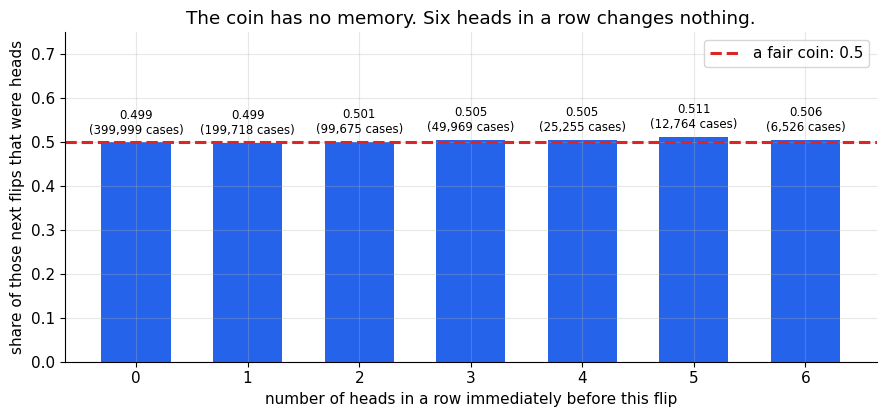

after k heads in a row, share of next flips that were heads:
   k = 0   0.4993   (from 399,999 such moments)
   k = 1   0.4991   (from 199,718 such moments)
   k = 2   0.5013   (from 99,675 such moments)
   k = 3   0.5054   (from 49,969 such moments)
   k = 4   0.5054   (from 25,255 such moments)
   k = 5   0.5113   (from 12,764 such moments)
   k = 6   0.5057   (from 6,526 such moments)

largest departure from 0.5: 0.0113


In [10]:
# ============================================================
#  "It is due." Is it? Ask the coins, not the intuition.
#  After a run of k heads, how often is the NEXT flip heads?
# ============================================================
rng   = np.random.default_rng(99)
n     = 400_000
flips = rng.random(n) < 0.5                     # a fair coin, 400,000 times

ks, rates, counts = list(range(7)), [], []
for k in ks:
    if k == 0:
        idx = np.arange(n - 1)                  # every position, no condition
    else:
        run = np.ones(n - k, dtype=bool)        # previous k flips all heads
        for j in range(k):
            run &= flips[j:n - k + j]
        idx = np.nonzero(run)[0]
    nxt = flips[idx + k]
    rates.append(nxt.mean()); counts.append(len(idx))

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar([str(k) for k in ks], rates, color=C_F, width=0.62)
ax.axhline(0.5, color=C_SLOPE, lw=2.2, ls="--", label="a fair coin: 0.5")
ax.set_ylim(0, 0.75)
ax.set_xlabel("number of heads in a row immediately before this flip")
ax.set_ylabel("share of those next flips that were heads")
ax.set_title("The coin has no memory. Six heads in a row changes nothing.")
ax.legend(loc="upper right")
for x, (r, c) in enumerate(zip(rates, counts)):
    ax.text(x, r + 0.02, f"{r:.3f}\n({c:,} cases)", ha="center", fontsize=8.5)
plt.tight_layout(); plt.show()

print("after k heads in a row, share of next flips that were heads:")
for k, r, c in zip(ks, rates, counts):
    print(f"   k = {k}   {r:.4f}   (from {c:,} such moments)")
print(f"\nlargest departure from 0.5: {max(abs(r - 0.5) for r in rates):.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Seven bars, one for each length of heads-streak, each showing how often the *very next* flip came up heads. Every bar sits on the dashed line. Even after six heads in a row — a situation that arose thousands of times in 400,000 flips — the next flip was heads about half the time.

The counts printed on the bars matter as much as the heights: the right-hand bars rest on fewer cases, so they wobble more. That wobble is the law of large numbers again, not the coin developing an opinion.

**The common misread:** 'so streaks of six heads are just as likely as anything else'. No — a streak of six is rare, and the shrinking case counts say so directly. What is being claimed is narrower and stranger: *given that the streak has already happened*, the next flip is unaffected. Rare beforehand, irrelevant afterwards.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The gambler's fallacy** — believing that a run of one outcome makes the other one 'due'. Five reds on the roulette wheel, so black is overdue. Ten tails, so heads must be coming.

The figure above refutes it in the only way that counts: 400,000 flips, and after six heads in a row the next flip is still heads about half the time. The coin does not know what it did. It has no mechanism for knowing — no memory, no ledger, no obligation.

The fallacy usually comes dressed as the law of large numbers, which makes it sound respectable. But that law says the *share* converges, and it does so by drowning the early flips under an ever-larger denominator, not by compensating for them. Ten extra tails in the first ten flips are still there after a million flips; they have simply stopped mattering.

The inverted version is just as wrong and just as popular: the **hot hand** — believing a streak will continue because something is running well. Same figure, same refutation. Independence cuts both ways, and Part 3 gives it a definition precise enough to test rather than assume.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Every number a probabilistic model reports is an estimate from a finite sample, and the funnel figure is the reason you cannot skip that sentence.

A model evaluated on 200 test cases and one evaluated on 200,000 do not deserve the same confidence, and the square-root law says by how much: the smaller run's accuracy has roughly thirty times the wobble. Reported improvements smaller than that wobble are not improvements — they are the left-hand side of the funnel being read as if it were the right.

It cuts the other way too. The same law is why **Monte Carlo methods work at all**: dropout at inference, bootstrapped confidence intervals, sampling-based Bayesian inference, and the reinforcement-learning estimates of expected return in Part 5 are all built on 'simulate many times, average, trust the average'. Every one of them is this figure, with a more expensive trial function.

</div>

### Where Part 1 leaves you

- An **outcome** is one thing that happens; the **sample space** is all of them;
  an **event** is a *set* of them. Events are sets, and sets can be counted.
- A probability is the share of the sample space an event covers — count the
  ones you want, divide by the total.
- Two honest readings of that number: the **frequency** reading, which can be
  checked by counting, and the **belief** reading, which cannot but obeys the
  same rules.
- The **three axioms**: never negative, everything sums to one, and *disjoint*
  events add — with that middle word doing real work.
- **The complement rule**, derived from those axioms, turning "at least one"
  into "one minus none".
- **`estimate_prob`, `running_estimate`, `confirm`** — the tools the rest of the
  notebook is checked with.
- The **law of large numbers**: estimates settle down as the sample grows, at a
  rate of one over the square root of the count — and *not* by compensating for
  past luck.

---

**Next.** Part 1 handled one event at a time. Almost every real question
involves several at once: *spam **and** contains "free"*, *contains "free"
**or** "winner"*, ***not** a meeting invitation*. Part 2 gives the rules for
combining events, and the first one — the one for "or" — is the rule most
people are quietly getting wrong.


---

# 2️⃣ Combining events: and, or, not

Part 1 asked about one event at a time. Real questions are never like that.
*Is it spam **and** does it contain "free"? Does it contain "free" **or**
"winner"? Is it **not** a meeting invitation?* Three connectives, three rules.

Because an event is a **set**, the three connectives are three things you can do
with sets, and each has a picture:

| In words | In symbols | As sets | The rule |
|---|---|---|---|
| A **and** B | $A \cap B$ | the overlap | multiply — *but only if independent* |
| A **or** B | $A \cup B$ | everything in either | add, then subtract the overlap |
| **not** A | $A^c$ | everything outside A | one minus, from Part 1 |

Two of those have a catch attached, and the catches are where essentially all
real mistakes happen. "Multiply" needs a condition most people never check.
"Add" is wrong on its own, and wrong in a way that can hand you a probability
greater than one — which is the cleanest possible proof that something has gone
astray, since a share of a whole cannot exceed the whole.

## 2.1 AND: multiply, when the events do not inform each other

If knowing that $A$ happened tells you nothing whatever about whether $B$
happened, the two are called **independent**, and then

$$P(A \cap B) = P(A)\,P(B)$$

The intuition is a share of a share. About a fifth of rolls give a six; of
*those* rolls, the second die is a six about a sixth of the time; so both are
sixes about a sixth of a sixth of the time. Multiplying works because the second
fraction is unaffected by the first having happened.

The moment that stops being true, the rule breaks — and it breaks quietly, with
a plausible-looking number, which is what makes it dangerous. Below: dice, where
independence genuinely holds; a pair of inbox events engineered to be
independent; and a pair that is not, where the rule fails badly.


In [11]:
# ============================================================
#  AND: three tests of the multiplication rule.
# ============================================================
# --- (a) dice: independent by construction ----------------------------
both_six = lambda rng, n: (rng.integers(1, 7, n) == 6) & (rng.integers(1, 7, n) == 6)
confirm("P(both dice show a six)", (1 / 6) * (1 / 6),
        estimate_prob(both_six, 400_000, seed=6))

three_h = lambda rng, n: (rng.random((n, 3)) < 0.5).all(axis=1)
confirm("P(three coins all heads)", 0.5 ** 3, estimate_prob(three_h, 400_000, seed=3))

print()
# --- (b) an INDEPENDENT pair inside the inbox --------------------------
#  Whether an email sits at an even position in the inbox has nothing to do
#  with whether it is spam. Independent, and the rule should hold.
even_slot = (np.arange(N_EMAILS) % 2 == 0)
A, B = inbox["spam"], even_slot
confirm("P(spam AND even slot)", A.mean() * B.mean(), (A & B).mean())

print()
# --- (c) a DEPENDENT pair inside the inbox -----------------------------
#  'free' was generated to be far more common in spam. Not independent.
A, B = inbox["spam"], inbox["free"]
prod, actual = A.mean() * B.mean(), (A & B).mean()
confirm("P(spam AND 'free')", prod, actual)
print(f"    the rule is off by a factor of {actual / prod:.2f}  "
      f"({actual:.4f} actually, {prod:.4f} if we had assumed independence)")


P(both dice show a six)            rule  0.0278   counted  0.0280   gap 0.0003   agree
P(three coins all heads)           rule  0.1250   counted  0.1247   gap 0.0003   agree

P(spam AND even slot)              rule  0.1504   counted  0.1519   gap 0.0015   agree

P(spam AND 'free')                 rule  0.0583   counted  0.1664   gap 0.1082   *** DISAGREE ***
    the rule is off by a factor of 2.86  (0.1664 actually, 0.0583 if we had assumed independence)


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Independent** means: *learning that one of them happened would not change your opinion about the other.* Two dice, two coin flips, two unrelated customers.

When that holds, `P(A and B) = P(A) x P(B)` — take the share of cases where A happens, then take B's share *of those*. Because B's share is the same inside A as anywhere else, the fractions simply multiply.

When it does not hold, the multiplication is not merely imprecise, it is answering a different question, and Part 3 supplies the rule that is actually correct in general. For now the essential point is that independence is a **property you have to check**, not a default.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two independent cases agreed to the fourth decimal. The third did not, and the size of the failure is the thing to remember: assuming independence understated the true probability by a factor printed above, on a pair of events chosen from a dataset we built ourselves and understand completely.

Note carefully what the middle test shows. 'Spam' and 'sits at an even position' are independent, and the rule held — so independence is not about the events being similar, or about them being unrelated in meaning. It is exactly and only about whether one carries information about the other.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Assuming independence because nobody mentioned dependence.** This is the most expensive error in applied probability, and it is an error of omission: nothing in the notation warns you, and the answer that comes out looks perfectly reasonable.

The classic shape is a chain of multiplications for a rare joint failure. Three redundant components each fail one time in a thousand, so all three fail one time in a billion — unless they share a power supply, a supplier, or a flood plain, in which case the real number can be a million times larger. Financial models in 2008 multiplied mortgage default probabilities the same way, and the mortgages turned out to share an economy.

The test is not whether the events *feel* connected. It is the arithmetic in cell (c) above: compute `P(A) x P(B)`, count `P(A and B)`, and see whether they match. Part 3 makes this precise; here, simply notice that the check is cheap and skipping it is not.

</div>

## 2.2 OR: add, then take back what you counted twice

Now: what is the probability that an email is spam **or** contains "free" — where
"or" has its usual mathematical meaning of *at least one of them*, including
both?

The tempting move is to add. Watch it fail, in pictures. Count the spam
outcomes: that sweeps up everything in the left circle, including the overlap.
Then count the "free" outcomes: that sweeps up the right circle — **including
the overlap, again**. Every outcome in the middle has now been counted twice,
and the total is too big by exactly the size of the middle.

So take it back once:

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

This is **inclusion–exclusion**: include both, exclude the double-count. It is
not an approximation and it has no conditions attached — unlike the
multiplication rule, it holds for any two events whatsoever, independent or not.
The figure below draws it, with the real counts from the inbox printed on it.


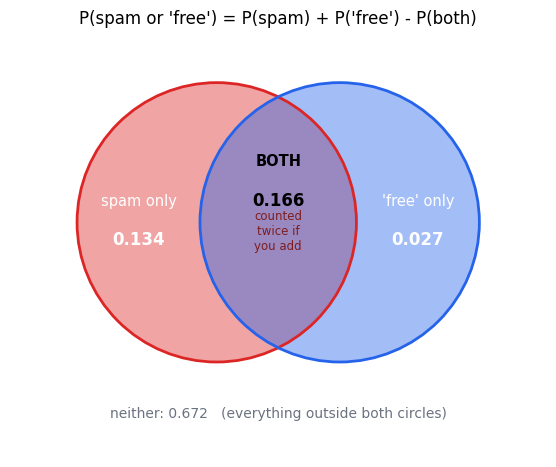

P(spam)                       = 0.3008
P('free')                     = 0.1938
P(both)                       = 0.1664
naive addition P(A) + P(B)    = 0.4946   <- too big
minus the overlap             = 0.3281
counted directly, P(A or B)   = 0.3281

P(spam or 'free')                  rule  0.3281   counted  0.3281   gap 0.0000   agree
naive addition                     rule  0.4946   counted  0.3281   gap 0.1665   *** DISAGREE ***


np.False_

In [12]:
# ============================================================
#  Inclusion-exclusion, drawn and then counted.
# ============================================================
A, B = inbox["spam"], inbox["free"]
pA, pB       = A.mean(), B.mean()
p_both       = (A & B).mean()
p_either     = (A | B).mean()
p_naive      = pA + pB

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.add_patch(plt.Circle((-0.55, 0), 1.25, facecolor=C_SLOPE, alpha=0.42, lw=0))
ax.add_patch(plt.Circle(( 0.55, 0), 1.25, facecolor=C_F,     alpha=0.42, lw=0))
ax.add_patch(plt.Circle((-0.55, 0), 1.25, facecolor="none", edgecolor=C_SLOPE, lw=2))
ax.add_patch(plt.Circle(( 0.55, 0), 1.25, facecolor="none", edgecolor=C_F,     lw=2))

ax.text(-1.25, 0.15, "spam only", ha="center", fontsize=10.5, color="white")
ax.text(-1.25, -0.2, f"{(A & ~B).mean():.3f}", ha="center", fontsize=12,
        color="white", weight="bold")
ax.text(1.25, 0.15, "'free' only", ha="center", fontsize=10.5, color="white")
ax.text(1.25, -0.2, f"{(~A & B).mean():.3f}", ha="center", fontsize=12,
        color="white", weight="bold")
ax.text(0, 0.5, "BOTH", ha="center", fontsize=10.5, weight="bold")
ax.text(0, 0.15, f"{p_both:.3f}", ha="center", fontsize=12, weight="bold")
ax.text(0, -0.25, "counted\ntwice if\nyou add", ha="center", fontsize=8.5,
        color="#7f1d1d")
ax.text(0, -1.75, f"neither: {(~A & ~B).mean():.3f}   (everything outside both circles)",
        ha="center", fontsize=10, color=C_GREY)

ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.1, 1.7)
ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)
ax.set_title("P(spam or 'free') = P(spam) + P('free') - P(both)", fontsize=12)
plt.tight_layout(); plt.show()

print(f"P(spam)                       = {pA:.4f}")
print(f"P('free')                     = {pB:.4f}")
print(f"P(both)                       = {p_both:.4f}")
print(f"naive addition P(A) + P(B)    = {p_naive:.4f}   <- too big")
print(f"minus the overlap             = {p_naive - p_both:.4f}")
print(f"counted directly, P(A or B)   = {p_either:.4f}")
print()
confirm("P(spam or 'free')", p_naive - p_both, p_either)
confirm("naive addition", p_naive, p_either)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two overlapping sets, with the actual inbox shares written inside each region. Adding the two circles means adding the middle in twice, once as part of the left circle and once as part of the right — so the naive sum printed below the figure overshoots the counted answer by precisely the value in the middle.

The four regions are worth naming, because Part 8 will use exactly this decomposition: spam-only, free-only, both, and neither. They do not overlap, and their four shares add to one — every email lands in exactly one of them.

**The common misread:** taking 'both' to be the small region and therefore the unimportant one. It is the region carrying all the information — it is the one whose size differs from what independence would have predicted, and in Part 4 it is what makes the word 'free' evidence of spam at all. The overlap is the whole story; the correction term is just where it first shows up.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**P(A or B) = P(A) + P(B) - P(A and B).**

In words: *count everything in A, count everything in B, then subtract the part you counted twice.*

Unlike the multiplication rule, this one has **no conditions**. It is true for any two events at all — related, unrelated, overlapping heavily or barely. If you only ever remember one formula from this part, remember this one, because the version people remember instead (just add) is wrong whenever the events can both happen.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Inclusion–exclusion matched the directly counted answer; naive addition was flagged as disagreeing. Both facts came out of the same twenty thousand emails, so there is no question of a different assumption doing the work.

It is worth confirming for yourself that the correction is *exactly* the overlap and not merely close to it: the third and fourth printed lines differ by the middle number to every decimal shown. That is because the identity is about sets, not about randomness — it would hold just as well if we were counting bricks.

</div>

## 2.3 Mutually exclusive events, and the trap of assuming it

If two events **cannot both happen**, their overlap is empty, so the correction
term is zero and the rule collapses to the third axiom from Part 1:

$$P(A \cap B) = 0 \quad\Longrightarrow\quad P(A \cup B) = P(A) + P(B)$$

Two dice cannot sum to both seven and eleven. An email cannot be both spam and
not spam. In those cases plain addition is exactly right, and that is precisely
why the habit is so hard to break: it works, sometimes, and nothing announces
when you have left the safe case.

Here is the demonstration that settles it. Roll a die seven times and ask for
the probability of at least one six. Each roll gives a six with probability one
in six, and there are seven rolls, so "add them up" gives seven sixths — a
probability **greater than one**, which is impossible on the face of it, since
no set can cover more than the whole of the sample space.

The arithmetic did not slip. The assumption did: the seven events *can* happen
together, over and over, and every combination gets counted repeatedly.


In [13]:
# ============================================================
#  (a) genuinely exclusive: addition is exactly right.
#  (b) not exclusive: addition gives a probability above 1.
# ============================================================
import itertools
pairs = list(itertools.product(range(1, 7), repeat=2))
p7 = len([p for p in pairs if sum(p) == 7]) / 36
p11 = len([p for p in pairs if sum(p) == 11]) / 36
both_at_once = len([p for p in pairs if sum(p) == 7 and sum(p) == 11]) / 36
seven_or_eleven = lambda rng, n: np.isin(rng.integers(1, 7, n) + rng.integers(1, 7, n), [7, 11])

print("(a) EXCLUSIVE -- a roll cannot total both 7 and 11")
print(f"    overlap P(7 and 11) = {both_at_once:.4f}   (empty set)")
confirm("    P(total is 7 or 11)", p7 + p11, estimate_prob(seven_or_eleven, 400_000, seed=7))

print("\n(b) NOT EXCLUSIVE -- seven rolls, at least one six")
ROLLS = 7
naive = ROLLS * (1 / 6)
truth = 1 - (5 / 6) ** ROLLS
any_six = lambda rng, n: (rng.integers(1, 7, (n, ROLLS)) == 6).any(axis=1)
counted = estimate_prob(any_six, 200_000, seed=66)
print(f"    naive addition  {ROLLS} x 1/6 = {naive:.4f}   <-- IMPOSSIBLE, exceeds 1")
confirm("    correct answer", truth, counted)
print(f"    naive addition overstates the truth by {naive - truth:.4f}")
print("    and with fewer rolls the same error lands somewhere plausible:")
for r in (3, 5):
    print(f"       {r} rolls: naive {r / 6:.4f}   truth {1 - (5 / 6) ** r:.4f}"
          f"   still wrong by {r / 6 - (1 - (5 / 6) ** r):.4f}")

print("\n(c) the same disease in the inbox: five overlapping word events")
names = ["spam", "free", "meeting", "winner", "report"]
naive_sum = sum(inbox[k].mean() for k in names)
union = np.zeros(N_EMAILS, dtype=bool)
for k in names:
    union |= inbox[k]
for k in names:
    print(f"       P({k:<8s}) = {inbox[k].mean():.4f}")
print(f"    naive sum of the five     = {naive_sum:.4f}   <-- exceeds 1")
print(f"    P(at least one), counted  = {union.mean():.4f}")


(a) EXCLUSIVE -- a roll cannot total both 7 and 11
    overlap P(7 and 11) = 0.0000   (empty set)
    P(total is 7 or 11)            rule  0.2222   counted  0.2217   gap 0.0005   agree

(b) NOT EXCLUSIVE -- seven rolls, at least one six
    naive addition  7 x 1/6 = 1.1667   <-- IMPOSSIBLE, exceeds 1
    correct answer                 rule  0.7209   counted  0.7216   gap 0.0007   agree
    naive addition overstates the truth by 0.4457
    and with fewer rolls the same error lands somewhere plausible:
       3 rolls: naive 0.5000   truth 0.4213   still wrong by 0.0787
       5 rolls: naive 0.8333   truth 0.5981   still wrong by 0.2352

(c) the same disease in the inbox: five overlapping word events
       P(spam    ) = 0.3008
       P(free    ) = 0.1938
       P(meeting ) = 0.2742
       P(winner  ) = 0.1313
       P(report  ) = 0.2338
    naive sum of the five     = 1.1340   <-- exceeds 1
    P(at least one), counted  = 0.7149


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Adding probabilities of events that are not mutually exclusive.** The seven-rolls line above prints a probability above one, and a probability above one is not a bad estimate — it is a contradiction, since it claims a part of something is bigger than the whole of it.

That impossibility is a gift, because it is *visible*. The dangerous cases are the ones where the same mistake lands somewhere plausible: five rolls instead of seven gives five sixths, which looks like an answer, and is still wrong by a wide margin. Nothing in the number tells you.

The inbox lines show it happening on real-looking data. Adding the five word probabilities gives a number above one because plenty of emails contain more than one of those words, and each such email is counted once per word it contains.

**The habit worth building:** every time you are about to add two probabilities, say out loud *'can these both happen?'* If yes, you owe the overlap a subtraction — or, far more often, you should be using the complement trick in the next section instead.

</div>

## 2.4 "At least one" is nearly always "one minus none"

Inclusion–exclusion for two events is manageable. For three it has four
correction terms. For twenty-three it is hopeless — which is exactly the
situation the birthday problem puts you in.

But look again at what went wrong in the seven-rolls case. There are a great
many ways to get *at least one* six: it could be the first roll, or the fourth,
or all seven, in any combination, and inclusion–exclusion would need every one
of those overlaps. There is exactly **one** way to get no six at all: every
roll misses. And the complement rule from Part 1 turns one into the other:

$$P(\text{at least one}) = 1 - P(\text{none})$$

If the rolls are independent, $P(\text{none})$ is a single multiplication —
each roll misses with probability five sixths, so seven rolls all miss with
probability five sixths raised to the seventh. One line, no overlaps, done.

**The birthday problem** is the famous case. In a room of $k$ people, what is
the chance that two share a birthday? Asked directly it is a nightmare of
overlapping pairs. Asked as "one minus the probability that all $k$ birthdays
are different", it is a product: the second person must avoid one taken day out
of 365, the third must avoid two, and so on:

$$P(\text{all different}) = \frac{365}{365}\cdot\frac{364}{365}\cdots
\frac{365-k+1}{365}$$

Below: that exact curve, and an independent simulation that fills rooms with
random birthdays and counts. If the algebra is right, they lie on top of each
other — and the crossing point is famously much lower than people expect.


In [14]:
# ============================================================
#  "At least one" via the complement, on dice.
# ============================================================
for r in (1, 2, 4, 7, 12):
    trial = (lambda rr: lambda rng, n:
             (rng.integers(1, 7, (n, rr)) == 6).any(axis=1))(r)
    confirm(f"P(at least one six in {r:>2d} rolls)",
            1 - (5 / 6) ** r, estimate_prob(trial, 200_000, seed=100 + r))
print("\nEach right-hand column came from counting rolls; each left-hand one")
print("from a single multiplication and a subtraction. No overlaps were needed.")


P(at least one six in  1 rolls)    rule  0.1667   counted  0.1679   gap 0.0012   agree
P(at least one six in  2 rolls)    rule  0.3056   counted  0.3037   gap 0.0019   agree
P(at least one six in  4 rolls)    rule  0.5177   counted  0.5193   gap 0.0015   agree
P(at least one six in  7 rolls)    rule  0.7209   counted  0.7195   gap 0.0014   agree
P(at least one six in 12 rolls)    rule  0.8878   counted  0.8868   gap 0.0011   agree

Each right-hand column came from counting rolls; each left-hand one
from a single multiplication and a subtraction. No overlaps were needed.


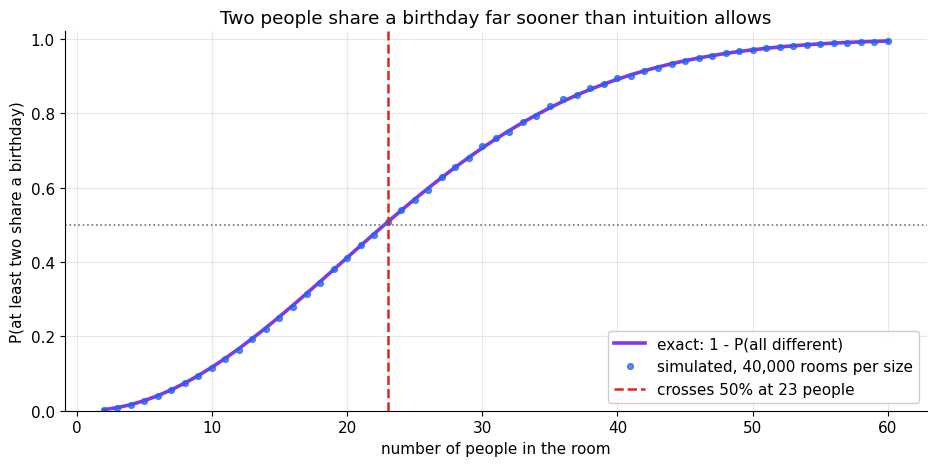

crossover from the EXACT curve      : 23 people (P = 0.5073)
crossover from the SIMULATED curve  : 23 people (P = 0.5066)
largest gap between the two curves  : 0.0049

   10 people   exact 0.1169   simulated 0.1160
   23 people   exact 0.5073   simulated 0.5066
   30 people   exact 0.7063   simulated 0.7104
   50 people   exact 0.9704   simulated 0.9698
   60 people   exact 0.9941   simulated 0.9942

a room of 23 people holds 253 PAIRS of people,
which is what the probability actually tracks -- not the people.
contrast: P(someone shares MY birthday) reaches 50% only at 253 people -- a different, far rarer question.
(that the two numbers above are both 253 is a genuine coincidence, not a bug)


In [15]:
# ============================================================
#  The birthday problem: exact curve vs simulation.
# ============================================================
DAYS, TRIALS = 365, 40_000
sizes = np.arange(2, 61)

# --- exact: 1 - P(all birthdays different) ----------------------------
exact = np.array([1 - np.prod((DAYS - np.arange(k)) / DAYS) for k in sizes])

# --- simulated: fill rooms with random birthdays and count ------------
rng = np.random.default_rng(2718)
def any_shared(k):
    """Fill TRIALS rooms of k people; True where two birthdays coincide."""
    rooms = np.sort(rng.integers(0, DAYS, (TRIALS, k)), axis=1)
    return (np.diff(rooms, axis=1) == 0).any(axis=1)

simulated = np.array([any_shared(k).mean() for k in sizes])

cross_exact = int(sizes[np.argmax(exact >= 0.5)])
cross_sim   = int(sizes[np.argmax(simulated >= 0.5)])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(sizes, exact, color=C_EXACT, lw=2.6, label="exact: 1 - P(all different)")
ax.plot(sizes, simulated, "o", color=C_F, ms=4.2, alpha=0.75,
        label=f"simulated, {TRIALS:,} rooms per size")
ax.axhline(0.5, color=C_GREY, lw=1.2, ls=":")
ax.axvline(cross_exact, color=C_SLOPE, lw=1.8, ls="--",
           label=f"crosses 50% at {cross_exact} people")
ax.set_xlabel("number of people in the room")
ax.set_ylabel("P(at least two share a birthday)")
ax.set_ylim(0, 1.02)
ax.set_title("Two people share a birthday far sooner than intuition allows")
ax.legend(loc="lower right", framealpha=0.95)
plt.tight_layout(); plt.show()

print(f"crossover from the EXACT curve      : {cross_exact} people "
      f"(P = {exact[cross_exact - 2]:.4f})")
print(f"crossover from the SIMULATED curve  : {cross_sim} people "
      f"(P = {simulated[cross_sim - 2]:.4f})")
print(f"largest gap between the two curves  : {np.abs(exact - simulated).max():.4f}")
print()
for k in (10, 23, 30, 50, 60):
    i = k - 2
    print(f"   {k:>2d} people   exact {exact[i]:.4f}   simulated {simulated[i]:.4f}")

# --- why the curve climbs so fast, and the question it is NOT answering ---
from math import comb
print(f"\na room of {cross_exact} people holds {comb(cross_exact, 2)} PAIRS of people,")
print("which is what the probability actually tracks -- not the people.")
mine = 1 - (364 / DAYS) ** np.arange(1, 800)
cross_mine = int(np.argmax(mine >= 0.5)) + 1
print(f"contrast: P(someone shares MY birthday) reaches 50% only at "
      f"{cross_mine} people -- a different, far rarer question.")
print("(that the two numbers above are both 253 is a genuine coincidence, not a bug)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The exact curve and the simulated points sit on top of each other across the whole range, and the largest disagreement is printed below the figure. Two completely different routes — a product of shrinking fractions, and forty thousand randomly filled rooms per size — arriving at the same answer.

The dashed vertical line marks where the probability passes one half, at the room size printed above. The curve is also strikingly steep: it is near zero for very small rooms, climbs through half startlingly early, and is nearly flat against one long before the room holds anything like 365 people.

**The common misread:** confusing this with 'someone shares *my* birthday', which is a completely different and much rarer question — that one needs around 253 people for even odds. The question here is about **any pair**, and the number of pairs grows as roughly half the square of the room size, which is why the curve takes off so fast. Intuition tracks the people; the probability tracks the pairs.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Both rules in this section verified twice over. The dice table put a one-line formula beside 200,000 simulated rolls at five different lengths; the birthday figure put an exact product beside 40,000 simulated rooms at each of fifty-nine room sizes, and the two curves agree to within the gap printed under the plot.

Both curves cross one half at the same room size, which is the check that matters here — a crossover is a sharper test than a curve, because it is a single number that a small systematic error would move.

And note what was avoided. The direct route to the birthday answer is inclusion–exclusion over every pair in the room, which for twenty-three people is 253 pairs and their overlaps. The complement route is one product of twenty-three fractions.

</div>

## 2.5 Three events, and why nobody does this by hand

For three events, inclusion–exclusion needs every pairwise overlap subtracted —
and then the triple overlap, which has just been subtracted three times having
been added three times, must be put back:

$$P(A \cup B \cup C) = P(A)+P(B)+P(C) - P(A\cap B) - P(A\cap C) - P(B\cap C)
+ P(A\cap B\cap C)$$

The pattern continues: add the singles, subtract the pairs, add the triples,
subtract the quadruples, alternating. For $k$ events that is $2^k - 1$ terms —
for the five inbox words, thirty-one of them; for the twenty-three birthday
people, more than eight million.

Which is the real lesson of this part. The rule is correct and worth being able
to state, but past three events nobody evaluates it directly. They reach for the
complement instead.


In [16]:
# ============================================================
#  Three-event inclusion-exclusion, verified term by term.
# ============================================================
A, B, C = inbox["spam"], inbox["free"], inbox["winner"]

singles = A.mean() + B.mean() + C.mean()
pairs_  = (A & B).mean() + (A & C).mean() + (B & C).mean()
triple  = (A & B & C).mean()
by_rule = singles - pairs_ + triple
counted = (A | B | C).mean()

print(f"  + singles (3 terms)   {singles:+.4f}")
print(f"  - pairs   (3 terms)   {-pairs_:+.4f}")
print(f"  + triple  (1 term)    {triple:+.4f}")
print(f"  {'':22s}--------")
confirm("P(spam or 'free' or 'winner')", by_rule, counted)
confirm("  naive addition instead", singles, counted)

print()
for k in (2, 3, 5, 10, 23):
    print(f"   {k:>2d} events -> {2**k - 1:>10,} terms in inclusion-exclusion")
print("\n...against ONE product for the complement. This is why 'at least one'")
print("is always attacked from the 'none' side.")


  + singles (3 terms)   +0.6259
  - pairs   (3 terms)   -0.3602
  + triple  (1 term)    +0.0689
                        --------
P(spam or 'free' or 'winner')      rule  0.3347   counted  0.3347   gap 0.0000   agree
  naive addition instead           rule  0.6259   counted  0.3347   gap 0.2913   *** DISAGREE ***

    2 events ->          3 terms in inclusion-exclusion
    3 events ->          7 terms in inclusion-exclusion
    5 events ->         31 terms in inclusion-exclusion
   10 events ->      1,023 terms in inclusion-exclusion
   23 events ->  8,388,607 terms in inclusion-exclusion

...against ONE product for the complement. This is why 'at least one'
is always attacked from the 'none' side.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The seven-term expansion reproduced the directly counted union exactly, and naive addition was flagged again. The alternating signs are not a convention someone chose — each one is repairing the double-counting left by the line above it.

The table of term counts is the practical conclusion: the rule is a definition you should recognise, not a procedure you should run.

</div>

## 2.6 Two stages, one tree

Many experiments happen in stages: something occurs, then something else occurs
given what already did. Draw the stages as a tree, and two rules make it
readable at a glance.

- **Along a path, multiply.** A path from root to tip is a sequence of things
  that all had to happen — an "and" — so its probability is the product of the
  branch numbers on it.
- **Across the tips, add.** The tips are mutually exclusive (exactly one path is
  taken) and they cover everything, so their probabilities sum to one. Printing
  that sum is a free check on the whole diagram.

The tree below has two stages: first *spam or not*, then *contains "free" or
not*. Its numbers are counted from the inbox, not assumed.

One thing to notice, because Part 3 is built on it. The second-stage branch
numbers differ depending on which first branch you took — "free" is far more
common below the spam branch than below the other one. That number, *the share
of "free" among spam specifically*, is a **conditional probability**, and
writing it $P(\text{free} \mid \text{spam})$ is the subject of the next part.
The tree is drawing it before we have named it.


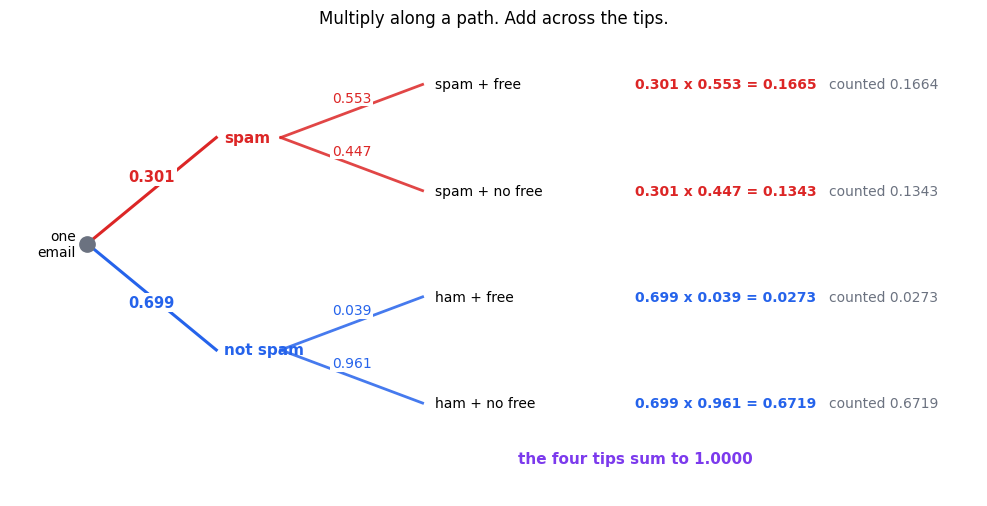

every tip: product along the path vs the same event counted directly
P(spam and free)                   rule  0.1665   counted  0.1664   gap 0.0000   agree
P(spam and no free)                rule  0.1343   counted  0.1343   gap 0.0000   agree
P(ham and free)                    rule  0.0273   counted  0.0273   gap 0.0000   agree
P(ham and no free)                 rule  0.6719   counted  0.6719   gap 0.0000   agree

sum over all four tips = 1.000000   (must be exactly 1)
branch pair at each fork sums to 1: True and True


In [17]:
# ============================================================
#  A two-stage tree, with every number counted from the inbox.
# ============================================================
A, B = inbox["spam"], inbox["free"]
p_spam, p_ham = A.mean(), (~A).mean()
p_free_g_spam = B[A].mean()          # share of 'free' AMONG spam
p_free_g_ham  = B[~A].mean()         # share of 'free' among the rest

paths = [("spam", "free",     p_spam, p_free_g_spam,     A & B,  C_SLOPE),
         ("spam", "no free",  p_spam, 1 - p_free_g_spam, A & ~B, C_SLOPE),
         ("ham",  "free",     p_ham,  p_free_g_ham,      ~A & B, C_F),
         ("ham",  "no free",  p_ham,  1 - p_free_g_ham,  ~A & ~B, C_F)]

fig, ax = plt.subplots(figsize=(10, 5.2))
ys1, ys2 = {"spam": 1.6, "ham": -1.6}, [2.4, 0.8, -0.8, -2.4]
for lab, y in ys1.items():
    ax.plot([0, 1], [0, y], color=C_SLOPE if lab == "spam" else C_F, lw=2.2)
ax.plot(0, 0, "o", ms=11, color=C_GREY)
ax.text(-0.09, 0, "one\nemail", ha="right", va="center", fontsize=10)

ax.text(0.5, 0.95, f"{p_spam:.3f}", ha="center", fontsize=10.5, color=C_SLOPE,
        weight="bold", bbox=dict(fc="white", ec="none", pad=1.5))
ax.text(0.5, -0.95, f"{p_ham:.3f}", ha="center", fontsize=10.5, color=C_F,
        weight="bold", bbox=dict(fc="white", ec="none", pad=1.5))
ax.text(1.06, 1.6, "spam", fontsize=11, color=C_SLOPE, weight="bold", va="center")
ax.text(1.06, -1.6, "not spam", fontsize=11, color=C_F, weight="bold", va="center")

total = 0.0
for (s1, s2, q1, q2, ev, colour), y2 in zip(paths, ys2):
    y1 = ys1["spam" if s1 == "spam" else "ham"]
    ax.plot([1.5, 2.6], [y1, y2], color=colour, lw=2.0, alpha=0.85)
    ax.text(2.05, (y1 + y2) / 2 + 0.14, f"{q2:.3f}", ha="center", fontsize=10,
            color=colour, bbox=dict(fc="white", ec="none", pad=1.2))
    prod = q1 * q2
    total += prod
    ax.text(2.7, y2, f"{s1} + {s2}", fontsize=10, va="center")
    ax.text(4.25, y2, f"{q1:.3f} x {q2:.3f} = {prod:.4f}", fontsize=10,
            va="center", color=colour, weight="bold")
    ax.text(5.75, y2, f"counted {ev.mean():.4f}", fontsize=10, va="center",
            color=C_GREY)

ax.text(4.25, -3.3, f"the four tips sum to {total:.4f}", ha="center",
        fontsize=11, weight="bold", color=C_EXACT)
ax.set_xlim(-0.6, 6.9); ax.set_ylim(-3.8, 3.2)
ax.axis("off"); ax.grid(False)
ax.set_title("Multiply along a path. Add across the tips.", fontsize=12)
plt.tight_layout(); plt.show()

print("every tip: product along the path vs the same event counted directly")
for s1, s2, q1, q2, ev, _ in paths:
    confirm(f"P({s1} and {s2})", q1 * q2, ev.mean())
print(f"\nsum over all four tips = {total:.6f}   (must be exactly 1)")
print(f"branch pair at each fork sums to 1: "
      f"{np.isclose(p_spam + p_ham, 1)} and "
      f"{np.isclose(p_free_g_spam + (1 - p_free_g_spam), 1)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One fork per stage. Reading left to right along any path and multiplying the branch numbers gives that tip's probability, and the right-hand column confirms each product against the same event counted straight off the inbox. The four tips sum to one, printed at the bottom — every email has to come out of exactly one tip.

The number to stare at is the second-stage branch. Its value below 'spam' is nothing like its value below 'not spam'. That gap is precisely what makes the word usable as evidence: it is why a filter can look at 'free' and revise its opinion, and it is what Part 4 turns into an actual answer.

**The common misread:** reading a second-stage branch number as a probability about emails in general. It is not — it is a share *within* the branch above it, a fraction of a fraction. Only after multiplying by the branch above does it become a statement about a randomly chosen email, which is exactly why the tips are so much smaller than the branch labels.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

The independence assumption you were just warned about is not a corner case in machine learning — it is load-bearing, and it is assumed on purpose.

**Naive Bayes**, which Part 9 builds, classifies an email by multiplying together the probability of each word given the class, exactly as if the words were independent. They are plainly not: 'free' and 'winner' travel together. The classifier assumes it anyway — that is what 'naive' names — because the alternative is estimating a probability for every possible combination of words, and with a modest vocabulary there are more combinations than atoms worth counting. The astonishing part is that it still classifies well, even though the probabilities it reports are badly overconfident. Part 9 shows both halves of that.

The same trade runs everywhere. Mini-batch gradients assume examples are drawn independently, which is why shuffling matters and why time-ordered data breaks it. Dropout multiplies independent masks. And a language model's sequence probability is a product along a path down a very deep version of the tree above — one branch per token, each conditioned on everything before it. Log-probabilities turn that product into a sum, which is where the cross-entropy loss of Part 9 comes from.

</div>

### Where Part 2 leaves you

- **AND**: multiply — *only* when the events are independent, which is a
  property to be checked, never assumed.
- **OR**: $P(A) + P(B) - P(A \cap B)$. Always true, no conditions. Plain
  addition is a special case, valid only for **mutually exclusive** events.
- Naive addition can hand you a probability above one, and the seven-rolls line
  did exactly that — an impossibility, and a gift, because it is visible.
- **"At least one" = 1 - "none"**, which is how the birthday problem becomes a
  one-line product instead of millions of overlapping terms.
- Inclusion–exclusion over $k$ events costs $2^k - 1$ terms, so nobody runs it
  past three; they take complements instead.
- **Trees**: multiply along a path, add across the tips, and the tips must sum
  to one — a free check on your arithmetic.

---

**Next.** The tree ended with a number we could draw but not yet name: the share
of emails containing "free" *among the spam ones specifically*. That is a
**conditional probability**, written $P(\text{free} \mid \text{spam})$, and it
is what turns the multiplication rule from a special case into the general one.
It is also, as Part 0 promised, where nearly every probability mistake in the
wild actually happens. Part 3.


---

# 3️⃣ Conditional probability and independence

<div style="background: linear-gradient(135deg, #3a1c71 0%, #d76d77 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The whole subject is one idea, and this is it

A probability is always a probability **relative to a set of cases you are willing to consider**. Up to now that set has been "all 20,000 emails". The moment you say *"…given that it contains the word 'free'"*, you have **thrown nineteen thousand-odd emails in the bin** and are asking your question inside what is left.

That is all the vertical bar means. Not division. Not "and". **Throw away the cases where the condition failed, then ask your question about the survivors.**

Everything else in this Part — the formula, independence, the law of total probability, and the whole of Part 4 — is bookkeeping on top of that one sentence.


</div>

By the end of this Part you will be able to filter a dataset and read a
conditional probability straight off it, get the same answer from a formula, say
precisely what it means for two things to be independent, and — the one that
matters most — never again confuse *"how often do spam emails say 'free'"* with
*"how often is an email saying 'free' spam"*. Those are different questions with
different answers, and mixing them up has put people in prison.


### 3.1 Reading the bar without any formula

We want: **among emails that contain the word "free", what fraction are spam?**

Notice this is a two-step instruction, and both steps are things you could do
with your hands and a big enough table:

1. **Restrict.** Keep only the emails containing "free". Discard the rest entirely.
2. **Count.** Of the emails you kept, what fraction are spam?

There is no algebra here at all. So let us just do it — literally, with an array
filter — before we let a formula anywhere near it.


In [18]:
# ============================================================
#  Conditioning is filtering. That is the entire idea.
# ============================================================
free_mask = inbox["free"]          # True where the email contains "free"
survivors = is_spam[free_mask]     # STEP 1: keep only those emails

n_all  = len(is_spam)
n_kept = len(survivors)

print("STEP 1 -- restrict")
print(f"  emails we started with      : {n_all:,}")
print(f"  emails containing 'free'    : {n_kept:,}")
print(f"  emails thrown away          : {n_all - n_kept:,}")
print()
print("STEP 2 -- count, inside what survived")
print(f"  of the survivors, spam      : {int(survivors.sum()):,}")
print(f"  fraction of survivors that are spam = {survivors.mean():.4f}")
print()
print("That fraction IS P(spam | 'free'). We wrote no formula to get it.")
print()
print("For contrast, the same question asked of EVERY email:")
print(f"  fraction of all emails that are spam = {is_spam.mean():.4f}")
print()
print("Knowing the word 'free' is present changed the answer a great deal.")
print("That change is the whole reason conditional probability exists.")


STEP 1 -- restrict
  emails we started with      : 20,000
  emails containing 'free'    : 3,875
  emails thrown away          : 16,125

STEP 2 -- count, inside what survived
  of the survivors, spam      : 3,329
  fraction of survivors that are spam = 0.8591

That fraction IS P(spam | 'free'). We wrote no formula to get it.

For contrast, the same question asked of EVERY email:
  fraction of all emails that are spam = 0.3008

Knowing the word 'free' is present changed the answer a great deal.
That change is the whole reason conditional probability exists.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$P(A \mid B)$ is said **"the probability of A given B"**, and it means: *look only at the cases where $B$ happened, and among those, how often does $A$ happen?*

The bar is an instruction to **shrink your world**. $B$ stops being an event you might observe and becomes the new definition of "everything". Inside that smaller world $B$ has probability 1 — it has already happened, by assumption.

Two things the bar is **not**. It is not division, though a division will show up in a moment for a reason we will derive. And it is not "and": the emails that are spam *and* say 'free' are a small slice of the whole inbox, whereas the number the cell just printed is far larger — because it is measured against a much smaller denominator.

</div>

### 3.2 A helper, so we can keep checking everything

Every claim from here on gets verified by counting, and Part 1's `confirm()` is
still how we print a rule beside a count and complain if they disagree.

But `estimate_prob()` is the wrong shape for this Part. It simulates fresh rounds
from a trial function, and conditioning means *filtering a dataset you already
have*. So we add one more tool — `p_est()` — which counts inside the 20,000-email
inbox and, optionally, filters first. Read it once: it is four lines and it does
exactly the two steps of §3.1, nothing more.


In [19]:
# ============================================================
#  p_est -- count (and optionally filter) inside the inbox.
#  Joins estimate_prob / running_estimate / confirm from Part 1
#  as the fourth tool the rest of the notebook re-uses.
# ============================================================
import numpy as np

def p_est(event, given=None):
    """Fraction of emails where `event` is True.

    event : boolean array over the 20,000 emails
    given : optional boolean array. If supplied, we FIRST discard every
            email where `given` is False, then take the fraction among
            what is left -- i.e. this returns P(event | given).
    """
    event = np.asarray(event)
    if given is None:
        return float(event.mean())
    given = np.asarray(given)
    n_kept = int(given.sum())
    if n_kept == 0:
        raise ZeroDivisionError(
            "cannot condition on an event that never happened -- there is "
            "nothing left to count (see the warning box in section 3.6)")
    return float(event[given].mean())


spam, free = inbox["spam"], inbox["free"]

print(f"P(spam)            = {p_est(spam):.4f}")
print(f"P('free')          = {p_est(free):.4f}")
print(f"P(spam AND 'free') = {p_est(spam & free):.4f}")
print(f"P(spam | 'free')   = {p_est(spam, given=free):.4f}")
print(f"P('free' | spam)   = {p_est(free, given=spam):.4f}   <-- a DIFFERENT number")
print()
print("Hold on to those last two lines. Section 3.7 is entirely about them.")


P(spam)            = 0.3008
P('free')          = 0.1938
P(spam AND 'free') = 0.1664
P(spam | 'free')   = 0.8591
P('free' | spam)   = 0.5534   <-- a DIFFERENT number

Hold on to those last two lines. Section 3.7 is entirely about them.


### 3.3 Now the formula — and why it is a division

We filtered and counted. Let us write down what we actually did, using raw
counts, where $n(\cdot)$ means "how many emails":

$$
P(A \mid B) \;=\; \frac{n(A \text{ and } B)}{n(B)}
$$

The numerator counts the survivors that are also $A$; the denominator counts all
the survivors. Now divide top and bottom by the total number of emails $n$ —
which changes nothing, since it is the same factor on both:

$$
P(A \mid B) \;=\; \frac{n(A \cap B)\,/\,n}{n(B)\,/\,n} \;=\; \frac{P(A \cap B)}{P(B)}
$$

and that is the definition you will meet in every textbook:

$$
\boxed{\,P(A \mid B) = \frac{P(A \cap B)}{P(B)}\,,\qquad P(B) > 0\,}
$$

The division is there because **you are re-scaling to a smaller world**.
$P(A \cap B)$ is measured against all 20,000 emails; you want it measured against
the ones that survived the filter, so you divide by how big that surviving world
is. Dividing by $P(B)$ is exactly the act of making $B$ the new 100%.


In [20]:
# ============================================================
#  Filtering and the formula must agree. Check it.
# ============================================================
by_filtering = p_est(spam, given=free)            # restrict, then count
by_formula   = p_est(spam & free) / p_est(free)   # P(A and B) / P(B)

print(f"by filtering the array : {by_filtering:.10f}")
print(f"by the formula         : {by_formula:.10f}")
print(f"difference             : {abs(by_filtering - by_formula):.2e}")
print()
print("Identical to floating-point noise -- not approximately, IDENTICALLY,")
print("because the formula is literally the same two counts rearranged.")
print()

# and it works whichever way round, and for compound conditions too
tests = [("spam",      spam,             "'winner'",          inbox["winner"]),
         ("'meeting'", inbox["meeting"], "not spam",          ~spam),
         ("'free'",    free,             "spam AND 'winner'", spam & inbox["winner"])]

for na, a, nb, b in tests:
    confirm(f"P({na} | {nb})", p_est(a & b) / p_est(b), p_est(a, given=b))


by filtering the array : 0.8590967742
by the formula         : 0.8590967742
difference             : 1.11e-16

Identical to floating-point noise -- not approximately, IDENTICALLY,
because the formula is literally the same two counts rearranged.

P(spam | 'winner')                 rule  0.9482   counted  0.9482   gap 0.0000   agree
P('meeting' | not spam)            rule  0.3784   counted  0.3784   gap 0.0000   agree
P('free' | spam AND 'winner')      rule  0.5536   counted  0.5536   gap 0.0000   agree


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The formula $P(A\mid B) = P(A\cap B)/P(B)$ was not asserted — it was **derived from the act of filtering**, and then both routes were computed on the same 20,000 emails and printed side by side. They agree to ten decimal places on every row, which they must, because the formula is the filter written in fractions instead of in array indices.

This matters more than it looks. From here on, whenever a formula feels arbitrary, you can go back to filtering and counting and get the same answer. The algebra is a shortcut, never an authority.

</div>

### 3.4 The picture that makes the bar click

Draw all possible outcomes as a rectangle of area 1. Any event is a region
inside it, and its probability is its area. Then conditioning on $B$ is
**zooming in until $B$ fills the frame**.

Everything below is drawn with rectangles on purpose, so that every "probability"
in the figure is an area we can compute exactly and print underneath.


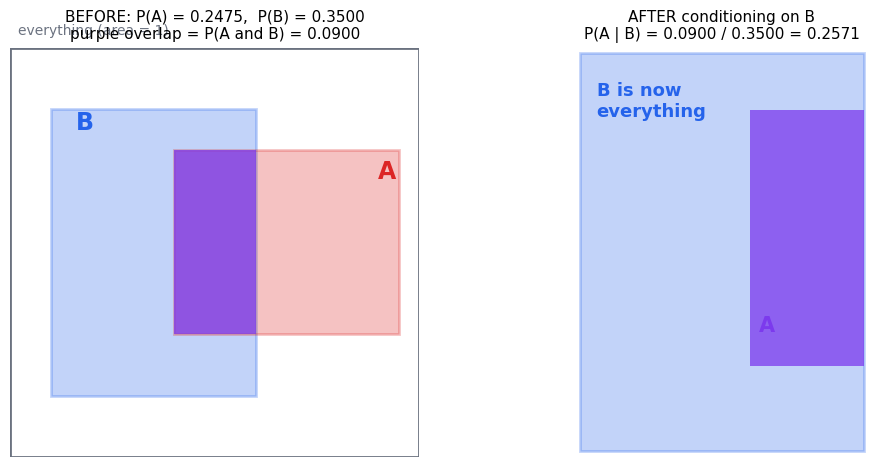

P(A and B) = 0.0900   measured against everything
P(A | B)   = 0.2571   the SAME purple patch, re-measured against B

The purple region never changed size. Only the ruler changed.


In [21]:
# ============================================================
#  Conditioning = zooming in until B is the whole picture.
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# geometry: (x, y, width, height) inside a unit square of total area 1
Bx, By, Bw, Bh = 0.10, 0.15, 0.50, 0.70
Ax, Ay, Aw, Ah = 0.40, 0.30, 0.55, 0.45
Ix, Iy = max(Ax, Bx), max(Ay, By)                       # the overlap
Iw, Ih = min(Ax + Aw, Bx + Bw) - Ix, min(Ay + Ah, By + Bh) - Iy

P_A, P_B, P_AB = Aw * Ah, Bw * Bh, Iw * Ih

fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))

# ---- left: the whole sample space
ax[0].add_patch(Rectangle((0, 0), 1, 1, fc="white", ec=C_GREY, lw=2))
ax[0].add_patch(Rectangle((Bx, By), Bw, Bh, fc=C_F,     alpha=.28, ec=C_F,     lw=2))
ax[0].add_patch(Rectangle((Ax, Ay), Aw, Ah, fc=C_SLOPE, alpha=.28, ec=C_SLOPE, lw=2))
ax[0].add_patch(Rectangle((Ix, Iy), Iw, Ih, fc=C_EXACT, alpha=.75, ec="none"))
ax[0].text(0.16, 0.80, "B", color=C_F,     fontsize=17, weight="bold")
ax[0].text(0.90, 0.68, "A", color=C_SLOPE, fontsize=17, weight="bold")
ax[0].text(0.02, 1.03, "everything (area = 1)", color=C_GREY, fontsize=10)
ax[0].set_title(f"BEFORE: P(A) = {P_A:.4f},  P(B) = {P_B:.4f}\n"
                f"purple overlap = P(A and B) = {P_AB:.4f}", fontsize=11)

# ---- right: zoom until B fills the frame
ax[1].add_patch(Rectangle((Bx, By), Bw, Bh, fc=C_F, alpha=.28, ec=C_F, lw=2))
ax[1].add_patch(Rectangle((Ix, Iy), Iw, Ih, fc=C_EXACT, alpha=.75, ec="none"))
ax[1].text(Bx + .03, By + Bh - .05, "B is now\neverything", color=C_F,
           fontsize=13, weight="bold", va="top")
ax[1].text(Ix + .015, Iy + .06, "A", color=C_EXACT, fontsize=15, weight="bold")
ax[1].set_xlim(Bx - .01, Bx + Bw + .01)
ax[1].set_ylim(By - .01, By + Bh + .01)
ax[1].set_title(f"AFTER conditioning on B\n"
                f"P(A | B) = {P_AB:.4f} / {P_B:.4f} = {P_AB / P_B:.4f}", fontsize=11)

for a in ax:
    a.set_xticks([]); a.set_yticks([]); a.grid(False); a.set_aspect("equal")
    for s in a.spines.values():
        s.set_visible(False)
plt.tight_layout(); plt.show()

print(f"P(A and B) = {P_AB:.4f}   measured against everything")
print(f"P(A | B)   = {P_AB / P_B:.4f}   the SAME purple patch, re-measured against B")
print()
print("The purple region never changed size. Only the ruler changed.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same two events, drawn twice. On the left, the outer rectangle is every possible outcome and has area 1; blue is $B$, red is $A$, and the purple overlap is $A \cap B$ — both at once.

On the right we have **conditioned on $B$**, which visually means we cropped the picture to the blue rectangle and stretched it to fill the frame. Nothing about $A$ or $B$ changed. What changed is the denominator: the purple patch is a small slice of the left picture but a substantial slice of the right one, and the printed numbers show it going from $P(A\cap B)$ up to the much larger $P(A\mid B)$.

This is why conditioning usually pushes probabilities **up**: you have shrunk the world, so whatever is still in it takes up more of the room.

**The common misread:** thinking the purple region grew. It did not — it is the identical set of outcomes with the identical area. Conditioning changes *what you divide by*, never *what happened*. If you catch yourself saying "conditioning made A more likely", say instead "conditioning made A a bigger share of a smaller world", which is the true statement and the one that keeps you out of trouble in Part 4.

</div>

### 3.5 Turning it around: the multiplication rule

The definition has a division in it. Multiply both sides by $P(B)$ and the
division vanishes:

$$
\boxed{\,P(A \cap B) \;=\; P(A \mid B)\,P(B)\,}
$$

Same statement, but now it reads as a **recipe for building a joint probability
one step at a time**: first $B$ happens, and then — in the world where $B$ has
already happened — $A$ happens.

Because it is a recipe, it chains. For three events:

$$
P(A \cap B \cap C) \;=\; P(A \mid B \cap C)\; P(B \mid C)\; P(C)
$$

Read it right to left: $C$ happens; given $C$, then $B$; given both, then $A$.
This is the **chain rule**, and it is the reason probabilistic models of
sequences — language models very much included — can be written down at all.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Multiplication rule:** the chance of two things both happening is the chance of the first, times the chance of the second *once the first has already happened*. "It rains, and then, given that it rained, the match is cancelled."

**Chain rule:** the same sentence stretched out. The probability of a whole sequence is the probability of the first thing, times the probability of the second given the first, times the third given the first two, and so on to the end. Every next-token predictor you have ever used is that sentence applied to words.

The order you take the events in is free — $P(A\cap B) = P(B\mid A)P(A)$ works just as well. Pick whichever conditional you actually happen to know. That freedom of order is not a footnote; in the next Part it becomes Bayes' theorem.

</div>

In [22]:
# ============================================================
#  Multiplication rule and chain rule, checked by counting.
# ============================================================
winner, meeting = inbox["winner"], inbox["meeting"]

print("MULTIPLICATION RULE      P(A and B) = P(A|B) P(B)")
confirm("  P(spam|'free') P('free')", p_est(spam, given=free) * p_est(free),
        p_est(spam & free))
confirm("  P('free'|spam) P(spam)", p_est(free, given=spam) * p_est(spam),
        p_est(spam & free))
print()

print("CHAIN RULE               P(A and B and C) = P(A|B,C) P(B|C) P(C)")
confirm("  three-step chain",
        (p_est(spam, given=free & winner) * p_est(free, given=winner)
         * p_est(winner)),
        p_est(spam & free & winner))
print()

# the order really is free: all 6 orderings of the same three events
import itertools
named = {"spam": spam, "'free'": free, "'winner'": winner}
print("  all 6 orderings of the chain rule give the same product:")
for order in itertools.permutations(named):
    a, b, c = (named[k] for k in order)
    print(f"    {' , '.join(order):<34} -> "
          f"{p_est(a, given=b & c) * p_est(b, given=c) * p_est(c):.6f}")


MULTIPLICATION RULE      P(A and B) = P(A|B) P(B)
  P(spam|'free') P('free')         rule  0.1664   counted  0.1664   gap 0.0000   agree
  P('free'|spam) P(spam)           rule  0.1665   counted  0.1664   gap 0.0000   agree

CHAIN RULE               P(A and B and C) = P(A|B,C) P(B|C) P(C)
  three-step chain                 rule  0.0689   counted  0.0689   gap 0.0000   agree

  all 6 orderings of the chain rule give the same product:
    spam , 'free' , 'winner'           -> 0.068950
    spam , 'winner' , 'free'           -> 0.068950
    'free' , spam , 'winner'           -> 0.068950
    'free' , 'winner' , spam           -> 0.068950
    'winner' , spam , 'free'           -> 0.068950
    'winner' , 'free' , spam           -> 0.068950


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The multiplication rule and the three-event chain rule were each computed two ways — counted straight off the array, and assembled from conditionals — and they agree to floating-point noise. All six orderings of the chain rule land on the same number too, which is the point worth taking away: the chain rule is not a claim about the world, it is a way of *keeping the books* on a joint probability, and any order of the books gives the same total.

</div>

### 3.6 Independence: when knowing $B$ tells you nothing

Everything so far has been about how learning $B$ *changes* your view of $A$.
Independence is the special case where it **does not**:

$$
\boxed{\,A \text{ and } B \text{ are independent} \iff P(A \mid B) = P(A)\,}
$$

That is the definition worth memorising, because it says what independence
*means*: **the condition was uninformative. You filtered, and the answer did not
move.**

The version in most textbooks looks different:

$$
P(A \cap B) = P(A)\,P(B)
$$

but it is the same statement. Start from the definition of the conditional and
substitute the product form:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)} = \frac{P(A)P(B)}{P(B)} = P(A)
$$

and running that algebra backwards takes you from the first definition to the
second. So the two are equivalent — but only the first one *explains* anything,
and the second is the one that is easy to compute with. Keep both, and use each
for what it is good at.


In [23]:
# ============================================================
#  Test pairs for independence -- by BOTH definitions, with an
#  honest tolerance, because these are estimates from a sample.
# ============================================================
RNG3 = np.random.default_rng(303)

# A control event, built to be independent of everything else: nothing about
# spam or wording has any say in which weekday an email happened to arrive.
tuesday = RNG3.random(N_EMAILS) < 1 / 7

pairs = [("spam",      spam,    "'free'",   free),
         ("'free'",    free,    "'winner'", winner),
         ("'meeting'", meeting, "'report'", inbox["report"]),
         ("spam",      spam,    "Tuesday",  tuesday),
         ("'free'",    free,    "Tuesday",  tuesday)]

print(f"{'A':<11}{'B':<11}{'P(A)':>9}{'P(A|B)':>9}{'P(A)P(B)':>11}"
      f"{'P(A,B)':>9}{'z':>8}  verdict")
print("-" * 80)
for na, a, nb, b in pairs:
    pa, pb = p_est(a), p_est(b)
    pa_g_b = p_est(a, given=b)
    n_b    = int(np.asarray(b).sum())
    se     = np.sqrt(pa_g_b * (1 - pa_g_b) / n_b)   # noise in P(A|B) at this n
    z      = (pa_g_b - pa) / se                     # how many std errors apart
    print(f"{na:<11}{nb:<11}{pa:>9.4f}{pa_g_b:>9.4f}{pa * pb:>11.4f}"
          f"{p_est(a & b):>9.4f}{z:>8.1f}  "
          f"{'independent' if abs(z) < 3 else 'DEPENDENT'}")

print()
print("Read the table as two independent confirmations of the same thing:")
print("  * P(A) vs P(A|B)      -- did filtering on B move the answer?")
print("  * P(A)P(B) vs P(A,B)  -- does the product form hold?")
print("They agree on every row, because the two definitions ARE one definition.")
print()
print("'Tuesday' was constructed to be unrelated to everything, and the test")
print("finds it so. Every genuine word pair comes out DEPENDENT -- and for a")
print("reason worth naming: both words lean on whether the email is spam, so")
print("each one carries news about the other. Shared causes create dependence.")


A          B               P(A)   P(A|B)   P(A)P(B)   P(A,B)       z  verdict
--------------------------------------------------------------------------------
spam       'free'        0.3008   0.8591     0.0583   0.1664    99.9  DEPENDENT
'free'     'winner'      0.1938   0.5268     0.0254   0.0692    34.2  DEPENDENT
'meeting'  'report'      0.2742   0.3556     0.0641   0.0832    11.6  DEPENDENT
spam       Tuesday       0.3008   0.3181     0.0420   0.0445     2.0  independent
'free'     Tuesday       0.1938   0.2047     0.0271   0.0286     1.4  independent

Read the table as two independent confirmations of the same thing:
  * P(A) vs P(A|B)      -- did filtering on B move the answer?
  * P(A)P(B) vs P(A,B)  -- does the product form hold?
They agree on every row, because the two definitions ARE one definition.

'Tuesday' was constructed to be unrelated to everything, and the test
finds it so. Every genuine word pair comes out DEPENDENT -- and for a
reason worth naming: both words lean 

#### Conditional independence — the one naive Bayes runs on

"'free' and 'winner' are dependent" was true *marginally*: knowing one tells you
something about spam, which in turn tells you something about the other. But what
if you **already knew** whether the email was spam? Then the news has already
been delivered, and the second word has nothing left to add.

That is **conditional independence**:

$$
P(A \mid B \cap C) = P(A \mid C)
\qquad\text{“given } C\text{, knowing } B \text{ adds nothing about } A\text{.”}
$$

It is a genuinely different claim from ordinary independence — neither one
implies the other — and it is the assumption the naive Bayes classifier is named
after.


In [24]:
# ============================================================
#  'free' and 'winner': dependent overall, independent WITHIN spam.
# ============================================================
worlds = [("all emails", np.ones(N_EMAILS, bool)),
          ("spam only",  spam),
          ("ham only",   ~spam)]

print(f"{'restricted to':<14}{'P(free)':>10}{'P(free|winner)':>16}{'gap':>9}")
print("-" * 49)
for label, world in worlds:
    p_f  = p_est(free, given=world)
    p_fw = p_est(free, given=world & winner)
    print(f"{label:<14}{p_f:>10.4f}{p_fw:>16.4f}{p_fw - p_f:>9.4f}")

print()
print("Row 1: a big gap -- knowing 'winner' appeared DOES change the odds of")
print("       'free' appearing, so overall the two words are dependent.")
print("Rows 2 and 3: the gap collapses to noise. Once you have been told")
print("       whether the email is spam, 'winner' adds nothing about 'free'.")
print()
print("So the words are dependent, but CONDITIONALLY INDEPENDENT given spam.")
print("Part 9's naive Bayes classifier assumes exactly this -- and here it is")
print("literally true, because that is how the inbox was generated.")


restricted to    P(free)  P(free|winner)      gap
-------------------------------------------------
all emails        0.1938          0.5268   0.3331
spam only         0.5534          0.5536   0.0002
ham only          0.0390          0.0368  -0.0023

Row 1: a big gap -- knowing 'winner' appeared DOES change the odds of
       'free' appearing, so overall the two words are dependent.
Rows 2 and 3: the gap collapses to noise. Once you have been told
       whether the email is spam, 'winner' adds nothing about 'free'.

So the words are dependent, but CONDITIONALLY INDEPENDENT given spam.
Part 9's naive Bayes classifier assumes exactly this -- and here it is
literally true, because that is how the inbox was generated.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Independence was tested by both of its definitions at once — did filtering move $P(A)$, and does $P(A\cap B)=P(A)P(B)$ hold — on five pairs, and the two tests agree on every row. The control event (which weekday the email arrived) was constructed to be unrelated to everything, and the test says so; every real word pair comes out dependent, which it should, since both words are influenced by whether the mail is spam.

The second cell then shows those same two words becoming independent once we restrict to spam only, or to legitimate mail only. Both facts are true simultaneously, measured on the same 20,000 emails — which is why "independent" is never a property of two events alone, but of two events *and the world you are looking at them in*.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"Independent" and "mutually exclusive" are close to opposites, and beginners swap them constantly.**

Mutually exclusive means they cannot both happen: $P(A\cap B)=0$. Independent means each tells you nothing about the other. If $A$ and $B$ are mutually exclusive and both have non-zero probability, then learning that $B$ happened tells you $A$ definitely did *not* — which is about the most informative thing a piece of news can be. So mutually exclusive events are strongly **dependent**.

**And a second one, which the next cell demonstrates rather than asserts: conditioning on something that never happens is not a number.** $P(A \mid B)$ requires $P(B) > 0$ — because the formula divides by $P(B)$, and, underneath the formula, because after filtering there is nothing left to count. In real data this arrives as an empty subgroup: you slice by six conditions at once, the last slice is empty, and whatever your code returns for it is meaningless.

</div>

In [25]:
# ============================================================
#  Conditioning on an impossible event: watch it fail.
# ============================================================
impossible = free & ~free      # "contains 'free' AND does not" -- never true

print(f"emails satisfying the impossible condition: {int(impossible.sum())}")
try:
    p_est(spam, given=impossible)
except ZeroDivisionError as e:
    print(f"p_est refused, correctly: {e}")

print()
print("Numpy, left to itself, is less principled about it:")
with np.errstate(invalid="ignore", divide="ignore"):
    print(f"  is_spam[impossible].mean() = {np.mean(is_spam[impossible])}")
print()
print("  ...a nan, out of 0/0. If that nan reaches a report as '0.0', or gets")
print("  quietly dropped by a mean() somewhere downstream, you have invented a")
print("  probability for a group that does not exist -- and nothing warned you.")


emails satisfying the impossible condition: 0
p_est refused, correctly: cannot condition on an event that never happened -- there is nothing left to count (see the warning box in section 3.6)

Numpy, left to itself, is less principled about it:
  is_spam[impossible].mean() = nan

  ...a nan, out of 0/0. If that nan reaches a report as '0.0', or gets
  quietly dropped by a mean() somewhere downstream, you have invented a
  probability for a group that does not exist -- and nothing warned you.


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


### 3.7 The trap: $P(A \mid B)$ is not $P(B \mid A)$

This is the single most consequential mistake in the whole subject, so we are
going to do it properly rather than with a warning box.

The two expressions look nearly identical. They are answers to completely
different questions:

- $P(\text{'free'} \mid \text{spam})$ — **"of the spam, how much says 'free'?"**
  The denominator is *the spam*.
- $P(\text{spam} \mid \text{'free'})$ — **"of the mail saying 'free', how much
  is spam?"** The denominator is *the mail saying 'free'*.

Different denominators, different questions, and — unless those two groups
happen to be the same size — different answers.


In [26]:
# ============================================================
#  Both directions, for every word, side by side.
# ============================================================
print(f"{'word':<10}{'P(word | spam)':>16}{'P(spam | word)':>16}{'ratio':>9}")
print("-" * 51)
for w in ["free", "meeting", "winner", "report"]:
    a = p_est(inbox[w], given=spam)      # of the spam, how much says the word
    b = p_est(spam, given=inbox[w])      # of the mail saying it, how much is spam
    print(f"{w:<10}{a:>16.4f}{b:>16.4f}{b / a:>8.2f}x")

print()
print("Not one row has the two columns equal. Every word is more telling as")
print("evidence than it is common in spam -- the right column beats the left")
print("on all four rows -- and 'winner' by more than a factor of two.")
print()
print("Now a deliberately extreme case. Suppose a word appears in 20% of spam")
print("and NEVER in legitimate mail:")

RNG3B = np.random.default_rng(3007)
smoking_gun = spam & (RNG3B.random(N_EMAILS) < 0.20)     # only ever inside spam

print(f"  P(word | spam) = {p_est(smoking_gun, given=spam):.4f}"
      "    <- most spam does NOT contain it")
print(f"  P(spam | word) = {p_est(spam, given=smoking_gun):.4f}"
      "    <- but if it IS there, the email is certainly spam")
print()
print("One fifth, and one. Same two events, same 20,000 emails, and the two")
print("conditional probabilities are about as far apart as they can get.")
print()
print("Why? Because the denominators are enormously different in size:")
print(f"  emails that are spam       : {int(spam.sum()):,}")
print(f"  emails containing the word : {int(smoking_gun.sum()):,}")
print("Dividing the same overlap by these two cannot give the same answer.")


word        P(word | spam)  P(spam | word)    ratio
---------------------------------------------------
free                0.5534          0.8591    1.55x
meeting             0.0322          0.0354    1.10x
winner              0.4141          0.9482    2.29x
report              0.0495          0.0637    1.29x

Not one row has the two columns equal. Every word is more telling as
evidence than it is common in spam -- the right column beats the left
on all four rows -- and 'winner' by more than a factor of two.

Now a deliberately extreme case. Suppose a word appears in 20% of spam
and NEVER in legitimate mail:
  P(word | spam) = 0.1898    <- most spam does NOT contain it
  P(spam | word) = 1.0000    <- but if it IS there, the email is certainly spam

One fifth, and one. Same two events, same 20,000 emails, and the two
conditional probabilities are about as far apart as they can get.

Why? Because the denominators are enormously different in size:
  emails that are spam       : 6,016
  e

#### It has a name, and it has victims

Turned around and pointed at evidence, $P(A\mid B) \ne P(B\mid A)$ is called the
**prosecutor's fallacy**.

A prosecutor tells a jury: *"the chance of this DNA match, if the defendant were
innocent, is one in a million."* That is
$P(\text{match} \mid \text{innocent})$. The jury hears: *"the chance he is
innocent is one in a million."* That is $P(\text{innocent} \mid \text{match})$ —
a different quantity entirely, and one that depends on how many people were in
the pool of possible suspects to begin with. In a city of ten million,
one-in-a-million evidence is perfectly consistent with *ten* matching people, of
whom nine are innocent.

Convictions have been overturned over exactly this swap. The same swap, wearing
medical clothes, is Part 0's question — and Part 4 is where we finally answer it.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Say the denominator out loud. Every time.**

The reliable defence here is not cleverness, it is a verbal habit. Whenever you meet a conditional probability, finish the sentence *"out of..."*:

- $P(\text{positive}\mid\text{ill})$ — "out of the **ill people**, how many test positive"
- $P(\text{ill}\mid\text{positive})$ — "out of the **people who tested positive**, how many are ill"

Once the denominator is spoken aloud the two stop sounding alike, and the question of which group is bigger — which is what drives the entire asymmetry — becomes impossible to skip over.

**The tell that you have swapped them:** your answer does not depend on how common the condition is. If a friend reports a test result and your conclusion would be identical whether the disease affects one person in ten or one in a million, you have computed the wrong direction. Hold on to that tell — the next Part is built on it.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Precision and recall are these two directions, and that is the whole reason both exist.**

- **Recall** $= P(\text{flagged} \mid \text{actually spam})$ — of the spam, how much did we catch?
- **Precision** $= P(\text{actually spam} \mid \text{flagged})$ — of what we flagged, how much really was spam?

A filter that flags every single email has perfect recall and useless precision. A filter that flags one email it is certain about has perfect precision and useless recall. Reporting one without the other is the prosecutor's fallacy wearing a lab coat, and the F1 score exists because somebody got tired of it.

The same swap runs through the fairness literature: a model can be equally accurate *given* group membership and wildly unequal *given* the prediction. Several of the well-known impossibility results are, at heart, the two directions refusing to be satisfied at the same time.

</div>

### 3.8 The law of total probability: assembling a whole from conditional parts

Often you know the conditionals and want the unconditional probability. We know
how often spam says "free" and how often legitimate mail does — so how often does
mail *in general* say "free"?

Split the world into cases that **cover everything and overlap nowhere**. Such a
split is called a **partition**. The simplest is $B$ and not-$B$. Every email
containing "free" is either spam or not, and cannot be both, so those two groups
tile the event exactly:

$$
P(A) = P(A \cap B) + P(A \cap B^c)
$$

Now rewrite each piece with the multiplication rule of §3.5:

$$
\boxed{\,P(A) = P(A \mid B)\,P(B) \;+\; P(A \mid B^c)\,P(B^c)\,}
$$

and with more pieces $B_1, \dots, B_k$ tiling the space,

$$
P(A) = \sum_{i=1}^{k} P(A \mid B_i)\,P(B_i)
$$

Nothing new has entered. This is the multiplication rule applied to each tile,
and then the tiles added up.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The law of total probability is a weighted average.** To get the overall rate of something, work out its rate inside each group, then average those rates — weighting each group by how big it is.

"Over half of spam says 'free', but spam is only 30% of the mail; almost no legitimate mail says 'free', and that is the other 70%. So overall, roughly a fifth of mail says 'free' — much closer to the legitimate-mail rate than to the spam rate, because there is so much more legitimate mail."

The weights are the whole story, and forgetting them is precisely the mistake Part 4 is about. Every group's rate gets multiplied by that group's size, so a sky-high rate inside a tiny group contributes almost nothing to the total.

</div>

In [27]:
# ============================================================
#  Law of total probability -- two-part and three-part
#  partitions, both verified against a straight count.
# ============================================================
print("TWO-PART PARTITION:  spam / not spam")
confirm("  P('free') from the 2 pieces",
        (p_est(free, given=spam) * p_est(spam)
         + p_est(free, given=~spam) * p_est(~spam)),
        p_est(free))
print()
print("  the two contributions, so you can watch the weighting do its work:")
for label, grp in [("spam", spam), ("ham ", ~spam)]:
    print(f"    {label}: rate {p_est(free, given=grp):.4f}  x  weight "
          f"{p_est(grp):.4f}  =  {p_est(free, given=grp) * p_est(grp):.4f}")
print()

print("THREE-PART PARTITION:  how many of the four words the email contains")
n_words = (free.astype(int) + winner.astype(int)
           + meeting.astype(int) + inbox["report"].astype(int))
parts = [("0 words", n_words == 0), ("1 word", n_words == 1), ("2+ words", n_words >= 2)]

# a partition must cover every email exactly once -- check that FIRST
cover = sum(g.astype(int) for _, g in parts)
print(f"  is every email in exactly one group? {bool((cover == 1).all())}")

confirm("  P(spam) from the 3 pieces",
        sum(p_est(spam, given=g) * p_est(g) for _, g in parts), p_est(spam))
print()
print(f"  {'group':<10}{'size P(Bi)':>12}{'P(spam|Bi)':>13}{'product':>10}")
print("  " + "-" * 45)
for label, g in parts:
    print(f"  {label:<10}{p_est(g):>12.4f}{p_est(spam, given=g):>13.4f}"
          f"{p_est(spam, given=g) * p_est(g):>10.4f}")


TWO-PART PARTITION:  spam / not spam
  P('free') from the 2 pieces      rule  0.1938   counted  0.1938   gap 0.0000   agree

  the two contributions, so you can watch the weighting do its work:
    spam: rate 0.5534  x  weight 0.3008  =  0.1665
    ham : rate 0.0390  x  weight 0.6992  =  0.0273

THREE-PART PARTITION:  how many of the four words the email contains
  is every email in exactly one group? True
  P(spam) from the 3 pieces        rule  0.3008   counted  0.3008   gap 0.0000   agree

  group       size P(Bi)   P(spam|Bi)   product
  ---------------------------------------------
  0 words         0.3580       0.2038    0.0730
  1 word          0.4609       0.3179    0.1465
  2+ words        0.1811       0.4492    0.0814


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Both partitions rebuild the answer exactly. The two-part one reconstructs $P(\text{'free'})$ from the spam rate and the legitimate-mail rate; the three-part one reconstructs $P(\text{spam})$ from three groups defined by how many trigger words an email contains — and the cell verifies that those three groups really do partition the inbox before using them, because the law is false the moment the groups overlap or leave someone out.

Look at the last table. The group with the highest internal spam rate is not the group contributing most to the total, because it is small. Rate and contribution are different things, and keeping them apart is the single skill Part 4 needs.

</div>

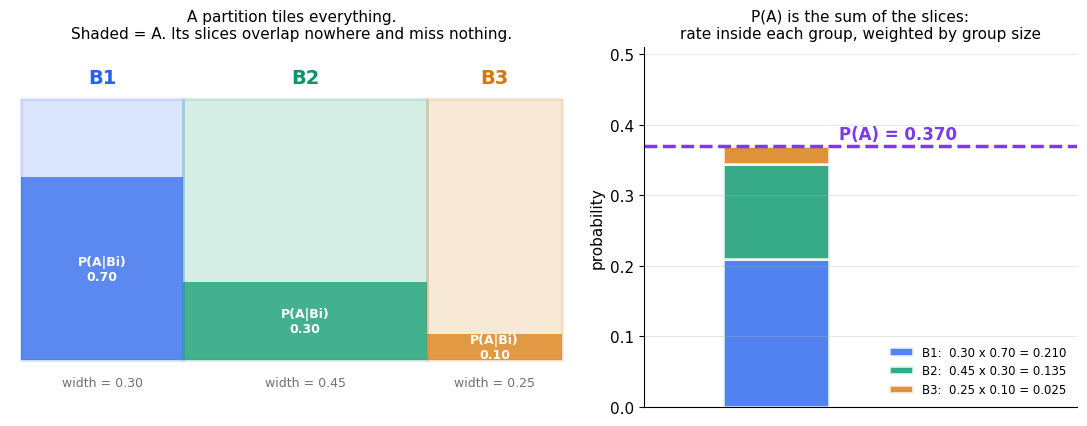

contributions : [0.21, 0.135, 0.025]
total P(A)    : 0.3700
the highest per-group rate was 0.70, inside a group of width 0.30,
contributing 0.210 of the 0.370 total.
A high rate inside a small group moves the total very little.


In [28]:
# ============================================================
#  The picture: a partition tiles the space, and A is the sum
#  of its slices.
# ============================================================
weights = [0.30, 0.45, 0.25]      # sizes of B1, B2, B3 -- they sum to 1
rates   = [0.70, 0.30, 0.10]      # P(A | Bi) inside each group

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4),
                       gridspec_kw={"width_ratios": [1.3, 1]})

# ---- left: the partition, with A as the shaded lower portion of each strip
x, cols = 0.0, [C_F, C_AREA, C_APPROX]
for i, (w, r, c) in enumerate(zip(weights, rates, cols)):
    ax[0].add_patch(Rectangle((x, 0), w, 1, fc=c, alpha=.16, ec=c, lw=2))
    ax[0].add_patch(Rectangle((x, 0), w, r, fc=c, alpha=.70, ec="none"))
    ax[0].text(x + w / 2, 1.06, f"B{i + 1}", ha="center", color=c,
               fontsize=14, weight="bold")
    ax[0].text(x + w / 2, -0.10, f"width = {w:.2f}", ha="center",
               color=C_GREY, fontsize=9)
    ax[0].text(x + w / 2, r / 2, f"P(A|Bi)\n{r:.2f}", ha="center", va="center",
               fontsize=9, color="white", weight="bold")
    x += w
ax[0].set_xlim(-0.02, 1.02); ax[0].set_ylim(-0.18, 1.20)
ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].grid(False)
for s in ax[0].spines.values():
    s.set_visible(False)
ax[0].set_title("A partition tiles everything.\n"
                "Shaded = A. Its slices overlap nowhere and miss nothing.",
                fontsize=11)

# ---- right: the same total, as a stack of weighted contributions
contrib, bottom = [w * r for w, r in zip(weights, rates)], 0.0
for i, (c, col) in enumerate(zip(contrib, cols)):
    ax[1].bar(0, c, bottom=bottom, width=.5, color=col, alpha=.80,
              edgecolor="white", lw=2,
              label=f"B{i + 1}:  {weights[i]:.2f} x {rates[i]:.2f} = {c:.3f}")
    bottom += c
ax[1].axhline(bottom, color=C_EXACT, lw=2.5, ls="--")
ax[1].text(0.30, bottom + .010, f"P(A) = {bottom:.3f}", color=C_EXACT,
           fontsize=12, weight="bold")
ax[1].set_xlim(-.62, 1.42); ax[1].set_ylim(0, bottom * 1.38)
ax[1].set_xticks([]); ax[1].set_ylabel("probability")
ax[1].legend(fontsize=8.5, loc="lower right", frameon=False)
ax[1].set_title("P(A) is the sum of the slices:\nrate inside each group, "
                "weighted by group size", fontsize=11)
plt.tight_layout(); plt.show()

biggest_rate = rates.index(max(rates))
print(f"contributions : {[round(c, 4) for c in contrib]}")
print(f"total P(A)    : {sum(contrib):.4f}")
print(f"the highest per-group rate was {max(rates):.2f}, inside a group of "
      f"width {weights[biggest_rate]:.2f},")
print(f"contributing {contrib[biggest_rate]:.3f} of the {sum(contrib):.3f} total.")
print("A high rate inside a small group moves the total very little.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: three groups $B_1, B_2, B_3$ drawn as strips whose widths are their probabilities, so together they fill the space exactly — that is what makes them a **partition**. Inside each strip, the shaded fraction of the height is $P(A \mid B_i)$, the rate of $A$ *within that group*. The event $A$ is all the shading taken together.

Right: that same shaded area, stacked. Each block is one group's contribution — width times height — and the dashed line is the total, $P(A)$. The printed numbers are those three products.

Notice that the first group has by far the highest internal rate and is still not the biggest contributor, because it is narrow.

**The common misread:** averaging the three rates without the weights. That would answer "what is the typical group's rate", which is a different question and, when the groups are very different sizes, a wildly different number. The widths are not a technicality — in Part 4, one of them is tiny, and it turns out to be the entire answer.

</div>

### 3.9 Where this leaves us

Four things, every one of them checked by counting rather than asserted:

1. **$P(A\mid B)$ is filtering.** Throw away every case where $B$ failed, then
   count $A$ among the survivors. The formula $P(A\cap B)/P(B)$ is that act
   written in fractions.
2. **$P(A \cap B) = P(A\mid B)P(B)$** — and it chains, in any order you like,
   which is how a probability over a whole sequence gets built.
3. **Independence** means the filter did not move the answer: $P(A\mid B) = P(A)$,
   equivalently $P(A\cap B) = P(A)P(B)$. Conditional independence is the same
   claim made inside a group, and it is what naive Bayes assumes.
4. **The law of total probability** rebuilds an overall rate out of per-group
   rates, each weighted by its group's size.

And one warning that is really the whole notebook in miniature: **$P(A\mid B)$
and $P(B\mid A)$ are different numbers.** We have now watched them differ by a
factor of five on the same 20,000 emails.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ➡️ Next: the formula that connects the two directions

Look at two facts we now have, sitting right next to each other:

$$P(A \cap B) = P(A \mid B)\,P(B) \qquad\text{and}\qquad P(A \cap B) = P(B \mid A)\,P(A)$$

Both describe the same quantity, so the right-hand sides are equal to each other. Set them equal, divide through by $P(B)$, and you have **Bayes' theorem** — a machine that takes the conditional direction you happen to know and hands you the one you actually wanted.

Two lines. It is the most over-mythologised formula in mathematics, and it is what finally answers the question Part 0 opened with. That is Part 4.

</div>

---


---

# 4️⃣ Bayes' theorem, derived and used

<div style="background: linear-gradient(135deg, #0f2027 0%, #2c5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The most feared formula in mathematics is two lines of Part 3

Bayes' theorem has a reputation out of all proportion to its difficulty. It gets called profound, counter-intuitive, even philosophically loaded. It is none of those things. It is the multiplication rule you already have, written twice and divided by something.

We are going to derive it in two lines to prove that point, name each of its four pieces in ordinary English, and then spend the rest of the Part on the thing that *is* genuinely hard: believing the answer it gives.

Because the answer to Part 0's question — 99% accurate test, positive result — is that you are **about 9% likely to be ill**. Not 99%. Around one in eleven. We will compute it, then simulate a million people and count them, then draw a picture of ten thousand of them so you can see with your eyes why the arithmetic is right and your intuition is wrong.


</div>

The formula is not the hard part. The hard part is the **base rate** — how common
the thing was before you tested — and how completely human intuition ignores it.


### 4.1 The derivation, in full, in two lines

From §3.5 we have the multiplication rule, and we noted there that the order is
free. So the same joint probability can be written two ways:

$$
P(A \cap B) = P(A \mid B)\,P(B)
\qquad\text{and}\qquad
P(A \cap B) = P(B \mid A)\,P(A)
$$

**Line 1.** Both equal $P(A \cap B)$, so they equal each other:

$$
P(A \mid B)\,P(B) \;=\; P(B \mid A)\,P(A)
$$

**Line 2.** Divide both sides by $P(B)$:

$$
\boxed{\;P(A \mid B) \;=\; \frac{P(B \mid A)\,P(A)}{P(B)}\;}
$$

That is Bayes' theorem, complete, with nothing omitted. It is one substitution
and one division away from a rule we derived by filtering an array.

The denominator is usually rewritten with the law of total probability from §3.8,
because $P(B)$ is the piece you rarely know directly:

$$
P(A \mid B) \;=\; \frac{P(B \mid A)\,P(A)}{P(B \mid A)\,P(A) \;+\; P(B \mid A^c)\,P(A^c)}
$$

Longer, but every symbol in it is something you can go and measure.


In [29]:
# ============================================================
#  Derived, so it must hold on the inbox. Check every word,
#  both against direct counting and against the long form.
# ============================================================
for w in ["free", "meeting", "winner", "report"]:
    b = inbox[w]

    counted = p_est(spam, given=b)                              # filter and count
    bayes   = p_est(b, given=spam) * p_est(spam) / p_est(b)     # the boxed form
    long    = (p_est(b, given=spam) * p_est(spam)               # with P(B) expanded
               / (p_est(b, given=spam) * p_est(spam)
                  + p_est(b, given=~spam) * p_est(~spam)))

    confirm(f"P(spam | '{w}')  short form", bayes, counted)
    confirm(f"P(spam | '{w}')  long form",  long,  counted)

print()
print("All three routes agree to floating-point noise on every word. They must:")
print("the derivation was two substitutions, and substitutions do not make new")
print("claims about the world.")


P(spam | 'free')  short form       rule  0.8591   counted  0.8591   gap 0.0000   agree
P(spam | 'free')  long form        rule  0.8591   counted  0.8591   gap 0.0000   agree
P(spam | 'meeting')  short form    rule  0.0354   counted  0.0354   gap 0.0000   agree
P(spam | 'meeting')  long form     rule  0.0354   counted  0.0354   gap 0.0000   agree
P(spam | 'winner')  short form     rule  0.9482   counted  0.9482   gap 0.0000   agree
P(spam | 'winner')  long form      rule  0.9482   counted  0.9482   gap 0.0000   agree
P(spam | 'report')  short form     rule  0.0637   counted  0.0637   gap 0.0000   agree
P(spam | 'report')  long form      rule  0.0637   counted  0.0637   gap 0.0000   agree

All three routes agree to floating-point noise on every word. They must:
the derivation was two substitutions, and substitutions do not make new
claims about the world.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Bayes' theorem was not introduced as a fact to be believed — it was derived from the multiplication rule in two lines, and then all four words in the inbox were run through three different routes to the same number: direct filtering, the short form, and the long form with the denominator expanded by the law of total probability. They agree to floating-point noise.

That is worth pausing on before the surprising part arrives. When the answer below feels wrong, the formula is not where the problem is — it is arithmetic we have already checked. The problem is somewhere in the intuition, and the rest of this Part goes and finds it.

</div>

### 4.2 Naming the four pieces — in English first

Bayes' theorem gets four pieces of jargon attached to it. Each is a perfectly
ordinary idea, so here is what each one *is* before we start using the word.

Set it in the situation we care about: $A$ is "you are ill", $B$ is "you tested
positive".

- **Prior** — $P(A)$. What you believed *before* the evidence arrived. Here: how
  common the disease is in the population. Sometimes called the **base rate**.
- **Likelihood** — $P(B \mid A)$. If the thing were true, how likely was the
  evidence you saw? Here: if you are ill, how often does the test say positive?
  This is the number a test manufacturer measures and prints on the box.
- **Evidence** — $P(B)$. How likely was that evidence to show up at all, from
  anyone, ill or not. Here: what fraction of everybody tested tests positive.
  It is the denominator, and its job is to make the answers add to 1.
- **Posterior** — $P(A \mid B)$. What you believe *after* the evidence. Here: the
  thing you actually want to know. Given that you tested positive, are you ill?

With the words in place:

$$
\underbrace{P(A \mid B)}_{\text{posterior}}
= \frac{\overbrace{P(B \mid A)}^{\text{likelihood}} \times \overbrace{P(A)}^{\text{prior}}}
       {\underbrace{P(B)}_{\text{evidence}}}
$$


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Bayes' theorem is how you change your mind by exactly the right amount.**

You start with a belief (the **prior**). Evidence arrives. You ask how surprising that evidence would be if your belief were true (the **likelihood**), compare it against how surprising it would be in general (the **evidence**), and you end up with an updated belief (the **posterior**).

The single most important structural fact about the formula: **the prior is multiplied in.** It never gets to be ignored. If the prior is one in a thousand, then even a wildly convincing likelihood is multiplying a very small number, and the posterior stays small. Evidence *moves* a belief; it does not *replace* it.

That one sentence is the answer to Part 0's question, and everything below is a demonstration of it.

</div>

### 4.3 Answering Part 0's question

Here is the setup, stated precisely, because "99% accurate" is a sloppy phrase
that hides two different numbers:

- The disease affects **1 person in 1,000**. That is the prior, $P(\text{ill}) = 0.001$.
- **Sensitivity 99%**: of ill people, 99% test positive.
  $P(+ \mid \text{ill}) = 0.99$.
- **Specificity 99%**: of healthy people, 99% test negative — so 1% of healthy
  people test positive anyway. $P(+ \mid \text{healthy}) = 0.01$.

You test positive. What is $P(\text{ill} \mid +)$?

Before running the cell, commit to a guess. Most people say something near 99%.
Write yours down — the gap between it and the answer is the thing this Part
exists to close.


In [30]:
# ============================================================
#  Part 0's question, computed. Every step printed.
# ============================================================
prevalence  = 0.001     # P(ill)              -- the PRIOR / base rate
sensitivity = 0.99      # P(+ | ill)          -- the LIKELIHOOD
specificity = 0.99      # P(- | healthy)
fpr         = 1 - specificity   # P(+ | healthy) -- the false positive rate

# --- numerator: the two ways to test positive, weighted by how common each is
ill_and_pos     = sensitivity * prevalence               # ill, correctly flagged
healthy_and_pos = fpr * (1 - prevalence)                 # healthy, wrongly flagged
p_positive      = ill_and_pos + healthy_and_pos          # the EVIDENCE, P(+)

posterior = ill_and_pos / p_positive                     # the POSTERIOR

print("The two routes to a positive test, per 1 person:")
print(f"  ill AND positive     = P(+|ill) P(ill)         "
      f"= {sensitivity:.2f} x {prevalence:.4f}   = {ill_and_pos:.6f}")
print(f"  healthy AND positive = P(+|healthy) P(healthy) "
      f"= {fpr:.2f} x {1 - prevalence:.4f}   = {healthy_and_pos:.6f}")
print(f"  -------------------------------------------------------------------")
print(f"  P(+) = anyone positive                                = {p_positive:.6f}")
print()
print(f"P(ill | +) = {ill_and_pos:.6f} / {p_positive:.6f} = "
      f"{posterior:.6f}   ->  {posterior * 100:.1f}%")
print()
print(f"So a positive result on a 99%-accurate test leaves you about "
      f"{posterior * 100:.0f}% likely to be ill,")
print(f"and about {(1 - posterior) * 100:.0f}% likely to be perfectly healthy.")
print()
print("Look at which of the two numerator lines is bigger. The false positives")
print(f"outnumber the true positives {healthy_and_pos / ill_and_pos:.1f} to 1 --")
print("not because the test is bad, but because healthy people are 999 times")
print("more numerous, and 1% of a huge group beats 99% of a tiny one.")


The two routes to a positive test, per 1 person:
  ill AND positive     = P(+|ill) P(ill)         = 0.99 x 0.0010   = 0.000990
  healthy AND positive = P(+|healthy) P(healthy) = 0.01 x 0.9990   = 0.009990
  -------------------------------------------------------------------
  P(+) = anyone positive                                = 0.010980

P(ill | +) = 0.000990 / 0.010980 = 0.090164   ->  9.0%

So a positive result on a 99%-accurate test leaves you about 9% likely to be ill,
and about 91% likely to be perfectly healthy.

Look at which of the two numerator lines is bigger. The false positives
outnumber the true positives 10.1 to 1 --
not because the test is bad, but because healthy people are 999 times
more numerous, and 1% of a huge group beats 99% of a tiny one.


That is an argument. Arguments can be wrong. So let us not argue — let us build a
million people, test them all, and count.


In [31]:
# ============================================================
#  A million people. Test every one. Count. No formulas.
# ============================================================
import numpy as np

RNG4 = np.random.default_rng(404)
N_PEOPLE = 1_000_000

ill = RNG4.random(N_PEOPLE) < prevalence              # who is actually ill
p_pos_each = np.where(ill, sensitivity, fpr)          # each person's chance of +
tested_pos = RNG4.random(N_PEOPLE) < p_pos_each       # who tests positive

n_ill      = int(ill.sum())
n_pos      = int(tested_pos.sum())
n_true_pos = int((ill & tested_pos).sum())
n_false_pos = n_pos - n_true_pos

print(f"people simulated              : {N_PEOPLE:,}")
print(f"  actually ill                : {n_ill:,}")
print(f"  tested positive             : {n_pos:,}")
print(f"     of those, truly ill      : {n_true_pos:,}   (true positives)")
print(f"     of those, perfectly fine : {n_false_pos:,}   (false positives)")
print()

simulated = n_true_pos / n_pos
confirm("P(ill | positive test)", posterior, simulated)
print(f"  Bayes says {posterior * 100:.2f}%, the headcount says {simulated * 100:.2f}%")
print()
print("Nobody applied a formula to those people. We generated them, tested")
print("them, and counted the ones who were both positive and ill. The answer")
print("is the same. The 9% is not an artefact of the algebra -- it is what")
print("actually happens.")


people simulated              : 1,000,000
  actually ill                : 977
  tested positive             : 10,813
     of those, truly ill      : 964   (true positives)
     of those, perfectly fine : 9,849   (false positives)

P(ill | positive test)             rule  0.0902   counted  0.0892   gap 0.0010   agree
  Bayes says 9.02%, the headcount says 8.92%

Nobody applied a formula to those people. We generated them, tested
them, and counted the ones who were both positive and ill. The answer
is the same. The 9% is not an artefact of the algebra -- it is what
actually happens.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two completely independent routes to the same number. The first applied Bayes' theorem to the three stated quantities. The second built a million simulated people, gave each one a test result drawn from their true status, and then simply counted how many of the positives were genuinely ill — no probability theory involved at any point, just a filter and a division.

They agree to two decimal places, which is as close as a sample of a million can be expected to get (only about eleven thousand of those people test positive, so that is the sample size the estimate really rests on).

If your intuition still says 99%, it is now disagreeing not with a formula but with a headcount.

</div>

### 4.4 Ten thousand people, drawn

The arithmetic is settled. The intuition still needs convincing, and for that
there is nothing better than seeing the people.

Below are 10,000 squares, one per person, in a population where 1 in 1,000 is
ill. Each is coloured by what happened to them. They are grouped rather than
scattered, purely so that the block sizes are comparable by eye.


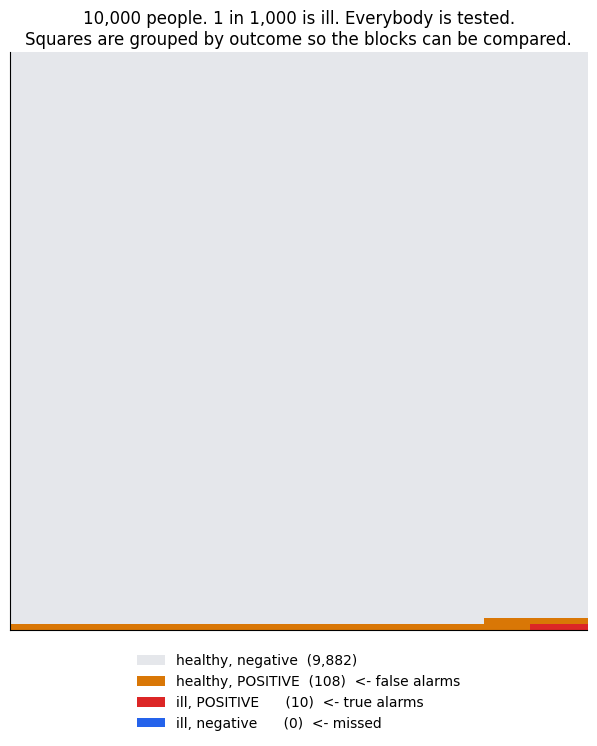

squares that lit up positive : 118
  of which genuinely ill     : 10
  of which false alarms      : 108
P(ill | +) in this grid      = 10 / 118 = 0.0847
Bayes said                   = 0.0902


In [32]:
# ============================================================
#  10,000 people, one square each, coloured by outcome.
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

RNG4B = np.random.default_rng(4040)
N_GRID = 10_000

g_ill = RNG4B.random(N_GRID) < prevalence
g_pos = RNG4B.random(N_GRID) < np.where(g_ill, sensitivity, fpr)

# 0 healthy & negative | 1 healthy & POSITIVE | 2 ill & POSITIVE | 3 ill & negative
cat = np.where(g_ill, np.where(g_pos, 2, 3), np.where(g_pos, 1, 0))
counts = [int((cat == k).sum()) for k in range(4)]

# group them so the blocks can be compared by eye (drawing order: 0,1,2,3)
grid = np.sort(cat).reshape(100, 100)

cmap = ListedColormap([C_SOFT, C_APPROX, C_SLOPE, C_F])
fig, ax = plt.subplots(figsize=(7.6, 7.6))
ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("10,000 people. 1 in 1,000 is ill. Everybody is tested.\n"
             "Squares are grouped by outcome so the blocks can be compared.",
             fontsize=12)
ax.legend(handles=[
    Patch(fc=C_SOFT,   label=f"healthy, negative  ({counts[0]:,})"),
    Patch(fc=C_APPROX, label=f"healthy, POSITIVE  ({counts[1]:,})  <- false alarms"),
    Patch(fc=C_SLOPE,  label=f"ill, POSITIVE      ({counts[2]:,})  <- true alarms"),
    Patch(fc=C_F,      label=f"ill, negative      ({counts[3]:,})  <- missed"),
], loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=10)
plt.tight_layout(); plt.show()

n_alarm = counts[1] + counts[2]
print(f"squares that lit up positive : {n_alarm:,}")
print(f"  of which genuinely ill     : {counts[2]:,}")
print(f"  of which false alarms      : {counts[1]:,}")
print(f"P(ill | +) in this grid      = {counts[2]} / {n_alarm} = "
      f"{counts[2] / n_alarm:.4f}")
print(f"Bayes said                   = {posterior:.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Ten thousand people, one square each. The vast pale block is everyone who is healthy and correctly tested negative — the overwhelming majority, and the reason the rest of the picture is so small.

The two blocks that matter are the orange and the red, because **those are the only people who get told they tested positive**. Everyone in both blocks receives the identical piece of news. The orange block — healthy people caught by the 1% false positive rate — is roughly ten times the red block of genuinely ill people, and the printed counts give the exact figures.

So "I tested positive" places you somewhere in orange-plus-red, and the large majority of the squares there are orange. The red share of that combined block *is* the posterior, and the cell prints it. The test is not bad; the test is excellent. It is simply looking for something so rare that its rare mistakes still outnumber its correct catches.

**The common misread:** looking at the tiny red block and concluding the test is broken. It caught nearly every ill person — the blue "missed" block is almost empty. The problem is not the test's error rate; it is that 1% of 9,990 healthy people is a bigger number than 99% of 10 ill ones. Change nothing about the test, make the disease ten times more common, and the red block overtakes the orange — which is exactly what the next figure sweeps through.

</div>

### 4.5 Base rate neglect

The mistake has a name: **base rate neglect** — using the likelihood and quietly
dropping the prior.

Here is the shape of it. When you are told "the test is 99% accurate", the number
you are handed is $P(+ \mid \text{ill})$: a fact about *the test*, measured on ill
people. What you want is $P(\text{ill} \mid +)$: a fact about *you*, given your
result. Part 3 was about why those are different. Bayes' theorem says the bridge
between them is the prior — and the prior is precisely the piece the story never
mentions, because it is not a property of the test at all. It is a property of the
population.

Why does intuition drop it? Because the story you get is vivid and specific — a
person, a result, a number on a box — while the base rate is an abstract fact
about a large group nobody in the story belongs to. Vividness wins. It wins in
doctors, in juries, in hiring committees and in fraud teams, and it keeps winning
after the arithmetic has been explained, which is why the working habit below
matters more than understanding the formula.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**If your answer would be the same for a common disease and a rare one, you have dropped the base rate.**

That is the field test, and it is quick enough to run in conversation. The posterior depends on the prior. If yours does not, you computed $P(\text{evidence} \mid \text{cause})$ and called it $P(\text{cause} \mid \text{evidence})$ — which is §3.7's trap in its most expensive form.

**The habit that actually works** is not to reach for the formula, it is to reach for a population. Do not ask "what is the probability". Ask **"out of 10,000 people, how many end up in each box?"** The figure above is that habit drawn. Studies find that people who fail the percentage version of this question get the counting version right, so this is not a crutch for beginners — it is the better representation, and experts use it.

**And beware the phrase "99% accurate."** It hides two numbers, sensitivity and specificity, which can be wildly different from each other, and a test can post a superb overall accuracy while being useless — as the next-but-one cell demonstrates by building exactly such a test.

</div>

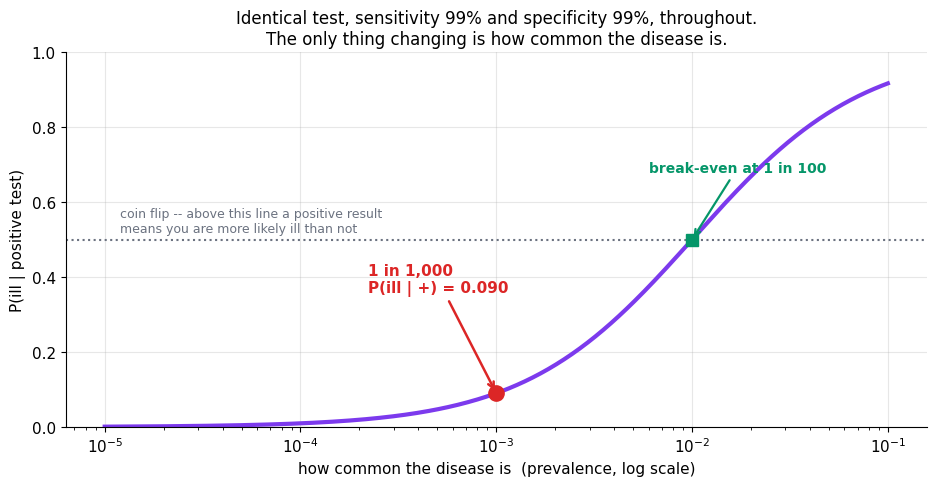

same test, same positive result, different populations:
    prevalence    P(ill | +)
----------------------------
  1 in 100,000        0.0010
   1 in 10,000        0.0098
    1 in 1,000        0.0902
      1 in 100        0.5000
       1 in 20        0.8390
       1 in 10        0.9167

break-even prevalence (where P(ill|+) hits 0.5) = 1 in 100

The test never changed. Everything you should conclude from a positive
result did. THAT is the base rate doing all the work.


In [33]:
# ============================================================
#  Sweep the base rate. Same test throughout -- only the
#  prevalence changes.
# ============================================================
prev = np.logspace(-5, -1, 400)          # 1 in 100,000  ...  1 in 10
post = (sensitivity * prev) / (sensitivity * prev + fpr * (1 - prev))

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.semilogx(prev, post, color=C_EXACT, lw=3)
ax.axhline(0.5, color=C_GREY, ls=":", lw=1.5)
ax.text(1.2e-5, 0.52, "coin flip -- above this line a positive result\n"
                      "means you are more likely ill than not",
        color=C_GREY, fontsize=9)

# mark the case we solved
ax.plot([prevalence], [posterior], "o", ms=11, color=C_SLOPE, zorder=5)
ax.annotate(f"1 in 1,000\nP(ill | +) = {posterior:.3f}",
            xy=(prevalence, posterior), xytext=(2.2e-4, 0.36),
            color=C_SLOPE, fontsize=11, weight="bold",
            arrowprops=dict(arrowstyle="->", color=C_SLOPE, lw=1.8))

# the prevalence at which a positive becomes more likely right than wrong
breakeven = fpr / (sensitivity + fpr)
ax.plot([breakeven], [0.5], "s", ms=9, color=C_AREA, zorder=5)
ax.annotate(f"break-even at 1 in {1 / breakeven:.0f}",
            xy=(breakeven, 0.5), xytext=(6e-3, 0.68),
            color=C_AREA, fontsize=10, weight="bold",
            arrowprops=dict(arrowstyle="->", color=C_AREA, lw=1.6))

ax.set_xlabel("how common the disease is  (prevalence, log scale)")
ax.set_ylabel("P(ill | positive test)")
ax.set_title("Identical test, sensitivity 99% and specificity 99%, throughout.\n"
             "The only thing changing is how common the disease is.", fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

print("same test, same positive result, different populations:")
print(f"{'prevalence':>14}{'P(ill | +)':>14}")
print("-" * 28)
for p in [1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1]:
    q = sensitivity * p / (sensitivity * p + fpr * (1 - p))
    print(f"{'1 in ' + format(int(round(1 / p)), ','):>14}{q:>14.4f}")
print()
print(f"break-even prevalence (where P(ill|+) hits 0.5) = "
      f"1 in {1 / breakeven:.0f}")
print()
print("The test never changed. Everything you should conclude from a positive")
print("result did. THAT is the base rate doing all the work.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One curve, one test. Sensitivity and specificity are pinned at 99% for every point on it — nothing about the test varies. The only thing moving along the horizontal axis is **how common the disease is in the population being tested**, from one in a hundred thousand up to one in ten.

The vertical axis is what a positive result should make you believe. It runs essentially from 0 to nearly 1. A single unchanged test, producing a single unchanged result, justifies almost any conclusion depending only on who you tested.

The red dot is Part 0's question. The green square is the break-even prevalence, printed under the figure: below it, a positive result still leaves you more likely healthy than ill.

**The common misread:** taking this as an argument against screening. It is not. It is an argument about *who* to screen and *what a positive means* — which is exactly why screening programmes target high-prevalence groups, and why a positive on a broad screen is followed by a second, different test rather than by treatment. The second test starts from the posterior of the first as its prior, and that shifted prior is what makes it decisive. That chaining is §4.7.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**This is why a 99%-accurate classifier on a rare class can be worth nothing, and the next cell builds one to prove it.**

If 1 in 1,000 transactions is fraud, the model `return "not fraud"` scores 99.9% accuracy and has never once been right about anything anyone cares about. Accuracy is dominated by the majority class, so on an imbalanced problem it measures the imbalance and almost nothing else.

Every fix in the standard toolkit is this Part restated. **Precision** is the posterior: of what the model flagged, how much was real — the orange versus red blocks in the grid. **Recall** is the likelihood direction. **Precision-recall curves** are preferred to ROC on rare classes precisely because ROC's false-positive rate hides the base rate that precision exposes. And moving a decision **threshold** is nothing but sliding along that trade-off.

The practical rule: on an imbalanced problem, ask what the model's output would be worth *if it fired*. That is a posterior, and Bayes says the prior is multiplied into it whether you thought about it or not.

</div>

In [34]:
# ============================================================
#  A 99.9%-accurate classifier that has never been right.
# ============================================================
n_test = 100_000
RNG4C  = np.random.default_rng(4041)
fraud  = RNG4C.random(n_test) < 0.001            # 1 in 1,000 is fraud

lazy = np.zeros(n_test, bool)                    # "nothing is ever fraud"
print("MODEL A -- always predicts 'not fraud'")
print(f"  accuracy          : {(lazy == fraud).mean():.5f}  <- looks superb")
print(f"  frauds caught     : {int((lazy & fraud).sum())} of {int(fraud.sum())}")
print(f"  recall            : 0.00000")
print("  precision         : undefined -- it never flags anything")
print()

# a real, genuinely good detector: 90% sensitivity, 1% false positive rate
flag = RNG4C.random(n_test) < np.where(fraud, 0.90, 0.01)
tp, fp = int((flag & fraud).sum()), int((flag & ~fraud).sum())
print("MODEL B -- a real detector: catches 90% of fraud, 1% false alarm rate")
print(f"  accuracy          : {(flag == fraud).mean():.5f}  <- LOWER than model A")
print(f"  frauds caught     : {tp} of {int(fraud.sum())}")
print(f"  recall            : {tp / int(fraud.sum()):.4f}")
print(f"  precision         : {tp / (tp + fp):.4f}   <- the posterior, P(fraud|flagged)")
print()
print("Model B is worse on accuracy and incomparably more useful. Its precision")
print("is the SAME arithmetic as the medical test: a small prior multiplied in.")
print(f"Low, but not useless -- an analyst works through about "
      f"{(tp + fp) / tp:.0f} flags per real")
print("fraud found, which is a working process. Reporting model A's accuracy")
print("instead would be reporting the base rate and calling it skill.")


MODEL A -- always predicts 'not fraud'
  accuracy          : 0.99894  <- looks superb
  frauds caught     : 0 of 106
  recall            : 0.00000
  precision         : undefined -- it never flags anything

MODEL B -- a real detector: catches 90% of fraud, 1% false alarm rate
  accuracy          : 0.98942  <- LOWER than model A
  frauds caught     : 93 of 106
  recall            : 0.8774
  precision         : 0.0817   <- the posterior, P(fraud|flagged)

Model B is worse on accuracy and incomparably more useful. Its precision
is the SAME arithmetic as the medical test: a small prior multiplied in.
Low, but not useless -- an analyst works through about 12 flags per real
fraud found, which is a working process. Reporting model A's accuracy
instead would be reporting the base rate and calling it skill.


### 4.6 Bayes on the inbox

Back to email, where we can check against 20,000 real cases rather than trusting
three stated numbers.

A spam filter faces exactly the medical problem. It knows, from training data,
how often spam uses a word — $P(\text{'free'} \mid \text{spam})$, the likelihood.
It needs the other direction: this email says "free", how likely is it spam? —
$P(\text{spam} \mid \text{'free'})$, the posterior. Bayes is the bridge, and the
prior is how much of the mail stream is spam in the first place.


In [35]:
# ============================================================
#  P(spam | word) from prior + likelihoods, vs direct counting.
# ============================================================
prior_spam = p_est(spam)          # the base rate of spam, estimated from the inbox

print(f"prior  P(spam) = {prior_spam:.4f}")
print()
posts = {}
print(f"{'word':<9}{'P(w|spam)':>12}{'P(w|ham)':>11}{'-> P(spam|w)':>15}")
print("-" * 47)
for w in ["free", "meeting", "winner", "report"]:
    b = inbox[w]
    lik_s = p_est(b, given=spam)        # likelihood under spam
    lik_h = p_est(b, given=~spam)       # likelihood under ham

    num = lik_s * prior_spam
    posts[w] = num / (num + lik_h * (1 - prior_spam))
    print(f"{w:<9}{lik_s:>12.4f}{lik_h:>11.4f}{posts[w]:>15.4f}")

print()
print("and each of those posteriors against a straight filter-and-count:")
for w, post in posts.items():
    confirm(f"  P(spam | '{w}')", post, p_est(spam, given=inbox[w]))

print()
print("Read the 'free' row across, because it is section 3.7's pair sitting")
print("in one line: the likelihood P('free'|spam) and the posterior")
print("P(spam|'free') are different numbers, and Bayes is what converts one")
print("into the other by folding in the prior.")
print()
print("'meeting' and 'report' go the other way: both are commoner in legitimate")
print("mail, so seeing them pushes the posterior BELOW the 0.30 prior. Evidence")
print("can lower a belief as well as raise it.")


prior  P(spam) = 0.3008

word        P(w|spam)   P(w|ham)   -> P(spam|w)
-----------------------------------------------
free           0.5534     0.0390         0.8591
meeting        0.0322     0.3784         0.0354
winner         0.4141     0.0097         0.9482
report         0.0495     0.3131         0.0637

and each of those posteriors against a straight filter-and-count:
  P(spam | 'free')                 rule  0.8591   counted  0.8591   gap 0.0000   agree
  P(spam | 'meeting')              rule  0.0354   counted  0.0354   gap 0.0000   agree
  P(spam | 'winner')               rule  0.9482   counted  0.9482   gap 0.0000   agree
  P(spam | 'report')               rule  0.0637   counted  0.0637   gap 0.0000   agree

Read the 'free' row across, because it is section 3.7's pair sitting
in one line: the likelihood P('free'|spam) and the posterior
P(spam|'free') are different numbers, and Bayes is what converts one
into the other by folding in the prior.

'meeting' and 'report' go the o

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Every word's posterior was computed twice: once by feeding the prior and the two likelihoods through Bayes' theorem, and once by filtering the 20,000 emails down to those containing the word and counting the spam among them. The errors are floating-point noise.

Note what the table shows in passing: words that are commoner in legitimate mail produce posteriors *below* the prior. Bayes handles evidence that argues against a hypothesis with the identical formula — there is no separate rule for disconfirming evidence.

</div>

### 4.7 Two pieces of evidence: yesterday's posterior is today's prior

An email contains "free" **and** "winner". Two clues. What now?

You could do it in one shot, but there is a more revealing route: apply Bayes
twice. Update on "free" to get a posterior. Then treat that posterior as your new
**prior**, and update on "winner".

$$
P(\text{spam}) \;\xrightarrow[\text{see 'free'}]{}\; P(\text{spam} \mid \text{'free'})
\;\xrightarrow[\text{see 'winner'}]{}\; P(\text{spam} \mid \text{'free}, \text{winner'})
$$

This is the sense in which Bayes is a rule for *learning*: belief is a running
total, and each new observation revises it from wherever the last one left it.
There is no privileged starting point and no final answer, only the current one.

**But it needs an assumption**, and we should be honest about it up front. To use
$P(\text{'winner'} \mid \text{spam})$ at the second step — rather than
$P(\text{'winner'} \mid \text{spam and 'free'})$ — we must assume the two words
are **conditionally independent given spam**. That is exactly the property we
measured in §3.6, and it holds here because it is how the inbox was built. Real
email is not so obliging, and Part 9 discusses what happens when the assumption
is wrong.


In [36]:
# ============================================================
#  Update twice, one word at a time, and check the result
#  against counting both words at once.
# ============================================================
def bayes_step(prior, lik_spam, lik_ham):
    """One Bayesian update. Returns the posterior."""
    num = lik_spam * prior
    return num / (num + lik_ham * (1 - prior))


belief = p_est(spam)                       # start from the base rate
print(f"start                        belief = {belief:.4f}   (the prior)")

for w in ["free", "winner"]:
    b = inbox[w]
    prev = belief
    belief = bayes_step(belief, p_est(b, given=spam), p_est(b, given=~spam))
    print(f"after seeing '{w}':".ljust(29)
          + f"belief = {belief:.4f}   (was {prev:.4f})")

print()
both = inbox["free"] & inbox["winner"]     # filter on BOTH words at once
confirm("P(spam | 'free' and 'winner')", belief, p_est(spam, given=both))
print(f"  (the direct count is over {int(both.sum()):,} emails containing both)")
print()

# order must not matter -- evidence is evidence
belief_rev = p_est(spam)
for w in ["winner", "free"]:
    b = inbox[w]
    belief_rev = bayes_step(belief_rev, p_est(b, given=spam), p_est(b, given=~spam))
print(f"same two words, opposite order : {belief_rev:.6f}")
print()
print("Two words took the belief from the base rate to near-certainty, and the")
print("order they arrived in made no difference.")
print()
print("The agreement with direct counting is NOT automatic -- it works because")
print("'free' and 'winner' are conditionally independent given spam, which")
print("section 3.6 measured. The next cell breaks that assumption on purpose.")


start                        belief = 0.3008   (the prior)
after seeing 'free':         belief = 0.8591   (was 0.3008)
after seeing 'winner':       belief = 0.9962   (was 0.8591)

P(spam | 'free' and 'winner')      rule  0.9962   counted  0.9964   gap 0.0002   agree
  (the direct count is over 1,384 emails containing both)

same two words, opposite order : 0.996162

Two words took the belief from the base rate to near-certainty, and the
order they arrived in made no difference.

The agreement with direct counting is NOT automatic -- it works because
'free' and 'winner' are conditionally independent given spam, which
section 3.6 measured. The next cell breaks that assumption on purpose.


In [37]:
# ============================================================
#  What the independence assumption is actually buying us:
#  break it and watch sequential updating go wrong.
# ============================================================
RNG4D = np.random.default_rng(4042)

# a near-duplicate of 'free' -- same word, essentially, seen twice
free_echo = np.where(inbox["free"], RNG4D.random(N_EMAILS) < 0.95,
                                    RNG4D.random(N_EMAILS) < 0.05)

print("Is the echo conditionally independent of 'free' given spam?")
print(f"  P(echo | spam)            = {p_est(free_echo, given=spam):.4f}")
print(f"  P(echo | spam and 'free') = {p_est(free_echo, given=spam & inbox['free']):.4f}")
print("  -> nowhere near equal, so NO: the assumption fails badly here.")
print()

belief = p_est(spam)
for name, b in [("'free'", inbox["free"]), ("echo", free_echo)]:
    belief = bayes_step(belief, p_est(b, given=spam), p_est(b, given=~spam))
    print(f"  after {name:<8} belief = {belief:.4f}")

truth = p_est(spam, given=inbox["free"] & free_echo)
print()
confirm("P(spam | 'free' and echo)", belief, truth)      # this one should NOT agree
print(f"  sequential updating is overconfident by {belief - truth:+.4f}")
print()
print("The second word was almost a copy of the first, so it carried barely any")
print("new information -- but naive updating counted it as a fresh, full-strength")
print("piece of evidence and pushed the belief too far. This is the characteristic")
print("failure of naive Bayes: correlated features get double-counted, and the")
print("posterior comes out overconfident. It often still RANKS cases correctly,")
print("which is why the method survives, but the probabilities are not trustworthy.")


Is the echo conditionally independent of 'free' given spam?
  P(echo | spam)            = 0.5427
  P(echo | spam and 'free') = 0.9444
  -> nowhere near equal, so NO: the assumption fails badly here.

  after 'free'   belief = 0.8591
  after echo     belief = 0.9747

P(spam | 'free' and echo)          rule  0.9747   counted  0.8569   gap 0.1178   *** DISAGREE ***
  sequential updating is overconfident by +0.1178

The second word was almost a copy of the first, so it carried barely any
new information -- but naive updating counted it as a fresh, full-strength
piece of evidence and pushed the belief too far. This is the characteristic
failure of naive Bayes: correlated features get double-counted, and the
posterior comes out overconfident. It often still RANKS cases correctly,
which is why the method survives, but the probabilities are not trustworthy.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Sequential updating was validated where its assumption holds, and shown to fail where it does not — both against direct counting on the same 20,000 emails.

With 'free' and 'winner', which §3.6 measured as conditionally independent given spam, updating twice matches counting both words at once, and the order of the two updates makes no difference. With a deliberately constructed near-duplicate of 'free', the same procedure overshoots, because it treats a repeated clue as a second independent one.

That gap is not a bug in Bayes' theorem, which is exact. It is the cost of the independence assumption we added on top of it — and it is the specific reason naive Bayes classifiers produce good rankings and badly calibrated probabilities. Part 9 builds one and measures both.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**The posterior is what a classifier's output is supposed to be.**

When a model outputs 0.87, the claim being made is a posterior: *given everything I can see about this case, the probability the label is positive is 0.87.* That is a statement with a checkable meaning — among all the cases the model scores 0.87, about 87% should turn out positive. When that holds, the model is **calibrated**.

Almost nothing gives you this for free. A softmax output is a number in $[0,1]$ that sums to 1 across classes, which makes it *shaped* like a probability without obliging it to *be* one; modern deep networks are famously overconfident, and the fix — temperature scaling, isotonic regression, Platt scaling — is a post-hoc correction fitted on held-out data.

Two consequences worth carrying forward. **Training data with a different class balance than deployment gives you a posterior computed with the wrong prior** — and since the prior is only multiplied in, you can often correct for it after the fact rather than retraining. And **a threshold of 0.5 is a decision, not a law**; the right cut depends on what a false positive costs against a false negative, which is a question about the world and not about the model.

</div>

### 4.8 Where this leaves us

- **Bayes' theorem is two lines of algebra** on the multiplication rule, and we
  derived them rather than quoting them. Its reputation is unearned; its
  consequences are not.
- **Four names, four ordinary ideas**: prior (what you believed), likelihood (how
  expected the evidence was under your hypothesis), evidence (how expected it was
  overall), posterior (what you believe now).
- **Part 0's question is answered.** A 99%-accurate test, positive result, disease
  affecting 1 in 1,000: about a 9% chance of being ill. Computed, then simulated
  on a million people, then drawn as ten thousand squares. All three agree.
- **The base rate does the work.** Same test, same result, and the sweep showed
  the honest conclusion running from near-0 to near-1 depending only on who was
  tested.
- **Belief is a running total.** Today's posterior is tomorrow's prior — provided
  the new evidence really is new, which is an assumption you can and should check.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ➡️ Next: from events to numbers

So far everything has been an **event** — it happened or it did not; spam or not, positive or negative. But most of the questions worth asking are about **quantities**: how many words does an email contain, how long until the next arrival, what does this pixel read.

Part 5 attaches numbers to random outcomes — **random variables** — and asks the first question you always want about a number: what is it *on average*? That is **expectation**, and it turns out to obey a rule so useful it barely looks like it should be true: the average of a sum is the sum of the averages, whether or not anything is independent.

</div>

---


---

# 5️⃣ Random variables and expectation

Everything so far has been about **events** — things that either happen or do
not. "This email is spam." "This email contains the word *free*." Yes or no.

But most questions we actually want to ask are about **numbers**. Not *is this
email spammy* but *how many* flag words does it contain. Not *did the model get
it right* but *how much loss did it incur*. To ask those questions we need a way
to attach a number to each outcome — and that is the whole content of the phrase
"random variable".

### A random variable is a function

Here is the definition, and it is worth reading twice because the name actively
misleads:

> A **random variable** is a rule that assigns a number to every outcome.

That is it. It is a function. Its input is an outcome (one email); its output is
a number (how many flag words that email contains). It is not random — the rule
is completely fixed and deterministic, and you could write it out on paper. It
is not a variable in the algebra sense — it does not stand for one unknown
number waiting to be solved for.

The randomness lives in *which outcome you get*, not in the function. Feed a
random outcome into a fixed function and you get a number that varies from case
to case — and calling the whole arrangement a "random variable" is a historical
accident we are stuck with.

By convention a random variable gets a **capital letter**, usually $X$ or $Y$,
and a particular value it took gets the matching **small letter**, $x$. So
$P(X = 2)$ means "the probability that the number the function produced was 2".


In [38]:
# ============================================================
#  Define a random variable on the inbox.
#
#  X = the number of the four flag words present in an email.
#      Input : one email (an outcome)
#      Output: an integer in 0, 1, 2, 3, 4
#
#  Nothing random happens in this cell. X is a fixed rule.
#  The randomness was already in the inbox.
# ============================================================
import numpy as np

WORD_LIST = list(WORDS)                      # ['free', 'meeting', 'winner', 'report']
print("flag words:", WORD_LIST)

# apply the rule to all 20,000 emails at once
X_flag = np.zeros(N_EMAILS, dtype=int)
for w in WORD_LIST:
    X_flag += inbox[w].astype(int)

# look at the first eight emails: the outcome, then the number X assigns to it
print()
print(f"{'email':>6} | {'spam?':>6} | " + " | ".join(f"{w:>8}" for w in WORD_LIST) + " |  X")
print("-" * 62)
for i in range(8):
    flags = " | ".join(f"{str(bool(inbox[w][i])):>8}" for w in WORD_LIST)
    print(f"{i:>6} | {str(bool(is_spam[i])):>6} | {flags} | {X_flag[i]:>2}")

print()
print(f"X takes the values {sorted(set(X_flag.tolist()))}")
print(f"smallest X seen: {X_flag.min()}   largest X seen: {X_flag.max()}")


flag words: ['free', 'meeting', 'winner', 'report']

 email |  spam? |     free |  meeting |   winner |   report |  X
--------------------------------------------------------------
     0 |  False |    False |    False |    False |    False |  0
     1 |   True |    False |    False |    False |    False |  0
     2 |  False |    False |    False |    False |    False |  0
     3 |  False |    False |     True |    False |    False |  1
     4 |   True |     True |    False |    False |    False |  1
     5 |  False |     True |     True |    False |    False |  2
     6 |  False |     True |    False |    False |     True |  2
     7 |  False |    False |    False |    False |    False |  0

X takes the values [0, 1, 2, 3, 4]
smallest X seen: 0   largest X seen: 4


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**$X$** is the name of the rule. Read it aloud as *the number of flag words*.

**$X_i$** (`X_flag[i]` in the code) is the number that rule produced for email number $i$. Those are just numbers — 0, 1, 2 — with nothing random left in them once the email is fixed.

**$P(X = 2)$** is read *the probability that X equals 2*, and it means: among all emails, what fraction have exactly two flag words. It is an ordinary probability of an ordinary event — the event being *the set of outcomes the rule sends to the number 2*.

That last sentence is the bridge. A random variable does not introduce new machinery; it repackages the events we already had into numbered bundles, so we can average them, add them, and plot them.

</div>

### Two kinds, and why you need two toolkits

Random variables split into two families, and the split is not bureaucratic —
it forces genuinely different mathematics.

| | **Discrete** | **Continuous** |
|---|---|---|
| Values | separated: $0, 1, 2, 3, \dots$ | a whole interval, no gaps |
| Examples | flag words in an email; heads in ten tosses; clicks per session | height; temperature; a model's predicted score; time until failure |
| Described by | a **PMF** — probability *mass* function | a **PDF** — probability *density* function |
| $P(X = x)$ | a real, positive number | **exactly zero**, always |
| To get a probability you | **add up** masses | **integrate** — take an area |

The right-hand column has a shock in it, which we will make concrete shortly:
for a continuous variable, the probability of any single exact value is zero.
Not "small". Zero. And yet the variable definitely takes *some* value every
time. Resolving that apparent contradiction is what the density is for.

Our $X$ — the flag-word count — is **discrete**, so we start there.


In [39]:
# ============================================================
#  The PMF: probability MASS function.
#  pmf(k) = P(X = k) = the fraction of emails with exactly k flag words.
#
#  Two ways to get it, and we insist they agree:
#    (1) COUNT   -- tally the 20,000 simulated emails
#    (2) DERIVE  -- work it out from the generating rules in Part 0
# ============================================================
import numpy as np

K = np.arange(0, len(WORD_LIST) + 1)          # possible values 0..4

# ---- (1) counted from the simulation
pmf_counted = np.array([(X_flag == k).mean() for k in K])

# ---- (2) derived from the true generating probabilities.
#      Within spam the four words appear independently with probabilities p_s.
#      "How many of n independent yes/no events happen" is obtained by
#      convolving [1-p, p] once per event -- polynomial multiplication.
def count_pmf(ps):
    """PMF of 'how many of these independent events occur'."""
    dist = np.array([1.0])
    for p in ps:
        dist = np.convolve(dist, [1.0 - p, p])
    return dist

p_given_spam = [WORDS[w][0] for w in WORD_LIST]
p_given_ham  = [WORDS[w][1] for w in WORD_LIST]

pmf_derived = (P_SPAM * count_pmf(p_given_spam)
               + (1 - P_SPAM) * count_pmf(p_given_ham))

print(f"{'k':>3} | {'counted P(X=k)':>15} | {'derived P(X=k)':>15} | {'gap':>9}")
print("-" * 52)
for k in K:
    print(f"{k:>3} | {pmf_counted[k]:>15.5f} | {pmf_derived[k]:>15.5f} "
          f"| {pmf_counted[k]-pmf_derived[k]:>9.5f}")

print()
print(f"counted PMF sums to : {pmf_counted.sum():.10f}")
print(f"derived PMF sums to : {pmf_derived.sum():.10f}")
print(f"largest gap between the two columns: {np.abs(pmf_counted-pmf_derived).max():.5f}")


  k |  counted P(X=k) |  derived P(X=k) |       gap
----------------------------------------------------
  0 |         0.35800 |         0.35676 |   0.00124
  1 |         0.46090 |         0.46350 |  -0.00260
  2 |         0.17115 |         0.16985 |   0.00130
  3 |         0.00985 |         0.00975 |   0.00010
  4 |         0.00010 |         0.00014 |  -0.00004

counted PMF sums to : 1.0000000000
derived PMF sums to : 1.0000000000
largest gap between the two columns: 0.00260


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two independent routes to the same table. The right-hand column never saw the 20,000 emails — it was computed from the generating probabilities alone — and the left-hand column never saw the generating probabilities, it only counted. The largest disagreement between them is printed at the bottom, and it is a few thousandths — which is the accuracy 20,000 samples buys you.

Both columns sum to 1.0000000000. For the counted version that is not really a test that could have failed: every email has *some* number of flag words between 0 and 4, so the fractions must exhaust the inbox. But it is the defining property — **a list of numbers that does not sum to 1 is not a PMF**, and when you build one yourself this is the first thing to print.

</div>

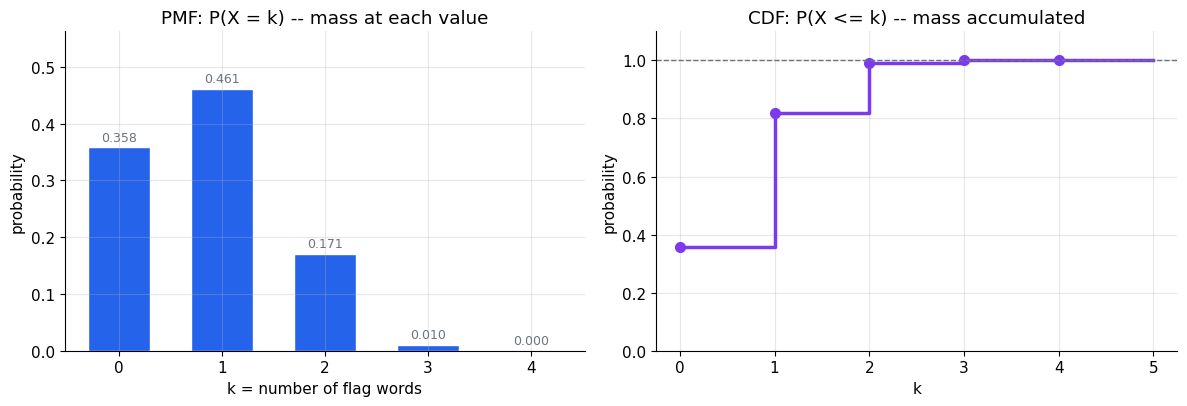

  k |   PMF bar |  CDF jump at k |  equal?
------------------------------------------
  0 |   0.35800 |        0.35800 |    True
  1 |   0.46090 |        0.46090 |    True
  2 |   0.17115 |        0.17115 |    True
  3 |   0.00985 |        0.00985 |    True
  4 |   0.00010 |        0.00010 |    True

CDF ends at 1.0000000000


In [40]:
# ============================================================
#  PMF and CDF, side by side.
#    PMF: P(X = k)     -- the height of one bar
#    CDF: P(X <= k)    -- everything at or below k, added up
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

cdf_counted = np.cumsum(pmf_counted)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].bar(K, pmf_counted, width=0.6, color=C_F, edgecolor="white")
for k in K:
    ax[0].text(k, pmf_counted[k] + 0.012, f"{pmf_counted[k]:.3f}",
               ha="center", fontsize=9, color=C_GREY)
ax[0].set_title("PMF: P(X = k) -- mass at each value")
ax[0].set_xlabel("k = number of flag words")
ax[0].set_ylabel("probability")
ax[0].set_ylim(0, pmf_counted.max() * 1.22)

ax[1].step(np.append(K, K[-1] + 1), np.append(cdf_counted, 1.0),
           where="post", color=C_EXACT, lw=2.5)
ax[1].plot(K, cdf_counted, "o", color=C_EXACT, ms=7)
ax[1].axhline(1.0, color=C_GREY, ls="--", lw=1)
ax[1].set_title("CDF: P(X <= k) -- mass accumulated")
ax[1].set_xlabel("k")
ax[1].set_ylabel("probability")
ax[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# the relationship, numerically: each jump in the CDF is exactly one PMF bar
jumps = np.diff(np.concatenate([[0.0], cdf_counted]))
print(f"{'k':>3} | {'PMF bar':>9} | {'CDF jump at k':>14} | {'equal?':>7}")
print("-" * 42)
for k in K:
    print(f"{k:>3} | {pmf_counted[k]:>9.5f} | {jumps[k]:>14.5f} "
          f"| {str(np.isclose(pmf_counted[k], jumps[k])):>7}")
print()
print(f"CDF ends at {cdf_counted[-1]:.10f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the probability mass sitting on each possible value of $X$. Most emails contain zero or one flag word; four is rare. The bars are heights — each one is a genuine probability you can read straight off the axis.

**Right:** the same information accumulated. At $k$, the curve's height is the probability that $X$ is $k$ **or anything smaller**. It only ever goes up, it starts near the bottom, and it ends at exactly 1.

The printed table is the link between them: **the size of each step in the CDF is exactly the height of the matching PMF bar.** Nothing is lost going either way — the two plots are the same object drawn twice.

**The common misread:** reading the CDF at $k=2$ as *the probability of two*. It is the probability of *two or fewer*. The CDF answers "at most" questions; the PMF answers "exactly" questions, and mixing them up silently inflates every number you compute.

</div>

### The continuous case, and the zero that surprises people

Now suppose the number is not a count but a measurement — a response time, a
temperature, a model's output score. It can be 0.5, or 0.51, or 0.5137…, with no
gaps. What is the probability it lands on **exactly** 0.5?

Zero.

Not "very small". Zero, exactly. The argument is short. There are infinitely
many possible values. If each one had the same probability $p > 0$, then adding
up even a million of them would give $1{,}000{,}000 \times p$, which exceeds 1
as soon as $p$ is bigger than one-millionth — and we have far more than a
million values available. The only number that survives is $p = 0$.

So what carries the probability? **Area.** For a continuous variable we do not
ask for the height of a bar; we ask for the area under a curve between two
values:

$$P(a \le X \le b) \;=\; \int_a^b f(x)\,dx$$

where $f$ is the **probability density function**, or PDF. The density itself is
*not* a probability — it is probability *per unit of x*, which is why it is
allowed to be bigger than 1. Only after multiplying by a width does it become a
probability.

The next cell makes this visible: a histogram of samples, with the bins getting
narrower and the sample getting bigger, settles onto a smooth curve.


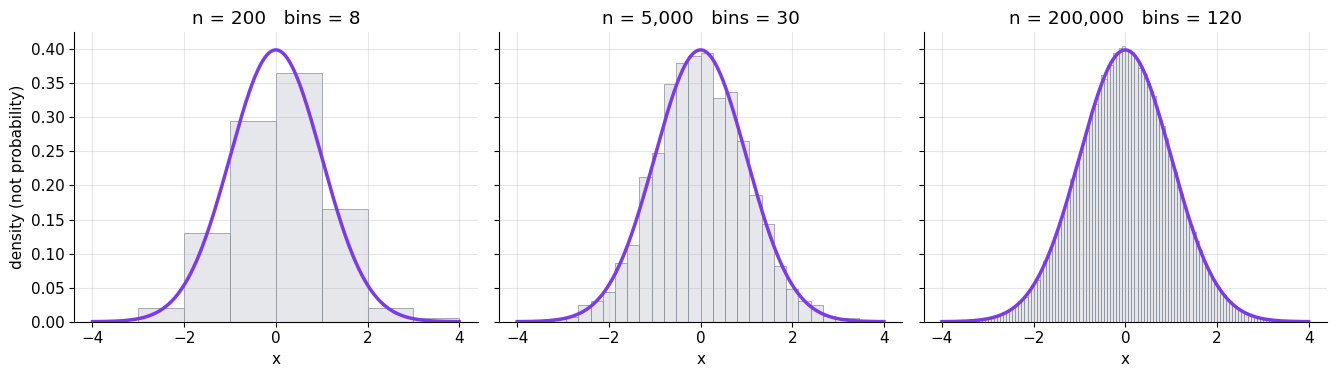

drew 2,000,000 continuous values
how many equal exactly 0.5 ............. 0
how many equal exactly 0.0 ............. 0
how many repeat any earlier value ...... 0

area under the density from 0.5 to 0.7 : 0.06657
fraction of samples in that interval   : 0.06645
gap                                    : 0.00012

peak density of a normal with sd 0.2   : 1.9947   (> 1, and legal)


In [41]:
# ============================================================
#  Watch a histogram turn into a density.
#  Same underlying variable each time -- only the sample size
#  and the bin width change.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RNG5 = np.random.default_rng(505)      # our own stream; Part 0's RNG is untouched

settings = [(200, 8), (5_000, 30), (200_000, 120)]
grid = np.linspace(-4, 4, 400)
true_pdf = stats.norm.pdf(grid, loc=0.0, scale=1.0)

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9), sharey=True)
for a, (n, bins) in zip(ax, settings):
    sample = RNG5.normal(0.0, 1.0, size=n)
    a.hist(sample, bins=bins, range=(-4, 4), density=True,
           color=C_SOFT, edgecolor=C_GREY, linewidth=0.4)
    a.plot(grid, true_pdf, color=C_EXACT, lw=2.5)
    a.set_title(f"n = {n:,}   bins = {bins}")
    a.set_xlabel("x")
ax[0].set_ylabel("density (not probability)")
plt.tight_layout()
plt.show()

# ---- the exact-value probability, checked by counting
big = RNG5.normal(0.0, 1.0, size=2_000_000)
print(f"drew {big.size:,} continuous values")
print(f"how many equal exactly 0.5 ............. {int((big == 0.5).sum())}")
print(f"how many equal exactly 0.0 ............. {int((big == 0.0).sum())}")
print(f"how many repeat any earlier value ...... {big.size - np.unique(big).size}")

# ---- but an INTERVAL has real probability: area matches the count
lo, hi = 0.5, 0.7
area = stats.norm.cdf(hi) - stats.norm.cdf(lo)     # the integral of f from lo to hi
frac = ((big >= lo) & (big <= hi)).mean()          # the honest count
print()
print(f"area under the density from {lo} to {hi} : {area:.5f}")
print(f"fraction of samples in that interval   : {frac:.5f}")
print(f"gap                                    : {abs(area-frac):.5f}")

# ---- a density can exceed 1 without anything being wrong
peak = stats.norm.pdf(0.0, loc=0.0, scale=0.2)
print()
print(f"peak density of a normal with sd 0.2   : {peak:.4f}   (> 1, and legal)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three histograms of the *same* variable. On the left, 200 values in 8 wide bins: lumpy, and the shape is only a hint. In the middle, 5,000 values in 30 bins: the bell is unmistakable. On the right, 200,000 values in 120 narrow bins: the bars have effectively become the purple curve.

That curve is the **density** — what a histogram converges to once you have enough data to afford arbitrarily narrow bins. The y-axis is labelled *density, not probability* deliberately: the printed peak for a narrow normal comes out above 1, which would be nonsense for a probability and is perfectly ordinary for a density.

The printed counts make the zero concrete: in two million draws, not one landed on exactly 0.5, not one on exactly 0.0, and no value repeated at all. Yet the *interval* from 0.5 to 0.7 collected almost exactly the fraction the area predicted.

**The common misread:** reading a height off a density plot as a probability. A density of 1.99 does not mean 199%. It means a *narrow band* of width $w$ around that point holds roughly $1.99 \times w$ of probability — the number becomes a probability only once a width is attached to it.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"The probability is zero, so it cannot happen."** For a continuous variable every single value has probability zero, and yet one of them happens on every draw. Probability zero means *negligible in the limit*, not *impossible*. This is the price of pretending a measured quantity is infinitely precise, and it is worth paying because the density machinery is so much easier than the alternative.

**"Density is probability."** It is probability *per unit of x*. Densities routinely exceed 1, and a density is not even dimensionless: change the units of $x$ from seconds to milliseconds and every density value changes by a factor of a thousand. Areas do not — which is why areas, not heights, are the things we call probabilities.

**In practice**, floating-point numbers are not really continuous, so the "no repeats in two million draws" result is a statement about 64-bit doubles being very fine-grained, not a proof. With enough draws, collisions do eventually appear.

</div>

### Expectation: the number a random variable is "worth"

Given the whole PMF, we often want to collapse it to a single summary: if this
variable paid out to you over and over, what would you make per go?

That number is the **expectation**, written $E[X]$ and said "the expectation of
X" or "the expected value of X". For a discrete variable it is defined as

$$E[X] \;=\; \sum_k k \cdot P(X = k)$$

— each possible value, multiplied by how often it occurs, all added up. A
weighted average, where the weights are probabilities. For a continuous variable
the sum becomes an integral, $E[X] = \int x\, f(x)\,dx$, and the idea is
identical.

The name is unfortunate in a way worth flagging now: the "expected" value is
frequently a value you should not expect at all. The expected number of flag
words will come out near 0.83, and no email has 0.83 flag words. $E[X]$ is a
balance point, not a prediction.


In [42]:
# ============================================================
#  E[X], three ways. They must agree.
#    (1) by hand from the derived PMF     -- the definition
#    (2) the sample mean of 20,000 emails -- the long-run average
#    (3) a shortcut using linearity       -- previewing the next section
# ============================================================
import numpy as np

# (1) the definition: sum over k of  k * P(X = k)
E_by_definition = 0.0
print("E[X] = sum of k * P(X = k):")
for k in K:
    term = k * pmf_derived[k]
    E_by_definition += term
    print(f"    k={k}:  {k} * {pmf_derived[k]:.5f} = {term:.5f}")
print(f"    ----------------------------  total = {E_by_definition:.5f}")

# (2) the long-run average: just average the 20,000 numbers
E_sample = X_flag.mean()

# (3) X is the sum of four yes/no indicators, one per word.
#     The expectation of a yes/no indicator is just its probability.
E_linearity = sum(P_SPAM * p_s + (1 - P_SPAM) * p_h
                  for p_s, p_h in (WORDS[w] for w in WORD_LIST))

print()
print(f"(1) from the PMF, by hand   : {E_by_definition:.5f}")
print(f"(2) sample mean of {N_EMAILS:,} : {E_sample:.5f}")
print(f"(3) shortcut via linearity  : {E_linearity:.5f}")
print()
print(f"definition vs shortcut  gap : {abs(E_by_definition - E_linearity):.10f}")
print(f"definition vs sample    gap : {abs(E_by_definition - E_sample):.5f}")
print()
print(f"emails that actually have {E_sample:.2f} flag words: "
      f"{int((X_flag == E_sample).sum())}")


E[X] = sum of k * P(X = k):
    k=0:  0 * 0.35676 = 0.00000
    k=1:  1 * 0.46350 = 0.46350
    k=2:  2 * 0.16985 = 0.33970
    k=3:  3 * 0.00975 = 0.02925
    k=4:  4 * 0.00014 = 0.00055
    ----------------------------  total = 0.83300

(1) from the PMF, by hand   : 0.83300
(2) sample mean of 20,000 : 0.83315
(3) shortcut via linearity  : 0.83300

definition vs shortcut  gap : 0.0000000000
definition vs sample    gap : 0.00015

emails that actually have 0.83 flag words: 0


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$E[X] = \sum_k k \cdot P(X=k)$ says: **go through every value the variable can take, multiply each value by how often it happens, and add the results up.**

It is exactly the weighted average you would use for a course grade — homework counts 30%, exam 70% — except the weights are probabilities and they are guaranteed to sum to 1, which is what keeps the result on the same scale as $X$ itself.

Routes (1) and (3) agree to ten decimal places because they are two rearrangements of the same arithmetic. Route (2) agrees to about three, because it is an estimate from a finite sample.

And the last printed line is the point about the name: **zero** emails have the expected number of flag words. The expectation is where the PMF balances if you set it on a see-saw, not a value you should expect to see.

</div>

### Linearity: the most useful rule in the subject

Two facts, and the second is the reason this section exists.

**Fact 1 — constants pull out.** For any numbers $a$ and $b$:

$$E[aX + b] \;=\; a\,E[X] + b$$

Doubling every value doubles the average; adding 5 to every value adds 5 to the
average. Unsurprising, and used constantly.

**Fact 2 — expectations of sums add, always.** For any two random variables:

$$E[X + Y] \;=\; E[X] + E[Y]$$

Read that again with the word **any**. Not "any two independent variables".
*Any two.* $X$ and $Y$ may be tangled together however you like — one may be
built out of the other, they may be perfectly correlated, one may be a
deterministic function of the other — and the rule still holds exactly.

This is genuinely surprising, and it is not a small convenience. Almost every
tractable calculation in probability and in machine learning is a sum broken
into pieces this way: the expected number of collisions in a hash table, the
expected loss over a batch, the expected reward along a trajectory. None of
those pieces are independent, and it never matters.

We check it with a pair built to be as dependent as we can make it.


In [43]:
# ============================================================
#  Linearity, checked twice: once for aX + b, once for X + Y
#  with a deliberately DEPENDENT pair.
#
#    X = number of all four flag words present   (from before)
#    Y = number of the two SPAMMY words present  (free, winner)
#  Y is literally part of X, so they are about as dependent as
#  two variables get. Linearity should not care.
# ============================================================
import numpy as np

# ---------- Fact 1: E[aX + b] = a E[X] + b
a, b = 3.0, -1.5
lhs1 = (a * X_flag + b).mean()
rhs1 = a * X_flag.mean() + b
print("Fact 1:  E[aX + b] = a E[X] + b      with a = 3.0, b = -1.5")
print(f"    E[aX + b] computed directly : {lhs1:.8f}")
print(f"    a*E[X] + b                  : {rhs1:.8f}")
print(f"    gap                         : {abs(lhs1 - rhs1):.2e}")

# ---------- Fact 2: E[X + Y] = E[X] + E[Y], with X and Y dependent
SPAMMY = ["free", "winner"]
Y_spammy = np.zeros(N_EMAILS, dtype=int)
for w in SPAMMY:
    Y_spammy += inbox[w].astype(int)

corr_XY = np.corrcoef(X_flag, Y_spammy)[0, 1]
print()
print(f"Are X and Y dependent? correlation = {corr_XY:.4f}  (0 would mean uncorrelated)")
print(f"P(Y = 2)         = {(Y_spammy == 2).mean():.4f}")
print(f"P(Y = 2 | X = 2) = {(Y_spammy[X_flag == 2] == 2).mean():.4f}   "
      f"<- different, so knowing X changes Y")

lhs2 = (X_flag + Y_spammy).mean()
rhs2 = X_flag.mean() + Y_spammy.mean()
print()
print("Fact 2:  E[X + Y] = E[X] + E[Y]      with X and Y strongly dependent")
print(f"    E[X + Y] computed directly  : {lhs2:.8f}")
print(f"    E[X] + E[Y]                 : {rhs2:.8f}")
print(f"    gap                         : {abs(lhs2 - rhs2):.2e}")

# ---------- and against the TRUE values, not just the sample
E_Y_true = sum(P_SPAM * WORDS[w][0] + (1 - P_SPAM) * WORDS[w][1] for w in SPAMMY)
print()
print(f"    true E[X] + true E[Y]       : {E_linearity + E_Y_true:.5f}")
print(f"    sample E[X + Y]             : {lhs2:.5f}")
print(f"    gap                         : {abs(E_linearity + E_Y_true - lhs2):.5f}")


Fact 1:  E[aX + b] = a E[X] + b      with a = 3.0, b = -1.5
    E[aX + b] computed directly : 0.99945000
    a*E[X] + b                  : 0.99945000
    gap                         : 0.00e+00

Are X and Y dependent? correlation = 0.5488  (0 would mean uncorrelated)
P(Y = 2)         = 0.0692
P(Y = 2 | X = 2) = 0.3681   <- different, so knowing X changes Y

Fact 2:  E[X + Y] = E[X] + E[Y]      with X and Y strongly dependent
    E[X + Y] computed directly  : 1.15825000
    E[X] + E[Y]                 : 1.15825000
    gap                         : 0.00e+00

    true E[X] + true E[Y]       : 1.15900
    sample E[X + Y]             : 1.15825
    gap                         : 0.00075


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Both gaps print as `0.00e+00`. Not "small" — the two sides agree in every bit the machine stores. $E[aX+b] = aE[X]+b$ and $E[X+Y] = E[X]+E[Y]$ are exact identities, not approximations that happen to work out.

And the dependence is real, not nominal: the printed correlation is far from zero, and $P(Y=2)$ changes substantially once you condition on $X = 2$ — which is exactly Part 3's definition of *dependent*. Linearity ignored all of it.

**Why it works, in one line:** the sample mean of a sum is the sum of the sample means, because addition can be reordered. That is all linearity of expectation is — and it is why no independence assumption appears anywhere in the argument. Hold on to that, because in Part 6 the analogous claim about *variance* turns out to be false without independence, and the contrast is the whole reason covariance exists.

</div>

### The rule that does **not** extend: $E[g(X)] \neq g(E[X])$

Linearity is so smooth that it invites over-reach. Since the expectation of a
sum is the sum of expectations, surely the expectation of a square is the square
of the expectation?

It is not. In general, for a non-linear function $g$:

$$E[g(X)] \;\neq\; g(E[X])$$

You may push $E$ through **addition** and through **multiplication by a
constant**. That is the complete list. Squaring, taking a logarithm, applying a
sigmoid, taking a maximum, dividing — none of them commute with expectation.

And the failure is not random. For a function that curves upward (like $x^2$),
$E[g(X)]$ is always the **larger** of the two; for a function that curves
downward (like $\log$), always the smaller. That systematic direction is
**Jensen's inequality**, and the size of the gap turns out to be governed by the
spread of $X$ — which is precisely what Part 6 is about.


In [44]:
# ============================================================
#  Square first, then average  vs  average first, then square.
#  Same data. Different answers.
# ============================================================
import numpy as np

E_X   = X_flag.mean()
E_X2  = (X_flag ** 2).mean()          # E[g(X)]  -- square each, then average
g_E_X = E_X ** 2                      # g(E[X])  -- average, then square

print("g(x) = x squared")
print(f"    E[X]                            = {E_X:.6f}")
print(f"    E[X^2]   (square, then average) = {E_X2:.6f}")
print(f"    (E[X])^2 (average, then square) = {g_E_X:.6f}")
print(f"    difference E[X^2] - (E[X])^2    = {E_X2 - g_E_X:.6f}")
print(f"    ratio E[X^2] / (E[X])^2         = {E_X2 / g_E_X:.4f}x")

# the same failure with a logarithm, which bends the other way
Z = 1.0 + X_flag                      # shift so the log is defined everywhere
print()
print("g(x) = log(x),  applied to 1 + X so it is always defined")
print(f"    E[log Z]   = {np.log(Z).mean():.6f}")
print(f"    log(E[Z])  = {np.log(Z.mean()):.6f}")
print(f"    difference = {np.log(Z).mean() - np.log(Z.mean()):.6f}   (negative)")

# and one where the practical stakes are obvious: averaging probabilities
p_hat = np.array([0.01, 0.99])
print()
print("Two model predictions, scored with a loss that is NOT linear:")
print(f"    predictions          : {p_hat}")
print(f"    E[-log p]  (correct) : {(-np.log(p_hat)).mean():.4f}")
print(f"    -log(E[p]) (wrong)   : {-np.log(p_hat.mean()):.4f}")
print(f"    understated by       : "
      f"{(-np.log(p_hat)).mean() + np.log(p_hat.mean()):.4f}")


g(x) = x squared
    E[X]                            = 0.833150
    E[X^2]   (square, then average) = 1.235750
    (E[X])^2 (average, then square) = 0.694139
    difference E[X^2] - (E[X])^2    = 0.541611
    ratio E[X^2] / (E[X])^2         = 1.7803x

g(x) = log(x),  applied to 1 + X so it is always defined
    E[log Z]   = 0.521315
    log(E[Z])  = 0.606036
    difference = -0.084721   (negative)

Two model predictions, scored with a loss that is NOT linear:
    predictions          : [0.01 0.99]
    E[-log p]  (correct) : 2.3076
    -log(E[p]) (wrong)   : 0.6931
    understated by       : 1.6145


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Averaging inside a non-linear function is not the same as averaging outside it, and the error is never in your favour by accident.**

Squaring curves upward, so $E[X^2]$ came out *larger* than $(E[X])^2$ — and that gap is not incidental, it is exactly the variance, which is the first thing Part 6 proves. The logarithm curves downward, so $E[\log Z]$ came out *smaller* than $\log E[Z]$.

The third block is where this bites in practice. Averaging two predicted probabilities and *then* taking the loss reports a far smaller number than taking the loss of each and averaging — the confident-and-correct prediction hides the confident-and-wrong one. Any pipeline that averages model outputs before scoring them is reporting a number that flatters the model.

**The rule to memorise:** $E$ passes through $+$ and through multiplying by a constant. Through nothing else.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Every loss you have ever minimised is an expectation.** Written out, the thing a model is actually trying to make small is

$$\mathcal{L}(\theta) \;=\; E_{(x,y)\,\sim\,\text{data}}\big[\, \ell(f_\theta(x),\, y) \,\big]$$

— the *average* loss over the distribution the data comes from. You cannot compute that expectation, because you do not have the distribution. So you substitute the sample mean over your training set, which is exactly route (2) above standing in for route (1). The entire theory of generalisation is the study of the gap between those two numbers.

**And linearity is why mini-batch training works.** The gradient of an average is the average of the gradients — a direct application of $E[X+Y] = E[X]+E[Y]$ — so a batch of 32 gives an unbiased estimate of the full-dataset gradient. No independence between examples is needed for that *unbiasedness*; independence only enters when you ask how **noisy** the estimate is, which is a variance question, which is Part 6.

</div>

### Expectation as a long-run average

There is a second way to read $E[X]$, and it is the one that makes the concept
feel real. Forget the weighted sum for a moment. Just process emails one after
another, keeping a running average of the flag-word count. That running average
does not wander forever — it settles, and what it settles on is $E[X]$.

That is the **law of large numbers** from Part 1, now stated for a random
variable rather than an event: the average of many independent draws converges
to the expectation. It is why the sample mean was a legitimate way to check the
definition a few cells ago, and why the simulate-and-count discipline of this
whole notebook is sound.

The figure below runs it three times with different arrival orders, so you can
see both halves of the story: early on the paths swing wildly and disagree with
each other, and later they are pinned to the same line.


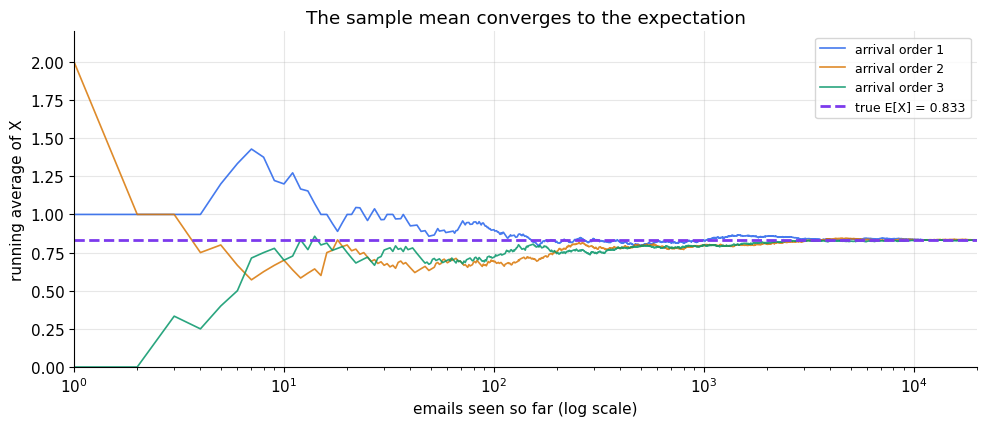

after     10 emails: running average = 0.8000   off by 0.0330
after    100 emails: running average = 0.8700   off by 0.0370
after  1,000 emails: running average = 0.8560   off by 0.0230
after 10,000 emails: running average = 0.8364   off by 0.0034
after 20,000 emails: running average = 0.8331   off by 0.0001


In [45]:
# ============================================================
#  Running average of X, watched as the sample grows.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def running_mean(v):
    return np.cumsum(v) / np.arange(1, v.size + 1)

fig, ax = plt.subplots(figsize=(10, 4.4))
shuffler = np.random.default_rng(506)
for i, colr in enumerate([C_F, C_APPROX, C_AREA]):
    order = shuffler.permutation(N_EMAILS)          # a different arrival order
    ax.plot(np.arange(1, N_EMAILS + 1), running_mean(X_flag[order]),
            color=colr, lw=1.2, alpha=0.85, label=f"arrival order {i+1}")

ax.axhline(E_linearity, color=C_EXACT, ls="--", lw=2,
           label=f"true E[X] = {E_linearity:.3f}")
ax.set_xscale("log")
ax.set_xlim(1, N_EMAILS)
ax.set_ylim(0, 2.2)
ax.set_xlabel("emails seen so far (log scale)")
ax.set_ylabel("running average of X")
ax.set_title("The sample mean converges to the expectation")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

for n in [10, 100, 1_000, 10_000, N_EMAILS]:
    m = X_flag[:n].mean()
    print(f"after {n:>6,} emails: running average = {m:.4f}   "
          f"off by {abs(m - E_linearity):.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three running averages of the same 20,000 emails, differing only in the order the emails arrive. At the left of the plot — the first ten or twenty emails — the three paths are all over the place and disagree with each other by more than the quantity being estimated. By the right-hand edge they are indistinguishable, sitting on the dashed line at the true $E[X]$.

The x-axis is logarithmic, which is the honest way to draw this: the error shrinks like $1/\sqrt{n}$, so **each further factor of 100 in data buys only about one more decimal digit.** And note in the printed table that the gaps do not shrink smoothly — 100 emails came out *worse* than 10. Convergence is a trend, not a promise about any particular $n$.

**The common misread:** seeing the flat right-hand side and concluding the average has "converged" and stopped moving. It is still moving; the log axis compresses thousands of emails into each centimetre. Zoom in on the last stretch and it still wanders — just within a narrower band.

</div>

---

### Where that leaves us

We now have the vocabulary for talking about *numbers* attached to random
outcomes:

- a **random variable** is a fixed function from outcomes to numbers;
- a **PMF** gives the probability of each value for a discrete variable, a
  **PDF** gives density — and therefore area — for a continuous one, and a
  **CDF** accumulates either;
- $E[X]$ is the probability-weighted average, equal to the long-run sample mean;
- $E$ passes straight through sums and constants — **even for dependent
  variables** — and through nothing else.

But $E[X]$ is one number standing in for an entire distribution, and one number
cannot be enough. Two inboxes could have identical average flag-word counts
while one is tightly clustered and the other swings between 0 and 4 constantly.
A model whose predictions average out correctly but are wildly unstable is not a
good model.

We need a second number: how far from the average do the values typically sit?
That is **Part 6** — and the first thing it will prove is that the gap we
already computed, $E[X^2] - (E[X])^2$, *is* that number.

---


---

# 6️⃣ Variance, spread, and why it matters

A famous line about statistics: a man with his head in the oven and his feet in
the freezer is, on average, comfortable.

The joke works because an average throws away everything except the balance
point. Part 5 spent its whole length building up to a single number, $E[X]$, and
that number is genuinely useful — but it is also genuinely, dangerously
incomplete. Two situations with the same expectation can be nothing alike.

Before defining anything, look at what an average cannot see.


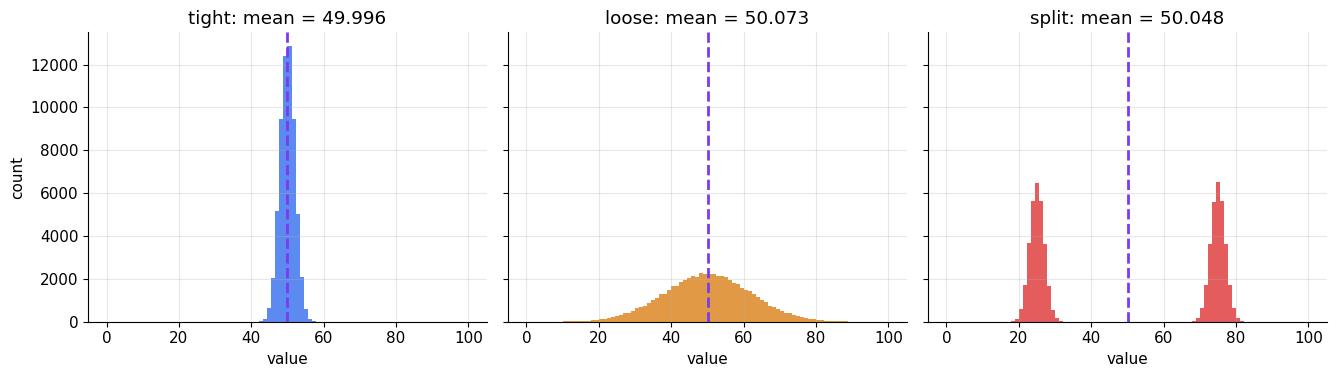

    set |     mean |      min |      max |  within 5 of mean
--------------------------------------------------------------
  tight |   49.996 |    42.10 |    58.43 |            98.8%
  loose |   50.073 |     1.07 |   104.14 |            32.6%
  split |   50.048 |    16.56 |    82.42 |             0.0%


In [46]:
# ============================================================
#  Three variables. Same mean. Nothing else in common.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

RNG6 = np.random.default_rng(606)
n = 60_000
TARGET = 50.0

tight  = RNG6.normal(TARGET, 2.0,  size=n)                  # clustered
loose  = RNG6.normal(TARGET, 12.0, size=n)                  # spread out
split   = TARGET + np.where(RNG6.random(n) < 0.5, -25.0, 25.0) \
          + RNG6.normal(0.0, 2.0, size=n)                   # two lumps, no middle

sets = [("tight",  tight,  C_F),
        ("loose",  loose,  C_APPROX),
        ("split",  split,  C_SLOPE)]

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9), sharex=True, sharey=True)
for a, (name, v, colr) in zip(ax, sets):
    a.hist(v, bins=90, range=(0, 100), color=colr, alpha=0.75)
    a.axvline(v.mean(), color=C_EXACT, ls="--", lw=2)
    a.set_title(f"{name}: mean = {v.mean():.3f}")
    a.set_xlabel("value")
ax[0].set_ylabel("count")
plt.tight_layout()
plt.show()

print(f"{'set':>7} | {'mean':>8} | {'min':>8} | {'max':>8} | {'within 5 of mean':>17}")
print("-" * 62)
for name, v, _ in sets:
    near = (np.abs(v - v.mean()) <= 5.0).mean()
    print(f"{name:>7} | {v.mean():>8.3f} | {v.min():>8.2f} | {v.max():>8.2f} "
          f"| {near:>16.1%}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three distributions whose means all sit within about a tenth of a unit of 50 — the dashed line lands in the same place in all three panels — and which are otherwise completely different animals.

The left one is a tight cluster: knowing the mean tells you almost everything. The middle one is broad: the mean is a poor guess for any individual value. The right one is the honest disaster — it is two lumps with a hole where the mean is, so the "average" describes a value that **essentially never occurs**. That is the head-in-the-oven case, drawn.

The printed table quantifies the difference the mean cannot: the fraction of values landing within 5 units of it goes from nearly all, to a minority, to almost none.

**The common misread:** treating a reported mean as a description of typical cases. It is a description of the *balance point*. Without a second number telling you how far values wander from it, a mean on its own is close to uninformative — and a mean plus a picture is worth more than either alone.

</div>

### Building the second number

We want to summarise *how far from the mean the values typically sit*. The
obvious first attempt is to average the deviations themselves:

$$\text{average deviation} \;=\; E[\,X - \mu\,] \qquad \text{where } \mu = E[X]$$

This does not work, and it does not merely work badly — it fails completely, for
every distribution, always giving exactly zero. Linearity tells us why in one
line: $E[X - \mu] = E[X] - \mu = \mu - \mu = 0$. The mean is by construction the
point where the positive and negative deviations cancel.

So we must stop the cancelling. Two ways are available: take the absolute value,
or square. Squaring wins — partly because $x^2$ is smooth and differentiable
where $|x|$ has a corner, and partly because squares behave beautifully under
addition, as the rest of this part will show. That gives the **variance**:

$$\operatorname{Var}(X) \;=\; E\big[\,(X - \mu)^2\,\big]$$

the average **squared** distance from the mean. It is usually written
$\sigma^2$, said "sigma squared".


In [47]:
# ============================================================
#  Why not just average the deviations? Because they cancel.
#  Then: the variance, computed exactly as its definition reads.
# ============================================================
import numpy as np

for name, v, _ in sets:
    mu   = v.mean()
    dev  = v - mu                       # the deviations
    print(f"{name:>7}: average deviation E[X - mu] = {dev.mean():+.2e}   "
          f"(and mean |deviation| = {np.abs(dev).mean():.3f})")

print()
print("Squaring stops the cancelling. Var(X) = E[(X - mu)^2]:")
print(f"{'set':>7} | {'Var by definition':>18} | {'numpy var':>11} | {'gap':>9}")
print("-" * 54)
for name, v, _ in sets:
    var_by_hand = ((v - v.mean()) ** 2).mean()      # the definition, literally
    print(f"{name:>7} | {var_by_hand:>18.5f} | {v.var():>11.5f} "
          f"| {abs(var_by_hand - v.var()):>9.2e}")

# and on the discrete inbox variable from Part 5
mu_X   = X_flag.mean()
var_X  = ((X_flag - mu_X) ** 2).mean()
print()
print(f"flag-word count X: mean = {mu_X:.5f}, Var(X) = {var_X:.5f}")


  tight: average deviation E[X - mu] = -5.44e-15   (and mean |deviation| = 1.591)
  loose: average deviation E[X - mu] = +8.70e-16   (and mean |deviation| = 9.566)
  split: average deviation E[X - mu] = +1.02e-14   (and mean |deviation| = 25.009)

Squaring stops the cancelling. Var(X) = E[(X - mu)^2]:
    set |  Var by definition |   numpy var |       gap
------------------------------------------------------
  tight |            3.95828 |     3.95828 |  0.00e+00
  loose |          144.39898 |   144.39898 |  0.00e+00
  split |          629.48615 |   629.48615 |  0.00e+00

flag-word count X: mean = 0.83315, Var(X) = 0.54161


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\operatorname{Var}(X) = E[(X - \mu)^2]$ reads, left to right: **take each value, subtract the mean to get its distance from the centre, square that distance so direction stops mattering, and average the squares.**

The squaring does two jobs at once. It removes the sign, so a value 3 below the mean and one 3 above both contribute the same 9. And it *penalises distance disproportionately* — being 10 away contributes 100, a hundred times as much as being 1 away. Variance is therefore dominated by the tails, which is a feature when you care about rare large errors and a bug when a single outlier is a typo.

Note the printed contrast: the plain average deviation is $\pm 10^{-14}$ for every set — that is zero to machine precision — while the average *absolute* deviation is a perfectly sensible number that does distinguish the sets. Absolute deviation is a legitimate measure of spread. It is just not the one the algebra likes.

</div>

### Standard deviation: variance, back in the right units

Variance has a defect that shows up the moment you try to say it out loud. If
$X$ is measured in dollars, then $(X - \mu)^2$ is in **dollars squared** — a
unit nobody has an intuition for. A variance of 144 dollars-squared is not
comparable to anything you can see.

The fix is to undo the squaring at the end:

$$\sigma \;=\; \operatorname{sd}(X) \;=\; \sqrt{\operatorname{Var}(X)}$$

The **standard deviation** is back in the original units — dollars, seconds,
flag words — and it is roughly "how far a typical value sits from the mean".
That is the number you should quote to a human. Variance is the number the
algebra prefers, because it is squares that add nicely. You need both, and you
must never confuse them.


In [48]:
# ============================================================
#  Variance vs standard deviation: same information, one of
#  them readable.
# ============================================================
import numpy as np

print(f"{'set':>7} | {'mean':>8} | {'Var (units^2)':>14} | {'sd (units)':>11} "
      f"| {'% within 1 sd':>14}")
print("-" * 68)
for name, v, _ in sets:
    mu, sd = v.mean(), v.std()
    within = (np.abs(v - mu) <= sd).mean()
    print(f"{name:>7} | {mu:>8.3f} | {v.var():>14.3f} | {sd:>11.3f} "
          f"| {within:>13.1%}")

print()
print("Read the 'loose' row aloud two ways:")
lo = sets[1][1]
print(f"  variance is {lo.var():.1f}  -- squared units; means nothing to a human")
print(f"  sd is {lo.std():.1f}        -- 'values typically sit about "
      f"{lo.std():.0f} away from {lo.mean():.0f}'")
print()
print(f"  values actually between {lo.mean()-lo.std():.1f} and "
      f"{lo.mean()+lo.std():.1f}: {(np.abs(lo-lo.mean())<=lo.std()).mean():.1%}")


    set |     mean |  Var (units^2) |  sd (units) |  % within 1 sd
--------------------------------------------------------------------
  tight |   49.996 |          3.958 |       1.990 |         68.3%
  loose |   50.073 |        144.399 |      12.017 |         68.4%
  split |   50.048 |        629.486 |      25.090 |         51.5%

Read the 'loose' row aloud two ways:
  variance is 144.4  -- squared units; means nothing to a human
  sd is 12.0        -- 'values typically sit about 12 away from 50'

  values actually between 38.1 and 62.1: 68.4%


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Variance and standard deviation are not interchangeable, and the units are how you tell.** If your values are in seconds, the variance is in seconds-squared and the standard deviation is in seconds. Reporting a variance where a reader expects a standard deviation overstates the spread enormously whenever the numbers are bigger than 1, and *understates* it whenever they are smaller than 1 — a variance of 0.25 sounds tighter than the sd of 0.5 it corresponds to.

**Watch out for `ddof`.** `numpy`'s `.var()` divides by $n$; `pandas`' `.var()` divides by $n-1$ by default. Both are defensible — one describes the sample you have, the other estimates the population it came from — but they are different numbers, and mixing libraries in one report will silently mix conventions. This notebook uses `ddof=0` (divide by $n$) throughout, because we are describing the simulated data itself.

**And a variance is never negative.** It is an average of squares. If you compute one and get a negative number, you have a numerical-precision bug — almost always from the shortcut formula in the next section.

</div>

### The computational formula

The definition requires two passes over the data: one to find $\mu$, another to
accumulate the squared deviations. There is a one-pass alternative, and deriving
it takes three lines of algebra where every step is just linearity of
expectation from Part 5.

$$
\begin{aligned}
\operatorname{Var}(X)
&= E\big[(X-\mu)^2\big] \\[2pt]
&= E\big[X^2 - 2\mu X + \mu^2\big] && \text{expand the square} \\[2pt]
&= E[X^2] - 2\mu\,E[X] + \mu^2 && \text{$E$ passes through $+$ and constants} \\[2pt]
&= E[X^2] - 2\mu^2 + \mu^2 && \text{because } E[X] = \mu \\[2pt]
&= E[X^2] - \mu^2
\end{aligned}
$$

So:

$$\boxed{\;\operatorname{Var}(X) \;=\; E[X^2] - \big(E[X]\big)^2\;}$$

Which is a striking result to arrive at here, because we already computed both
of those numbers in Part 5 — as the demonstration that $E[g(X)] \neq g(E[X])$.
**The gap between "square then average" and "average then square" is not a
curiosity. It is exactly the variance.** That also proves the direction of the
inequality for squaring: since a variance can never be negative, $E[X^2]$ is
always at least $(E[X])^2$.


In [49]:
# ============================================================
#  Var(X) = E[X^2] - (E[X])^2, checked against the definition.
# ============================================================
import numpy as np

print(f"{'set':>7} | {'E[(X-mu)^2]':>13} | {'E[X^2]':>12} | {'(E[X])^2':>12} "
      f"| {'E[X^2]-(E[X])^2':>16} | {'gap':>9}")
print("-" * 84)
for name, v, _ in sets:
    definition = ((v - v.mean()) ** 2).mean()
    shortcut   = (v ** 2).mean() - v.mean() ** 2
    print(f"{name:>7} | {definition:>13.5f} | {(v**2).mean():>12.4f} "
          f"| {v.mean()**2:>12.4f} | {shortcut:>16.5f} "
          f"| {abs(definition-shortcut):>9.2e}")

# ---- and the Part 5 numbers, revisited
print()
print("The Part 5 'E[g(X)] != g(E[X])' demonstration, re-read:")
print(f"    E[X^2]   for the flag-word count = {(X_flag**2).mean():.6f}")
print(f"    (E[X])^2 for the flag-word count = {X_flag.mean()**2:.6f}")
print(f"    their difference                 = "
      f"{(X_flag**2).mean() - X_flag.mean()**2:.6f}")
print(f"    Var(X) computed from definition  = "
      f"{((X_flag - X_flag.mean())**2).mean():.6f}")
print(f"    same number?  "
      f"{np.isclose((X_flag**2).mean() - X_flag.mean()**2, X_flag.var())}")


    set |   E[(X-mu)^2] |       E[X^2] |     (E[X])^2 |  E[X^2]-(E[X])^2 |       gap
------------------------------------------------------------------------------------
  tight |       3.95828 |    2503.5947 |    2499.6364 |          3.95828 |  1.19e-12
  loose |     144.39898 |    2651.7134 |    2507.3144 |        144.39898 |  2.84e-14
  split |     629.48615 |    3134.2900 |    2504.8039 |        629.48615 |  2.27e-13

The Part 5 'E[g(X)] != g(E[X])' demonstration, re-read:
    E[X^2]   for the flag-word count = 1.235750
    (E[X])^2 for the flag-word count = 0.694139
    their difference                 = 0.541611
    Var(X) computed from definition  = 0.541611
    same number?  True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Every row agrees to around $10^{-13}$, so the algebra is sound. And the second block closes the loop back to Part 5: the difference between $E[X^2]$ and $(E[X])^2$ for the flag-word count is, to the digit, $\operatorname{Var}(X)$.

That is worth a moment. Part 5 showed those two quantities differ, as a warning about pushing $E$ through a non-linear function. Here the size of that very gap turns out to be the thing we were looking for — a measure of spread. A variable with no spread at all takes one value always, and then squaring and averaging commute perfectly.

**One practical warning.** The shortcut subtracts two large, nearly equal numbers. For data with a large mean and a small spread — timestamps, sensor readings offset from zero — that subtraction loses precision catastrophically and can even return a small *negative* variance. Production code centres the data first, or uses Welford's algorithm. Use the shortcut for algebra; use `np.var` on real data.

</div>

### Shifting and scaling: $\operatorname{Var}(aX + b) = a^2\operatorname{Var}(X)$

What happens to spread when you shift every value, or rescale it? Two lines of
algebra answer both at once. Write $\mu = E[X]$; by linearity, the mean of
$aX+b$ is $a\mu + b$. Then

$$
\begin{aligned}
\operatorname{Var}(aX+b)
&= E\big[\,(aX + b - (a\mu + b))^2\,\big] \\[2pt]
&= E\big[\,(a(X - \mu))^2\,\big] && \text{the $b$ cancels} \\[2pt]
&= a^2\,E\big[(X-\mu)^2\big] \;=\; a^2\operatorname{Var}(X)
\end{aligned}
$$

Two things fall out, and one of them surprises people every time.

**Adding a constant does not change the spread at all.** Slide the entire
distribution 1,000 units to the right and it is exactly as wide as it was. The
$b$ vanished in line two and never came back.

**Scaling by $a$ multiplies the variance by $a^2$, not by $a$** — because
variance is in squared units. In standard-deviation terms it is gentler:
$\operatorname{sd}(aX+b) = |a|\,\operatorname{sd}(X)$. Note the absolute value:
multiplying by $-3$ triples the spread just as $+3$ does, since flipping a
distribution does not narrow it.


    variable |       mean |        Var |  a^2 Var(X) |       sd |  |a| sd(X)
----------------------------------------------------------------------------
           X |     49.996 |     3.9583 |      3.9583 |   1.9895 |     1.9895
    X + 1000 |   1049.996 |     3.9583 |      3.9583 |   1.9895 |     1.9895
         -3X |   -149.989 |    35.6245 |     35.6245 |   5.9686 |     5.9686
  -3X + 1000 |    850.011 |    35.6245 |     35.6245 |   5.9686 |     5.9686

shifting by 1000 changed the variance by: 8.88e-16   (i.e. not at all)
scaling by -3 multiplied the variance by: 9.0000   (a^2 = 9.0)
scaling by -3 multiplied the sd by:       3.0000   (|a| = 3.0)


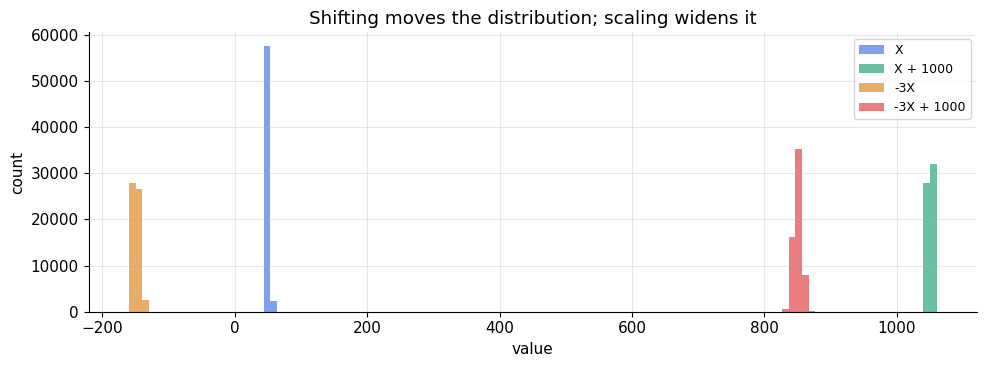

In [50]:
# ============================================================
#  Shift, then scale, then both. Verify a^2 and the vanishing b.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

base = sets[0][1]                      # the 'tight' set
a, b = -3.0, 1000.0

cases = [("X",           base,             1.0, 0.0),
         ("X + 1000",    base + b,         1.0, b),
         ("-3X",         a * base,         a,   0.0),
         ("-3X + 1000",  a * base + b,     a,   b)]

print(f"{'variable':>12} | {'mean':>10} | {'Var':>10} | {'a^2 Var(X)':>11} "
      f"| {'sd':>8} | {'|a| sd(X)':>10}")
print("-" * 76)
for name, v, aa, bb in cases:
    print(f"{name:>12} | {v.mean():>10.3f} | {v.var():>10.4f} "
          f"| {aa**2 * base.var():>11.4f} | {v.std():>8.4f} "
          f"| {abs(aa) * base.std():>10.4f}")

print()
print(f"shifting by {b:.0f} changed the variance by: "
      f"{abs((base + b).var() - base.var()):.2e}   (i.e. not at all)")
print(f"scaling by {a:.0f} multiplied the variance by: "
      f"{(a * base).var() / base.var():.4f}   (a^2 = {a**2:.1f})")
print(f"scaling by {a:.0f} multiplied the sd by:       "
      f"{(a * base).std() / base.std():.4f}   (|a| = {abs(a):.1f})")

fig, ax = plt.subplots(figsize=(10, 3.8))
for (name, v, _, _), colr in zip(cases, [C_F, C_AREA, C_APPROX, C_SLOPE]):
    ax.hist(v, bins=120, range=(-160, 1060), alpha=0.6, color=colr, label=name)
ax.set_xlabel("value")
ax.set_ylabel("count")
ax.set_title("Shifting moves the distribution; scaling widens it")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four versions of the same variable. The blue peak and the green peak are the *same width* — one is just parked 1,000 units to the right. Adding a constant relocates a distribution without stretching it, which is exactly the $b$ cancelling in the derivation.

The orange and red humps are visibly broader: multiplying by $-3$ tripled the standard deviation and so multiplied the variance by nine. The minus sign flipped the distribution left-to-right, which you cannot see here because the shape is symmetric — and which the $a^2$ correctly ignores.

The printed table confirms all of it: the `Var` column matches the `a^2 Var(X)` column, and the `sd` column matches `|a| sd(X)`.

**The common misread:** expecting the variance to double when you double the data. It quadruples. If you switch a feature from metres to centimetres, its variance grows by a factor of 10,000 — which is precisely why any model that compares features by their variance needs them on a common scale first.

</div>

### The rule that needs a condition: does variance add?

Part 5's headline was that $E[X+Y] = E[X]+E[Y]$ **always**, with no conditions
whatsoever. It is tempting to expect the same generosity here:

$$\operatorname{Var}(X + Y) \;\overset{?}{=}\; \operatorname{Var}(X) + \operatorname{Var}(Y)$$

**This is true only when $X$ and $Y$ are independent.** In general it is false,
and it can be wrong by an enormous margin in either direction.

The reason is visible if you expand the square. Writing deviations as
$\tilde{X} = X - \mu_X$ and $\tilde{Y} = Y - \mu_Y$:

$$\operatorname{Var}(X+Y) = E\big[(\tilde X + \tilde Y)^2\big]
= E[\tilde X^2] + E[\tilde Y^2] + 2\,E[\tilde X \tilde Y]$$

The first two terms are $\operatorname{Var}(X)$ and $\operatorname{Var}(Y)$. The
third is a cross-term — twice the **covariance** — and it measures whether the
two variables deviate from their means together. Independent variables have no
such tendency, so it vanishes and the variances add. Dependent ones do not.

We check both cases side by side. Covariance gets its proper treatment in
Part 8; here we only need to see the hole it fills.


In [51]:
# ============================================================
#  Do variances add? Three pairs: independent, positively
#  dependent, negatively dependent.
# ============================================================
import numpy as np

RNG6b = np.random.default_rng(607)
m = 200_000

A = RNG6b.normal(0.0, 3.0, size=m)
noise = RNG6b.normal(0.0, 1.0, size=m)

pairs = [
    ("independent      ", A, RNG6b.normal(0.0, 4.0, size=m)),
    ("positively dep.   ", A, 1.5 * A + noise),          # Y follows X up
    ("negatively dep.   ", A, -1.5 * A + noise),         # Y moves against X
    ("inbox X and Y     ", X_flag.astype(float), Y_spammy.astype(float)),
]

print(f"{'pair':>18} | {'corr':>7} | {'Var(X)+Var(Y)':>14} | {'Var(X+Y)':>11} "
      f"| {'discrepancy':>12} | {'2*Cov':>10}")
print("-" * 88)
for name, U, V in pairs:
    lhs  = U.var() + V.var()
    rhs  = (U + V).var()
    cov  = ((U - U.mean()) * (V - V.mean())).mean()
    print(f"{name:>18} | {np.corrcoef(U, V)[0,1]:>7.4f} | {lhs:>14.4f} "
          f"| {rhs:>11.4f} | {rhs - lhs:>12.4f} | {2*cov:>10.4f}")

print()
print("The discrepancy column IS the 2*Cov column, in every row:")
for name, U, V in pairs:
    disc = (U + V).var() - (U.var() + V.var())
    cov2 = 2 * ((U - U.mean()) * (V - V.mean())).mean()
    print(f"    {name}: {disc:>10.4f} vs {cov2:>10.4f}   "
          f"match: {np.isclose(disc, cov2)}")


              pair |    corr |  Var(X)+Var(Y) |    Var(X+Y) |  discrepancy |      2*Cov
----------------------------------------------------------------------------------------
 independent       | -0.0003 |        24.9473 |     24.9407 |      -0.0065 |    -0.0065
positively dep.    |  0.9761 |        30.2001 |     57.1436 |      26.9435 |    26.9435
negatively dep.    | -0.9760 |        30.1284 |      3.2327 |     -26.8956 |   -26.8956
inbox X and Y      |  0.5488 |         0.8994 |      1.3826 |       0.4832 |     0.4832

The discrepancy column IS the 2*Cov column, in every row:
    independent      :    -0.0065 vs    -0.0065   match: True
    positively dep.   :    26.9435 vs    26.9435   match: True
    negatively dep.   :   -26.8956 vs   -26.8956   match: True
    inbox X and Y     :     0.4832 vs     0.4832   match: True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Row one: the variances add. The discrepancy is a few thousandths against a total of about 25 — sampling noise, not structure, because two independent streams have essentially zero covariance.

Row two: $Y$ was built to rise whenever $X$ rises, and the true variance of the sum is far **larger** than the sum of the variances — the two variables reinforce each other, so their swings compound.

Row three: $Y$ was built to fall whenever $X$ rises, and the variance of the sum is far **smaller**. The deviations cancel. This is not a curiosity — it is the entire mathematical basis of hedging a portfolio and of ensembling models whose errors are anti-correlated.

Row four uses the inbox pair from Part 5, where $Y$ is literally a piece of $X$: again the naive sum is wrong.

And the final block closes it: **the discrepancy equals twice the covariance, exactly, in every row.** The general rule is $\operatorname{Var}(X+Y) = \operatorname{Var}(X) + \operatorname{Var}(Y) + 2\operatorname{Cov}(X,Y)$, and independence is simply the special case that kills the last term.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Adding variances without checking independence is the most expensive mistake in this notebook**, because it fails *quietly* — you get a plausible number that is simply wrong, and nothing raises an error.

Where it bites in practice: error bars on a sum of correlated measurements come out far too narrow; risk models that treat correlated assets as independent understate the chance of everything going wrong at once; an ensemble of models trained on the same data does not reduce variance by the factor a naive $1/n$ calculation promises, because the members' errors are correlated.

**Note the asymmetry with Part 5.** $E[X+Y] = E[X]+E[Y]$ needs nothing. $\operatorname{Var}(X+Y) = \operatorname{Var}(X)+\operatorname{Var}(Y)$ needs independence. If you remember one contrast from these two parts, make it that one — and note that *uncorrelated* is enough here, which is a weaker requirement than full independence. Part 8 draws that distinction properly.

</div>

### Standardising: putting everything on one scale

Suppose one feature is an age in years (roughly 20–70) and another is an income
in dollars (roughly 20,000–200,000). Their variances differ by a factor of
millions. Any procedure that measures distances, or that takes one learning-rate
step for all weights, will be dominated entirely by the income column — not
because income matters more, but because dollars are smaller units than years.

The fix is to strip both the location and the scale from every feature:

$$z \;=\; \frac{x - \mu}{\sigma}$$

Subtract the mean, divide by the standard deviation. Applying the two rules from
earlier tells us exactly what this produces: shifting by $-\mu$ makes the mean 0
and leaves the variance alone, and scaling by $1/\sigma$ multiplies the variance
by $1/\sigma^2$ — turning it into 1. So **every standardised feature has mean 0
and standard deviation 1**, whatever it started as.

The resulting number $z$ is called a **z-score**, and it is readable on its own:
$z = 2.3$ means "2.3 standard deviations above average", a statement you can
compare across features that have nothing else in common.


     feature |         mean |           sd |         variance
--------------------------------------------------------------
         age |    43.994129 |    10.934632 |       119.566167
      income | 78065.381204 | 25930.218568 | 672376235.001606
     age (z) |    -0.000000 |     1.000000 |         1.000000
  income (z) |    -0.000000 |     1.000000 |         1.000000

variance ratio BEFORE standardising: 5,623,466 : 1
variance ratio AFTER  standardising: 1.000000 : 1

correlation before : +0.010150
correlation after  : +0.010150   (unchanged -- standardising is a relabelling, not a transformation of the relationship)


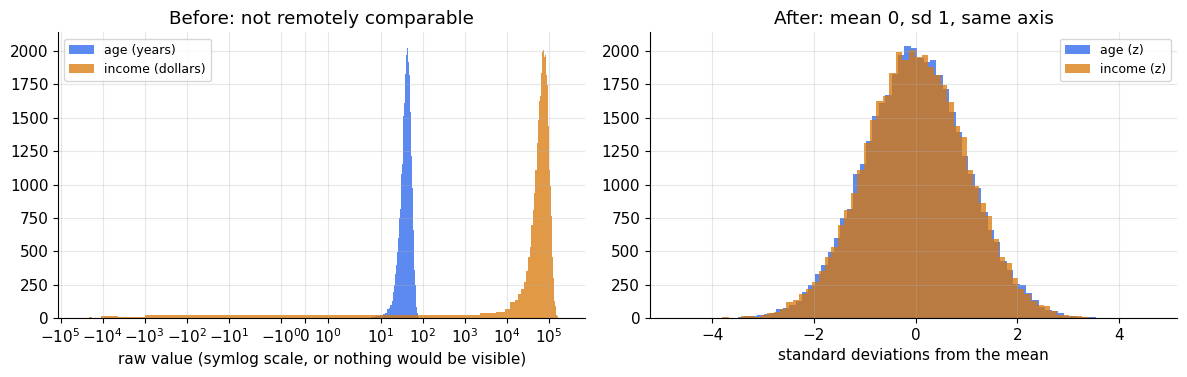

In [52]:
# ============================================================
#  Standardise two features on wildly different scales.
#  Note what changes -- and what does not.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

RNG6c = np.random.default_rng(608)
k = 40_000
age    = RNG6c.normal(44.0, 11.0, size=k)
income = RNG6c.normal(78_000.0, 26_000.0, size=k)

def standardise(v):
    return (v - v.mean()) / v.std()

age_z, income_z = standardise(age), standardise(income)

print(f"{'feature':>12} | {'mean':>12} | {'sd':>12} | {'variance':>16}")
print("-" * 62)
for nm, v in [("age", age), ("income", income),
              ("age (z)", age_z), ("income (z)", income_z)]:
    print(f"{nm:>12} | {v.mean():>12.6f} | {v.std():>12.6f} | {v.var():>16.6f}")

print()
print(f"variance ratio BEFORE standardising: "
      f"{income.var() / age.var():,.0f} : 1")
print(f"variance ratio AFTER  standardising: "
      f"{income_z.var() / age_z.var():.6f} : 1")
print()
print(f"correlation before : {np.corrcoef(age, income)[0,1]:+.6f}")
print(f"correlation after  : {np.corrcoef(age_z, income_z)[0,1]:+.6f}   "
      f"(unchanged -- standardising is a relabelling, not a transformation "
      f"of the relationship)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
ax[0].hist(age, bins=70, color=C_F, alpha=0.75, label="age (years)")
ax[0].hist(income, bins=70, color=C_APPROX, alpha=0.75, label="income (dollars)")
ax[0].set_xscale("symlog")
ax[0].set_title("Before: not remotely comparable")
ax[0].set_xlabel("raw value (symlog scale, or nothing would be visible)")
ax[0].legend(fontsize=9)

ax[1].hist(age_z, bins=70, color=C_F, alpha=0.75, label="age (z)")
ax[1].hist(income_z, bins=70, color=C_APPROX, alpha=0.75, label="income (z)")
ax[1].set_title("After: mean 0, sd 1, same axis")
ax[1].set_xlabel("standard deviations from the mean")
ax[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the raw features. The x-axis had to be put on a symmetric-log scale for both to be visible at once, and even then the age distribution is squashed into a sliver near the origin while income sprawls across the right-hand side. The printed variance ratio is in the millions.

**Right:** the same two features after standardising. They now sit on top of one another on a shared axis measured in standard deviations, and the printed means are zero to six decimals with standard deviations of exactly 1. The variance ratio has become 1:1.

Crucially, the *shapes* are unchanged — standardising slides and stretches an axis, it does not reshape a distribution. A skewed feature is still skewed afterwards, and the printed correlation is identical before and after, to six decimal places.

**The common misread:** believing standardising makes data normal. It does not. It makes data *comparable*. If you need a bell shape you need a different transform entirely — a log, or a rank transform — and no amount of subtracting means will get you there.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Standardising is the first line of almost every real ML pipeline**, and the two rules in this part are the whole justification.

- **Gradient descent** takes one learning rate for all weights. If one feature's scale is a thousand times another's, the loss surface is a long narrow valley and the step size that is stable for the steep direction is hopelessly slow for the shallow one. Standardising makes the valley round.
- **Distance-based methods** — k-NN, k-means, RBF kernels, SVMs — compute distances by summing squared differences. An unscaled feature with a large variance dominates that sum outright, so the model effectively ignores every other column.
- **Regularisation** (ridge, lasso) penalises the size of coefficients. A feature measured in small units needs a large coefficient to have any effect, so the penalty falls on it far harder — the penalty becomes a function of your unit choices rather than of the data.

**The discipline that matters:** compute $\mu$ and $\sigma$ on the **training set only**, then apply those same two numbers to validation and test. Standardising before splitting leaks information from the test set into training and quietly inflates your reported score. This is what scikit-learn's `StandardScaler` enforces by separating `fit` from `transform`.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Variance is also half of the most important framing in supervised learning.** A model's expected error on unseen data decomposes into three pieces:

$$\text{expected error} \;=\; \underbrace{\text{bias}^2}_{\text{wrong on average}} \;+\; \underbrace{\text{variance}}_{\text{unstable across datasets}} \;+\; \underbrace{\text{irreducible noise}}_{\text{not your fault}}$$

**Bias** is the error you would still make with infinite data because your model is too rigid to represent the truth — a straight line fitted to a curve. **Variance** is exactly the quantity this part defines, applied to the model's own predictions: retrain on a different sample of the same size and how much do the predictions move? A depth-30 decision tree has low bias and enormous variance; it memorises whichever sample it was handed.

This is why the two failure modes have different cures. Underfitting is a bias problem, so you add capacity. Overfitting is a variance problem, so you add data, add regularisation, or **average several models** — and that last one works only to the extent the models' errors are uncorrelated, which is precisely the covariance term we just measured. Random forests randomise features specifically to force that covariance down.

</div>

### Chebyshev's inequality: what spread guarantees, for *any* distribution

You may have heard the "68–95–99.7 rule": about 68% of values within one
standard deviation of the mean, 95% within two, 99.7% within three. That rule is
true **for the normal distribution and for nothing else**, and applying it to
skewed or heavy-tailed data is a reliable way to be badly wrong.

There is a weaker statement that needs no such assumption. For **any**
distribution at all — any shape, any skew, any number of lumps, discrete or
continuous — as long as its variance is finite:

$$P\big(\,|X - \mu| \ge k\sigma\,\big) \;\le\; \frac{1}{k^2}$$

In words: the fraction of values sitting $k$ or more standard deviations away
from the mean can never exceed $1/k^2$ — whatever that data looks like.

The bound is loose, and the cell below measures exactly how loose by checking it
against six deliberately dissimilar shapes. That looseness is the price of the
guarantee applying to everything. It is worth knowing precisely because it holds
when you know nothing at all about the shape of your data.


In [53]:
# ============================================================
#  Chebyshev, checked against four very different shapes.
#  The bound must hold for all of them, or the theorem is wrong.
# ============================================================
import numpy as np

RNG6d = np.random.default_rng(609)
q = 400_000

shapes = [
    ("normal",       RNG6d.normal(0.0, 1.0, size=q)),
    ("uniform",      RNG6d.uniform(-1.0, 1.0, size=q)),
    ("exponential",  RNG6d.exponential(1.0, size=q)),          # heavily skewed
    ("bimodal",      np.where(RNG6d.random(q) < 0.5, -4.0, 4.0)
                     + RNG6d.normal(0.0, 0.5, size=q)),
    ("heavy-tailed", RNG6d.standard_t(df=4, size=q)),          # fat tails
    ("flag words X", X_flag.astype(float)),                    # discrete, skewed
]

for k in [1.5, 2.0, 3.0]:
    print(f"--- k = {k}   Chebyshev bound = 1/k^2 = {1/k**2:.4f}")
    print(f"{'distribution':>14} | {'actual P(|X-mu| >= k sd)':>25} | {'holds?':>7}")
    print("-" * 52)
    for nm, v in shapes:
        mu, sd = v.mean(), v.std()
        actual = (np.abs(v - mu) >= k * sd).mean()
        print(f"{nm:>14} | {actual:>25.5f} | "
              f"{str(actual <= 1/k**2 + 1e-12):>7}")
    print()

print("How much slack does the bound leave? (k = 2)")
for nm, v in shapes:
    actual = (np.abs(v - v.mean()) >= 2 * v.std()).mean()
    print(f"    {nm:>14}: bound 0.2500, actual {actual:.4f}   "
          f"-> bound is {0.25/max(actual,1e-9):>6.1f}x too generous")


--- k = 1.5   Chebyshev bound = 1/k^2 = 0.4444
  distribution |  actual P(|X-mu| >= k sd) |  holds?
----------------------------------------------------
        normal |                   0.13368 |    True
       uniform |                   0.13435 |    True
   exponential |                   0.08221 |    True
       bimodal |                   0.00002 |    True
  heavy-tailed |                   0.10190 |    True
  flag words X |                   0.18110 |    True

--- k = 2.0   Chebyshev bound = 1/k^2 = 0.2500
  distribution |  actual P(|X-mu| >= k sd) |  holds?
----------------------------------------------------
        normal |                   0.04582 |    True
       uniform |                   0.00000 |    True
   exponential |                   0.04963 |    True
       bimodal |                   0.00000 |    True
  heavy-tailed |                   0.04778 |    True
  flag words X |                   0.00995 |    True

--- k = 3.0   Chebyshev bound = 1/k^2 = 0.1111
  distrib

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Every row holds, at every $k$ — a symmetric bell, a flat uniform, a sharply skewed exponential, a two-lump distribution with a hole in the middle, a fat-tailed t-distribution, and our discrete flag-word count. Six shapes with almost nothing in common, one bound covering all of them. That is what "holds for any distribution" means, and the simulation is how you convince yourself rather than taking it on trust.

The final block shows the cost. For the uniform distribution the bound is wildly generous — the true tail probability at $k=2$ is zero, because a uniform cannot even reach two standard deviations from its mean. For the normal it overstates by roughly fivefold. Only distributions constructed specifically to be extreme get anywhere near the bound.

**When it earns its keep:** when you have a mean and a standard deviation and genuinely do not know the shape. Chebyshev then gives you a conservative statement nobody can argue with. When you *do* know the shape, use the shape — which is exactly what Part 7 gives you.

</div>

---

### Where that leaves us

$E[X]$ told us where a distribution balances. This part added the second number:

- $\operatorname{Var}(X) = E[(X-\mu)^2]$, the average **squared** distance from
  the mean — squared because the plain deviations cancel to exactly zero;
- $\sigma = \sqrt{\operatorname{Var}(X)}$, the same information in the original
  units, and the number to quote to a human;
- $\operatorname{Var}(X) = E[X^2] - (E[X])^2$, which is precisely the gap Part 5
  found between squaring-then-averaging and averaging-then-squaring;
- $\operatorname{Var}(aX+b) = a^2\operatorname{Var}(X)$ — shifts are free,
  scales cost a square;
- $\operatorname{Var}(X+Y) = \operatorname{Var}(X) + \operatorname{Var}(Y)$
  **only when the variables are uncorrelated**, with the shortfall equal to
  twice the covariance;
- standardising, $z = (x-\mu)/\sigma$, which is where a real ML pipeline starts;
- Chebyshev's bound, which holds for every distribution and is loose for all of
  them.

Notice the shape of the last two points. Chebyshev is weak *because* it assumes
nothing. Every time we have needed a sharper answer — how much probability
really sits beyond two standard deviations, how likely four flag words are — we
have had to know something about the **shape** of the distribution.

It turns out a handful of shapes account for most of what happens in practice,
each arising from a specific, describable mechanism: counting successes,
counting rare events, waiting for something to happen, adding up many small
independent contributions. Learn the mechanisms and you can usually recognise
which distribution you are looking at from the story that generated it.

That is **Part 7**.

---


---

# 7️⃣ The named distributions, and when each applies

Textbooks usually present this part as a list of formulas to memorise. That is
exactly backwards, and it is why nobody remembers them.

Every named distribution is **the answer to one specific question**. You do not
pick a distribution because its formula looks familiar; you pick it because the
question you are asking is the question it answers. Get the question right and
the formula follows — and if you forget the formula, you can re-derive it or
look it up in one line.

So each section here opens with the question, in words, on our inbox. The
formula comes second, the picture third, and then — as always — a simulation
that checks the formula was not a lie.

| The question you are asking | The distribution |
|---|---|
| One yes/no trial: is *this* email spam? | Bernoulli |
| How many spam in a batch of $n$? | Binomial |
| How many emails until the first spam? | Geometric |
| How many spam arrive in an hour? | Poisson |
| A number anywhere in a range, no value preferred | Uniform |
| A quantity pushed around by many small effects | Normal |
| How long until the next spam arrives? | Exponential |

Two words before we start.

A **discrete** distribution puts probability on separate values you can list
(0, 1, 2, ...), and its **PMF** — probability mass function — gives the
probability of each one. A **continuous** distribution spreads probability over
a range, no single value has any probability at all, and its **PDF** —
probability density function — is a height whose *area* gives probability. Part
5 built both; here we meet the seven that keep showing up.


In [54]:
# ============================================================
#  Part 7 setup. Its own generator, so this part reproduces
#  identically no matter how much randomness earlier parts used.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

RNG7 = np.random.default_rng(707)


def mv_report(name, mean_formula, var_formula, theory_mean, theory_var, samples):
    """Print the textbook mean/variance beside the simulated ones.

    Nothing here is asserted: the right-hand column is a count from
    `samples`, so if the formula is wrong the two columns disagree.
    """
    m, v = samples.mean(), samples.var()
    print(f"{name}   ({samples.size:,} simulated draws)")
    print(f"  mean      formula {mean_formula:<18} = {theory_mean:10.4f}   simulated = {m:10.4f}")
    print(f"  variance  formula {var_formula:<18} = {theory_var:10.4f}   simulated = {v:10.4f}")
    print(f"  gap: mean {abs(m - theory_mean):.4f},  variance {abs(v - theory_var):.4f}")
    return m, v


print("Part 7 ready.")


Part 7 ready.


## 7.1 Bernoulli — one yes/no trial

**The question:** *is this email spam?*

That is the whole distribution. One trial, two outcomes, and a single number
$p$ that says how often the answer is yes. Write the outcome as $X = 1$ for yes
and $X = 0$ for no; then

$$P(X = 1) = p, \qquad P(X = 0) = 1 - p.$$

It looks too small to deserve a name. It deserves one because every other
discrete distribution in this part is built out of Bernoulli trials: count them,
wait for them, watch a lot of rare ones. Learn this one properly and the rest
are consequences.

Mean and variance:

$$E[X] = p, \qquad \text{Var}(X) = p(1-p).$$

The mean is $p$ because the average of a pile of 0s and 1s *is* the proportion
of 1s. The variance is largest at $p = 0.5$ — maximum uncertainty — and shrinks
to zero at $p = 0$ or $p = 1$, where nothing is uncertain at all.


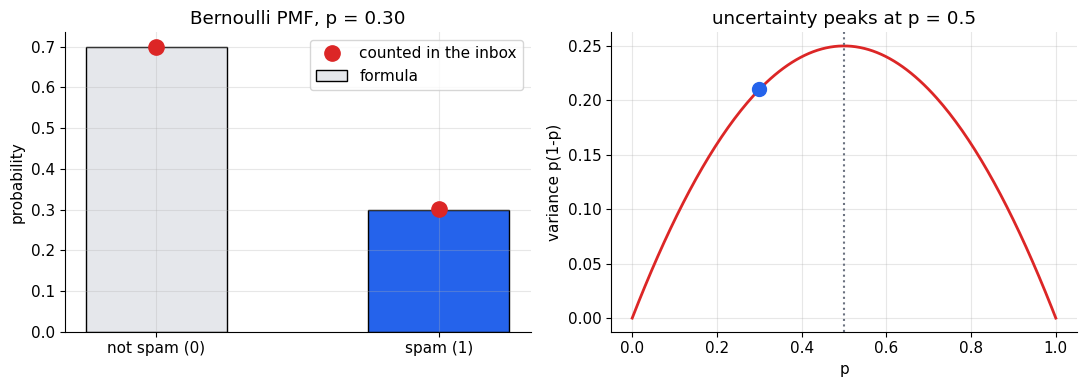

Bernoulli(p=0.30)   (20,000 simulated draws)
  mean      formula p                  =     0.3000   simulated =     0.3008
  variance  formula p(1-p)             =     0.2100   simulated =     0.2103
  gap: mean 0.0008,  variance 0.0003


(np.float64(0.3008), np.float64(0.21031936000000004))

In [55]:
# Is this email spam? One Bernoulli trial per email -- and Part 0 already
# generated 20,000 of them, so we can simply count.
p = P_SPAM
bern = is_spam.astype(float)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar([0, 1], [1 - p, p], width=0.5, color=[C_SOFT, C_F],
          edgecolor="black", label="formula")
ax[0].plot([0, 1], [(bern == 0).mean(), (bern == 1).mean()], "o",
           color=C_SLOPE, markersize=11, label="counted in the inbox")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["not spam (0)", "spam (1)"])
ax[0].set_ylabel("probability"); ax[0].set_title("Bernoulli PMF, p = 0.30")
ax[0].legend()

# Variance of a Bernoulli as p varies -- biggest where you are least sure.
grid = np.linspace(0, 1, 200)
ax[1].plot(grid, grid * (1 - grid), color=C_SLOPE, lw=2)
ax[1].axvline(0.5, color=C_GREY, ls=":")
ax[1].plot([p], [p * (1 - p)], "o", color=C_F, markersize=10)
ax[1].set_xlabel("p"); ax[1].set_ylabel("variance p(1-p)")
ax[1].set_title("uncertainty peaks at p = 0.5")

plt.tight_layout(); plt.show()

mv_report("Bernoulli(p=0.30)", "p", "p(1-p)", p, p * (1 - p), bern)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the two bars are the formula, the red dots are the actual proportions of the 20,000 emails. They sit on the bars because the formula is right — but look closely and the dots are not exactly on the bar tops. That gap is sampling noise, not error in the formula.

**Right:** how much a single yes/no answer varies, as a function of how likely 'yes' is. A coin you cannot call (p = 0.5) is the most variable thing there is; a coin that always lands heads has no variance at all. Our spam rate sits off to the left of that peak, marked in blue.

**The common misread:** reading the right-hand curve as 'p = 0.5 is the most likely value of p'. It says nothing about which $p$ is likely — $p$ is a fixed setting of the world here, not a random thing. The curve says how unpredictable each individual *email* is once $p$ is fixed.

</div>

## 7.2 Binomial — how many successes in $n$ trials

**The question:** *a batch of 10 emails arrives. How many are spam?*

The answer is a number from 0 to 10, and it is random. To get its distribution,
count arrangements.

Take exactly $k$ spam out of $n = 10$. **One particular** arrangement — say the
first $k$ are spam and the rest are not — has probability
$p^k (1-p)^{n-k}$, because the emails are independent and we multiply (Part 3).
That probability is the same for *every* arrangement with $k$ spam, since it is
the same $k$ factors of $p$ and $n-k$ factors of $1-p$ in a different order.

So the only remaining question is: **how many arrangements have exactly $k$
spam?** That count is written $\binom{n}{k}$, said "n choose k", and equals

$$\binom{n}{k} = \frac{n!}{k!\,(n-k)!}.$$

Multiply the count by the probability of each and you have the binomial PMF:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad k = 0, 1, \dots, n.$$

$$E[X] = np, \qquad \text{Var}(X) = np(1-p).$$

The mean is worth a second: $n$ trials, each contributing $p$ on average, and
expectation adds (Part 5) whether or not the trials are independent. The
variance is $n$ times the Bernoulli variance — and *that* step does need
independence, which is exactly the warning Part 6 ended on.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\binom{n}{k} p^k (1-p)^{n-k}$ reads left to right as a sentence:

**"in how many ways"** ($\binom{n}{k}$) **"can I get $k$ yeses"** ($p^k$) **"and $n-k$ noes"** ($(1-p)^{n-k}$).

The factorials are not a mystical object — they are a way of counting orderings. The next cell counts those orderings by brute force and checks that the factorial formula returns the same number.

</div>

all 32 spam/not patterns for a batch of 5:
  k  counted by hand    n!/(k!(n-k)!)
  0                1                1   OK
  1                5                5   OK
  2               10               10   OK
  3               10               10   OK
  4                5                5   OK
  5                1                1   OK


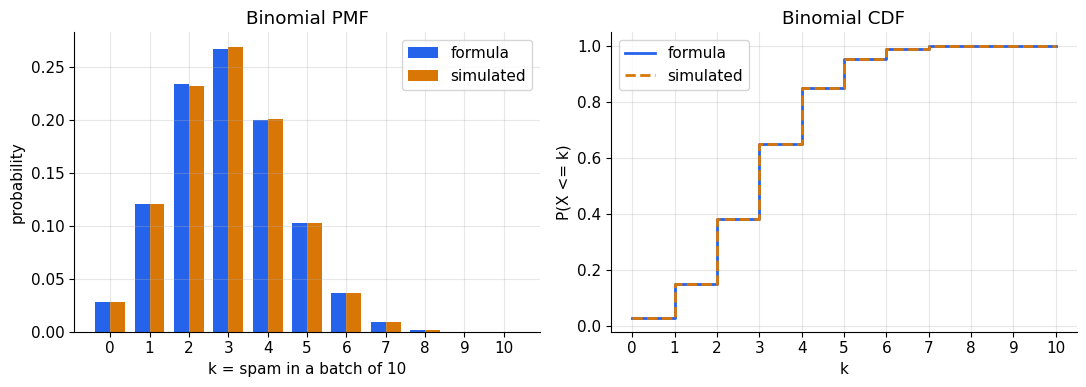


largest PMF disagreement over all 11 values: 0.00242
probabilities sum to 1.0000000000

Binomial(n=10, p=0.30)   (200,000 simulated draws)
  mean      formula n*p                =     3.0000   simulated =     3.0040
  variance  formula n*p*(1-p)          =     2.1000   simulated =     2.0896
  gap: mean 0.0040,  variance 0.0104


(np.float64(3.003965), np.float64(2.0895892787749997))

In [56]:
from itertools import product
from math import comb, factorial

# ---- Step 1: is "n choose k" really just counting arrangements?
# Enumerate every spam/not pattern for a small batch and count them by hand.
n_small = 5
patterns = list(product([0, 1], repeat=n_small))
print(f"all {len(patterns)} spam/not patterns for a batch of {n_small}:")
print(f"{'k':>3} {'counted by hand':>16} {'n!/(k!(n-k)!)':>16}")
for k in range(n_small + 1):
    by_hand = sum(1 for pat in patterns if sum(pat) == k)
    by_formula = factorial(n_small) // (factorial(k) * factorial(n_small - k))
    flag = "OK" if by_hand == by_formula else "MISMATCH"
    print(f"{k:>3} {by_hand:>16} {by_formula:>16}   {flag}")

# ---- Step 2: the PMF itself, formula vs simulated batches.
n, p = 10, P_SPAM
ks = np.arange(n + 1)
pmf = np.array([comb(n, k) * p**k * (1 - p)**(n - k) for k in ks])

N_BATCH = 200_000
batches = (RNG7.random((N_BATCH, n)) < p).sum(axis=1)   # spam per batch of 10
sim_pmf = np.array([(batches == k).mean() for k in ks])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(ks - 0.19, pmf, width=0.38, color=C_F, label="formula")
ax[0].bar(ks + 0.19, sim_pmf, width=0.38, color=C_APPROX, label="simulated")
ax[0].set_xticks(ks); ax[0].set_xlabel("k = spam in a batch of 10")
ax[0].set_ylabel("probability"); ax[0].set_title("Binomial PMF")
ax[0].legend()

ax[1].step(ks, pmf.cumsum(), where="post", color=C_F, lw=2, label="formula")
ax[1].step(ks, sim_pmf.cumsum(), where="post", color=C_APPROX, lw=2, ls="--",
           label="simulated")
ax[1].set_xticks(ks); ax[1].set_xlabel("k")
ax[1].set_ylabel("P(X <= k)"); ax[1].set_title("Binomial CDF")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"\nlargest PMF disagreement over all 11 values: {np.abs(pmf - sim_pmf).max():.5f}")
print(f"probabilities sum to {pmf.sum():.10f}\n")
mv_report("Binomial(n=10, p=0.30)", "n*p", "n*p*(1-p)",
          n * p, n * p * (1 - p), batches.astype(float))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** blue is the formula, orange is 200,000 actual batches of ten emails. Same shape, bar by bar, and the printed line says how far apart the worst-matching pair is. The peak sits near 3 because 10 emails times a 0.30 spam rate is 3 — but notice how much probability is spread over 1, 2, 4 and 5. 'On average 3' does not mean 'usually 3'.

**Right:** the same information as a CDF, the running total. It answers questions of the form 'at most how many?' directly: read off the height at $k$ and you have $P(X \le k)$.

**The common misread:** thinking the binomial needs the trials to be *identical emails*. It needs them to be **independent** and to share the same $p$. Ten emails from ten different senders qualify; ten copies of one forwarded chain do not — and that is exactly when real spam counts blow past the spread the binomial predicts.

</div>

## 7.3 Geometric — how long until the first success

**The question:** *emails arrive one at a time. How many do I read before the
first spam?*

Now the number of trials is the random thing. For the first spam to land on
trial $k$, the first $k-1$ trials must all miss and the $k$-th must hit:

$$P(X = k) = (1-p)^{k-1} p, \qquad k = 1, 2, 3, \dots$$

No counting term this time — there is only **one** way for it to happen: miss,
miss, ..., miss, hit.

$$E[X] = \frac{1}{p}, \qquad \text{Var}(X) = \frac{1-p}{p^2}.$$

The mean is the one people remember: if 30% of mail is spam, you wait about
$1/0.3$ emails for the first one. The tail is long, though, and the variance
says so.

### The strange part: it forgets

Suppose you have read ten emails with no spam. Does that make spam *due*?

$$P(X > s + t \mid X > s) = P(X > t).$$

The distribution has no memory. Having waited already tells you nothing about
how much longer you will wait. This is genuinely counter-intuitive — it is the
gambler's fallacy in reverse — so we will not argue for it. We will simulate it
and count.


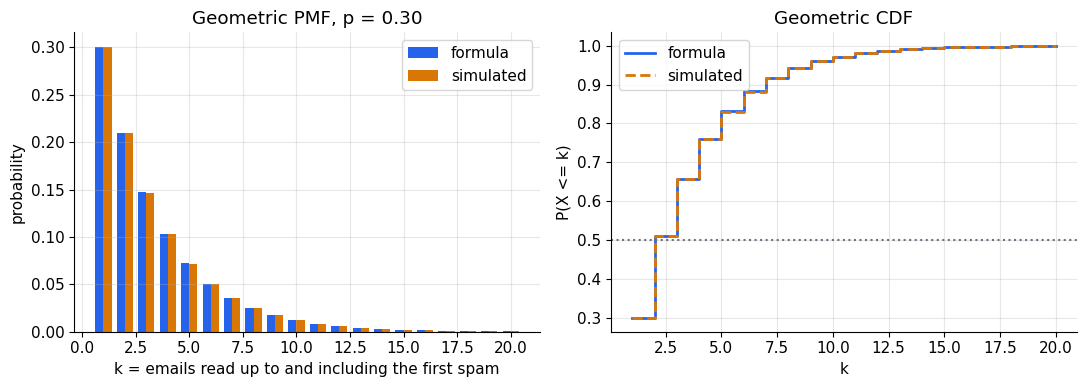

Geometric(p=0.30)   (300,000 simulated draws)
  mean      formula 1/p                =     3.3333   simulated =     3.3359
  variance  formula (1-p)/p^2          =     7.7778   simulated =     7.7922
  gap: mean 0.0026,  variance 0.0144

Memorylessness: does having waited already change what is left to wait?
 already waited s   P(X > s+3 | X > s)     P(X > 3)
                0               0.3435       0.3435
                2               0.3458       0.3435
                5               0.3428       0.3435
               10               0.3435       0.3435

The middle column does not drift as s grows. The wait resets.


In [57]:
p = P_SPAM
ks = np.arange(1, 21)
pmf = (1 - p)**(ks - 1) * p


def first_spam_wait(size, prob, rng):
    """Trials until (and including) the first success. Vectorised, no loops."""
    u = rng.random(size)
    return np.floor(np.log(u) / np.log(1 - prob)).astype(int) + 1


waits = first_spam_wait(300_000, p, RNG7)
sim_pmf = np.array([(waits == k).mean() for k in ks])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(ks - 0.19, pmf, width=0.38, color=C_F, label="formula")
ax[0].bar(ks + 0.19, sim_pmf, width=0.38, color=C_APPROX, label="simulated")
ax[0].set_xlabel("k = emails read up to and including the first spam")
ax[0].set_ylabel("probability"); ax[0].set_title("Geometric PMF, p = 0.30")
ax[0].legend()

ax[1].step(ks, pmf.cumsum(), where="post", color=C_F, lw=2, label="formula")
ax[1].step(ks, sim_pmf.cumsum(), where="post", color=C_APPROX, lw=2, ls="--",
           label="simulated")
ax[1].axhline(0.5, color=C_GREY, ls=":")
ax[1].set_xlabel("k"); ax[1].set_ylabel("P(X <= k)")
ax[1].set_title("Geometric CDF"); ax[1].legend()
plt.tight_layout(); plt.show()

mv_report("Geometric(p=0.30)", "1/p", "(1-p)/p^2",
          1 / p, (1 - p) / p**2, waits.astype(float))

# ---- Memorylessness, tested rather than argued.
print("\nMemorylessness: does having waited already change what is left to wait?")
print(f"{'already waited s':>17} {'P(X > s+3 | X > s)':>20} {'P(X > 3)':>12}")
base = (waits > 3).mean()
for s in [0, 2, 5, 10]:
    survived = waits > s
    cond = (waits > s + 3)[survived].mean()
    print(f"{s:>17} {cond:>20.4f} {base:>12.4f}")
print("\nThe middle column does not drift as s grows. The wait resets.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the geometric PMF is always highest at $k = 1$ and decays from there, whatever $p$ is. That surprises people who expect a bump near the mean: the single most likely wait is *no wait at all*, even though the average wait is $1/p$ emails. A long right tail drags the mean above the mode.

**Right:** the CDF, with the halfway line marked. Where the curve crosses it is the median wait — noticeably shorter than the mean, which is the signature of a skewed distribution.

The printed table is the memorylessness test: for four different amounts of waiting already done, the chance of waiting three *more* emails stays at the value it had from a fresh start.

**The common misread:** 'the mean is $1/p$, so spam arrives every $1/p$ emails, regularly.' It does not. It arrives in clumps and droughts whose spread is given by the variance, and the most likely wait is 1.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Memorylessness feels wrong, and the wrongness has a name.**

After ten spam-free emails, the gambler's intuition says spam is 'due'. The table above says the chance of the next three being clean is exactly what it was at the start. Nothing is keeping score.

The reverse error is just as common: 'I have waited so long, this stream must be broken.' Also not implied — unless you are questioning $p$ itself, which is a *statistics* question (estimating a parameter) rather than a probability one, and is what the companion notebook is about.

Two things really are true and are easy to confuse with the fallacy: the long-run *proportion* of spam does settle down toward $p$ over many emails, and the geometric is the **only** discrete distribution with no memory. If your waiting times do have memory — a spam burst making another burst more likely — the geometric is the wrong model, and it will badly underestimate how long the droughts get.

</div>

## 7.4 Poisson — how many rare events in a fixed window

**The question:** *how many spam emails arrive in the next hour?*

The binomial needs a fixed number of trials $n$. But "an hour" is not a number
of trials — mail could arrive at any instant. So chop the hour into $n$ tiny
slices, each of which either does or does not contain an arrival, and let the
slices get smaller and more numerous while the expected count $\lambda = np$
stays fixed.

Take that limit — $n \to \infty$, $p = \lambda/n \to 0$, $np = \lambda$ held
constant — and the binomial PMF turns into

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \dots$$

$$E[X] = \lambda, \qquad \text{Var}(X) = \lambda.$$

Mean and variance are the **same number**, which is a genuinely useful fact:
Poisson counts have a built-in spread of about $\sqrt{\lambda}$, so if your real
counts are much more spread out than that ("overdispersed"), the Poisson
assumption is broken and you have learned something about the data.

We do not have to walk through the limit algebra to believe it. We can plot the
binomial with a big $n$ next to the Poisson and measure how far apart they are.


n =   10  ->  largest gap from Poisson: 0.042786
n =   50  ->  largest gap from Poisson: 0.007015
n = 1000  ->  largest gap from Poisson: 0.000337


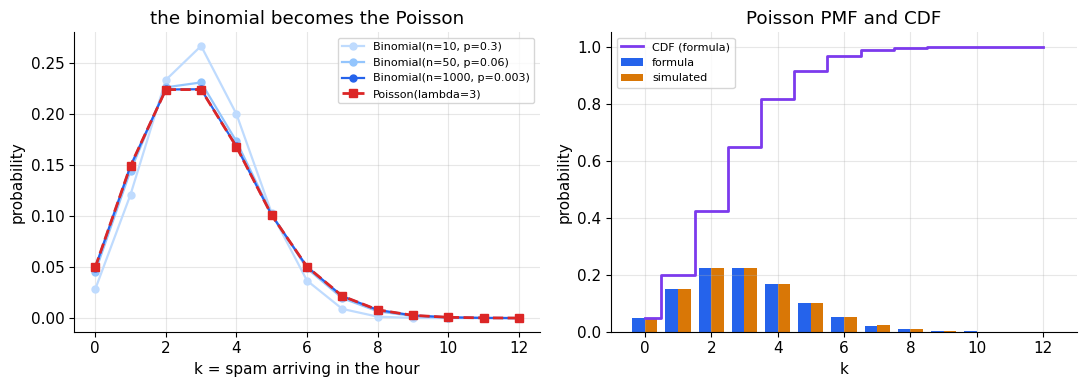


PMF vs simulation, largest gap: 0.00086
Poisson(lambda=3)   (300,000 simulated draws)
  mean      formula lambda             =     3.0000   simulated =     3.0058
  variance  formula lambda             =     3.0000   simulated =     3.0135
  gap: mean 0.0058,  variance 0.0135


(np.float64(3.00581), np.float64(3.0135362438999995))

In [58]:
from math import comb, factorial

LAM = 3.0                       # expected spam per hour
ks = np.arange(0, 13)
poisson_pmf = np.array([LAM**k * np.exp(-LAM) / factorial(k) for k in ks])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# ---- Binomial approaching Poisson as the time slices get finer.
for n_slices, shade in [(10, "#BFDBFE"), (50, "#93C5FD"), (1000, C_F)]:
    p_slice = LAM / n_slices
    binom_pmf = np.array([comb(n_slices, k) * p_slice**k * (1 - p_slice)**(n_slices - k)
                          if k <= n_slices else 0.0 for k in ks])
    ax[0].plot(ks, binom_pmf, "o-", color=shade, lw=1.6, markersize=5,
               label=f"Binomial(n={n_slices}, p={p_slice:.4g})")
    print(f"n = {n_slices:>4}  ->  largest gap from Poisson: "
          f"{np.abs(binom_pmf - poisson_pmf).max():.6f}")

ax[0].plot(ks, poisson_pmf, "s--", color=C_SLOPE, lw=2, markersize=6,
           label="Poisson(lambda=3)")
ax[0].set_xlabel("k = spam arriving in the hour"); ax[0].set_ylabel("probability")
ax[0].set_title("the binomial becomes the Poisson"); ax[0].legend(fontsize=8)

# ---- Poisson PMF and CDF against a direct simulation.
draws = RNG7.poisson(LAM, size=300_000)
sim_pmf = np.array([(draws == k).mean() for k in ks])
ax[1].bar(ks - 0.19, poisson_pmf, width=0.38, color=C_F, label="formula")
ax[1].bar(ks + 0.19, sim_pmf, width=0.38, color=C_APPROX, label="simulated")
ax[1].step(ks, poisson_pmf.cumsum(), where="mid", color=C_EXACT, lw=2,
           label="CDF (formula)")
ax[1].set_xlabel("k"); ax[1].set_ylabel("probability")
ax[1].set_title("Poisson PMF and CDF"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nPMF vs simulation, largest gap: {np.abs(poisson_pmf - sim_pmf).max():.5f}")
mv_report("Poisson(lambda=3)", "lambda", "lambda", LAM, LAM, draws.astype(float))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** three binomials with ever-finer time slices, and the Poisson in dashed red. At 10 slices the binomial is visibly its own shape; by 1000 it has landed on the Poisson, and the printed gaps shrink toward zero. That is the derivation, done by picture — the Poisson is not a new idea, it is the binomial when the trials are many and each one is unlikely.

**Right:** the formula against 300,000 simulated hours, plus the CDF climbing to 1.

**The common misread:** treating $\lambda$ as a count. It is a **rate for a stated window** — 3 per hour is 0.05 per minute and 72 per day, and the Poisson for each window is a different distribution. Quote a Poisson mean without saying over what window and it means nothing.

</div>

## 7.5 Uniform — every value equally likely

**The question:** *a spam email arrived some time in the last hour, and I know
nothing else. When?*

No minute is favoured, so the density is flat across the interval $[a, b]$ and
zero outside it:

$$f(x) = \frac{1}{b-a} \ \text{ for } a \le x \le b, \qquad
F(x) = \frac{x-a}{b-a}.$$

The height is $1/(b-a)$ for the same reason probabilities add to 1: the total
area under a density must be 1, so a rectangle of width $b-a$ has to have that
height. A density is a **height**, not a probability — over a narrow enough
range it can exceed 1 without anything being wrong.

$$E[X] = \frac{a+b}{2}, \qquad \text{Var}(X) = \frac{(b-a)^2}{12}.$$

The mean is the midpoint, which needs no defence. The 12 in the variance falls
out of integrating $x^2$ over the interval; it is worth knowing mostly so that
you recognise a uniform when a variance of that shape turns up.

The continuous uniform also does the quiet job of generating everything else:
`RNG.random()` is Uniform(0, 1), and every other draw in this notebook is built
out of it.


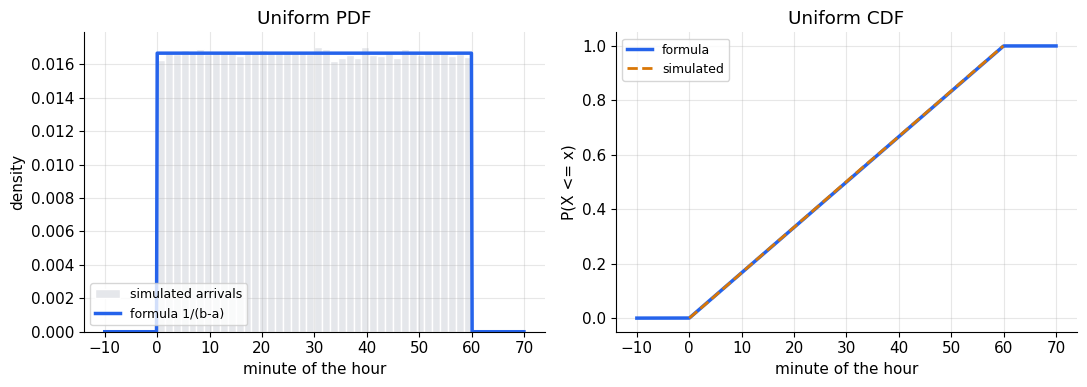

density height 1/(b-a) = 0.016667   average histogram height = 0.016667
P(arrived in the first 15 min): formula 0.2500   counted 0.2503

Uniform(0, 60)   (300,000 simulated draws)
  mean      formula (a+b)/2            =    30.0000   simulated =    29.9797
  variance  formula (b-a)^2/12         =   300.0000   simulated =   299.5378
  gap: mean 0.0203,  variance 0.4622


(np.float64(29.97966889929484), np.float64(299.5377932743097))

In [59]:
a, b = 0.0, 60.0                        # minutes past the hour
draws = RNG7.uniform(a, b, size=300_000)

grid = np.linspace(a - 10, b + 10, 600)
pdf = np.where((grid >= a) & (grid <= b), 1 / (b - a), 0.0)
cdf = np.clip((grid - a) / (b - a), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(draws, bins=40, range=(a, b), density=True, color=C_SOFT,
           edgecolor="white", label="simulated arrivals")
ax[0].plot(grid, pdf, color=C_F, lw=2.5, label="formula 1/(b-a)")
ax[0].set_xlabel("minute of the hour"); ax[0].set_ylabel("density")
ax[0].set_title("Uniform PDF"); ax[0].legend(fontsize=9)

ax[1].plot(grid, cdf, color=C_F, lw=2.5, label="formula")
ax[1].plot(np.sort(draws)[::300], np.linspace(0, 1, draws[::300].size),
           color=C_APPROX, lw=2, ls="--", label="simulated")
ax[1].set_xlabel("minute of the hour"); ax[1].set_ylabel("P(X <= x)")
ax[1].set_title("Uniform CDF"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

heights = np.histogram(draws, bins=40, range=(a, b), density=True)[0]
print(f"density height 1/(b-a) = {1/(b-a):.6f}"
      f"   average histogram height = {heights.mean():.6f}")
print(f"P(arrived in the first 15 min): formula {(15-a)/(b-a):.4f}"
      f"   counted {(draws < 15).mean():.4f}\n")
mv_report("Uniform(0, 60)", "(a+b)/2", "(b-a)^2/12",
          (a + b) / 2, (b - a)**2 / 12, draws)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** 300,000 simulated arrival minutes as a histogram, with the flat formula density laid over it. The bars wobble around the line — that wobble is sampling noise, and it shrinks as you draw more.

**Right:** the CDF is a straight ramp from 0 to 1, which is what 'no minute is favoured' looks like once you accumulate. Half the ramp is reached at the midpoint, so for a uniform the median and the mean coincide.

**The common misread:** reading the flat density as 'every arrival is equally likely, so a given minute has probability 1/60'. The *probability of any exact instant is zero*; only intervals have probability, and the printed line checks one of them. On a continuous scale the density is a rate per unit, not a probability.

</div>

## 7.6 Normal — the shape everything tends toward

**The question:** *a quantity is pushed around by a great many small
independent effects. How is it distributed?*

Almost always: like this.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\,
        \exp\!\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right)$$

$$E[X] = \mu, \qquad \text{Var}(X) = \sigma^2.$$

Two parameters and nothing else: $\mu$ slides the bell along, $\sigma$ makes it
wide or narrow. Its shape never changes, which is why standardising (Part 6 —
subtract the mean, divide by the standard deviation) turns *any* normal into
the same standard one.

### Why it is everywhere

Because of the **Central Limit Theorem**: add up many independent contributions,
none of them dominant, and the sum tends toward this shape *regardless of what
the individual contributions looked like*. The statistics companion notebook
derives and demonstrates it properly; here we simply note that this is the
reason the bell keeps appearing in places nobody designed it into.

### The 68 / 95 / 99.7 rule

For any normal, about 68% of the mass lies within one standard deviation of the
mean, about 95% within two, and about 99.7% within three. This is the single
most useful rule of thumb in applied probability, and the next cell measures all
three proportions rather than repeating them on trust.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

The formula for the bell is less alarming than it looks. Read it from the inside out:

1. $(x - \mu)/\sigma$ — **how many standard deviations from the mean am I?** (That is Part 6's standardising, exactly.)
2. square it — distance on either side counts the same, and being far away counts *much* worse than being near;
3. $e^{-\frac{1}{2}(\cdot)}$ — turn that penalty into a height that falls away fast;
4. $1/(\sigma\sqrt{2\pi})$ — a fixed scaling whose only job is to make the total area exactly 1.

So the whole formula says: **the height falls off with the square of how many standard deviations out you are.** Everything else is bookkeeping.

</div>

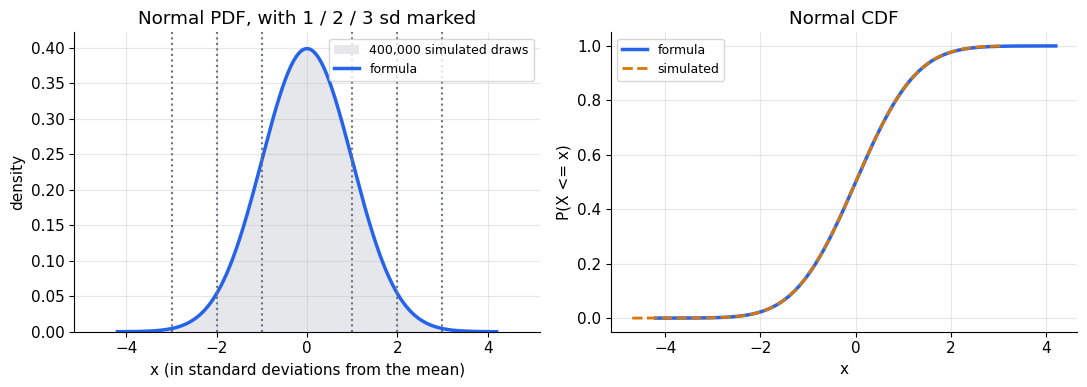

The 68 / 95 / 99.7 rule, checked by counting 400,000 draws:
 within k sd   rule of thumb     measured   exact (erf)
           1          0.6800       0.6823        0.6827
           2          0.9500       0.9544        0.9545
           3          0.9970       0.9974        0.9973

Normal(0, 1)   (400,000 simulated draws)
  mean      formula mu                 =     0.0000   simulated =     0.0008
  variance  formula sigma^2            =     1.0000   simulated =     1.0006
  gap: mean 0.0008,  variance 0.0006


(np.float64(0.0008157396268263338), np.float64(1.000601021721))

In [60]:
from math import erf

MU, SIGMA = 0.0, 1.0
draws = RNG7.normal(MU, SIGMA, size=400_000)

grid = np.linspace(MU - 4.2 * SIGMA, MU + 4.2 * SIGMA, 600)
pdf = np.exp(-0.5 * ((grid - MU) / SIGMA)**2) / (SIGMA * np.sqrt(2 * np.pi))
# The normal CDF without scipy: the error function, straight from math.
cdf = np.array([0.5 * (1 + erf((g - MU) / (SIGMA * np.sqrt(2)))) for g in grid])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(draws, bins=120, density=True, color=C_SOFT, edgecolor="none",
           label="400,000 simulated draws")
for k, shade in [(2, "#EFF6FF"), (1, "#DBEAFE")]:
    band = (grid >= MU - k * SIGMA) & (grid <= MU + k * SIGMA)
    ax[0].fill_between(grid[band], 0, pdf[band], color=shade, zorder=0)
ax[0].plot(grid, pdf, color=C_F, lw=2.5, label="formula")
for k in (1, 2, 3):
    ax[0].axvline(MU + k * SIGMA, color=C_GREY, ls=":")
    ax[0].axvline(MU - k * SIGMA, color=C_GREY, ls=":")
ax[0].set_xlabel("x (in standard deviations from the mean)")
ax[0].set_ylabel("density"); ax[0].set_title("Normal PDF, with 1 / 2 / 3 sd marked")
ax[0].legend(fontsize=9)

ax[1].plot(grid, cdf, color=C_F, lw=2.5, label="formula")
ax[1].plot(np.sort(draws)[::400], np.linspace(0, 1, draws[::400].size),
           color=C_APPROX, lw=2, ls="--", label="simulated")
ax[1].set_xlabel("x"); ax[1].set_ylabel("P(X <= x)")
ax[1].set_title("Normal CDF"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# ---- The 68/95/99.7 rule, measured.
print("The 68 / 95 / 99.7 rule, checked by counting 400,000 draws:")
print(f"{'within k sd':>12} {'rule of thumb':>15} {'measured':>12} {'exact (erf)':>13}")
for k, thumb in [(1, 0.68), (2, 0.95), (3, 0.997)]:
    measured = (np.abs(draws - MU) <= k * SIGMA).mean()
    print(f"{k:>12} {thumb:>15.4f} {measured:>12.4f} {erf(k/np.sqrt(2)):>13.4f}")
print()
mv_report("Normal(0, 1)", "mu", "sigma^2", MU, SIGMA**2, draws)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the histogram of 400,000 draws with the formula on top, and dotted lines at one, two and three standard deviations either side. The shaded bands are the 68% and 95% regions. Notice how little is left beyond three: the tails of a normal are extremely thin, which is its most consequential property and its most dangerous one.

**Right:** the CDF, a smooth S. Its steepest part is at the mean, where the density is highest — the CDF's slope *is* the density, which is Part 5's relationship seen from the side.

The printed table gives the rule of thumb, the proportion actually measured, and the exact value from the error function. Three columns that agree.

**The common misread:** '95% within two standard deviations' getting flipped into 'anything beyond two standard deviations is impossible'. About one draw in twenty is out there, and in a dataset of 10,000 rows that is roughly 500 points — perfectly ordinary, and routinely mislabelled as outliers or bugs.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Why the normal assumption is everywhere.** Three separate reasons, and it helps to keep them apart.

1. **The CLT, honestly applied**: things that really are sums of many small independent effects — measurement noise, averaged features, the sampling distribution of an estimate — are genuinely close to normal.
2. **Mathematical convenience**: the normal is the distribution whose negative log-likelihood is squared error. Every time you minimise MSE you are, whether you meant to or not, fitting a model with normal noise. Part 9 makes that link explicit.
3. **Habit**: initialisers, priors, VAE latents, diffusion noise — the normal gets chosen because it is closed under addition, easy to sample from, and differentiable everywhere.

**When it is wrong, and how it bites.** Financial returns, network traffic, word frequencies, wealth, file sizes and time-to-failure are all heavy-tailed: events the normal says happen once a millennium happen monthly. A model with normal residuals will look excellent on the bulk of the data and be catastrophically overconfident on exactly the cases you care about. Symptoms worth watching for: a residual histogram with fat tails, counts far more spread out than a Poisson allows, or a variable that cannot go negative whose fitted normal happily does.

</div>

## 7.7 Exponential — the waiting time between events

**The question:** *spam arrives at a rate of $\lambda$ per hour. How long until
the next one?*

This is the geometric's continuous twin. The geometric counted whole trials; the
exponential measures continuous time between Poisson events:

$$f(x) = \lambda e^{-\lambda x}, \qquad F(x) = 1 - e^{-\lambda x},
\qquad x \ge 0.$$

$$E[X] = \frac{1}{\lambda}, \qquad \text{Var}(X) = \frac{1}{\lambda^2}.$$

At 3 spam per hour the average wait is a third of an hour — and, as with the
geometric, the *most likely* wait is near zero while the mean is dragged up by a
long tail.

Two facts make this distribution worth its own section.

**It is memoryless**, and it is the only continuous distribution that is:
$P(X > s + t \mid X > s) = P(X > t)$. A component whose lifetime is exponential
does not age; a bus whose gaps are exponential is not more likely to come
because you have been waiting.

**It pairs exactly with the Poisson.** If the waits between arrivals are
Exponential($\lambda$), then the *count* of arrivals in a window of length $t$
is Poisson($\lambda t$). One process, two views — gaps or counts — and the next
cell checks that both views really are the same process, by simulating the gaps
and then counting the arrivals.


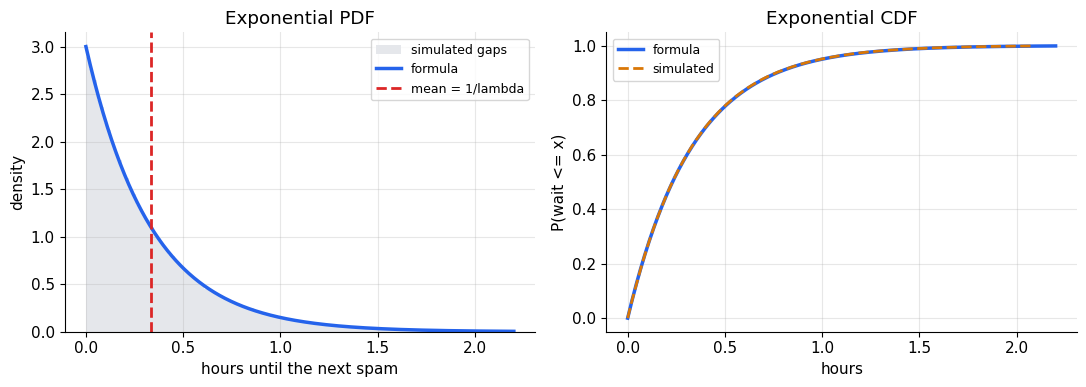

Exponential(lambda=3)   (300,000 simulated draws)
  mean      formula 1/lambda           =     0.3333   simulated =     0.3327
  variance  formula 1/lambda^2         =     0.1111   simulated =     0.1110
  gap: mean 0.0006,  variance 0.0002

Memorylessness of the wait (half an hour more):
 waited s hours   P(X > s+0.5 | X > s)   P(X > 0.5)
           0.00                 0.2216       0.2216
           0.25                 0.2211       0.2216
           0.50                 0.2230       0.2216
           1.00                 0.2278       0.2216

Counting arrivals per 1-hour window, over 20,103 windows:
  k   observed   Poisson(3)
  0     0.0488       0.0498
  1     0.1563       0.1494
  2     0.2232       0.2240
  3     0.2227       0.2240
  4     0.1641       0.1680
  5     0.1007       0.1008
  6     0.0516       0.0504
  7     0.0213       0.0216
  8     0.0082       0.0081

mean count per hour = 2.9846   (lambda = 3.0)


In [61]:
from math import factorial

LAM = 3.0                                # spam per hour
gaps = RNG7.exponential(1 / LAM, size=300_000)

grid = np.linspace(0, 2.2, 500)
pdf = LAM * np.exp(-LAM * grid)
cdf = 1 - np.exp(-LAM * grid)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(gaps, bins=120, range=(0, 2.2), density=True, color=C_SOFT,
           edgecolor="none", label="simulated gaps")
ax[0].plot(grid, pdf, color=C_F, lw=2.5, label="formula")
ax[0].axvline(1 / LAM, color=C_SLOPE, ls="--", lw=2, label="mean = 1/lambda")
ax[0].set_xlabel("hours until the next spam"); ax[0].set_ylabel("density")
ax[0].set_title("Exponential PDF"); ax[0].legend(fontsize=9)

trimmed = np.sort(gaps[gaps < 2.2])[::200]
ax[1].plot(grid, cdf, color=C_F, lw=2.5, label="formula")
ax[1].plot(trimmed, np.linspace(0, (gaps < 2.2).mean(), trimmed.size),
           color=C_APPROX, lw=2, ls="--", label="simulated")
ax[1].set_xlabel("hours"); ax[1].set_ylabel("P(wait <= x)")
ax[1].set_title("Exponential CDF"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

mv_report("Exponential(lambda=3)", "1/lambda", "1/lambda^2",
          1 / LAM, 1 / LAM**2, gaps)

# ---- Memoryless, checked.
print("\nMemorylessness of the wait (half an hour more):")
print(f"{'waited s hours':>15} {'P(X > s+0.5 | X > s)':>22} {'P(X > 0.5)':>12}")
base = (gaps > 0.5).mean()
for s in [0.0, 0.25, 0.5, 1.0]:
    survived = gaps > s
    print(f"{s:>15.2f} {(gaps > s + 0.5)[survived].mean():>22.4f} {base:>12.4f}")

# ---- Exponential gaps and Poisson counts are one process seen two ways.
arrival_times = np.cumsum(RNG7.exponential(1 / LAM, size=60_000))
counts = np.histogram(arrival_times,
                      bins=np.arange(0, np.ceil(arrival_times[-1]) + 1))[0]
print(f"\nCounting arrivals per 1-hour window, over {counts.size:,} windows:")
print(f"{'k':>3} {'observed':>10} {'Poisson(3)':>12}")
for k in range(9):
    print(f"{k:>3} {(counts == k).mean():>10.4f} "
          f"{LAM**k * np.exp(-LAM) / factorial(k):>12.4f}")
print(f"\nmean count per hour = {counts.mean():.4f}   (lambda = {LAM})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the gaps between spam arrivals. The density is highest at zero and falls away — short gaps are the most common — while the dashed line marks the mean wait, which sits well to the right of the peak. Arrivals clump.

**Right:** the CDF rising toward 1; the simulated curve stops where we cut the axis, not because the distribution ends there.

The first printed table repeats the memorylessness test in continuous time. The second is the more interesting one: we generated *waiting times*, added them up into arrival times, then counted arrivals per hour — and the counts came out Poisson, matching a formula column we never used to generate anything.

**The common misread:** seeing clumps in the arrival times and concluding something caused them. Genuinely random arrivals *look* clustered; evenly spaced arrivals would be the anomaly. It is the same instinct that makes a shuffled playlist feel rigged.

</div>

In [62]:
# ============================================================
#  All seven at once: the formula for the mean and variance,
#  beside a fresh simulation of each. Nothing is asserted.
# ============================================================
p, n, LAM, MU, SIGMA, a, b = 0.30, 10, 3.0, 0.0, 1.0, 0.0, 60.0
M_DRAWS = 400_000
R = np.random.default_rng(7777)

rows = [
    ("Bernoulli(0.3)",    "p",         "p(1-p)",     p,           p * (1 - p),
     (R.random(M_DRAWS) < p).astype(float)),
    ("Binomial(10, 0.3)", "np",        "np(1-p)",    n * p,       n * p * (1 - p),
     R.binomial(n, p, M_DRAWS).astype(float)),
    ("Geometric(0.3)",    "1/p",       "(1-p)/p^2",  1 / p,       (1 - p) / p**2,
     R.geometric(p, M_DRAWS).astype(float)),
    ("Poisson(3)",        "lambda",    "lambda",     LAM,         LAM,
     R.poisson(LAM, M_DRAWS).astype(float)),
    ("Uniform(0, 60)",    "(a+b)/2",   "(b-a)^2/12", (a + b) / 2, (b - a)**2 / 12,
     R.uniform(a, b, M_DRAWS)),
    ("Normal(0, 1)",      "mu",        "sigma^2",    MU,          SIGMA**2,
     R.normal(MU, SIGMA, M_DRAWS)),
    ("Exponential(3)",    "1/lambda",  "1/lambda^2", 1 / LAM,     1 / LAM**2,
     R.exponential(1 / LAM, M_DRAWS)),
]

hdr = (f"{'distribution':<20}{'mean fmla':<11}{'theory':>9}{'simulated':>11}   "
       f"{'var fmla':<12}{'theory':>9}{'simulated':>11}")
print(hdr); print("-" * len(hdr))
worst_mean, worst_var = 0.0, 0.0
for name, mf, vf, tm, tv, s in rows:
    sm, sv = s.mean(), s.var()
    # A mean of 0 makes a relative gap meaningless, so measure the mean's gap
    # in units of the distribution's own standard deviation instead.
    worst_mean = max(worst_mean, abs(sm - tm) / np.sqrt(tv))
    worst_var = max(worst_var, abs(sv - tv) / tv)
    print(f"{name:<20}{mf:<11}{tm:>9.4f}{sm:>11.4f}   {vf:<12}{tv:>9.4f}{sv:>11.4f}")
print("-" * len(hdr))
print(f"worst mean gap, in units of that distribution's own sd : {worst_mean:.4f}")
print(f"worst variance gap, as a fraction of the variance      : {worst_var:.4%}")
print(f"({M_DRAWS:,} draws each -- these gaps shrink like 1/sqrt(M).)")


distribution        mean fmla     theory  simulated   var fmla       theory  simulated
--------------------------------------------------------------------------------------
Bernoulli(0.3)      p             0.3000     0.3015   p(1-p)         0.2100     0.2106
Binomial(10, 0.3)   np            3.0000     3.0047   np(1-p)        2.1000     2.1005
Geometric(0.3)      1/p           3.3333     3.3330   (1-p)/p^2      7.7778     7.7673
Poisson(3)          lambda        3.0000     3.0058   lambda         3.0000     3.0035
Uniform(0, 60)      (a+b)/2      30.0000    29.9960   (b-a)^2/12   300.0000   299.9929
Normal(0, 1)        mu            0.0000     0.0022   sigma^2        1.0000     0.9997
Exponential(3)      1/lambda      0.3333     0.3322   1/lambda^2     0.1111     0.1101
--------------------------------------------------------------------------------------
worst mean gap, in units of that distribution's own sd : 0.0035
worst variance gap, as a fraction of the variance      : 0.9016%
(

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Fourteen textbook results — a mean and a variance for each of the seven distributions — computed from their formulas and, in the same cell, estimated by simulating 400,000 draws of each with a fresh generator. The last two printed lines are the worst disagreement across all fourteen — the mean's gap measured in units of that distribution's own standard deviation (a relative gap would be meaningless for the normal, whose mean is 0), and the variance's gap as a fraction of the variance.

This is the only reason to trust any of the formulas above. Not one of them was derived here in full (the integrals behind the continuous cases in particular were quoted), so every one of them is checked instead. If a formula had been mistyped, its row would stand out immediately — try it: change `(1-p)/p**2` to `1/p**2` and watch the geometric row split.

The gaps that remain are sampling noise, and they shrink like $1/\sqrt{M}$. The geometric and exponential rows tend to show the largest gaps, because long-tailed distributions need more draws before their variance settles down.

</div>

## 7.8 Choosing one: the decision table

You will not need to remember the formulas. You will need to recognise the
question. Read this table from the **left** column — never from the right.

| The question you are actually asking | Distribution | Key parameter |
|---|---|---|
| Will this one thing happen or not? | Bernoulli($p$) | $p$ = chance of yes |
| How many of $n$ independent tries succeed? | Binomial($n, p$) | $n$ tries, chance $p$ each |
| How many tries until the first success? | Geometric($p$) | $p$ = chance per try |
| How many rare events in a fixed window? | Poisson($\lambda$) | $\lambda$ = expected count **per window** |
| A value in a range, nothing preferred | Uniform($a, b$) | the two endpoints |
| A quantity made of many small effects | Normal($\mu, \sigma^2$) | centre and spread |
| How long until the next event? | Exponential($\lambda$) | $\lambda$ = rate per unit time |

Three relationships tie them together, and they are worth more than the table:

- A **Binomial** is a pile of **Bernoulli** trials added up.
- A **Poisson** is a Binomial with $n$ enormous and $p$ tiny — the picture in §7.4.
- **Exponential** gaps and **Poisson** counts are the same process seen two ways,
  and the **Geometric** is the discrete version of the exponential.

### Doing this with `scipy.stats`

In practice you call a library rather than writing the PMF out by hand. Every
distribution in `scipy.stats` exposes the same handful of methods, which is the
real thing to learn:

| Call | Gives you |
|---|---|
| `.pmf(k)` / `.pdf(x)` | the height at a point (discrete / continuous) |
| `.cdf(x)` | $P(X \le x)$ |
| `.ppf(q)` | the inverse of the CDF: the value with $q$ of the mass below it |
| `.rvs(size)` | random draws |
| `.mean()`, `.var()` | the theoretical mean and variance |

The next cell uses all of them, and checks scipy's numbers against the ones we
computed by hand above.


In [63]:
from scipy import stats
from math import comb

# ---- The same binomial, two ways.
n, p = 10, 0.30
B = stats.binom(n, p)                       # a "frozen" distribution object
ks = np.arange(n + 1)

by_hand = np.array([comb(n, k) * p**k * (1 - p)**(n - k) for k in ks])
by_scipy = B.pmf(ks)
print("Binomial(10, 0.3) PMF")
print(f"{'k':>3} {'by hand':>12} {'scipy .pmf':>12} {'difference':>13}")
for k in ks[:6]:
    print(f"{k:>3} {by_hand[k]:>12.8f} {by_scipy[k]:>12.8f} "
          f"{abs(by_hand[k] - by_scipy[k]):>13.2e}")
print(f"largest difference over all {n+1} values: {np.abs(by_hand - by_scipy).max():.2e}")

# ---- The other methods.
q90 = B.ppf(0.9)
print(f"\n.cdf(3)   P(at most 3 spam in 10)    = {B.cdf(3):.6f}"
      f"   (by hand: {by_hand[:4].sum():.6f})")
print(f".ppf(0.9) fewest spam covering 90%   = {q90:.0f}"
      f"   (cdf there = {B.cdf(q90):.4f}, one below = {B.cdf(q90 - 1):.4f})")
print(f".mean()                              = {B.mean():.4f}   (n*p = {n*p:.4f})")
print(f".var()                               = {B.var():.4f}   (n*p*(1-p) = {n*p*(1-p):.4f})")
print(f".rvs(200000).mean()                  = "
      f"{B.rvs(size=200_000, random_state=99).mean():.4f}")

# ---- Continuous: the normal, and the 68/95/99.7 numbers exactly.
Z = stats.norm(0, 1)
print("\nNormal(0,1) via scipy -- where the rule of thumb comes from:")
for k in (1, 2, 3):
    print(f"  within {k} sd: {Z.cdf(k) - Z.cdf(-k):.6f}")
print(f"  .ppf(0.975) = {Z.ppf(0.975):.6f}   <- the 1.96 everyone quotes")

# ---- All seven, scipy's own mean and variance against ours.
print("\nthe same seven distributions, scipy's mean and variance vs ours:")
for name, dist, tm, tv in [
        ("bernoulli(0.3)",   stats.bernoulli(0.3),   0.30,      0.21),
        ("binom(10,0.3)",    stats.binom(10, 0.3),   3.00,      2.10),
        ("geom(0.3)",        stats.geom(0.3),        1 / 0.3,   0.7 / 0.09),
        ("poisson(3)",       stats.poisson(3),       3.00,      3.00),
        ("uniform(0,60)",    stats.uniform(0, 60),   30.0,      3600 / 12),
        ("norm(0,1)",        stats.norm(0, 1),       0.00,      1.00),
        ("expon(scale=1/3)", stats.expon(scale=1/3), 1 / 3,     1 / 9)]:
    print(f"  {name:<18} mean {dist.mean():>9.4f} (ours {tm:>9.4f})"
          f"   var {dist.var():>9.4f} (ours {tv:>9.4f})")


Binomial(10, 0.3) PMF
  k      by hand   scipy .pmf    difference
  0   0.02824752   0.02824752      1.73e-17
  1   0.12106082   0.12106082      4.16e-17
  2   0.23347444   0.23347444      2.22e-16
  3   0.26682793   0.26682793      5.55e-17
  4   0.20012095   0.20012095      0.00e+00
  5   0.10291935   0.10291935      5.55e-17
largest difference over all 11 values: 2.22e-16

.cdf(3)   P(at most 3 spam in 10)    = 0.649611   (by hand: 0.649611)
.ppf(0.9) fewest spam covering 90%   = 5   (cdf there = 0.9527, one below = 0.8497)
.mean()                              = 3.0000   (n*p = 3.0000)
.var()                               = 2.1000   (n*p*(1-p) = 2.1000)
.rvs(200000).mean()                  = 3.0006

Normal(0,1) via scipy -- where the rule of thumb comes from:
  within 1 sd: 0.682689
  within 2 sd: 0.954500
  within 3 sd: 0.997300
  .ppf(0.975) = 1.959964   <- the 1.96 everyone quotes

the same seven distributions, scipy's mean and variance vs ours:
  bernoulli(0.3)     mean    0.300

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Everything computed by hand in this part, re-computed by `scipy.stats` and printed side by side: the binomial PMF value by value, its CDF, its mean, its variance, and then the mean and variance of all seven distributions.

This matters more than it looks. Hand-rolled formulas and a library agreeing to the last decimal place means the formulas above are the same objects the tools implement — so you can move between them freely, and when a library result surprises you, you have a way to check it instead of a reason to trust it.

One naming trap the printed table exposes: scipy parameterises the exponential by **scale** $= 1/\lambda$, not by the rate $\lambda$, and `uniform(0, 60)` means *start at 0, width 60*, not *from 0 to 60*. Both conventions differ from the formulas above, which is exactly why the printed means are checked against ours rather than assumed to match.

</div>

---

### Where this leaves us

Seven distributions, each one the answer to a question, every mean and variance
checked against a simulation rather than quoted. That is the vocabulary — from
here on, "the residuals look Poisson" or "assume normal noise" is a sentence
with content rather than jargon.

But every distribution in this part described **one** variable at a time. Real
questions are almost never like that. Does 'free' appearing tell you anything
about 'winner' appearing? Do two features in a model carry the same information
or different information? Which pairs of variables move together, and how would
you even measure that?

**Part 8** puts several variables in the same picture: joint distributions,
where the margins come from, what independence looks like in a table, and the
two numbers — covariance and correlation — that summarise how two things move
together. Along with a careful account of what those two numbers *cannot* tell
you, which turns out to be a longer list than most people expect.


---

# 8️⃣ Many variables at once: joint, marginal, covariance

Every distribution in Part 7 described **one** quantity. That is almost never
the situation you are in. A model has dozens of features and wants to know which
ones say the same thing twice; an inbox has words that travel together; a
dataset has columns whose relationships are the entire point.

So we need a way to talk about two or more random variables **at the same
time**, and this part builds exactly three things:

1. **The joint distribution** — the full picture: the probability of every
   combination of values. Everything else in this part is squeezed out of it.
2. **Marginals and conditionals** — the one-variable and given-the-other views,
   both obtained from the joint by simple arithmetic on a table.
3. **Covariance and correlation** — two numbers that summarise a whole joint
   distribution into "do these move together?", together with an honest account
   of everything that summary throws away.

That third point deserves warning up front. Correlation is the most-used and
most-abused number in data science. By the end of this part you will have seen,
with your own simulations, a pair of variables where one *determines* the other
exactly and the correlation is nevertheless zero, and four datasets with
identical summary statistics that look nothing alike.


In [64]:
# ============================================================
#  Part 8 setup. Its own generator, and one extra variable
#  that is independent of everything by construction -- we
#  will need a genuine negative when we test for independence.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

RNG8 = np.random.default_rng(808)

F = inbox["free"]          # does the email contain 'free'?
W = inbox["winner"]        # ... 'winner'?
M = inbox["meeting"]       # ... 'meeting'?
Rp = inbox["report"]       # ... 'report'?
TUE = RNG8.random(N_EMAILS) < 0.5    # was it sent on a Tuesday? (unrelated to all of it)


def joint_table(x, y):
    """The 2x2 joint distribution of two yes/no variables: P(X = i, Y = j)."""
    T = np.zeros((2, 2))
    for i in (0, 1):
        for j in (0, 1):
            T[i, j] = ((x == i) & (y == j)).mean()
    return T


def show_joint(T, xname, yname):
    print(f"          P({xname} = i, {yname} = j)")
    print(f"{'':>14}{yname + ' = no':>15}{yname + ' = yes':>15}{'row total':>13}")
    for i, lab in enumerate([xname + " = no", xname + " = yes"]):
        print(f"{lab:>14}{T[i,0]:>15.4f}{T[i,1]:>15.4f}{T[i].sum():>13.4f}")
    print(f"{'col total':>14}{T[:,0].sum():>15.4f}{T[:,1].sum():>15.4f}{T.sum():>13.4f}")


J = joint_table(F, W)
show_joint(J, "free", "winner")
print(f"\nthe four cells sum to {J.sum():.10f}  -- every email lands in exactly one")
print(f"and there are {N_EMAILS:,} emails, so each cell is a count divided by that.")


          P(free = i, winner = j)
                  winner = no   winner = yes    row total
     free = no         0.7441         0.0621       0.8063
    free = yes         0.1245         0.0692       0.1937
     col total         0.8686         0.1313       1.0000

the four cells sum to 1.0000000000  -- every email lands in exactly one
and there are 20,000 emails, so each cell is a count divided by that.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The **joint distribution** of two yes/no variables, printed as a table of four probabilities. Each cell is the proportion of the 20,000 emails in which that exact combination happened: no-and-no, no-and-yes, yes-and-no, yes-and-yes.

This table *is* the complete answer about these two variables together. Nothing about their relationship exists outside it — every marginal, every conditional, the covariance and the correlation are all arithmetic on these four numbers.

The four cells sum to 1, printed to ten places, because the four combinations are mutually exclusive and cover everything: Part 1's axioms, applied to a grid instead of a line.

**The common misread:** reading the top-left cell as 'the probability that neither word appears, given the email is not spam' or some other conditional. There is no 'given' anywhere in this table. Every cell is an **unconditional** probability of a combination, and the whole table is normalised together, not row by row.

</div>

## 8.1 Marginals: where the name comes from

Suppose you have the joint table and someone asks the simpler question: *how
often does 'free' appear at all?* — never mind 'winner'.

An email with 'free' either has 'winner' or does not, and those two cases are
exclusive and exhaust the possibilities. So add them:

$$P(F = 1) = P(F = 1, W = 0) + P(F = 1, W = 1) = \sum_{w} P(F = 1, W = w).$$

**Sum along a row** and you get the probability for that row's variable. Sum
down a column and you get the other one. These are called **marginal**
distributions for a wonderfully mundane reason: on a paper table, people wrote
the row and column totals in the margins.

The direction of travel matters. Going from the joint to a marginal is always
possible — just add. Going back is **not**: two variables with the same margins
can have entirely different joints, which is the whole reason the joint is the
real object and the margins are a summary of it.


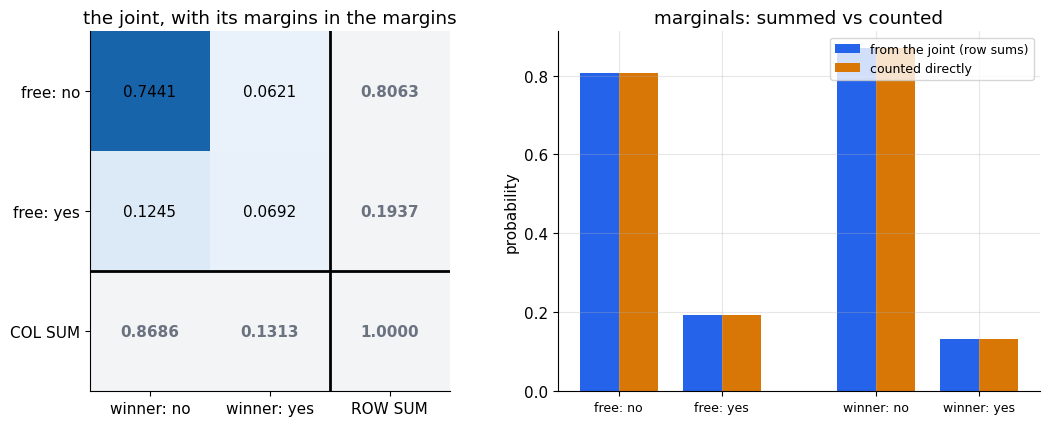

P(free)   from row sums 0.1937   counted directly 0.1938
P(winner) from col sums 0.1313   counted directly 0.1313
both marginals sum to 1: 1.000000 and 1.000000


In [65]:
p_free = J.sum(axis=1)          # sum along each row  -> the 'free' marginal
p_winner = J.sum(axis=0)        # sum down each column -> the 'winner' marginal

# ---- Left panel: the joint table with its margins literally in the margins.
aug = np.zeros((3, 3))
aug[:2, :2] = J
aug[:2, 2] = p_free
aug[2, :2] = p_winner
aug[2, 2] = J.sum()

inner = np.full((3, 3), np.nan)
inner[:2, :2] = J                       # colour only the joint cells

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
cmap = plt.get_cmap("Blues").copy(); cmap.set_bad("#F3F4F6")
ax[0].imshow(inner, cmap=cmap, vmin=0, vmax=J.max() * 1.25)
for i in range(3):
    for j in range(3):
        edge = (i == 2) or (j == 2)
        ax[0].text(j, i, f"{aug[i, j]:.4f}", ha="center", va="center",
                   color=C_GREY if edge else "black",
                   fontweight="bold" if edge else "normal", fontsize=11)
ax[0].axhline(1.5, color="black", lw=2); ax[0].axvline(1.5, color="black", lw=2)
ax[0].set_xticks([0, 1, 2]); ax[0].set_yticks([0, 1, 2])
ax[0].set_xticklabels(["winner: no", "winner: yes", "ROW SUM"])
ax[0].set_yticklabels(["free: no", "free: yes", "COL SUM"])
ax[0].set_title("the joint, with its margins in the margins")
ax[0].grid(False)

# ---- Right panel: those margins, checked against a direct count.
x = np.arange(2)
ax[1].bar(x - 0.19, p_free, width=0.38, color=C_F, label="from the joint (row sums)")
ax[1].bar(x + 0.19, [(F == 0).mean(), (F == 1).mean()], width=0.38,
          color=C_APPROX, label="counted directly")
ax[1].bar(x + 2.5 - 0.19, p_winner, width=0.38, color=C_F)
ax[1].bar(x + 2.5 + 0.19, [(W == 0).mean(), (W == 1).mean()], width=0.38, color=C_APPROX)
ax[1].set_xticks([0, 1, 2.5, 3.5])
ax[1].set_xticklabels(["free: no", "free: yes", "winner: no", "winner: yes"],
                      fontsize=9)
ax[1].set_ylabel("probability"); ax[1].set_title("marginals: summed vs counted")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"P(free)   from row sums {p_free[1]:.4f}   counted directly {F.mean():.4f}")
print(f"P(winner) from col sums {p_winner[1]:.4f}   counted directly {W.mean():.4f}")
print(f"both marginals sum to 1: {p_free.sum():.6f} and {p_winner.sum():.6f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the four joint probabilities in blue, with the row totals down the right edge and the column totals along the bottom — in the margins, which is where the name came from. The grey corner is the grand total, 1. Every marginal in this notebook is that operation: collapse one direction by adding.

**Right:** the same marginals two ways. Blue is what you get by summing the joint table; orange is what you get by ignoring the table entirely and counting how many emails contain each word. Identical bars, because summing out a variable is exactly the same act as never having recorded it.

**The common misread:** thinking the margins tell you about the relationship. They cannot, by construction — they are what is left *after* the other variable has been summed away. Two datasets can share these exact margins and have opposite relationships inside, which is why §8.4's independence test compares the joint against the margins rather than reading the margins alone.

</div>

## 8.2 Conditionals from the joint: divide a row by its total

Part 3 defined the conditional probability

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)},$$

and said the vertical bar means *restrict attention to the cases where $B$
happened, then ask about $A$ within them*. In a joint table that instruction
becomes something you can do with your finger.

To get $P(W \mid F = 1)$: go to the **free = yes** row. That row holds
$P(F=1, W=0)$ and $P(F=1, W=1)$ — the numerators. Its total is $P(F = 1)$ —
the denominator. So

$$P(W = w \mid F = 1) = \frac{P(F = 1, W = w)}{P(F = 1)}
   = \frac{\text{cell}}{\text{its row total}}.$$

**Divide a row by its own total and it becomes a conditional distribution.**
That is the whole operation. The row's entries sum to $P(F=1)$, which is less
than 1; dividing renormalises them so they sum to 1 again — because once you
have decided to look only at emails containing 'free', those emails are now the
entire world.

The same table, divided the other way, gives $P(F \mid W)$ — a different
question with a different answer, which is Part 4's warning about flipping the
bar.


In [66]:
# ---- P(winner | free = yes): the 'free = yes' row, divided by its own total.
row = J[1]                       # [ P(F=1,W=0), P(F=1,W=1) ]
cond_from_joint = row / row.sum()

# ---- The same thing computed by actually restricting to those emails.
cond_direct = np.array([(W[F] == 0).mean(), (W[F] == 1).mean()])

print("P(winner | free = yes)")
print(f"{'':>14}{'from the joint':>17}{'by restricting':>16}")
for j, lab in enumerate(["winner = no", "winner = yes"]):
    print(f"{lab:>14}{cond_from_joint[j]:>17.4f}{cond_direct[j]:>16.4f}")
print(f"{'sums to':>14}{cond_from_joint.sum():>17.4f}{cond_direct.sum():>16.4f}"
      f"   <- renormalised: the row is now the whole world")

# ---- And the other direction, which is a different question.
col = J[:, 1]
print(f"\nP(free | winner = yes)  = {col[1] / col.sum():.4f}")
print(f"P(winner | free = yes)  = {cond_from_joint[1]:.4f}")
print("Different numbers from the same four cells. The bar does not flip for free")
print("-- that asymmetry is exactly what Bayes' theorem in Part 4 repairs.")

# ---- Every conditional, both directions, from one table.
print("\nthe complete conditional picture, all from J:")
for i, lab in enumerate(["free = no ", "free = yes"]):
    r = J[i] / J[i].sum()
    print(f"  P(winner = yes | {lab}) = {r[1]:.4f}")
for j, lab in enumerate(["winner = no ", "winner = yes"]):
    c = J[:, j] / J[:, j].sum()
    print(f"  P(free = yes | {lab}) = {c[1]:.4f}")


P(winner | free = yes)
                 from the joint  by restricting
   winner = no           0.6428          0.6428
  winner = yes           0.3572          0.3572
       sums to           1.0000          1.0000   <- renormalised: the row is now the whole world

P(free | winner = yes)  = 0.5268
P(winner | free = yes)  = 0.3572
Different numbers from the same four cells. The bar does not flip for free
-- that asymmetry is exactly what Bayes' theorem in Part 4 repairs.

the complete conditional picture, all from J:
  P(winner = yes | free = no ) = 0.0771
  P(winner = yes | free = yes) = 0.3572
  P(free = yes | winner = no ) = 0.1434
  P(free = yes | winner = yes) = 0.5268


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

A joint table answers three different kinds of question depending on what you divide by, and that is the only difference between them:

- **Joint** — divide by nothing. *Out of all emails, what fraction have both?*
- **Marginal** — sum a row or column. *Out of all emails, what fraction have this one?*
- **Conditional** — divide a row by its own total. *Out of the emails in this row, what fraction have that?*

Same four numbers, three questions. Nearly every confusion about probability tables is having answered one of these while believing you answered another — and the printed output shows how far apart two of them can be.

</div>

## 8.3 Independence, seen in the table

Part 3 defined independence as *knowing one tells you nothing about the other*,
and wrote it as $P(A \mid B) = P(A)$. In joint-table language it becomes
something you can check by eye:

$$P(X = x, Y = y) = P(X = x)\,P(Y = y) \quad \text{for every cell.}$$

**The joint table factorises into the product of its margins.** If that holds
everywhere, the two variables are independent; if it fails in even one cell,
they are not.

That is a much more demanding statement than "the correlation is zero", and the
difference between the two will cost us a whole section shortly.

One practical wrinkle: with real (or simulated) data the two sides will never be
*exactly* equal, because counting 20,000 emails gives noisy estimates. So we
need a test that separates "different" from "different by less than the noise".
`scipy.stats.chi2_contingency` does precisely that job on a table of counts: it
reports how surprising the observed table would be if the variables really were
independent. A large p-value means the gap looks like noise; a tiny one means it
does not.


In [67]:
from scipy import stats

VARS = {"free": F, "winner": W, "meeting": M, "report": Rp, "tuesday": TUE}
pairs = [(a, b) for i, a in enumerate(VARS) for b in list(VARS)[i + 1:]]

print("Does the joint table factorise into the product of its margins?\n")
hdr = (f"{'pair':<22}{'largest |joint - product|':>26}{'chi-sq p-value':>16}"
       f"{'verdict':>16}")
print(hdr); print("-" * len(hdr))
for a, b in pairs:
    x, y = VARS[a], VARS[b]
    T = joint_table(x, y)
    product = np.outer(T.sum(axis=1), T.sum(axis=0))
    counts = (T * N_EMAILS).round().astype(int)
    p_value = stats.chi2_contingency(counts)[1]
    verdict = "factorises" if p_value > 0.01 else "does NOT"
    print(f"{a + ' & ' + b:<22}{np.abs(T - product).max():>26.5f}"
          f"{p_value:>16.4f}{verdict:>16}")
print("-" * len(hdr))
print("'tuesday' was generated independently of everything, and it is the only")
print("variable that factorises with the others. Every pair of words fails --")
print("because every word depends on whether the email is spam.\n")

# ---- But look inside one value of spam: the words come apart.
print("Now hold 'spam' fixed and repeat the test on 'free' and 'winner':")
for label, mask in [("spam only    ", is_spam), ("not spam only", ~is_spam)]:
    T = joint_table(F[mask], W[mask])
    product = np.outer(T.sum(axis=1), T.sum(axis=0))
    counts = (T * mask.sum()).round().astype(int)
    print(f"  {label}: largest gap {np.abs(T - product).max():.5f}, "
          f"p = {stats.chi2_contingency(counts)[1]:.4f}")
print("\nWithin a single class the two words are independent -- they were")
print("generated that way. That is 'conditional independence', and it is the")
print("assumption the naive Bayes classifier in Part 9 is built on.")


Does the joint table factorise into the product of its margins?

pair                   largest |joint - product|  chi-sq p-value         verdict
--------------------------------------------------------------------------------
free & winner                            0.04375          0.0000        does NOT
free & meeting                           0.03684          0.0000        does NOT
free & report                            0.02890          0.0000        does NOT
free & tuesday                           0.00129          0.3663      factorises
winner & meeting                         0.02887          0.0000        does NOT
winner & report                          0.02161          0.0000        does NOT
winner & tuesday                         0.00016          0.9085      factorises
meeting & report                         0.01903          0.0000        does NOT
meeting & tuesday                        0.00198          0.2160      factorises
report & tuesday                         0.0

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Independence claimed, then tested — twice, in opposite directions.

**Every pair of words fails to factorise**, with p-values that leave no room for doubt, and the reason is visible in Part 0's generating code: each word's probability depends on whether the email is spam, so all four words carry a shared signal. Seeing 'free' really does change what you expect from 'winner'.

**'tuesday' factorises with everything.** It was generated from its own coin flip with no reference to anything else, and the test agrees. This is the control: without a variable that genuinely is independent, a test that says 'not independent' about everything would prove nothing.

**Inside one value of spam, the words become independent again.** That is not a contradiction, it is the most important structural fact in this notebook: variables can be dependent overall and independent once you condition on a common cause. Part 9's naive Bayes classifier assumes exactly this, and here it is true because we built the data that way — which is precisely why it is usually only approximately true elsewhere.

</div>

## 8.4 Covariance: one number for "do they move together?"

A joint table is complete but bulky, and for continuous variables it is not even
a table. So we want a single number summarising whether two variables move in
the same direction.

Start from a sensible instinct. For each observation, ask *is this one above or
below average, in each variable?* — then multiply the two answers:

$$\text{Cov}(X, Y) = E\big[(X - E[X])(Y - E[Y])\big].$$

Work through the signs, because this is the whole idea:

- both above average, or both below → the two deviations have the **same** sign
  → their product is **positive**;
- one above while the other is below → **opposite** signs → the product is
  **negative**.

Average those products. A positive covariance means the "both above or both
below" cases dominated; a negative one means the "one up, one down" cases did;
near zero means they cancelled out.

Two consequences fall straight out of the definition, and both are worth
noticing now:

- $\text{Cov}(X, X) = E[(X - E[X])^2] = \text{Var}(X)$ — variance is just
  covariance with yourself, which is why Part 6 and this section share a shape.
- Part 6's $\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$ needed
  independence. The full truth is
  $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y) + 2\,\text{Cov}(X,Y)$, and
  the covariance term is exactly what independence sends to zero.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\text{Cov}(X, Y) = E[(X - E[X])(Y - E[Y])]$ is four instructions read right to left:

1. for each observation, how far is $X$ from its own average? (**above** = positive, **below** = negative);
2. same for $Y$;
3. multiply those two numbers together — same-side pairs give a positive product, opposite-side pairs a negative one;
4. average over all observations.

So covariance is literally **the average agreement about being unusual**. A big positive number means the two variables tend to be strange in the same direction on the same rows.

</div>

Covariance: by hand, and by numpy (which should agree exactly)

pair                    by hand     np.cov    why the sign comes out that way
-----------------------------------------------------------------------------
free & winner           0.04375    0.04375    both are spam words: move together
free & meeting         -0.03684   -0.03684    spam word vs work word: move apart
meeting & report        0.01903    0.01903    both are work words: move together
free & tuesday         -0.00129   -0.00129    unrelated: should be about zero
free & spam             0.10817    0.10817    the cause of it all
-----------------------------------------------------------------------------

Cov(free, free) = 0.156211   Var(free) = 0.156211   <- the same thing

Var(free + meeting)                      = 0.281576
Var(free) + Var(meeting)                 = 0.355248   <- Part 6's rule
Var(free) + Var(meeting) + 2*Cov         = 0.281576   <- the whole truth


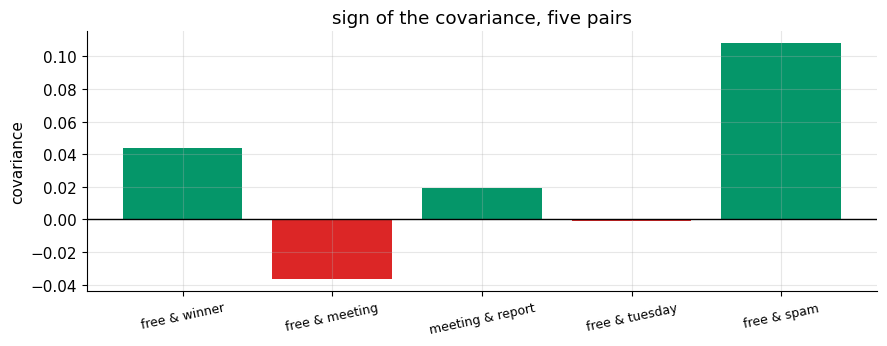

In [68]:
# ---- Covariance by hand, then against numpy, on pairs whose sign we can predict.
def cov_by_hand(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return np.mean((x - x.mean()) * (y - y.mean()))


print("Covariance: by hand, and by numpy (which should agree exactly)\n")
hdr = f"{'pair':<20}{'by hand':>11}{'np.cov':>11}    {'why the sign comes out that way'}"
print(hdr); print("-" * len(hdr))
tested = [
    ("free & winner", F, W, "both are spam words: move together"),
    ("free & meeting", F, M, "spam word vs work word: move apart"),
    ("meeting & report", M, Rp, "both are work words: move together"),
    ("free & tuesday", F, TUE, "unrelated: should be about zero"),
    ("free & spam", F, is_spam, "the cause of it all"),
]
covs = {}
for name, x, y, note in tested:
    c_hand = cov_by_hand(x, y)
    c_np = np.cov(np.asarray(x, float), np.asarray(y, float), ddof=0)[0, 1]
    covs[name] = c_hand
    print(f"{name:<20}{c_hand:>11.5f}{c_np:>11.5f}    {note}")
print("-" * len(hdr))

# ---- Covariance with yourself is the variance.
print(f"\nCov(free, free) = {cov_by_hand(F, F):.6f}"
      f"   Var(free) = {np.asarray(F, float).var():.6f}   <- the same thing")

# ---- The variance-of-a-sum identity, with its missing term restored.
x, y = np.asarray(F, float), np.asarray(M, float)
print(f"\nVar(free + meeting)                      = {(x + y).var():.6f}")
print(f"Var(free) + Var(meeting)                 = {x.var() + y.var():.6f}   <- Part 6's rule")
print(f"Var(free) + Var(meeting) + 2*Cov         = "
      f"{x.var() + y.var() + 2 * cov_by_hand(x, y):.6f}   <- the whole truth")

fig, ax = plt.subplots(figsize=(9, 3.6))
names = list(covs)
vals = [covs[n] for n in names]
ax.bar(names, vals, color=[C_AREA if v > 0 else C_SLOPE for v in vals])
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("covariance"); ax.set_title("sign of the covariance, five pairs")
plt.xticks(rotation=12, fontsize=9); plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five covariances, coloured green for positive and red for negative. The signs are the readable part and every one of them is predictable from how Part 0 generated the inbox: the two spam words move together, the two work words move together, a spam word and a work word move apart, and the independent Tuesday flag sits at essentially zero.

The printed lines underneath check two identities rather than asserting them: covariance with yourself equals the variance, and Part 6's variance-of-a-sum rule is off by exactly twice the covariance when the variables are not independent.

**The common misread:** comparing the *heights* of these bars and concluding one relationship is stronger than another. The heights are not comparable — not even here, where all five variables happen to be 0/1. Change any variable's units and its bar changes height while nothing about the relationship changes at all, which is what the next cell demonstrates.

</div>

In [69]:
# ---- Two continuous features, and the same relationship in three unit systems.
n_words = RNG8.lognormal(mean=5.2, sigma=0.45, size=N_EMAILS)      # words
read_min = n_words / 200 + RNG8.normal(0, 0.12, N_EMAILS)          # minutes
read_min = np.maximum(read_min, 0.02)

variants = [
    ("words  vs  minutes", n_words,          read_min),
    ("words  vs  SECONDS", n_words,          read_min * 60),
    ("THOUSANDS of words  vs  minutes", n_words / 1000, read_min),
    ("THOUSANDS of words  vs  seconds", n_words / 1000, read_min * 60),
]

print("The SAME relationship between length and reading time, four ways:\n")
hdr = f"{'units':<34}{'covariance':>14}{'correlation':>14}"
print(hdr); print("-" * len(hdr))
seen = []
for label, x, y in variants:
    c = cov_by_hand(x, y)
    r = c / (x.std() * y.std())
    seen.append((c, r))
    print(f"{label:<34}{c:>14.5f}{r:>14.6f}")
print("-" * len(hdr))
cs = [abs(c) for c, _ in seen]
rs = [r for _, r in seen]
print(f"\ncovariance:  largest / smallest = {max(cs) / min(cs):,.0f} times")
print(f"correlation: largest - smallest = {max(rs) - min(rs):.2e}")
print("\nNothing about the emails changed between those four rows -- only the")
print("units. The covariance is a different number every time; the correlation")
print("is the same number every time.")


The SAME relationship between length and reading time, four ways:

units                                 covariance   correlation
--------------------------------------------------------------
words  vs  minutes                      46.41766      0.970173
words  vs  SECONDS                    2785.05944      0.970173
THOUSANDS of words  vs  minutes          0.04642      0.970173
THOUSANDS of words  vs  seconds          2.78506      0.970173
--------------------------------------------------------------

covariance:  largest / smallest = 60,000 times
correlation: largest - smallest = 1.11e-16

Nothing about the emails changed between those four rows -- only the
units. The covariance is a different number every time; the correlation
is the same number every time.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**A covariance on its own is not interpretable, and its magnitude is meaningless across different variables.**

The printed table shows one relationship — email length against reading time — expressed in four unit systems. The covariance swings across several orders of magnitude; the underlying fact does not budge. Covariance carries the units of $X$ times the units of $Y$, so 'word-minutes' and 'kiloword-seconds' are simply different numbers for the same thing.

Which makes these two moves errors, not shortcuts:

- **Ranking relationships by covariance.** 'This pair's covariance is the biggest, so its relationship is the strongest.' That is not a comparison of anything: switch one variable to different units and the ranking changes, as the table above does on demand.
- **Calling a covariance large or small.** Large compared to what? There is no scale. Only the **sign** of a covariance is safe to read directly.

This is not a small technicality — it is the entire reason correlation exists as a separate quantity.

</div>

## 8.5 Correlation: covariance with the units divided out

The fix is direct. If the problem is that covariance carries the units of $X$
times the units of $Y$, then divide by exactly those units — the standard
deviation of each:

$$\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \, \sigma_Y}.$$

This is the **Pearson correlation coefficient**. Both units cancel, leaving a
pure number, and it is guaranteed to land in $[-1, 1]$:

- $\rho = +1$ — perfect straight-line relationship, sloping up;
- $\rho = 0$ — no *linear* relationship (that word is load-bearing, see §8.6);
- $\rho = -1$ — perfect straight-line relationship, sloping down.

There is another way to see it that makes the bounds obvious. Standardise both
variables first — subtract the mean, divide by the standard deviation, exactly
Part 6's operation — and the correlation is just the covariance of the
standardised versions. Since standardised variables have variance 1, their
covariance cannot exceed 1 without breaking the Cauchy–Schwarz inequality. The
next cell checks that both routes give the identical number.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Covariance says which way; correlation says which way and how much.**

Dividing by $\sigma_X \sigma_Y$ asks the covariance a scale-free question: *how much do these two move together, compared with the most they possibly could, given how much each one moves on its own?*

That is why the answer is capped at 1. A correlation of 0.8 means the agreement reached 80% of the maximum conceivable agreement — a statement you can make about any two variables, in any units, and compare directly with a 0.8 measured somewhere else entirely.

</div>

Correlation three ways, and the covariance beside it for contrast

pair                            covariance  corr (hand)  corr (standardised)  np.corrcoef
-----------------------------------------------------------------------------------------
free & winner                      0.04375      0.32771              0.32771      0.32771
free & meeting                    -0.03684     -0.20891             -0.20891     -0.20891
meeting & report                   0.01903      0.10078              0.10078      0.10078
free & tuesday                    -0.00129     -0.00652             -0.00652     -0.00652
free & spam                        0.10817      0.59678              0.59678      0.59678
n_words & reading time            46.41766      0.97017              0.97017      0.97017
n_words & reading SECONDS       2785.05944      0.97017              0.97017      0.97017
-----------------------------------------------------------------------------------------

The last two rows are the same p

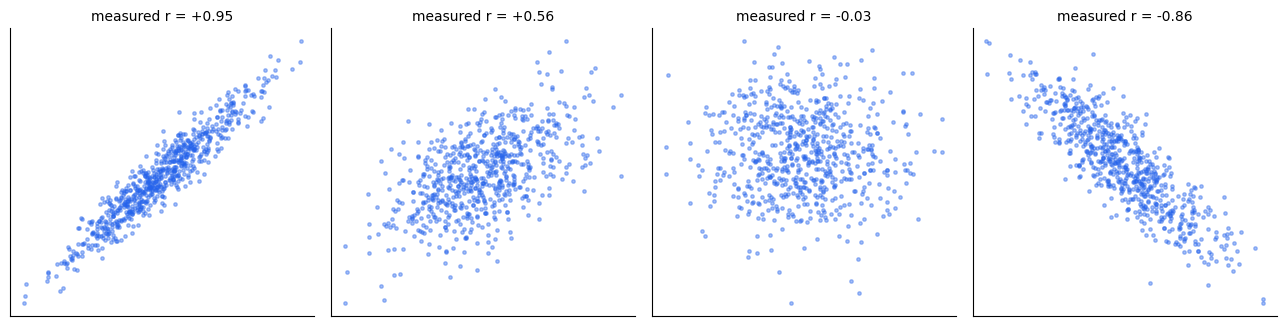


largest correlation seen anywhere above: 0.9702   (the bound is 1)


In [70]:
def corr_by_hand(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return cov_by_hand(x, y) / (x.std() * y.std())


def corr_via_standardising(x, y):
    """The other route: standardise both, then take the plain covariance."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    zx = (x - x.mean()) / x.std()
    zy = (y - y.mean()) / y.std()
    return cov_by_hand(zx, zy)


print("Correlation three ways, and the covariance beside it for contrast\n")
hdr = (f"{'pair':<30}{'covariance':>12}{'corr (hand)':>13}"
       f"{'corr (standardised)':>21}{'np.corrcoef':>13}")
print(hdr); print("-" * len(hdr))
show = [("free & winner", F, W), ("free & meeting", F, M),
        ("meeting & report", M, Rp), ("free & tuesday", F, TUE),
        ("free & spam", F, is_spam),
        ("n_words & reading time", n_words, read_min),
        ("n_words & reading SECONDS", n_words, read_min * 60)]
for name, x, y in show:
    xf, yf = np.asarray(x, float), np.asarray(y, float)
    print(f"{name:<30}{cov_by_hand(xf, yf):>12.5f}{corr_by_hand(xf, yf):>13.5f}"
          f"{corr_via_standardising(xf, yf):>21.5f}"
          f"{np.corrcoef(xf, yf)[0, 1]:>13.5f}")
print("-" * len(hdr))
print("\nThe last two rows are the same pair in different units: the covariance")
print("column changes, all three correlation columns do not.")

# ---- The bound, and what different correlations look like.
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
base = RNG8.normal(0, 1, 700)
for k, (target, a) in enumerate([(0.95, ax[0]), (0.55, ax[1]),
                                 (0.0, ax[2]), (-0.85, ax[3])]):
    noise = RNG8.normal(0, 1, 700)
    y = target * base + np.sqrt(max(1 - target**2, 0)) * noise
    a.scatter(base, y, s=6, alpha=0.4, color=C_F)
    a.set_title(f"measured r = {corr_by_hand(base, y):+.2f}", fontsize=10)
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print(f"\nlargest correlation seen anywhere above: "
      f"{max(abs(corr_by_hand(np.asarray(x, float), np.asarray(y, float))) for _, x, y in show):.4f}"
      f"   (the bound is 1)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four clouds of 700 points each, built to have decreasing correlation, with the correlation actually measured from the points printed above each. This is the picture to keep: near $+1$ the cloud is a tight upward line, near $0$ it is a shapeless blob, and negative correlation tilts it the other way.

The printed table above is the point of the section. The covariance column changes when the units change; all three correlation columns — computed by the formula, by standardising first, and by numpy — agree with each other to five decimal places and ignore the units entirely.

**The common misread:** treating correlation as a measure of *slope*. It is not. A relationship where $y$ rises by 0.01 per unit of $x$ can have correlation 0.99 if the points hug that gentle line tightly. Correlation measures **how tightly the points hug a line**, and says nothing about how steep the line is.

</div>

## 8.6 The warning that matters most: correlation is *linear* only

Read the definition again with one word emphasised. Correlation measures how
well the relationship between two variables is captured by a **straight line**.
That is all it measures.

So there is nothing to stop a pair of variables from being related as tightly as
two variables can possibly be — one *completely determining* the other, with no
noise whatsoever — while the correlation between them is zero.

Here is the cleanest example. Let $x$ be symmetric about zero, and let

$$y = x^2.$$

Knowing $x$ tells you $y$ exactly. There is no uncertainty left at all. But
above-average $x$ (large positive) gives large $y$, and below-average $x$ (large
negative) *also* gives large $y$ — so the products in the covariance sum cancel
in pairs, and the covariance comes out at zero.

Let us watch it happen.


y = x^2 exactly, with no noise whatsoever.
  correlation r      = -0.01438
  covariance         = -0.06571
  is y determined by x? knowing x gives y to within 0.0e+00

  Var(y) overall                        = 7.0915
  Var(y) among emails with |x| < 1      = 0.0859
  Var(y) among emails with |x| >= 1     = 5.2819
  Knowing something about x changes y's spread enormously -- that is
  dependence, and the correlation is blind to all of it.

  the measured correlation as the sample grows:
    n =     500   r = -0.08175
    n =   5,000   r = -0.00544
    n =  50,000   r = +0.00288
    n = 500,000   r = -0.00287


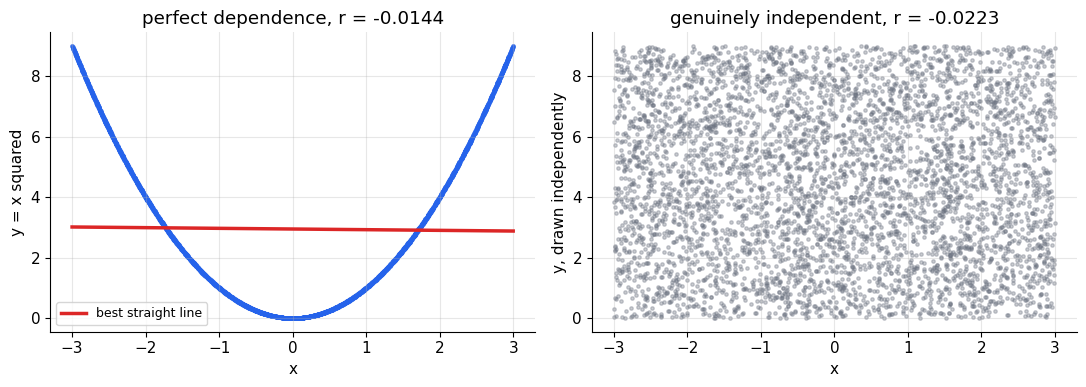


Both panels have a correlation near zero. Only the right one has
independence. Correlation cannot tell them apart; your eyes can.


In [71]:
# ---- y is completely determined by x. No noise at all.
x_q = RNG8.uniform(-3, 3, 5000)
y_q = x_q**2

r_quad = corr_by_hand(x_q, y_q)
print(f"y = x^2 exactly, with no noise whatsoever.")
print(f"  correlation r      = {r_quad:+.5f}")
print(f"  covariance         = {cov_by_hand(x_q, y_q):+.5f}")
print(f"  is y determined by x? knowing x gives y to within "
      f"{np.abs(y_q - x_q**2).max():.1e}\n")

# But the two are wildly dependent: knowing x kills almost all of y's variance.
lo, hi = np.abs(x_q) < 1.0, np.abs(x_q) >= 1.0
print(f"  Var(y) overall                        = {y_q.var():.4f}")
print(f"  Var(y) among emails with |x| < 1      = {y_q[lo].var():.4f}")
print(f"  Var(y) among emails with |x| >= 1     = {y_q[hi].var():.4f}")
print("  Knowing something about x changes y's spread enormously -- that is")
print("  dependence, and the correlation is blind to all of it.")

# The correlation is not merely small here; it is heading to zero as we look
# at more points, which is what "the true correlation is 0" looks like.
print("\n  the measured correlation as the sample grows:")
for m in (500, 5_000, 50_000, 500_000):
    xm = RNG8.uniform(-3, 3, m)
    print(f"    n = {m:>7,}   r = {corr_by_hand(xm, xm**2):+.5f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(x_q, y_q, s=6, alpha=0.35, color=C_F)
fit = np.polyfit(x_q, y_q, 1)
xx = np.linspace(-3, 3, 50)
ax[0].plot(xx, fit[0] * xx + fit[1], color=C_SLOPE, lw=2.5,
           label="best straight line")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y = x squared")
ax[0].set_title(f"perfect dependence, r = {r_quad:+.4f}")
ax[0].legend(fontsize=9)

# For contrast: a genuinely unrelated pair, which looks quite different.
y_indep = RNG8.uniform(0, 9, 5000)
ax[1].scatter(x_q, y_indep, s=6, alpha=0.35, color=C_GREY)
ax[1].set_xlabel("x"); ax[1].set_ylabel("y, drawn independently")
ax[1].set_title(f"genuinely independent, r = {corr_by_hand(x_q, y_indep):+.4f}")
plt.tight_layout(); plt.show()

print(f"\nBoth panels have a correlation near zero. Only the right one has")
print(f"independence. Correlation cannot tell them apart; your eyes can.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** a perfect parabola. Every point lies exactly on $y = x^2$ — there is no noise, no scatter, and $x$ determines $y$ completely. The red line is the best straight line through it, and it is flat, which is why the correlation printed in the title is essentially zero.

**Right:** two variables drawn with no relationship at all. Its correlation is also essentially zero.

Two utterly different situations, one summary number, and no way to tell them apart from that number. The printed variances make the same point numerically: conditioning on $x$ collapses $y$'s spread on the left, which is dependence a correlation of zero flatly denies.

**The common misread:** 'the correlation is 0.02, so these features are unrelated — drop one.' The left panel is a feature pair that a correlation filter would discard while it carried a perfect, learnable signal. Plot before you filter.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Zero correlation does not mean independence.** The parabola above is the counterexample: $y$ is a deterministic function of $x$ — as dependent as two variables get — and the measured correlation is essentially zero.

The implication runs one way only:

- independent $\Rightarrow$ correlation is zero. **True.**
- correlation is zero $\Rightarrow$ independent. **False**, as printed above.

The one place the converse does hold is when the pair is *jointly normal*, and that exception is quietly responsible for a great deal of the confusion — much of the classical theory assumes joint normality, so 'uncorrelated' and 'independent' get used interchangeably in textbooks where they genuinely coincide, and the habit then travels to data where they do not.

The practical version: **a correlation matrix is not an independence test.** §8.3's factorisation check is one; plotting the data is the other, and it is the one that would have caught the parabola.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Correlation is not causation.** The version worth remembering is not the slogan but the list of what else produces a correlation: $X$ causes $Y$; $Y$ causes $X$; some third thing causes both (in our inbox, 'free' and 'winner' correlate because spam causes both, and §8.3 showed them coming apart the moment spam is held fixed); or the sample was selected in a way that manufactures the association. Correlation ranks all of these equally, because it is a statement about a table of numbers, not about the world that produced it. Nothing you can compute from observational data alone distinguishes them — that takes an intervention, or an explicit causal assumption you are willing to defend.

</div>

## 8.7 Anscombe's quartet: four datasets, one set of summary statistics

In 1973 Francis Anscombe published four small datasets built to make a single
point, and it has never been made better.

The four share a mean in $x$, a mean in $y$, a variance in $x$, a variance in
$y$, a correlation, and a best-fit line. The cell below computes all seven
statistics for all four datasets and prints the largest disagreement between
them, so you can see exactly how close "the same" is before believing the
claim.

They look nothing like each other.

The lesson is not "Anscombe was clever". It is that **summary statistics are a
lossy compression of a joint distribution**, and the things they throw away —
curvature, outliers, clusters, a single leverage point holding up an entire
regression — are usually the things you most needed to know. One correlation
value is consistent with a clean linear trend, a perfect curve, a straight line
with one bad point, and a vertical stack of points plus one lever, all at once.

We will print the statistics first, confirm they really do agree, and only then
plot.


set      mean x   mean y    var x    var y     corr  fit slope  intercept
-------------------------------------------------------------------------
I         9.000    7.501   11.000    4.127    0.816      0.500      3.000
II        9.000    7.501   11.000    4.128    0.816      0.500      3.001
III       9.000    7.500   11.000    4.123    0.816      0.500      3.002
IV        9.000    7.501   11.000    4.123    0.817      0.500      3.002
-------------------------------------------------------------------------
largest disagreement between the four sets, column by column:
  0.0000  0.0009  0.0000  0.0050  0.0003  0.0004  0.0024
  every summary statistic agrees to within 0.0050



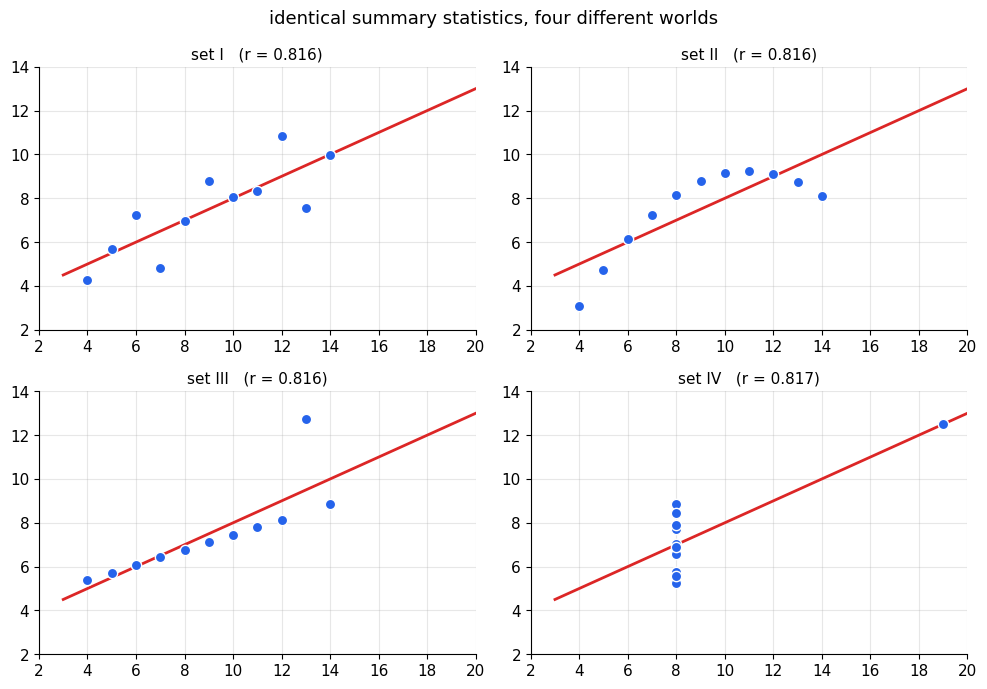

In [72]:
# Anscombe's four datasets (1973). The first three share the same x values.
x_common = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], float)
quartet = [
    ("I",   x_common,
     np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    ("II",  x_common,
     np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    ("III", x_common,
     np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    ("IV",  np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], float),
     np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
]

hdr = (f"{'set':<6}{'mean x':>9}{'mean y':>9}{'var x':>9}{'var y':>9}"
       f"{'corr':>9}{'fit slope':>11}{'intercept':>11}")
print(hdr); print("-" * len(hdr))
stats_rows = []
for name, x, y in quartet:
    slope, intercept = np.polyfit(x, y, 1)
    row = (x.mean(), y.mean(), x.var(ddof=1), y.var(ddof=1),
           corr_by_hand(x, y), slope, intercept)
    stats_rows.append(row)
    print(f"{name:<6}" + "".join(f"{v:>9.3f}" if i < 5 else f"{v:>11.3f}"
                                 for i, v in enumerate(row)))
print("-" * len(hdr))
spread = np.array(stats_rows).max(axis=0) - np.array(stats_rows).min(axis=0)
print("largest disagreement between the four sets, column by column:")
print("  " + "  ".join(f"{v:.4f}" for v in spread))
print(f"  every summary statistic agrees to within {spread.max():.4f}\n")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for (name, x, y), a, row in zip(quartet, axes.ravel(), stats_rows):
    a.scatter(x, y, s=55, color=C_F, zorder=3, edgecolor="white")
    xx = np.linspace(3, 20, 30)
    a.plot(xx, row[5] * xx + row[6], color=C_SLOPE, lw=2)
    a.set_title(f"set {name}   (r = {row[4]:.3f})", fontsize=11)
    a.set_xlim(2, 20); a.set_ylim(2, 14)
plt.suptitle("identical summary statistics, four different worlds", fontsize=13)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four datasets whose means, variances, correlations and fitted lines agree to within the tolerance printed above the figure — the same red line is drawn on all four panels, and it fits all four equally well by every number we know how to compute.

**Set I** is what everyone pictures on hearing that correlation: a linear relationship with scatter. **Set II** is a clean parabola — the relationship is perfect and the linear fit is simply the wrong model. **Set III** is an exact straight line with a single contaminated point, which drags the fitted slope off the true one. **Set IV** has no relationship at all in ten of its points; one lone observation at $x = 19$ creates the entire correlation single-handed.

**The common misread:** taking this as an argument for plotting instead of computing. It is an argument for plotting *as well as* computing — the statistics are correct in all four cases. They just do not say what a reader assumes they say, and the picture is what tells you which of the four worlds you are in.

</div>

## 8.8 More than two: the covariance matrix

With $d$ variables there are $d(d-1)/2$ pairs, and writing them out one at a
time stops working. Collect them into a square array instead:

$$\Sigma_{ij} = \text{Cov}(X_i, X_j).$$

This is the **covariance matrix**, usually written $\Sigma$. Three properties
make it more than filing:

- Its **diagonal is the variances**, since $\text{Cov}(X_i, X_i) =
  \text{Var}(X_i)$ — the individual spreads sit on the diagonal and every
  relationship sits off it.
- It is **symmetric**: $\text{Cov}(X, Y) = \text{Cov}(Y, X)$, straight from the
  definition, since multiplication does not care about order.
- It carries the same unit problem as a single covariance, only worse: with
  mixed units the entries are not comparable at all. Dividing each entry by the
  two relevant standard deviations gives the **correlation matrix**, which is
  the same object with the units removed and 1s down the diagonal.

Everything above still applies. Every entry measures only linear association,
every zero could hide a parabola, and the whole matrix is a lossy summary of a
joint distribution — the Anscombe warning does not go away because you put the
numbers in a grid.


diagonal of Sigma vs the variances computed one at a time:
  n_words    Sigma[0,0] =  9279.3741    var =  9279.3741
  read_min   Sigma[1,1] =     0.2467    var =     0.2467
  n_links    Sigma[2,2] =     3.7195    var =     3.7195
  n_caps     Sigma[3,3] =    21.6995    var =    21.6995
  is_spam    Sigma[4,4] =     0.2103    var =     0.2103

symmetric? largest |Sigma - Sigma transposed| = 0.00e+00
correlation diagonal is all ones: True
one entry checked by hand: Corr[n_links, is_spam] = 0.76348   corr_by_hand = 0.76348


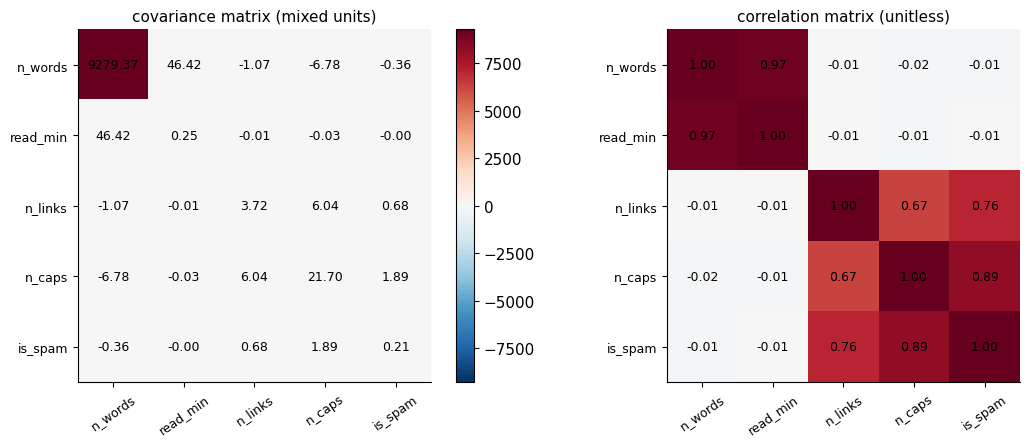


largest entry of Sigma :    9279.37   at (n_words, n_words) -- carries that feature's units, squared
largest off-diagonal of Corr: 0.9702   at (read_min, n_words) -- no units at all


In [73]:
# ---- Five features of an email, several of them driven by whether it is spam.
n_links = RNG8.poisson(0.6 + 3.2 * is_spam)
n_caps = RNG8.poisson(2.0 + 9.0 * is_spam)
features = np.column_stack([n_words, read_min, n_links, n_caps,
                            is_spam.astype(float)])
feat_names = ["n_words", "read_min", "n_links", "n_caps", "is_spam"]

Sigma = np.cov(features, rowvar=False, ddof=0)
Corr = np.corrcoef(features, rowvar=False)

# Checks: the diagonal is the variances, and the matrix is symmetric.
print("diagonal of Sigma vs the variances computed one at a time:")
for k, lab in enumerate(feat_names):
    print(f"  {lab:<10} Sigma[{k},{k}] = {Sigma[k,k]:>10.4f}"
          f"    var = {features[:, k].var():>10.4f}")
print(f"\nsymmetric? largest |Sigma - Sigma transposed| = "
      f"{np.abs(Sigma - Sigma.T).max():.2e}")
print(f"correlation diagonal is all ones: {np.allclose(np.diag(Corr), 1)}")
print(f"one entry checked by hand: Corr[n_links, is_spam] = {Corr[2,4]:.5f}"
      f"   corr_by_hand = {corr_by_hand(features[:,2], features[:,4]):.5f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
im0 = ax[0].imshow(Sigma, cmap="RdBu_r",
                   vmin=-np.abs(Sigma).max(), vmax=np.abs(Sigma).max())
ax[1].imshow(Corr, cmap="RdBu_r", vmin=-1, vmax=1)
for a, Mx, title, fmt in [(ax[0], Sigma, "covariance matrix (mixed units)", "{:.2f}"),
                          (ax[1], Corr, "correlation matrix (unitless)", "{:.2f}")]:
    for i in range(len(feat_names)):
        for j in range(len(feat_names)):
            a.text(j, i, fmt.format(Mx[i, j]), ha="center", va="center", fontsize=9)
    a.set_xticks(range(len(feat_names))); a.set_yticks(range(len(feat_names)))
    a.set_xticklabels(feat_names, rotation=35, fontsize=9)
    a.set_yticklabels(feat_names, fontsize=9)
    a.set_title(title, fontsize=11); a.grid(False)
plt.colorbar(im0, ax=ax[0], fraction=0.046)
plt.tight_layout(); plt.show()

bi, bj = np.unravel_index(np.abs(Sigma).argmax(), Sigma.shape)
ci, cj = np.unravel_index(np.abs(Corr - np.eye(len(feat_names))).argmax(), Corr.shape)
print(f"\nlargest entry of Sigma : {Sigma[bi, bj]:>10.2f}   at "
      f"({feat_names[bi]}, {feat_names[bj]}) -- carries that feature's units, squared")
print(f"largest off-diagonal of Corr: {Corr[ci, cj]:>6.4f}   at "
      f"({feat_names[ci]}, {feat_names[cj]}) -- no units at all")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the covariance matrix of five email features, red for positive and blue for negative. It is almost unreadable as a picture, and that is the honest result: `n_words` is measured in words, so its variance dwarfs everything else and the colour scale is set by units rather than by any relationship. The printed lines confirm the diagonal really is the list of variances and the matrix really is symmetric.

**Right:** the same matrix with every entry divided by the two relevant standard deviations. Now the picture says something: 1s down the diagonal, a strong block linking `n_links`, `n_caps` and `is_spam` (Part 0 generated all three from the spam flag), and `n_words`/`read_min` locked together because one was built from the other.

**The common misread:** reading a near-zero cell in the right-hand panel as 'these two features are unrelated, drop one'. Every warning from §8.6 applies to every cell of this grid — a zero here means no *linear* association, and the parabola would show up in this matrix as a wall of harmless-looking zeros.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**This matrix is the object PCA eigen-decomposes.** Principal Component Analysis takes exactly the $\Sigma$ printed above and finds its eigenvectors: the directions in feature space along which the data varies most, ordered by how much variance each one explains — the eigenvalues. The linear-algebra companion notebook does that decomposition in full; what this part supplies is the reason there is anything to decompose. If every off-diagonal entry were zero, the features would already be uncorrelated and PCA would have nothing to do. The redundancy visible in that block of the correlation matrix is what PCA compresses away.

Three more places the same matrix turns up:

- **Multicollinearity.** Two features correlated at 0.98 make a linear model's coefficients wildly unstable — $\Sigma$ is near-singular, and inverting something near-singular amplifies noise. The fitted model can still predict fine while every individual coefficient is meaningless.
- **The multivariate normal**, whose entire shape is a mean vector plus $\Sigma$. It is what the Mahalanobis distance uses to ask 'how unusual is this point, accounting for the fact that these features travel together?' — the basis of a whole family of anomaly detectors.
- **Whitening**, in preprocessing and in optimisers, which transforms data so that $\Sigma$ becomes the identity — no correlations left, every direction on the same scale.

And the caution that follows from §8.6: because $\Sigma$ sees only linear structure, PCA sees only linear structure. That limit is the reason non-linear methods — kernel PCA, autoencoders, UMAP — exist at all.

</div>

---

### Where this leaves us

We can now handle more than one variable at a time. The joint distribution is
the complete object; marginals come from summing it, conditionals from dividing
a row by its total. Independence means the joint factorises into its margins —
and we tested that on real word pairs rather than assuming it. Covariance gives
the direction two variables move together, correlation removes its units so the
magnitude can be compared, and both were shown failing in exactly the ways that
matter: blind to curves, identical across four wildly different datasets, and
silent about cause.

That is the machinery. What remains is to point it at machine learning.

**Part 9** does that. It turns the joint distribution into a **likelihood** —
how probable the data we actually observed is, under a model — and then shows
that the cross-entropy loss almost every classifier is trained with is the
negative log of that likelihood, nothing more. Naive Bayes falls out of the
conditional independence we measured in §8.3, and the number a model prints when
it says 0.87 finally gets a definition you can defend.


---

# 9️⃣ Probability doing machine learning

Eight parts of tools. Here is what they were for.

A machine-learning model that outputs a probability is doing exactly one thing:
it is proposing a **probability distribution over what it thinks will happen**,
and training is the process of adjusting it until the things that actually
happened are the things it said were likely. That sentence is the whole of this
part. Everything below is that sentence made precise, then made to run.

Three ideas, in the order they depend on each other:

| | Idea | What it gives you |
|---|---|---|
| **9.1** | **Likelihood**, and maximising it | a principled way to pick parameters from data |
| **9.2** | **Cross-entropy** | the same thing, written as a loss to minimise — the loss your classifier is trained with |
| **9.3** | **Naive Bayes** | Part 4's theorem turned into a working classifier, on our inbox |

Then **9.4** asks the question nobody asks often enough: when the model says
0.87, is it *right* to say 0.87? And **9.5** closes the notebook.

Everything here is built from parts you already have. Part 1 gave us
probability as something you can check by counting. Part 3 gave the conditional
bar. Part 4 gave Bayes' theorem. Part 7 gave the Bernoulli. Part 8 gave
correlation — and in 9.3 we will use it to *catch this part's own model telling
a lie about its assumptions*, which is a more useful thing to do with a tool
than admire it.


---

## 9.1 Likelihood, and why it is not probability

Take a coin whose bias $p$ — the probability of heads — you do not know. Toss
it $n$ times, count $k$ heads. Part 7's binomial formula gives

$$
f(k, p) \;=\; \binom{n}{k}\, p^{k}\,(1-p)^{\,n-k}.
$$

One formula. Two completely different objects live inside it, depending on
**which letter you hold fixed**:

- Hold $p$ fixed, let $k$ vary. You get a **probability distribution** over the
  possible counts. It answers *"the coin is fair — how often will I see 27
  heads?"* Its values sum to 1, because some count has to happen.

- Hold $k$ fixed at what you actually observed, let $p$ vary. You get the
  **likelihood function** $L(p)$. It answers *"I saw 27 heads — how well does
  each candidate bias explain that?"* Its values **do not sum or integrate to
  1**, and there is no reason they should.

The second is not a probability distribution over $p$. It is not the
probability that the bias is $p$. It is a *score* — a measure of how well each
hypothesis accounts for the data you are stuck with.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Probability** runs forwards: you fix the world's parameter and ask how often each outcome happens. **Likelihood** runs backwards: you fix the outcome you actually got and ask which parameter would have made it least surprising.

The formula is identical. What changes is which symbol is the variable and which is nailed down. Written carefully, the probability is $P(k \mid p)$ — read with Part 3's bar, *the chance of $k$ given that the bias is $p$* — and the likelihood is written $L(p \mid k)$, which is the **same number**, now regarded as a function of $p$.

That is genuinely all the difference there is. It is also the difference people spend a semester getting wrong.

</div>

We tossed a coin 40 times and saw 28 heads.
(We built it with bias 0.65. In real life that number is exactly
 what you do not have, which is why we are here.)

PROBABILITY  (bias fixed at 0.5, count varies)
    the bars sum to            1.000000   <- must be 1

LIKELIHOOD   (count fixed at 28, bias varies)
    the area under it is       0.024390
    for comparison, 1/(n+1) =  0.024390
    ...not 1, and it never had to be. It is a score, not a distribution.


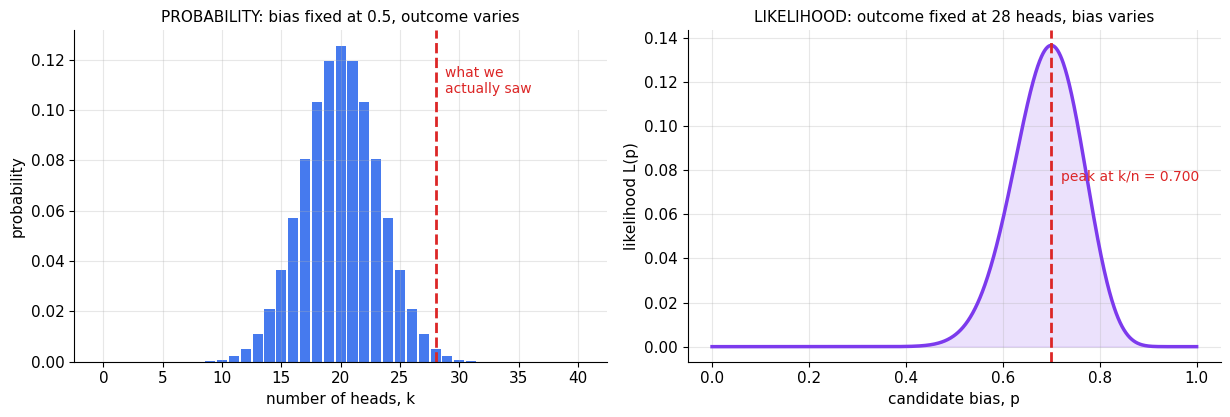

In [74]:
# ============================================================
#  9.1  One formula, two readings
#       Left  : p held fixed, k varies  -> a probability distribution
#       Right : k held fixed, p varies  -> a likelihood function
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

RNG9 = np.random.default_rng(1)

N_FLIPS, P_TRUE = 40, 0.65
flips   = RNG9.random(N_FLIPS) < P_TRUE
K_HEADS = int(flips.sum())

print(f"We tossed a coin {N_FLIPS} times and saw {K_HEADS} heads.")
print(f"(We built it with bias {P_TRUE}. In real life that number is exactly")
print(" what you do not have, which is why we are here.)")
print()


def binom_pmf(k, n, p):
    """Part 7's binomial. Works if k is an array, or if p is an array."""
    return comb(n, k) * p ** k * (1 - p) ** (n - k)


# --- reading 1: p fixed, k varies ------------------------------------
k_grid  = np.arange(N_FLIPS + 1)
P_FIXED = 0.5
bars    = binom_pmf(k_grid, N_FLIPS, P_FIXED)

# --- reading 2: k fixed, p varies ------------------------------------
p_grid = np.linspace(0.0, 1.0, 1001)
lik    = binom_pmf(K_HEADS, N_FLIPS, p_grid)

trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
area  = trapz(lik, p_grid)

print(f"PROBABILITY  (bias fixed at {P_FIXED}, count varies)")
print(f"    the bars sum to            {bars.sum():.6f}   <- must be 1")
print()
print(f"LIKELIHOOD   (count fixed at {K_HEADS}, bias varies)")
print(f"    the area under it is       {area:.6f}")
print(f"    for comparison, 1/(n+1) =  {1 / (N_FLIPS + 1):.6f}")
print("    ...not 1, and it never had to be. It is a score, not a distribution.")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))

ax[0].bar(k_grid, bars, color=C_F, alpha=0.85, width=0.85)
ax[0].axvline(K_HEADS, color=C_SLOPE, lw=2, ls="--")
ax[0].text(K_HEADS + 0.8, bars.max() * 0.85, "what we\nactually saw",
           color=C_SLOPE, fontsize=10)
ax[0].set_xlabel("number of heads, k")
ax[0].set_ylabel("probability")
ax[0].set_title(f"PROBABILITY: bias fixed at {P_FIXED}, outcome varies",
                fontsize=11)

ax[1].plot(p_grid, lik, color=C_EXACT, lw=2.5)
ax[1].fill_between(p_grid, lik, color=C_EXACT, alpha=0.15)
ax[1].axvline(K_HEADS / N_FLIPS, color=C_SLOPE, lw=2, ls="--")
ax[1].text(K_HEADS / N_FLIPS + 0.02, lik.max() * 0.55,
           f"peak at k/n = {K_HEADS / N_FLIPS:.3f}", color=C_SLOPE, fontsize=10)
ax[1].set_xlabel("candidate bias, p")
ax[1].set_ylabel("likelihood L(p)")
ax[1].set_title(f"LIKELIHOOD: outcome fixed at {K_HEADS} heads, bias varies",
                fontsize=11)

plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same formula, plotted twice, with different letters held still.

**Left**: the bias is pinned at one half and the *outcome* varies. Those bars are a probability distribution in Part 7's sense — they sum to 1.0, as the print-out confirms, because the coin has to land on some number of heads. The dashed line marks the count we actually got, and you can see it sits well out in the tail: a fair coin would rarely produce it.

**Right**: the outcome is pinned at what we observed and the *bias* varies. This curve is not a probability distribution. Its area is printed above and is nowhere near 1 — it is 1/(n+1), a number that has nothing to do with any belief about the coin. Height on this curve means only *this candidate bias explains our data this well, relative to the others*. The peak is the bias that explains it best.

**The common misread:** reading the right-hand curve as a probability distribution for the bias — *'look, it is bell-shaped and it peaks there, so that is probably the bias'*. It is not. It is a ranking of explanations, and it carries no probability mass. Turning it into a genuine distribution over the bias requires a prior and Part 4's theorem; the likelihood alone will not do it, no matter how much it looks like a bell curve.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Likelihood is not probability, and the notation invites you to forget it.**

Three specific ways this bites:

1. **'The likelihood that the coin is biased'** — there is no such thing unless you have supplied a prior. Likelihood is a function *of* the parameter, not a probability *for* the parameter.
2. **Comparing likelihoods across different datasets.** A likelihood value is only meaningful relative to other parameter values *on the same data*. Twice as likely means twice as good an explanation of these observations — it does not mean twice as probable.
3. **Expecting it to be at most 1.** For continuous data the likelihood is built from densities, which can exceed 1 freely. A likelihood of 4.7 is not a bug.

The safe habit: never say 'likelihood' about a parameter without being able to finish the sentence *'...of having produced the data I have'*. If that ending does not fit, you meant probability, and you need Bayes.

</div>

MAXIMUM LIKELIHOOD, found by search
    peak of the likelihood   p_hat = 0.70000037
    the sample proportion     k/n  = 0.70000000
    they differ by                   3.72e-07

The search knew nothing about 'proportions'. It walked a curve and
found its top. It landed on the fraction of tosses that came up heads.
That is not a coincidence, and 9.1c shows it is not one.


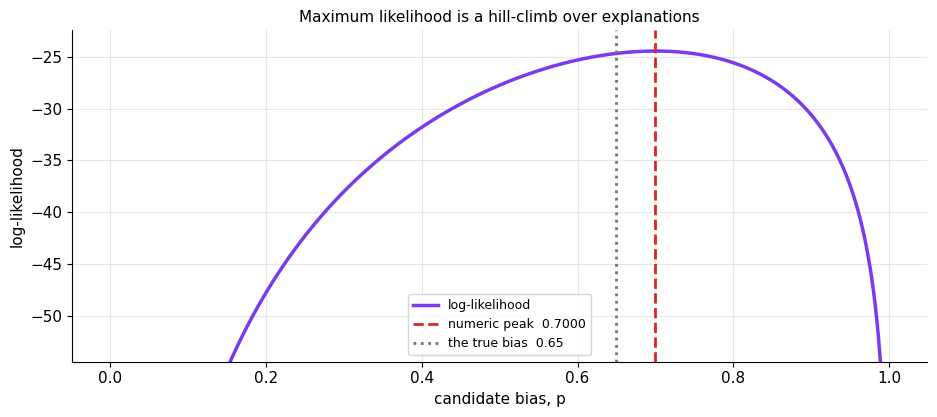

In [75]:
# ============================================================
#  9.1b  Maximum likelihood: find the peak, numerically
# ============================================================
from scipy.optimize import minimize_scalar

def neg_log_lik(p):
    """Negative log-likelihood of K_HEADS in N_FLIPS tosses, at bias p.
    The binomial coefficient does not depend on p, so it cannot move the
    peak -- we drop it. (It shifts the curve up or down, never sideways.)"""
    if p <= 0.0 or p >= 1.0:
        return np.inf
    return -(K_HEADS * np.log(p) + (N_FLIPS - K_HEADS) * np.log(1.0 - p))


opt = minimize_scalar(neg_log_lik, bounds=(1e-9, 1 - 1e-9), method="bounded")
p_hat_numeric = opt.x
p_hat_sample  = K_HEADS / N_FLIPS

print("MAXIMUM LIKELIHOOD, found by search")
print(f"    peak of the likelihood   p_hat = {p_hat_numeric:.8f}")
print(f"    the sample proportion     k/n  = {p_hat_sample:.8f}")
print(f"    they differ by                   {abs(p_hat_numeric - p_hat_sample):.2e}")
print()
print("The search knew nothing about 'proportions'. It walked a curve and")
print("found its top. It landed on the fraction of tosses that came up heads.")
print("That is not a coincidence, and 9.1c shows it is not one.")

ll = np.array([-neg_log_lik(p) for p in p_grid[1:-1]])

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(p_grid[1:-1], ll, color=C_EXACT, lw=2.5, label="log-likelihood")
ax.axvline(p_hat_numeric, color=C_SLOPE, lw=2, ls="--",
           label=f"numeric peak  {p_hat_numeric:.4f}")
ax.axvline(P_TRUE, color=C_GREY, lw=2, ls=":",
           label=f"the true bias  {P_TRUE}")
ax.set_ylim(ll.max() - 30, ll.max() + 2)
ax.set_xlabel("candidate bias, p")
ax.set_ylabel("log-likelihood")
ax.set_title("Maximum likelihood is a hill-climb over explanations", fontsize=11)
ax.legend(loc="lower center", fontsize=9)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The log of the likelihood curve, and the two vertical lines that matter.

The red dashed line is where a numerical optimiser stopped: the bias that explains our tosses better than any other. The grey dotted line is the bias we actually built the coin with. **They are not the same**, and the gap is the entire subject of statistics — a finite sample does not hand you the truth, it hands you the best guess available from what you saw.

The curve is drawn as a *log*-likelihood because on the raw scale the interesting region is a spike and everything else is visually zero. Taking logs stretches the small values apart without moving the peak, which is why the peak of one is the peak of the other — logging is an increasing transformation, so it reorders nothing.

**The common misread:** treating the peak as *the* answer and stopping. The peak is a point estimate; the *width* of this hill says how strongly the data prefers it, and a hill this broad is saying it would not be very surprised by a range of biases either side.

</div>

### 9.1c The same answer, on paper — and why we take the log

We just found the peak by search. Now do it by hand, and the search's answer
stops being a lucky landing.

**Step 1 — take the log.** The likelihood is a product; products are painful to
differentiate and, as we are about to see, catastrophic to compute. The
logarithm turns products into sums, and because $\log$ is strictly increasing,
**it cannot move the location of the maximum** — only its height. So maximising
$\log L$ and maximising $L$ give the same answer, and one of them is easy.

$$
\ell(p) \;=\; \log L(p) \;=\; \underbrace{\log \binom{n}{k}}_{\text{no } p \text{ in here}}
\;+\; k \log p \;+\; (n-k)\log(1-p).
$$

**Step 2 — differentiate.** The first term is a constant as far as $p$ is
concerned, so it dies. Using $\frac{d}{dp}\log p = \frac{1}{p}$ and the chain
rule on $\log(1-p)$:

$$
\frac{d\ell}{dp} \;=\; \frac{k}{p} \;-\; \frac{n-k}{1-p}.
$$

**Step 3 — set it to zero and solve.** At the top of a smooth hill the slope is
flat:

$$
\frac{k}{\hat p} = \frac{n-k}{1-\hat p}
\;\Longrightarrow\;
k(1-\hat p) = (n-k)\hat p
\;\Longrightarrow\;
k = n\hat p
\;\Longrightarrow\;
\boxed{\;\hat p = \frac{k}{n}\;}
$$

The maximum-likelihood estimate of a coin's bias **is** the fraction of heads
you saw. Part 1 told you to estimate probabilities by counting; this is the
proof that counting was the right thing to do all along.

**Why the log is not optional.** Above it was a convenience. In any real model
it is survival. A likelihood over $N$ independent data points is a product of
$N$ numbers each less than 1, and float64 — the number format everything runs
on — starts losing precision below about $10^{-308}$ and cannot represent
anything at all below roughly $10^{-324}$, the value the next cell prints. Past
that it does not complain: it rounds to exactly zero. Not approximately zero:
**zero**, with the gradient and every subsequent computation destroyed along
with it. The next cell does it to itself on purpose.


In [76]:
# ============================================================
#  9.1c  Analytic answer vs the search  --  and the underflow
# ============================================================
p_hat_analytic = K_HEADS / N_FLIPS


def dll(p):
    """d(log-likelihood)/dp, derived above:  k/p - (n-k)/(1-p)."""
    return K_HEADS / p - (N_FLIPS - K_HEADS) / (1.0 - p)


h  = 1e-6
fd = (-neg_log_lik(p_hat_analytic + h) + neg_log_lik(p_hat_analytic - h)) / (2 * h)

print("DOES THE PAPER AGREE WITH THE SEARCH?")
print(f"    analytic   k/n            = {p_hat_analytic:.10f}")
print(f"    numeric peak              = {p_hat_numeric:.10f}")
print(f"    difference                = {abs(p_hat_analytic - p_hat_numeric):.2e}")
print()
print("IS THE SLOPE REALLY ZERO THERE?")
print(f"    our formula  k/p-(n-k)/(1-p) = {dll(p_hat_analytic): .3e}")
print(f"    finite difference of the log = {fd: .3e}")
print("    (both zero to floating-point noise: the formula is the slope)")
print()

# ---------------- the underflow, done to ourselves on purpose ----------
N_TERMS = 2000
probs   = RNG9.uniform(0.05, 0.60, size=N_TERMS)   # 2000 innocent probabilities

raw_product = np.prod(probs)
log_total   = np.log(probs).sum()

cum        = np.cumprod(probs)
died_at    = int(np.argmax(cum == 0.0)) + 1        # 1-based term where it hit 0

print(f"MULTIPLYING {N_TERMS} PROBABILITIES TOGETHER")
print(f"    np.prod(probs)                = {raw_product}")
print(f"    ...is it exactly zero?          {raw_product == 0.0}")
print(f"    it hit exactly 0.0 at term     #{died_at} of {N_TERMS}")
print(f"    smallest positive float64      = {np.nextafter(0.0, 1.0)}")
print()
print("THE SAME QUANTITY, IN LOGS")
print(f"    np.log(probs).sum()           = {log_total:.4f}      <- finite, fine")
print(f"    which says the product is e^  = {log_total:.1f}")
print(f"    i.e. about 10^{log_total / np.log(10):.0f}")
print(f"    exp() of it, back on the raw scale = {np.exp(log_total)}  <- gone again")
print()
print("The information was never destroyed by the mathematics. It was destroyed")
print(f"by asking float64 to hold 10^{log_total / np.log(10):.0f}. In logs the same fact is a")
print("comfortable four-digit number. This is why every real likelihood, every")
print("loss function, and every naive Bayes classifier in 9.3 lives in log space.")


DOES THE PAPER AGREE WITH THE SEARCH?
    analytic   k/n            = 0.7000000000
    numeric peak              = 0.7000003717
    difference                = 3.72e-07

IS THE SLOPE REALLY ZERO THERE?
    our formula  k/p-(n-k)/(1-p) =  7.105e-15
    finite difference of the log =  0.000e+00
    (both zero to floating-point noise: the formula is the slope)

MULTIPLYING 2000 PROBABILITIES TOGETHER
    np.prod(probs)                = 0.0
    ...is it exactly zero?          True
    it hit exactly 0.0 at term     #579 of 2000
    smallest positive float64      = 5e-324

THE SAME QUANTITY, IN LOGS
    np.log(probs).sum()           = -2558.9084      <- finite, fine
    which says the product is e^  = -2558.9
    i.e. about 10^-1111
    exp() of it, back on the raw scale = 0.0  <- gone again

The information was never destroyed by the mathematics. It was destroyed
by asking float64 to hold 10^-1111. In logs the same fact is a
comfortable four-digit number. This is why every real likelihood,

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three claims from the derivation, all confirmed by the cell rather than asserted:

1. **The peak is at $k/n$.** The hand derivation and the numerical optimiser agree to the printed precision — and they got there by completely unrelated routes, one by algebra, one by walking uphill.
2. **Our derivative formula really is the derivative.** Evaluated at the estimate it returns zero, and so does a finite-difference approximation that knows nothing about our algebra. If the differentiation had been wrong, these two would disagree.
3. **Underflow is real and it is silent.** The product of two thousand ordinary probabilities is not *small* in float64 — it is exactly `0.0`, and the cell prints the term number at which it died. No exception, no warning. The log of the identical quantity is a tidy negative number that would have gone on working for millions more terms.

Point 3 is the one to carry forward: a program that computes likelihoods without logs does not crash. It quietly returns zero and every gradient downstream becomes meaningless.

</div>

---

## 9.2 Cross-entropy, read as a sentence

Now the payoff. Part 0 promised you would be able to read a classifier's loss
function as a sentence about likelihood. Here is the sentence.

Your model looks at email $i$ and outputs a number $\hat p_i$ — its claimed
probability that this email is spam. The truth is $y_i$, which is 1 for spam
and 0 for not. The model is asserting a Bernoulli distribution (Part 7) for each
email, so the probability it assigned to **what actually happened** is

$$
P(y_i \mid \hat p_i) \;=\; \hat p_i^{\,y_i}\,(1-\hat p_i)^{1-y_i}
\qquad\text{which is }\;\hat p_i\;\text{ when } y_i=1,\;\text{ and }\;1-\hat p_i\;\text{ when } y_i=0 .
$$

That exponent trick is just a switch: one of the two exponents is always zero,
and anything to the power zero is 1, so exactly one factor survives.

Treating the emails as independent (Part 3), the probability the model assigned
to the **entire observed dataset** is the product, and its log is the sum:

$$
\ell \;=\; \log \prod_{i=1}^{N} P(y_i \mid \hat p_i)
\;=\; \sum_{i=1}^{N} \Big[\, y_i \log \hat p_i \;+\; (1-y_i)\log(1-\hat p_i)\,\Big].
$$

Now divide by $N$ and flip the sign — and there it is:

$$
\boxed{\;\text{cross-entropy} \;=\; -\frac{1}{N}\sum_{i=1}^{N}\Big[\, y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i)\,\Big] \;=\; -\frac{\ell}{N}\;}
$$

Cross-entropy **is** the average negative log-likelihood. Not analogous to it,
not inspired by it — equal to it, up to a division by $N$ that changes nothing
and a minus sign that turns "climb" into "descend". Every classifier trained
with cross-entropy is doing maximum likelihood, whether or not anybody in the
room says so.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Read the boxed formula left to right, out loud:

*For every example, look up the probability the model gave to the thing that actually happened. Take its log. Average those. Flip the sign.*

That is the whole loss. Each term $-\log(\text{probability of the truth})$ is a **surprise score**: give the truth probability 1 and you are charged nothing, because $\log 1 = 0$; give it a small probability and you are charged a lot. Training is the search for the parameters that leave the model **least surprised, on average, by what really happened**.

The minus sign and the $1/N$ are bookkeeping. Optimisers are written to go downhill, so we negate; averaging instead of summing keeps the number comparable across batches of different sizes. Neither touches the ranking of models, which is what the next cell verifies.

</div>

In [77]:
# ============================================================
#  9.2  Same ranking: highest log-likelihood == lowest cross-entropy
#       Six candidate models, scored both ways.
# ============================================================
words   = list(WORDS.keys())
X_all   = np.column_stack([inbox[w] for w in words]).astype(float)
y_all   = is_spam.astype(int)

# The TRUE posterior. We know the generator, so Part 4's theorem gives the
# exact P(spam | words) -- and the words really are conditionally independent
# given the class here, because that is how Part 0 built them.
p_s_true = np.array([WORDS[w][0] for w in words])
p_h_true = np.array([WORDS[w][1] for w in words])

def log_scores(Xq, prior, p_spam_w, p_ham_w):
    """log P(class) + log P(words | class), for both classes. Log space (9.1c)."""
    s = (np.log(prior)     + Xq @ np.log(p_spam_w) + (1 - Xq) @ np.log(1 - p_spam_w))
    h = (np.log(1 - prior) + Xq @ np.log(p_ham_w)  + (1 - Xq) @ np.log(1 - p_ham_w))
    return s, h

s_true, h_true = log_scores(X_all, P_SPAM, p_s_true, p_h_true)
post_true = np.exp(s_true - np.logaddexp(s_true, h_true))   # stable softmax of 2

candidates = {
    "the true posterior":      post_true,
    "true, but blurred halfway toward 0.5": 0.5 + 0.5 * (post_true - 0.5),
    "everyone gets the base rate": np.full(N_EMAILS, P_SPAM),
    "a coin flip for every email": np.full(N_EMAILS, 0.5),
    "true, over-sharpened":    np.clip(2.5 * (post_true - 0.5) + 0.5, 1e-4, 1 - 1e-4),
    "confidently backwards":   1.0 - post_true,
}

EPS = 1e-12
rows = []
for name, p in candidates.items():
    p  = np.clip(p, EPS, 1 - EPS)
    ll = np.sum(y_all * np.log(p) + (1 - y_all) * np.log(1 - p))
    ce = -ll / N_EMAILS
    rows.append((name, ll, ce))

print(f"{'model':<40}{'log-likelihood':>18}{'cross-entropy':>16}")
print("-" * 74)
for name, ll, ce in sorted(rows, key=lambda r: -r[1]):
    print(f"{name:<40}{ll:>18,.1f}{ce:>16.5f}")
print()

lls = np.array([r[1] for r in rows])
ces = np.array([r[2] for r in rows])
order_by_ll = np.argsort(-lls)      # best log-likelihood first
order_by_ce = np.argsort(ces)       # best (lowest) cross-entropy first

print(f"ranking by log-likelihood, best first : {order_by_ll}")
print(f"ranking by cross-entropy,  best first : {order_by_ce}")
print(f"identical?                              {np.array_equal(order_by_ll, order_by_ce)}")
print(f"and is cross-entropy exactly -ll/N?     "
      f"{np.allclose(ces, -lls / N_EMAILS)}")


model                                       log-likelihood   cross-entropy
--------------------------------------------------------------------------
the true posterior                                -5,499.6         0.27498
true, but blurred halfway toward 0.5              -8,541.3         0.42707
everyone gets the base rate                      -12,230.8         0.61154
a coin flip for every email                      -13,862.9         0.69315
true, over-sharpened                             -17,827.6         0.89138
confidently backwards                            -59,869.8         2.99349

ranking by log-likelihood, best first : [0 1 2 3 4 5]
ranking by cross-entropy,  best first : [0 1 2 3 4 5]
identical?                              True
and is cross-entropy exactly -ll/N?     True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The two objectives are not merely correlated — the cell prints the two orderings and they are the *same array*, and it confirms that every cross-entropy in the table equals that model's log-likelihood divided by $-N$ to floating-point tolerance.

So there is no trade-off to reason about and no situation in which they disagree. **Minimising cross-entropy is maximising likelihood.** If you can explain one, you have explained the other.

Two things in the table are worth a second look. The model that hands everyone the base rate scores far better than the coin flip, without looking at a single word — being vaguely right about the overall spam rate beats being loudly undecided. And 'confidently backwards' is punished brutally, far worse than the coin flip: a model that is sure and wrong is much more expensive than one that admits it does not know. The next cell shows exactly how expensive.

</div>

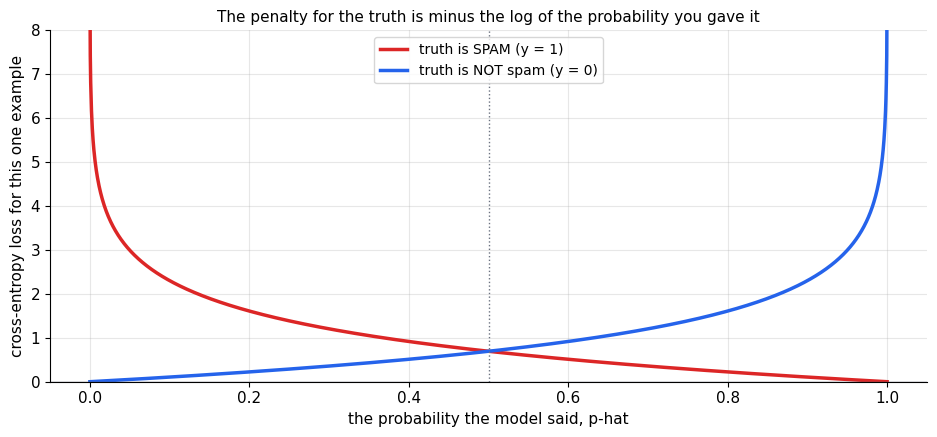

TRUTH IS SPAM (y = 1). What does one example cost?
    model said 0.99    ->  loss = 0.01005
    model said 0.5     ->  loss = 0.69315
    model said 0.01    ->  loss = 4.60517
    model said 0.001   ->  loss = 6.90776

Note the shape of that: being confidently right is nearly free, being
undecided costs a fixed toll, and being confidently wrong costs more
than being undecided by a wide and accelerating margin.

AND IF THE MODEL SAYS 0.0 AND THE TRUTH IS SPAM:
    loss = inf

    mean loss over 1000 examples, one of them 0.0 : inf
    the same batch, predictions clipped to [1e-15, 1-1e-15]:
    worst single loss = 34.5388,  mean loss = 0.13979

The clip is not a fudge to hide a mistake. It is a statement that no
finite amount of evidence justifies literal certainty -- which is a
modelling claim, and a correct one.


In [78]:
# ============================================================
#  9.2b  What the loss actually charges you  --  and the infinity
# ============================================================
p = np.linspace(1e-4, 1 - 1e-4, 2000)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(p, -np.log(p),     color=C_SLOPE, lw=2.5, label="truth is SPAM (y = 1)")
ax.plot(p, -np.log(1 - p), color=C_F,     lw=2.5, label="truth is NOT spam (y = 0)")
ax.axhline(0, color=C_GREY, lw=1)
ax.axvline(0.5, color=C_GREY, lw=1, ls=":")
ax.set_ylim(0, 8)
ax.set_xlabel("the probability the model said, p-hat")
ax.set_ylabel("cross-entropy loss for this one example")
ax.set_title("The penalty for the truth is minus the log of the probability you gave it",
             fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("TRUTH IS SPAM (y = 1). What does one example cost?")
for phat in (0.99, 0.5, 0.01, 0.001):
    print(f"    model said {phat:<7} ->  loss = {-np.log(phat):.5f}")
print()
print("Note the shape of that: being confidently right is nearly free, being")
print("undecided costs a fixed toll, and being confidently wrong costs more")
print("than being undecided by a wide and accelerating margin.")
print()

with np.errstate(divide="ignore"):
    disaster = -np.log(0.0)
print("AND IF THE MODEL SAYS 0.0 AND THE TRUTH IS SPAM:")
print(f"    loss = {disaster}")
print()

# one poisoned example destroys the whole batch average
y_batch = np.ones(1000, dtype=int)
p_batch = np.full(1000, 0.9)
p_batch[0] = 0.0                      # one confident, wrong prediction
with np.errstate(divide="ignore"):
    bad_mean = -np.mean(y_batch * np.log(p_batch)
                        + (1 - y_batch) * np.log(1 - p_batch))
print(f"    mean loss over {len(y_batch)} examples, one of them 0.0 : {bad_mean}")

EPS_CLIP = 1e-15
p_fixed_batch = np.clip(p_batch, EPS_CLIP, 1 - EPS_CLIP)
good_mean = -np.mean(y_batch * np.log(p_fixed_batch)
                     + (1 - y_batch) * np.log(1 - p_fixed_batch))
print(f"    the same batch, predictions clipped to [{EPS_CLIP}, 1-{EPS_CLIP}]:")
print(f"    worst single loss = {-np.log(EPS_CLIP):.4f},  mean loss = {good_mean:.5f}")
print()
print("The clip is not a fudge to hide a mistake. It is a statement that no")
print("finite amount of evidence justifies literal certainty -- which is a")
print("modelling claim, and a correct one.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two curves: the loss charged to a single example as a function of the probability the model announced. Red is the bill when the email really was spam, blue when it really was not.

Read the red curve right to left. Near the right edge the model said 'spam, almost certainly' and the truth was spam — the curve is squashed against zero, and the printed values confirm the toll there is tiny. At the dotted line the model refused to commit and pays a fixed, moderate charge. Then left of that, the curve turns up and **keeps turning**: the penalty is not bounded, it grows without limit as the model's confidence in the wrong answer approaches total.

That asymmetry is the whole personality of this loss. It is not trying to get you to be right; it is trying to stop you being *sure and wrong*.

**The common misread:** seeing the curve flatten near the right edge and concluding the loss stops caring once predictions are good. It does not flatten — it approaches zero, and the gradient with it, which is a real effect worth knowing: a model that is already confidently right learns very little more from those examples, so late in training almost all the learning signal comes from the handful of cases it is still getting wrong.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The infinity is not a numerical accident. It is the loss functioning exactly as designed — and it will still take your training run down.**

The cell shows a single prediction of exactly `0.0` against a positive label turning the mean loss over a thousand examples into `inf`. From there every gradient is `nan`, every weight becomes `nan` on the next update, and the model is destroyed. One example. And it will typically happen after an hour of training, when a sigmoid saturates and rounds to zero in float32 (which underflows far sooner than the float64 of 9.1c).

**The standard fix is the clip you just saw**: force every prediction into $[\varepsilon, 1-\varepsilon]$ before taking the log. It caps the worst possible single loss at the printed value instead of infinity.

**The better fix, and the one real libraries use**: never form the probability at all. Keep the model's raw score (the logit) and compute the loss from it directly in one numerically stable expression — this is why PyTorch offers `BCEWithLogitsLoss` and warns you off `Sigmoid` followed by `BCELoss`, and why TensorFlow's cross-entropy takes a `from_logits` flag. It is the same log-space discipline as 9.1c, applied one layer earlier.

If you remember one operational fact from this part: **never hand a probability that came out of a `sigmoid` straight to a `log`.**

</div>

---

## 9.3 Naive Bayes, built by hand on the inbox

The capstone. We now build a working spam classifier out of nothing but Part 1's
counting and Part 4's theorem, on the twenty thousand emails Part 0 generated —
and then we spend as much effort attacking it as building it, because a model
you have not tried to break is a model you do not understand.

We want $P(\text{spam} \mid \text{the words in this email})$. Part 4 turns that
around:

$$
P(\text{spam} \mid x_1,\dots,x_d)
\;=\;
\frac{P(x_1,\dots,x_d \mid \text{spam})\; P(\text{spam})}{P(x_1,\dots,x_d)} .
$$

The prior $P(\text{spam})$ is one count. The denominator is the same for both
classes, so for deciding *which class wins* it cancels — and when we do want an
actual probability we recover it by making the two class scores add to 1.

The problem is $P(x_1,\dots,x_d \mid \text{spam})$: the probability of a whole
**pattern** of words. With $d$ binary words there are $2^d$ patterns, and you
would need to have seen each of them, repeatedly, to estimate it by counting.
That is hopeless for any realistic vocabulary.

**The naive assumption** cuts the knot. Assume the words are **conditionally
independent given the class** (Part 3's independence, applied inside each
class):

$$
P(x_1,\dots,x_d \mid c) \;=\; \prod_{j=1}^{d} P(x_j \mid c).
$$

Now you need $d$ numbers per class instead of $2^d$, and each is a single
count. Combined with the log-space discipline from 9.1c, the classifier is:

$$
\text{score}(c) \;=\; \log P(c) \;+\; \sum_{j=1}^{d} \log P(x_j \mid c),
\qquad \text{predict the } c \text{ with the bigger score.}
$$

That is the entire algorithm. It is a sum of logs of counted fractions.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

In words: **start from how common spam is in general, then let each word nudge the verdict up or down, and treat every word's nudge as unrelated to every other word's.**

'Naive' is the assumption that the nudges are unrelated. It is the claim that once you have been told an email is spam, learning that it contains 'free' tells you nothing further about whether it also contains 'winner'.

For real email that claim is plainly false — 'free' and 'money' travel together, and knowing one genuinely does predict the other. Naive Bayes assumes it anyway, on purpose, because the alternative is estimating a probability for every possible combination of words from data you do not have. It is a deliberate, stated lie that buys a model you can actually fit. The rest of 9.3 is about what that lie costs, measured rather than guessed.

</div>

In [79]:
# ============================================================
#  9.3a  Split the inbox, then estimate every number by COUNTING
# ============================================================
N_TRAIN = 15_000
perm    = np.random.default_rng(2026).permutation(N_EMAILS)
tr, te  = perm[:N_TRAIN], perm[N_TRAIN:]

X_tr, y_tr = X_all[tr], y_all[tr]
X_te, y_te = X_all[te], y_all[te]

print(f"train: {len(tr):,} emails   ({y_tr.mean():.3f} of them spam)")
print(f"test : {len(te):,} emails   ({y_te.mean():.3f} of them spam)")
print("The test set is never touched until we predict on it.")
print()

# --- the prior: one count (Part 1) ------------------------------------
prior_spam = y_tr.mean()

# --- the likelihoods: one count per word per class ---------------------
lik_spam = X_tr[y_tr == 1].mean(axis=0)      # P(word present | spam)
lik_ham  = X_tr[y_tr == 0].mean(axis=0)      # P(word present | not spam)

print(f"P(spam) estimated by counting = {prior_spam:.4f}"
      f"   (Part 0 generated it with {P_SPAM})")
print()
print(f"{'word':<10}{'P(w|spam)':>12}{'true':>8}{'P(w|ham)':>12}{'true':>8}"
      f"{'log-odds':>11}")
print("-" * 61)
for j, w in enumerate(words):
    lo = np.log(lik_spam[j] / lik_ham[j])
    print(f"{w:<10}{lik_spam[j]:>12.4f}{WORDS[w][0]:>8}"
          f"{lik_ham[j]:>12.4f}{WORDS[w][1]:>8}{lo:>11.2f}")
print()
print("Left column of each pair: estimated from 15,000 emails by counting.")
print("Right column: the value Part 0 actually used. Counting works.")
print()
print("The last column is the evidence each word carries: how many units of")
print("log-odds seeing it adds to the spam score. A positive number argues for")
print("spam, a negative one argues against, and the size is how loudly.")


train: 15,000 emails   (0.299 of them spam)
test : 5,000 emails   (0.306 of them spam)
The test set is never touched until we predict on it.

P(spam) estimated by counting = 0.2991   (Part 0 generated it with 0.3)

word         P(w|spam)    true    P(w|ham)    true   log-odds
-------------------------------------------------------------
free            0.5546    0.55      0.0384    0.04       2.67
meeting         0.0325    0.03      0.3764    0.38      -2.45
winner          0.4137    0.42      0.0101    0.01       3.71
report          0.0517    0.05      0.3139    0.31      -1.80

Left column of each pair: estimated from 15,000 emails by counting.
Right column: the value Part 0 actually used. Counting works.

The last column is the evidence each word carries: how many units of
log-odds seeing it adds to the spam score. A positive number argues for
spam, a negative one argues against, and the size is how loudly.


NAIVE BAYES on 5,000 unseen emails
    accuracy                     = 0.8962
    always-guess-the-common-class= 0.6940   <- the baseline
    errors it removed vs baseline= 0.2022

    recall on spam (caught)      = 0.7098
    precision on spam            = 0.9354
    real mail wrongly binned     = 75 of 3470



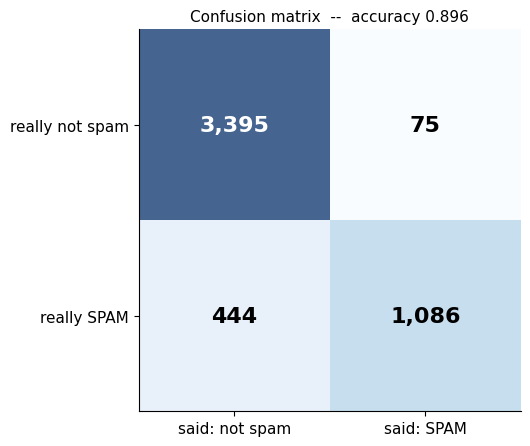

In [80]:
# ============================================================
#  9.3b  Classify, and score it honestly
# ============================================================
def nb_predict(Xq, prior, ls, lh):
    """Naive Bayes posterior P(spam | words), computed in log space."""
    s, h = log_scores(Xq, prior, ls, lh)
    return np.exp(s - np.logaddexp(s, h))


post_te = nb_predict(X_te, prior_spam, lik_spam, lik_ham)
pred_te = (post_te > 0.5).astype(int)

acc      = (pred_te == y_te).mean()
majority = 1 - y_te.mean() if y_te.mean() < 0.5 else y_te.mean()

tp = int(((pred_te == 1) & (y_te == 1)).sum())
fp = int(((pred_te == 1) & (y_te == 0)).sum())
fn = int(((pred_te == 0) & (y_te == 1)).sum())
tn = int(((pred_te == 0) & (y_te == 0)).sum())
cm = np.array([[tn, fp], [fn, tp]])

print(f"NAIVE BAYES on {len(te):,} unseen emails")
print(f"    accuracy                     = {acc:.4f}")
print(f"    always-guess-the-common-class= {majority:.4f}   <- the baseline")
print(f"    errors it removed vs baseline= {(acc - majority):.4f}")
print()
print(f"    recall on spam (caught)      = {tp / (tp + fn):.4f}")
print(f"    precision on spam            = {tp / (tp + fp):.4f}")
print(f"    real mail wrongly binned     = {fp} of {tn + fp}")
print()

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.imshow(cm, cmap="Blues", alpha=0.75)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=16, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["said: not spam", "said: SPAM"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["really not spam", "really SPAM"])
ax.set_title(f"Confusion matrix  --  accuracy {acc:.3f}", fontsize=11)
ax.grid(False)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The four numbers that accuracy hides. Reading across the top row: real mail correctly delivered, then real mail thrown in the spam bin. Across the bottom: spam that got through, then spam correctly caught.

Accuracy is printed above and it is well clear of the always-guess-the-common-class baseline, which is the only comparison that makes an accuracy number mean anything. But the two off-diagonal cells are not interchangeable, and no single number can tell you that. The top-right cell is somebody's job offer in the junk folder. The bottom-left is one more piece of spam in an inbox. Those errors are not the same size to a human being, and the model has no idea — it was optimised as if they were.

Choosing the 0.5 threshold is what made those two cells the size they are. It is a decision, not a fact about the model, and you can move it: raise the threshold and the top-right cell shrinks while the bottom-left grows.

**The common misread:** treating the confusion matrix as the model's report card. It is the report card of *the model plus a threshold*. The posteriors are the model; everything in this figure changes if you pick a different cut-off, and none of the underlying probabilities move at all.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**A high accuracy on an imbalanced problem can mean the model learned nothing.**

Our inbox is roughly seventy-thirty, so a model consisting of the single line `return 'not spam'` scores the baseline printed in the cell above — and it is a model with no inputs, no parameters, and no idea what an email is. Any accuracy you report has to be read against that number, and the cell prints the gap explicitly.

Now imagine the realistic version: fraud at one transaction in a thousand, or a rare disease. The do-nothing model scores 99.9%. A press release announcing 99.9% accuracy is announcing a constant. This is not a hypothetical failure mode — it is the single most common way a model gets shipped without working.

**What to report instead**, all of which the cell prints: recall on the rare class (of the spam that exists, how much did we catch), precision on it (of what we flagged, how much really was), and the raw confusion counts so the reader can compute anything else they want. And crucially the baseline itself, so 'better than nothing' is a measured claim rather than an assumption.

</div>

In [81]:
# ============================================================
#  9.3c  Interrogating the naive assumption with Part 8's tools
# ============================================================
def corr_matrix(M):
    """Part 8's correlation, on the columns of M."""
    return np.corrcoef(M, rowvar=False)


print("MARGINAL correlations between words -- ignoring the class entirely:")
print(f"{'':<10}" + "".join(f"{w:>10}" for w in words))
Cm = corr_matrix(X_all)
for i, w in enumerate(words):
    print(f"{w:<10}" + "".join(f"{Cm[i, j]:>10.3f}" for j in range(len(words))))
print()
print("Strongly dependent, exactly as Part 8 measured: 'free' and 'winner' turn")
print("up together, 'free' and 'meeting' avoid each other. Naive Bayes would be")
print("dead on arrival if THIS were the independence it assumed. It is not.")
print()

Cs = corr_matrix(X_all[y_all == 1])
Ch = corr_matrix(X_all[y_all == 0])
off = ~np.eye(len(words), dtype=bool)
print("CONDITIONAL correlations -- within spam only, and within ham only:")
print(f"    largest off-diagonal correlation inside spam = {np.abs(Cs[off]).max():.4f}")
print(f"    largest off-diagonal correlation inside ham  = {np.abs(Ch[off]).max():.4f}")
print()
print("Near zero. The dependence in the first table was entirely explained by")
print("the hidden cause -- being spam. That is Part 3's lesson restated: two")
print("things can be dependent and yet independent GIVEN a third.")
print()
print("So on THIS data the naive assumption is not merely tolerable, it is TRUE,")
print("because Part 0 generated the words that way. Which makes it useless as a")
print("test of what the assumption costs. So let us break it deliberately.")
print()

# --- break it: a duplicated feature is perfectly dependent, given the class
X_dup_tr = np.column_stack([X_tr, X_tr[:, 0]])     # 'free' counted twice
X_dup_te = np.column_stack([X_te, X_te[:, 0]])
lik_spam_d = X_dup_tr[y_tr == 1].mean(axis=0)
lik_ham_d  = X_dup_tr[y_tr == 0].mean(axis=0)

post_dup = nb_predict(X_dup_te, prior_spam, lik_spam_d, lik_ham_d)
pred_dup = (post_dup > 0.5).astype(int)

conf_honest = np.maximum(post_te,  1 - post_te).mean()
conf_dup    = np.maximum(post_dup, 1 - post_dup).mean()

print("WHAT DOUBLE-COUNTING ONE WORD DOES")
print(f"{'':<26}{'honest model':>15}{'duplicated word':>18}")
print(f"{'accuracy':<26}{acc:>15.4f}{(pred_dup == y_te).mean():>18.4f}")
print(f"{'mean confidence':<26}{conf_honest:>15.4f}{conf_dup:>18.4f}")
print(f"{'predictions above 0.99':<26}"
      f"{(np.maximum(post_te, 1 - post_te) > 0.99).mean():>15.4f}"
      f"{(np.maximum(post_dup, 1 - post_dup) > 0.99).mean():>18.4f}")
print(f"{'they disagree on':<26}{(pred_dup != pred_te).sum():>15,d} emails")
print()
print("The verdicts barely move. The CONFIDENCE moves a lot -- the same evidence")
print("was entered twice, so the model believes it twice as hard. That is the")
print("cost of the naive assumption in one line: it distorts the probabilities")
print("while usually leaving the winner alone.")


MARGINAL correlations between words -- ignoring the class entirely:
                free   meeting    winner    report
free           1.000    -0.209     0.328    -0.173
meeting       -0.209     1.000    -0.192     0.101
winner         0.328    -0.192     1.000    -0.151
report        -0.173     0.101    -0.151     1.000

Strongly dependent, exactly as Part 8 measured: 'free' and 'winner' turn
up together, 'free' and 'meeting' avoid each other. Naive Bayes would be
dead on arrival if THIS were the independence it assumed. It is not.

CONDITIONAL correlations -- within spam only, and within ham only:
    largest off-diagonal correlation inside spam = 0.0274
    largest off-diagonal correlation inside ham  = 0.0128

Near zero. The dependence in the first table was entirely explained by
the hidden cause -- being spam. That is Part 3's lesson restated: two
things can be dependent and yet independent GIVEN a third.

So on THIS data the naive assumption is not merely tolerable, it is TRUE,
b

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**Why does naive Bayes work when its central assumption is false?**

The duplicated-word experiment answers it as directly as anything can. Feeding the model the same evidence twice — the most flagrant possible violation of conditional independence — barely moved the accuracy while visibly inflating the confidence and nearly tripling the share of predictions above 0.99, and the two models changed their minds on only a small fraction of the test set. All four numbers are printed above.

The reason is that classification only needs the **argmax** to be right, not the probabilities. Correlated features cause the same evidence to be counted several times, which pushes the posterior toward 0 or 1 — but it pushes it toward *the end it was already heading for*. The verdict survives a distortion that the probability does not. This is the result Domingos and Pazzani proved in 1997, and it is why a classifier built on an assumption everyone knows is wrong has stayed in production for decades.

**The price is paid in exactly one place**: the numbers coming out are not trustworthy as probabilities. Naive Bayes on real text is famously overconfident, spraying 0.999s and 0.001s. Use it to decide; do not use its output as a calibrated probability without checking — which is precisely what 9.4 is going to do.

</div>

In [82]:
# ============================================================
#  9.3d  The zero-probability catastrophe, and Laplace's fix
# ============================================================
# Zeros appear when a class never happened to contain a word IN YOUR SAMPLE.
# With 15,000 emails that is rare. With 200 -- the realistic case when you are
# hand-labelling -- it is routine. Find the first seed where it bites:
SMALL = 200
for seed in range(100):
    idx  = np.random.default_rng(seed).choice(tr, SMALL, replace=False)
    Xs, ys = X_all[idx], y_all[idx]
    ls_s = Xs[ys == 1].mean(axis=0)
    lh_s = Xs[ys == 0].mean(axis=0)
    if (ls_s == 0).any() or (lh_s == 0).any():
        break

zero_cls, zero_j = (("spam", int(np.argmax(ls_s == 0))) if (ls_s == 0).any()
                    else ("not spam", int(np.argmax(lh_s == 0))))
print(f"Training on only {SMALL} labelled emails (seed {seed}):")
print(f"    the word '{words[zero_j]}' never appeared in a single "
      f"'{zero_cls}' email of the {SMALL}.")
print(f"    so the model estimates P('{words[zero_j]}' | {zero_cls}) = 0.0000")
print("    -- it has concluded that something it merely has not seen is IMPOSSIBLE.")
print()

# Build the most favourable possible email FOR that class: it carries the
# zeroed word, plus every other word that argues for the same class.
favours_zero_cls = (lik_spam > lik_ham) if zero_cls == "spam" else (lik_ham > lik_spam)
probe = np.where(favours_zero_cls, 1.0, 0.0)
probe[zero_j] = 1.0
others = [w for j, w in enumerate(words) if probe[j] == 1 and j != zero_j]
print(f"    Now build the email that argues hardest for '{zero_cls}': every other")
print(f"    word that favours it, plus the zeroed word itself.")
print(f"        arguing for {zero_cls}: {', '.join(others)}")
print(f"        plus the zeroed word: {words[zero_j]}")
print()

with np.errstate(divide="ignore", invalid="ignore"):
    s0, h0 = log_scores(probe[None, :], ys.mean(), ls_s, lh_s)
    post0  = np.exp(s0 - np.logaddexp(s0, h0))
post0_zero = post0[0] if zero_cls == "spam" else 1.0 - post0[0]

print("UNSMOOTHED")
print(f"    log-score for spam       = {s0[0]}")
print(f"    log-score for not spam   = {h0[0]}")
print(f"    P({zero_cls} | this email) = {post0_zero}")
print(f"    ...is it exactly zero?     {post0_zero == 0.0}")
print("    One zero count annihilated every other word in the email. No amount")
print("    of contrary evidence can ever recover, because it is multiplied by 0.")
print()

# --- Laplace (add-one) smoothing: pretend you saw one of each outcome ---
def laplace(Xc, alpha=1.0):
    """(count + alpha) / (n + 2*alpha) -- 2 because present/absent."""
    return (Xc.sum(axis=0) + alpha) / (Xc.shape[0] + 2 * alpha)


ls_lap = laplace(Xs[ys == 1])
lh_lap = laplace(Xs[ys == 0])

s1, h1 = log_scores(probe[None, :], ys.mean(), ls_lap, lh_lap)
post1  = np.exp(s1 - np.logaddexp(s1, h1))
post1_zero = post1[0] if zero_cls == "spam" else 1.0 - post1[0]
print("WITH LAPLACE SMOOTHING (add one to every count)")
print(f"    P('{words[zero_j]}' | {zero_cls}) = 0.0000  ->  "
      f"{(ls_lap if zero_cls == 'spam' else lh_lap)[zero_j]:.4f}")
print(f"    P({zero_cls} | this email) = {post1_zero:.4f}")
print("    Now the other words get a vote again.")
print()

# --- and on the whole test set -----------------------------------------
with np.errstate(divide="ignore", invalid="ignore"):
    acc_small_raw = ((nb_predict(X_te, ys.mean(), ls_s, lh_s) > 0.5)
                     .astype(int) == y_te).mean()
acc_small_lap = ((nb_predict(X_te, ys.mean(), ls_lap, lh_lap) > 0.5)
                 .astype(int) == y_te).mean()

lik_spam_lap = laplace(X_tr[y_tr == 1])
lik_ham_lap  = laplace(X_tr[y_tr == 0])
acc_big_lap  = ((nb_predict(X_te, prior_spam, lik_spam_lap, lik_ham_lap) > 0.5)
                .astype(int) == y_te).mean()

print(f"ACCURACY ON THE {len(te):,} TEST EMAILS")
print(f"    trained on {SMALL:>6,}, no smoothing = {acc_small_raw:.4f}")
print(f"    trained on {SMALL:>6,}, Laplace      = {acc_small_lap:.4f}")
print(f"    trained on {N_TRAIN:>6,}, no smoothing = {acc:.4f}")
print(f"    trained on {N_TRAIN:>6,}, Laplace      = {acc_big_lap:.4f}")
print()
print("Smoothing rescues the small-sample model and does essentially nothing to")
print("the large-sample one -- which is the correct behaviour. It is a claim")
print("that you have not seen everything yet, and with enough data that claim")
print("stops mattering.")


Training on only 200 labelled emails (seed 11):
    the word 'winner' never appeared in a single 'not spam' email of the 200.
    so the model estimates P('winner' | not spam) = 0.0000
    -- it has concluded that something it merely has not seen is IMPOSSIBLE.

    Now build the email that argues hardest for 'not spam': every other
    word that favours it, plus the zeroed word itself.
        arguing for not spam: meeting, report
        plus the zeroed word: winner

UNSMOOTHED
    log-score for spam       = -10.721026318885595
    log-score for not spam   = -inf
    P(not spam | this email) = 0.0
    ...is it exactly zero?     True
    One zero count annihilated every other word in the email. No amount
    of contrary evidence can ever recover, because it is multiplied by 0.

WITH LAPLACE SMOOTHING (add one to every count)
    P('winner' | not spam) = 0.0000  ->  0.0072
    P(not spam | this email) = 0.8961
    Now the other words get a vote again.

ACCURACY ON THE 5,000 TEST EMAILS

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**A probability estimated as zero is a claim of impossibility, and you almost never mean it.**

Counting gave the honest answer for the sample: this word never appeared in that class, so the fraction is 0. But the model does not use it as *'not seen in 200 emails'* — it uses it as *'cannot happen'*, and in a product that is absorbing. The cell shows a single zero wiping out every other word in the email, driving the posterior to exactly 0.0 and the log-score to `-inf`. Note that both classes can go to `-inf` at once, at which point the posterior is `nan` and the classifier has no opinion at all.

**Laplace smoothing** adds one imaginary observation of each outcome before dividing: $(c+\alpha)/(n+2\alpha)$. Unseen becomes rare instead of impossible. Seen-once becomes slightly less spectacular. With plenty of data it changes nothing measurable, which the last table confirms.

Two things to know about it. First, $\alpha$ is not sacred — $\alpha=1$ is conventional, smaller values smooth less, and in Bayesian terms this is exactly a Beta prior on a Bernoulli, so the 'imaginary observations' framing is literal rather than a metaphor. Second, the general lesson outlives naive Bayes entirely: **anywhere you divide one count by another, ask what happens when the numerator is zero.** Click-through rates, conversion rates, word frequencies, per-user averages — the same trap, the same fix.

</div>

---

## 9.4 Calibration: is 0.87 actually 0.87?

Accuracy asks whether the model picked the right side. Calibration asks a
harder question, and one that matters more whenever a human or another system
consumes the number rather than just the verdict:

> Of all the emails this model called spam **with probability 0.9**, were about
> 90% of them actually spam?

A model is **well calibrated** when that holds across the range: among cases it
labels $q$, the fraction that turn out positive is $q$. Note what this is *not*.
A model can be perfectly calibrated and nearly useless — one that answers 0.3 to
every single email is beautifully calibrated on our inbox, and tells you
nothing. And a model can be highly accurate and badly calibrated, which is the
usual case: it sorts cases correctly but its numbers are systematically too
extreme.

Both properties matter and neither implies the other. Accuracy is about the
argmax; calibration is about the probability itself.

**How to measure it.** Sort the predictions into bins. In each bin, compare the
average predicted probability against the fraction that were actually positive.
Plot one against the other: a perfectly calibrated model lies on the diagonal.
The gap, averaged over bins weighted by how many predictions fell in each, is
the **expected calibration error**:

$$
\text{ECE} \;=\; \sum_{b} \frac{n_b}{N}\,\bigl|\,\text{actual fraction}_b \;-\; \text{mean predicted}_b\,\bigr| .
$$


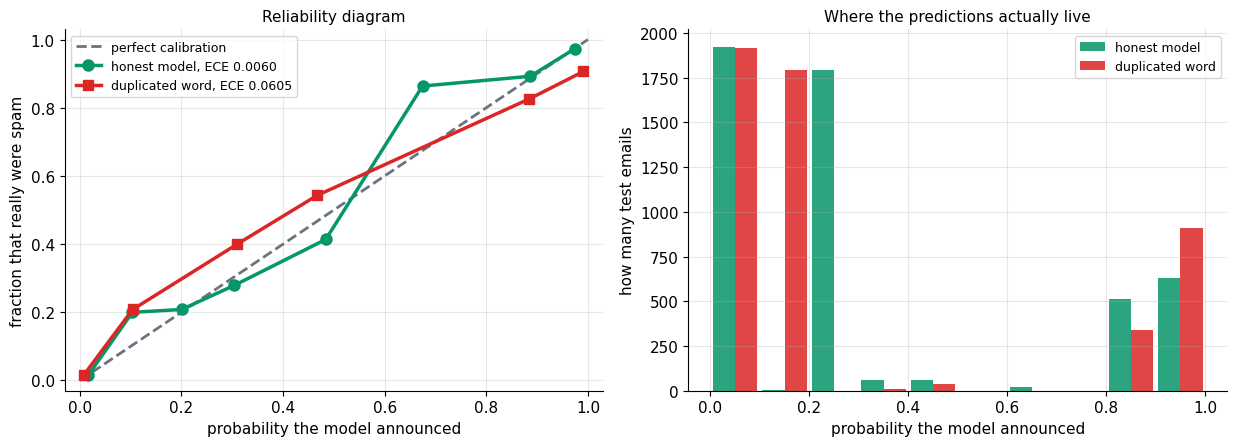

         bin       n   mean predicted   actually spam      gap
--------------------------------------------------------------
0.0 - 0.1   1,924           0.0164          0.0151  -0.0013
0.1 - 0.2       5           0.1036          0.2000   0.0964
0.2 - 0.3   1,791           0.2006          0.2083   0.0077
0.3 - 0.4      61           0.3036          0.2787  -0.0249
0.4 - 0.5      58           0.4842          0.4138  -0.0704
0.6 - 0.7      22           0.6746          0.8636   0.1891
0.8 - 0.9     511           0.8866          0.8924   0.0058
0.9 - 1.0     628           0.9741          0.9729  -0.0012

expected calibration error, honest model    = 0.0060
expected calibration error, duplicated word = 0.0605
ratio                                       = 10.0x worse

VERDICT on the honest model: WELL calibrated on this data.
And it should be. Part 0 generated the words to be conditionally
independent given the class, so naive Bayes' assumption is exactly true
here and its posterior is the re

In [83]:
# ============================================================
#  9.4  Reliability diagram -- honest model vs the double-counting one
# ============================================================
def reliability(post, y_true, n_bins=10):
    """Bin predictions; return (mean predicted, actual fraction, count) per bin."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    which = np.clip(np.digitize(post, edges) - 1, 0, n_bins - 1)
    conf, freq, cnt = [], [], []
    for b in range(n_bins):
        m = which == b
        cnt.append(int(m.sum()))
        conf.append(post[m].mean() if m.any() else np.nan)
        freq.append(y_true[m].mean() if m.any() else np.nan)
    return np.array(conf), np.array(freq), np.array(cnt)


def ece(post, y_true, n_bins=10):
    c, f, n = reliability(post, y_true, n_bins)
    ok = n > 0
    return float(np.sum(n[ok] / n.sum() * np.abs(f[ok] - c[ok])))


c_h, f_h, n_h = reliability(post_te, y_te)
c_d, f_d, n_d = reliability(post_dup, y_te)
ece_h, ece_d  = ece(post_te, y_te), ece(post_dup, y_te)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax[0].plot([0, 1], [0, 1], color=C_GREY, ls="--", lw=2, label="perfect calibration")
ok = n_h > 0
ax[0].plot(c_h[ok], f_h[ok], "o-", color=C_AREA, lw=2.5, ms=8,
           label=f"honest model, ECE {ece_h:.4f}")
ok = n_d > 0
ax[0].plot(c_d[ok], f_d[ok], "s-", color=C_SLOPE, lw=2.5, ms=7,
           label=f"duplicated word, ECE {ece_d:.4f}")
ax[0].set_xlabel("probability the model announced")
ax[0].set_ylabel("fraction that really were spam")
ax[0].set_title("Reliability diagram", fontsize=11)
ax[0].legend(fontsize=9, loc="upper left")
ax[0].set_xlim(-0.03, 1.03); ax[0].set_ylim(-0.03, 1.03)

w = 0.045
ax[1].bar(np.arange(10) / 10 + 0.05 - w / 2, n_h, width=w, color=C_AREA,
          label="honest model", alpha=0.85)
ax[1].bar(np.arange(10) / 10 + 0.05 + w / 2, n_d, width=w, color=C_SLOPE,
          label="duplicated word", alpha=0.85)
ax[1].set_xlabel("probability the model announced")
ax[1].set_ylabel("how many test emails")
ax[1].set_title("Where the predictions actually live", fontsize=11)
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"{'bin':>12}{'n':>8}{'mean predicted':>17}{'actually spam':>16}{'gap':>9}")
print("-" * 62)
for b in range(10):
    if n_h[b] == 0:
        continue
    print(f"{b / 10:.1f} - {(b + 1) / 10:.1f}{n_h[b]:>8,d}"
          f"{c_h[b]:>17.4f}{f_h[b]:>16.4f}{f_h[b] - c_h[b]:>9.4f}")
print()
print(f"expected calibration error, honest model    = {ece_h:.4f}")
print(f"expected calibration error, duplicated word = {ece_d:.4f}")
print(f"ratio                                       = {ece_d / ece_h:.1f}x worse")
print()
verdict = ("WELL calibrated" if ece_h < 0.02 else
           "NOT well calibrated" if ece_h > 0.05 else "BORDERLINE")
print(f"VERDICT on the honest model: {verdict} on this data.")
print("And it should be. Part 0 generated the words to be conditionally")
print("independent given the class, so naive Bayes' assumption is exactly true")
print("here and its posterior is the real one. That is a luxury of simulated")
print("data. The duplicated-word model is what real text looks like:")
print(f"    accuracy differs by only {abs((pred_dup == y_te).mean() - acc):.4f}")
print(f"    calibration error is     {ece_d / ece_h:.1f}x worse")
print("Accuracy could not see the difference. Calibration could.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left**: for each bin of predictions, what the model claimed against what actually happened. The dashed diagonal is perfection — a point on it means the emails in that bin turned out spam at exactly the rate the model announced.

The honest model sits on the diagonal, and its expected calibration error is printed above along with the verdict. That is a genuinely unusual result, and the cell says why: this data was built with exactly the structure naive Bayes assumes, so the model's posterior is the true posterior. Real data does not do this for you.

The duplicated-word model bows away from the diagonal in the characteristic overconfident shape — below the line on the right (it says 0.95, reality delivers less) and above it on the left. Its accuracy is within a whisker of the honest model's. **Accuracy could not see this difference at all.**

**Right**: where the predictions live. The duplicated model has evacuated the middle bins and piled up at the extremes — that is what double-counted evidence does, and it is why calibration curves for real naive Bayes are usually drawn from two crowded end bins.

**The common misread:** reading a point far off the diagonal as a serious problem without checking the right-hand panel first. A bin holding a handful of emails will bounce around wildly from noise alone — that is Part 6's variance, not miscalibration. Always look at the bin counts before believing a wobble, which is exactly why the ECE weights each bin by how much data is in it.

</div>

---

## 9.5 Closing: what each idea was for

Nine parts, and every one of them turned out to be load-bearing.

| Part | The idea | Where it did work in machine learning |
|---|---|---|
| **1** | probability as a long-run frequency you can count | the number a classifier outputs; every parameter in 9.3 is a counted fraction |
| **2** | and / or / not, without double-counting | combining evidence; knowing when you may multiply |
| **3** | the conditional bar, and independence | $P(y \mid x)$ **is** the supervised learning problem; the "naive" in naive Bayes is an independence claim |
| **4** | Bayes' theorem | turning $P(\text{words} \mid \text{spam})$, which you can count, into $P(\text{spam} \mid \text{words})$, which you want |
| **5** | random variables and expectation | every loss is an expectation; training minimises an average |
| **6** | variance and standardising | why bin counts wobble; why features get scaled; the bias–variance trade-off |
| **7** | the named distributions | the Bernoulli in 9.2 is what *makes* the loss cross-entropy; assume a different distribution and you derive a different loss |
| **8** | joint, marginal, covariance, correlation | 9.3c used correlation to audit this part's own model and catch its assumption |
| **9** | likelihood, cross-entropy, calibration | the training objective, and whether to believe the output |

One more connection worth stating plainly, because it is the single highest-value
thing in this notebook. **The loss function is not a design choice made on
taste.** Assume your target is Bernoulli and maximum likelihood *hands you*
cross-entropy. Assume it is Gaussian with constant variance and the identical
derivation hands you squared error. Assume Poisson and you get the Poisson
deviance. Every loss you have ever seen in a table of losses is a negative
log-likelihood under some assumption about the noise — and if you can name the
assumption, you can derive the loss instead of looking it up.

### ✅ What you can now do

Part 0 made nine promises. Here they are, and where each was paid:

| | Promise | Delivered in |
|---|---|---|
| 1 | Say what a probability is — and what it is not | **Part 1** |
| 2 | Combine events with and / or / not, without double-counting | **Part 2** |
| 3 | Compute a conditional probability, and say what independence really means | **Part 3**, and audited in **9.3c** |
| 4 | Derive and use Bayes' theorem; solve the test-accuracy problem | **Part 4**, applied in **9.3** |
| 5 | Work with random variables and compute an expectation | **Part 5** |
| 6 | Explain variance and why spread matters as much as average | **Part 6**, and used in **9.4** to read bin noise |
| 7 | Recognise the named distributions and say when each applies | **Part 7**, and cashed in **9.2** |
| 8 | Handle several variables at once: joint, marginal, covariance | **Part 8** |
| 9 | **Read cross-entropy loss as a sentence about likelihood** | **9.2** — *for every example, look up the probability the model gave to the thing that actually happened, take its log, average, flip the sign* |

If number 9 now reads as a sentence rather than a spell, the notebook did its
job.


---

## 🏋️ Exercises

No solutions. Each one is a cell or two, built from what is already above.

**1. The likelihood of a biased die.** Roll a six-sided die $n$ times with your
own chosen probabilities. Write the likelihood of the observed counts as a
function of the six face probabilities, and find the maximum numerically under
the constraint that they sum to 1. *Scaffold:* parameterise with five free
numbers and set the sixth to $1-\sum$; use `scipy.optimize.minimize`. Does the
answer come out as the six observed proportions? Now prove that it must, by
repeating 9.1c's three steps with a Lagrange multiplier for the constraint.

**2. Where does the underflow line actually fall?** In 9.1c we multiplied
probabilities until the product hit exactly zero. Predict the term number at
which that happens from the mean of $\log p$ and the float64 exponent limit,
*before* running it. *Scaffold:* the product dies when the running $\sum \log p$
drops below $\log(5\times10^{-324})$. Compare your prediction to
`np.argmax(np.cumprod(probs) == 0)`. Then repeat in float32 and explain the new
number.

**3. Squared error is also a maximum likelihood estimate.** Assume
$y_i = \hat y_i + \varepsilon_i$ with $\varepsilon_i$ Gaussian of fixed
variance (Part 7). Write the log-likelihood of the data, drop everything that
does not depend on the model, and show what is left is the sum of squared
errors. *Scaffold:* start from the Gaussian density, take logs, watch the
exponent fall out. Then confirm numerically that the model minimising squared
error is the one maximising your log-likelihood, using the ranking test from 9.2.

**4. Move the threshold.** Our confusion matrix used 0.5. Sweep the threshold
from 0 to 1 and plot how many real emails get binned against how much spam gets
through. *Scaffold:* reuse `post_te`; for each threshold count the two
off-diagonal cells. Then argue, in a sentence, which threshold you would ship if
a lost job offer were fifty times worse than a spam email — and check whether
the argument depends on the posteriors being calibrated.

**5. How much smoothing is too much?** Sweep the Laplace $\alpha$ over several
orders of magnitude on the small training set from 9.3d and plot accuracy and
ECE against it. *Scaffold:* `laplace(Xc, alpha)` already takes the parameter.
Find where each metric peaks. Do they peak in the same place, and what should
you do if they do not?

**6. Break the assumption properly.** Generate a new inbox where two words are
genuinely dependent *given the class* — not a duplicate, but something like
"'money' appears with high probability only when 'free' also appears". Retrain
naive Bayes, and report accuracy, ECE and the mean confidence against the
honest model. *Scaffold:* copy Part 0's generator, add the conditional rule,
reuse `nb_predict`, `ece` and `reliability` unchanged. Which of the three
numbers moves most? That is the answer to "what does the naive assumption
actually cost", measured on data you built yourself.


---

## 📚 References

**On likelihood and maximum likelihood**
- Bishop, *Pattern Recognition and Machine Learning* (2006), §1.2.5 and §4.3 —
  curve fitting re-read as maximum likelihood, then classification.
- Goodfellow, Bengio & Courville, *Deep Learning* (2016), §5.5 and §3.13 — the
  clearest short statement that losses are negative log-likelihoods.
- Murphy, *Probabilistic Machine Learning: An Introduction* (2022), Ch. 4.

**On naive Bayes**
- Tan, Steinbach, Karpatne & Kumar, *Introduction to Data Mining* 2e, §4.4 —
  Bayesian classifiers, including the m-estimate generalisation of the
  smoothing in 9.3d.
- Domingos & Pazzani (1997), "On the Optimality of the Simple Bayesian
  Classifier under Zero-One Loss", *Machine Learning* 29:103–130 — the paper
  behind 9.3c: why the argmax survives an assumption the probabilities do not.
- Rennie, Shih, Teevan & Karger (2003), "Tackling the Poor Assumptions of Naive
  Bayes Text Classifiers", *ICML* — the practical repairs.

**On calibration**
- Niculescu-Mizil & Caruana (2005), "Predicting Good Probabilities with
  Supervised Learning", *ICML* — reliability diagrams, and which model families
  are badly calibrated in which direction.
- Guo, Pleiss, Sun & Weinberger (2017), "On Calibration of Modern Neural
  Networks", *ICML* — modern deep networks are far more overconfident than the
  older, smaller ones; temperature scaling as the standard fix.

**Watch rather than read**
- StatQuest, "Maximum Likelihood, clearly explained" and "Naive Bayes".
- 3Blue1Brown, "Bayes theorem" — the visual version of Part 4.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why probability, and the game we play all notebook |
| **1** | Outcomes, events, and what a probability IS |
| **2** | Combining events: and, or, not |
| **3** | Conditional probability and independence |
| **4** | Bayes' theorem, derived and used |
| **5** | Random variables and expectation |
| **6** | Variance, spread, and why it matters |
| **7** | The named distributions, and when each applies |
| **8** | Many variables at once: joint, marginal, covariance |
| **9** | Probability doing ML: likelihood, cross-entropy, naive Bayes |  &larr; **you are here**

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


<div style="background: linear-gradient(135deg, #134E5E 0%, #71B280 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### 🎉 That is the whole notebook.

You started at *what is a probability*. You end able to build a classifier from
counts, derive the loss it is trained with, catch it violating its own
assumptions, and say whether its outputs deserve to be believed.

The thing worth carrying out of here is not any single formula. It is the habit
this notebook ran on from the first cell: **state the rule, then check it by
counting.** Every claim in nine parts was verified against simulated data, and
where a result was surprising — the disease test in Part 4, the naive assumption
in 9.3, the calibration verdict in 9.4 — checking is what settled it.

Intuition about probability is unreliable in humans. It stays unreliable in
experts. What does not go wrong is counting.


</div>